# GGlasso Model Validation: Predicting IBD Flares Using Group Lasso

_date: 2025-01-13_


In [1]:
# Global notebook options
options(
  warn = -1,
  repr.plot.width = 24,
  repr.plot.height = 6
)




In [2]:
# Load Required Libraries
# -----------------------
suppressWarnings(
  suppressMessages({
      library(labelled)     # For handling variable labels
    library(readxl) 

    library(stringr)
    library(lubridate)
    library(pROC)

    library(corrplot)
    library(VIM)
    library(Hmisc)
    library(GGally)
    library(gridExtra)
    library(RColorBrewer)
    library(car)
    library(broom)
    library(kableExtra)
    library(psych)
    library(e1071)  # for skewness() and kurtosis()
    library(MASS)

    library(gglasso)  
    library(tidyverse)
    library(dplyr)
  }))

This analysis develops predictive models for inflammatory bowel disease (IBD) flares at four different time points using a sophisticated group-based variable selection approach.

# 1. Data Loading and Preparation

## 1.1 Initial Data Sources

The code integrates multiple datasets:

- Disease-specific data: Separate datasets for Crohn's Disease (CD) and Ulcerative Colitis (UC)
- Psychosocial variables: IBD Control questionnaire (fatigue, depression, anxiety) and Health Monitor (stress)
- Medication data: Advanced therapy use and other medications with treatment periods

In [3]:
suppressWarnings(
  suppressMessages({
# Import Excel files
dataset_cd <- read_excel("Dataset CD v5.xlsx") %>% 
  mutate(birthdate = dmy(birthdate))

dataset_uc <- read_excel("Dataset UC v5.xlsx") %>% 
  mutate(birthdate = dmy(birthdate))


# psychosocial variables
Health_Monitor <- read_excel("Health Monitor.xlsx")
IBD_Control  <- read_excel("IBD Control.xlsx")

# therapy use
Other_medication<- read_excel("Other medication v4.xlsx")
advanced_therapy_use <- read_excel("Advanced therapy use v4.xlsx")

        }))


In [4]:
cat("Number of patients in dataset_cd: ", nrow(dataset_cd))
cat("\nNumber of patients in dataset_uc: ", nrow(dataset_uc))

Number of patients in dataset_cd:  2678
Number of patients in dataset_uc:  2144

The psychosocial variables such as: 

- Fatigue (is in the IBDcontrol folder--\> each of the score in the column should be multiplied by 2 (eg 1*2 =2, 2*2 = 4 and so on, to be about the same with the fatigue variables in the initial model)--\*Don't use the values in the VAS fatigue folder for this 

- Depression (is in the IBDcontrol folder) 

- Anxiety (is in the IBDcontrol folder) 

- Stress (is in the Health Monitor folder

- use the column called "control myself'' for this) - Smoking Status - is in the Dataset CD and UC as smoker.

## 1.2  Calprotectin Processing

A critical feature engineering step identifies the maximum calprotectin value within 6 months of each MIAH assessment date. This biomarker is crucial for detecting intestinal inflammation.

In [5]:
# Function to find max calprotectin within 6 months for one MIAH date
find_max_calpro <- function(row_data, miah_date_col) {
  
  # Get the MIAH date
  miah_date <- row_data[[miah_date_col]]
  
  # If MIAH date is NA, return NA
  if (is.na(miah_date)) {
    return(list(date = as.POSIXct(NA), value = NA_real_))
  }
  
  # Collect all calprotectin values and dates
  calpro_values <- c()
  calpro_dates <- c()
  
  for (i in 1:16) {
    val_col <- paste0("calprotectine", i)
    date_col <- paste0("calpro_date", i)
    
    if (!is.null(row_data[[val_col]]) && !is.na(row_data[[val_col]])) {
      if (!is.null(row_data[[date_col]]) && !is.na(row_data[[date_col]])) {
        calpro_values <- c(calpro_values, as.numeric(row_data[[val_col]]))
        calpro_dates <- c(calpro_dates, as.POSIXct(row_data[[date_col]]))
      }
    }
  }
  
  # If no valid calprotectin data, return NA
  if (length(calpro_values) == 0) {
    return(list(date = as.POSIXct(NA), value = NA_real_))
  }
  
  # Calculate days difference (difftime works with POSIXct)
  days_diff <- abs(as.numeric(difftime(calpro_dates, miah_date, units = "days")))
  
  # Filter for within 6 months (183 days)
  within_6m <- days_diff <= 183
  
  if (sum(within_6m) == 0) {
    return(list(date = as.POSIXct(NA), value = NA_real_))
  }
  
  # Get values and dates within 6 months
  valid_values <- calpro_values[within_6m]
  valid_dates <- calpro_dates[within_6m]
  
  # Find maximum value
  max_idx <- which.max(valid_values)
  
  return(list(date = valid_dates[max_idx], value = valid_values[max_idx]))
}


In [6]:

# Process for miah_date1
dataset_cd$date1_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_cd)))
dataset_cd$value_calprotectine_1 <- NA_real_

for (i in 1:nrow(dataset_cd)) {
  result <- find_max_calpro(dataset_cd[i, ], "miah_date1")
  dataset_cd$date1_calprotectine[i] <- result$date
  dataset_cd$value_calprotectine_1[i] <- result$value
}
# Ensure POSIXct class is preserved
class(dataset_cd$date1_calprotectine) <- c("POSIXct", "POSIXt")

# Process for miah_date2
dataset_cd$date2_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_cd)))
dataset_cd$value_calprotectine_2 <- NA_real_

for (i in 1:nrow(dataset_cd)) {
  result <- find_max_calpro(dataset_cd[i, ], "miah_date2")
  dataset_cd$date2_calprotectine[i] <- result$date
  dataset_cd$value_calprotectine_2[i] <- result$value
}
class(dataset_cd$date2_calprotectine) <- c("POSIXct", "POSIXt")

# Process for miah_date3
dataset_cd$date3_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_cd)))
dataset_cd$value_calprotectine_3 <- NA_real_

for (i in 1:nrow(dataset_cd)) {
  result <- find_max_calpro(dataset_cd[i, ], "miah_date3")
  dataset_cd$date3_calprotectine[i] <- result$date
  dataset_cd$value_calprotectine_3[i] <- result$value
}
class(dataset_cd$date3_calprotectine) <- c("POSIXct", "POSIXt")

# Process for miah_date4
dataset_cd$date4_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_cd)))
dataset_cd$value_calprotectine_4 <- NA_real_

for (i in 1:nrow(dataset_cd)) {
  result <- find_max_calpro(dataset_cd[i, ], "miah_date4")
  dataset_cd$date4_calprotectine[i] <- result$date
  dataset_cd$value_calprotectine_4[i] <- result$value
}
class(dataset_cd$date4_calprotectine) <- c("POSIXct", "POSIXt")

# View results
result_cols <- c("miah_date1", "date1_calprotectine", "value_calprotectine_1",
                 "miah_date2", "date2_calprotectine", "value_calprotectine_2",
                 "miah_date3", "date3_calprotectine", "value_calprotectine_3",
                 "miah_date4", "date4_calprotectine", "value_calprotectine_4")

head(dataset_cd[, result_cols])

# DROP 16 calpro 
dataset_cd <- dataset_cd %>%
  select(-starts_with(c("calpro")))


miah_date1,date1_calprotectine,value_calprotectine_1,miah_date2,date2_calprotectine,value_calprotectine_2,miah_date3,date3_calprotectine,value_calprotectine_3,miah_date4,date4_calprotectine,value_calprotectine_4
<dttm>,<dttm>,<dbl>,<dttm>,<dttm>,<dbl>,<dttm>,<dttm>,<dbl>,<dttm>,<dttm>,<dbl>
2023-11-19,2023-11-01 01:00:00,24,2024-05-04,2024-09-05 01:00:00,25,2024-11-10,2024-09-05 01:00:00,25,2025-05-23,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2024-12-16,2025-03-04 01:00:00,100,2025-06-09,2025-03-04 01:00:00,100,NA,NA,NA,NA,NA,NA
2024-04-29,2024-04-02 01:00:00,190,2024-11-25,2024-08-20 01:00:00,37,2025-05-19,NA,NA,NA,NA,NA
2023-11-26,2023-10-09 01:00:00,510,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023-11-19,2023-08-09 01:00:00,270,2024-05-14,2024-07-25 01:00:00,460,2024-11-21,2024-07-25 01:00:00,460,2025-05-20,NA,NA


In [7]:

# Process for miah_date1
dataset_uc$date1_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_uc)))
dataset_uc$value_calprotectine_1 <- NA_real_

for (i in 1:nrow(dataset_uc)) {
  result <- find_max_calpro(dataset_uc[i, ], "miah_date1")
  dataset_uc$date1_calprotectine[i] <- result$date
  dataset_uc$value_calprotectine_1[i] <- result$value
}
# Ensure POSIXct class is preserved
class(dataset_uc$date1_calprotectine) <- c("POSIXct", "POSIXt")

# Process for miah_date2
dataset_uc$date2_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_uc)))
dataset_uc$value_calprotectine_2 <- NA_real_

for (i in 1:nrow(dataset_uc)) {
  result <- find_max_calpro(dataset_uc[i, ], "miah_date2")
  dataset_uc$date2_calprotectine[i] <- result$date
  dataset_uc$value_calprotectine_2[i] <- result$value
}
class(dataset_uc$date2_calprotectine) <- c("POSIXct", "POSIXt")

# Process for miah_date3
dataset_uc$date3_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_uc)))
dataset_uc$value_calprotectine_3 <- NA_real_

for (i in 1:nrow(dataset_uc)) {
  result <- find_max_calpro(dataset_uc[i, ], "miah_date3")
  dataset_uc$date3_calprotectine[i] <- result$date
  dataset_uc$value_calprotectine_3[i] <- result$value
}
class(dataset_uc$date3_calprotectine) <- c("POSIXct", "POSIXt")

# Process for miah_date4
dataset_uc$date4_calprotectine <- as.POSIXct(rep(NA, nrow(dataset_uc)))
dataset_uc$value_calprotectine_4 <- NA_real_

for (i in 1:nrow(dataset_uc)) {
  result <- find_max_calpro(dataset_uc[i, ], "miah_date4")
  dataset_uc$date4_calprotectine[i] <- result$date
  dataset_uc$value_calprotectine_4[i] <- result$value
}
class(dataset_uc$date4_calprotectine) <- c("POSIXct", "POSIXt")

# View results
result_cols <- c("miah_date1", "date1_calprotectine", "value_calprotectine_1",
                 "miah_date2", "date2_calprotectine", "value_calprotectine_2",
                 "miah_date3", "date3_calprotectine", "value_calprotectine_3",
                 "miah_date4", "date4_calprotectine", "value_calprotectine_4")

head(dataset_uc[, result_cols])

# DROP 16 calpro 
dataset_uc <- dataset_uc %>%
  select(-starts_with(c("calpro")))

miah_date1,date1_calprotectine,value_calprotectine_1,miah_date2,date2_calprotectine,value_calprotectine_2,miah_date3,date3_calprotectine,value_calprotectine_3,miah_date4,date4_calprotectine,value_calprotectine_4
<dttm>,<dttm>,<dbl>,<dttm>,<dttm>,<dbl>,<dttm>,<dttm>,<dbl>,<dttm>,<dttm>,<dbl>
NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023-11-27,2024-02-28 01:00:00,23,2025-06-03,2025-01-28 01:00:00,200,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2024-11-15,2024-08-01 01:00:00,27,2025-05-24,NA,NA,2025-11-09,NA,NA,NA,NA,NA
2024-05-21,2024-07-30 01:00:00,150,2025-05-28,NA,NA,NA,NA,NA,NA,NA,NA
2023-11-15,NA,NA,2024-05-08,NA,NA,2025-05-21,NA,NA,NA,NA,NA


## 1.2 Psychosocial data

In [8]:
psy_data <- IBD_Control  %>%
  select(patientIdentifier, effectiveDate, pain_3c  , fatigue_3d  , anxious_or_depressed_3e)  %>%
  mutate(fatigue_3d = fatigue_3d *2)


Stress_data <- Health_Monitor  %>%
  select(patientIdentifier, effectiveDate, control_myself )

# 2. Data Preparation

**Baseline Characteristics**

- Age at inclusion, BMI, gender
- Montreal classification variables (disease extent, severity, age at diagnosis)
- Surgery history (12 types) with age at each surgery
- Family history variables (IBD, colitis, Crohn's)

**Psychosocial Variables**

Mean scores computed per patient:

- Anxiety and depression levels
- Fatigue (multiplied by 2 for consistency)
- Pain levels
- Stress (control_myself variable)

**Medication Variables**

- Binary indicators for medication use (10 medication types)
- Medication duration periods
- Total medication count and total treatment period

## 2.1 Prepare BaseLine Data



identify and remove all rows from `dataset_cd` that are mostly empty (only have values in a few key columns like `patientIdentifier`, `gender`, `birthdate`, `diagnosis`, and `inclusion_date`):

In [9]:
# Define the key columns that are typically filled even for sparse rows
key_columns <- c("patientIdentifier", "gender", "birthdate", "diagnosis", "inclusion_date")

# Identify columns other than these
non_key_columns <- setdiff(names(dataset_cd), key_columns)

# Compute number of non-NA values per row in the non-key columns
dataset_cd <- dataset_cd %>%
  mutate(non_key_nonNA = rowSums(!is.na(dplyr::select(., all_of(non_key_columns)))))

# Calculate how many rows have only the key fields filled (i.e., rest is all NA)
only_key_rows <- dataset_cd %>%
  filter(non_key_nonNA < 3)

# Percentage of such sparse rows
percent_sparse <- nrow(only_key_rows) / nrow(dataset_cd) * 100
cat(sprintf("⚠️ %.2f%% of rows in CD data only contain key columns and are likely empty.\n", percent_sparse))

# Remove those rows from dataset
dataset_cd <- dataset_cd %>%
  filter(non_key_nonNA >3) %>%
  dplyr::select(-non_key_nonNA)  # remove helper column

# overwrite if desired
dataset_cd <- dataset_cd %>%
  mutate(
    age_at_inclusion = as.numeric(difftime(inclusion_date, birthdate, units = "days")) / 365.25
  )


# UC

# Identify columns other than these
non_key_columns <- setdiff(names(dataset_uc), key_columns)

# Compute number of non-NA values per row in the non-key columns
dataset_uc <- dataset_uc %>%
  mutate(non_key_nonNA = rowSums(!is.na(dplyr::select(., all_of(non_key_columns)))))

# Calculate how many rows have only the key fields filled (i.e., rest is all NA)
only_key_rows <- dataset_uc %>%
  filter(non_key_nonNA < 3)

# Percentage of such sparse rows
percent_sparse <- nrow(only_key_rows) / nrow(dataset_uc) * 100
cat(sprintf("⚠️ %.2f%% of rows in UC data only contain key columns and are likely empty.\n", percent_sparse))

# Remove those rows from dataset
dataset_uc <- dataset_uc %>%
  filter(non_key_nonNA >3) %>%
  dplyr::select(-non_key_nonNA)  # remove helper column

# overwrite if desired
dataset_uc <- dataset_uc%>%
  mutate(
    age_at_inclusion = as.numeric(difftime(inclusion_date, birthdate, units = "days")) / 365.25
  )

⚠️ 8.10% of rows in CD data only contain key columns and are likely empty.
⚠️ 11.43% of rows in UC data only contain key columns and are likely empty.


In [10]:
cat("Number of patients in dataset_cd: ", nrow(dataset_cd))
cat("\nNumber of patients in dataset_uc: ", nrow(dataset_uc))

Number of patients in dataset_cd:  2403
Number of patients in dataset_uc:  1832

Check if patientIdentifier is unique in CD and UC

### 2.1.2 Flare Definition:

Flares are defined at each time point using three criteria (any one triggers a flare):

- For UC: MIAH score > 3.5
- For CD: MIAH score > 3.6
- Calprotectin > 250 µg/g
- Endoscopy report containing any text (indicating active disease

This creates four binary outcome variables: `flare_date1` through `flare_date4`.

#### 🔍 CD:

In [11]:
# Loop over 1 to 3: include verslag
for (i in 1:4) {
  miah_col <- paste0("miah_CD", i)
  calpro_col <- paste0("value_calprotectine_", i)
  verslag_col <- paste0("verslag", i)
  flare_col <- paste0("flare_date", i)
  
  dataset_cd[[flare_col]] <- (
    (!is.na(dataset_cd[[miah_col]]) & dataset_cd[[miah_col]] > 3.6) |
    (!is.na(dataset_cd[[calpro_col]]) & dataset_cd[[calpro_col]] > 250) |
    (!is.na(dataset_cd[[verslag_col]]) & trimws(dataset_cd[[verslag_col]]) != "")
  )
  
  dataset_cd[[flare_col]] <- as.integer(dataset_cd[[flare_col]])
}



sapply(1:4, function(i) table(dataset_cd[[paste0("flare_date", i)]]))


0,1504,1880,2073,2240
1,899,523,330,163


#### 🔍 uc:

In [12]:
# Loop over 1 to 4
for (i in 1:4) {
  miah_col <- paste0("miah_cu", i)
  calpro_col <- paste0("value_calprotectine_", i)
  verslag_col <- paste0("verslag", i)
  flare_col <- paste0("flare_date", i)
  
  dataset_uc[[flare_col]] <- (
    (!is.na(dataset_uc[[miah_col]]) & dataset_uc[[miah_col]] > 3.5) |
    (!is.na(dataset_uc[[calpro_col]]) & dataset_uc[[calpro_col]] > 250) |
    (!is.na(dataset_uc[[verslag_col]]) & trimws(dataset_uc[[verslag_col]]) != "")
  )
  
  dataset_uc[[flare_col]] <- as.integer(dataset_uc[[flare_col]])
}



sapply(1:4, function(i) table(dataset_uc[[paste0("flare_date", i)]]))


0,826,1137,1390,1599
1,1006,695,442,233


Drop miah, calpro, verslag, mayo, and sescd from CD and UC as they are already used to create flare

In [13]:
summary(dataset_cd %>%
  dplyr::select( contains("date")))

   birthdate          inclusion_date               
 Min.   :1936-08-01   Min.   :2023-11-11 00:00:00  
 1st Qu.:1966-01-19   1st Qu.:2023-11-14 00:00:00  
 Median :1979-04-14   Median :2023-11-15 00:00:00  
 Mean   :1977-09-29   Mean   :2023-11-20 07:33:37  
 3rd Qu.:1990-03-15   3rd Qu.:2023-11-15 00:00:00  
 Max.   :2024-08-26   Max.   :2025-10-13 00:00:00  
                                                   
   miah_date1                    miah_date2                 
 Min.   :2023-11-11 00:00:00   Min.   :2023-11-14 00:00:00  
 1st Qu.:2023-11-16 00:00:00   1st Qu.:2024-05-08 00:00:00  
 Median :2023-11-28 00:00:00   Median :2024-11-12 00:00:00  
 Mean   :2024-03-22 22:16:17   Mean   :2024-10-10 08:31:23  
 3rd Qu.:2024-05-15 00:00:00   3rd Qu.:2024-12-04 00:00:00  
 Max.   :2025-11-14 00:00:00   Max.   :2025-11-13 00:00:00  
 NA's   :1084                  NA's   :1516                 
   miah_date3                    miah_date4                 
 Min.   :2024-11-09 00:00:00   Min.

In [14]:

# Load library
library(lubridate)

# Define inclusion dates
start_date <- as.Date("2023-11-11")
end_date   <- as.Date("2025-10-13")

# Total time period in days
total_days <- as.numeric(end_date - start_date)

# Total time period in months (approximate)
total_months <- interval(start_date, end_date) %/% months(1)

# Remaining days after full months
remaining_days <- as.numeric(end_date - (start_date %m+% months(total_months)))

# Total time period in years (approximate)
total_years <- interval(start_date, end_date) / years(1)

# Output
list(
  Start_Date = start_date,
  End_Date = end_date,
  Total_Days = total_days,
  Total_Months = total_months,
  Remaining_Days = remaining_days,
  Total_Years = round(total_years, 2)
)


$Start_Date
[1] "2023-11-11"

$End_Date
[1] "2025-10-13"

$Total_Days
[1] 702

$Total_Months
[1] 23

$Remaining_Days
[1] 2

$Total_Years
[1] 1.92

In [15]:
dataset_uc <- dataset_uc %>%
  dplyr::select(-starts_with("miah"), -starts_with("value_calpro"), -starts_with("date"), -starts_with("mayo") , -starts_with('verslag'))

dataset_cd <- dataset_cd %>%
  dplyr::select(-starts_with("miah"), -starts_with("value_calpro"), -starts_with("date"), -starts_with("mayo") ,
         -starts_with('verslag'), -starts_with('sescd'))

 # Add DiseaseEntity column
 
dataset_cd$DiseaseEntity <- factor("CD", levels = c("CD", "UC"))
dataset_uc$DiseaseEntity <- factor("UC", levels = c("CD", "UC"))


### 2.2 Perform a column-wise bind (rbind)

In [16]:

combined_dataset <- bind_rows(dataset_cd, dataset_uc) %>%
  slice_sample(prop = 1)  # shuffle (randomize) the rows in combined_dataset after merging dataset_cd and dataset_uc 


cat("Total number of CD AND UC patients:", dim(combined_dataset), "\n")

Total number of CD AND UC patients: 4235 43 


## 2.2 Prepare psychosocial Data

Check if patientIdentifier is unique.

In [17]:
# Check if patientIdentifier is unique.
cat("\nduplicated patientIdentifier in combined_dataset:\n",
      combined_dataset$patientIdentifier[duplicated(combined_dataset$patientIdentifier)])
cat("\nduplicated patientIdentifier in  anxiety_depression:\n",
      length(psy_data$patientIdentifier[duplicated(psy_data$patientIdentifier)]))
cat("\nduplicated patientIdentifier in promis_fatigue:\n",
      length(Stress_data$patientIdentifier[duplicated(Stress_data$patientIdentifier)]))


duplicated patientIdentifier in combined_dataset:
 
duplicated patientIdentifier in  anxiety_depression:
 4109
duplicated patientIdentifier in promis_fatigue:
 8326

There're duplication in all three files. Let's display an example for each file:

In [18]:
Health_Monitor[Health_Monitor$patientIdentifier=="70223696",]

patientIdentifier,creationDate,effectiveDate,formUUID,formFQN,formRevision,functionalClassification,temporalClassification,bestday_words,worstday_words,⋯,peace_health,grip_health,functioning_accept,health_control,accept_health,step_today,step_month,ACCEPTANCE,CONTROL,HM_TOTAL
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<lgl>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
70223696,2024-05-02T09:25:04+02:00,2024-05-02T09:25:04+02:00,1a5ce573-150f-4013-8f4f-eeb700d05428,com.brightfish.form.healthmonitor,7,prom,NA,"energiek, regelmatige ontlasting, geen buikpijn","minder energiek, obstipatie, opgeblazen gevoel.",⋯,6,6,6,6,6,10,10,6.000000,6,1
70223696,2024-11-18T11:14:24+01:00,2024-11-18T11:14:24+01:00,1a5ce573-150f-4013-8f4f-eeb700d05428,com.brightfish.form.healthmonitor,7,NA,NA,"energiek, regelmatige en goede ontlasting, buik is rustig (geen geborrel op opgeblazen gevoel)","moeilijke ontlasting (niet kunnen gaan of juist diarree), borrelende buik, weinig eetlust",⋯,6,6,6,6,6,8,7,6.000000,6,1
70223696,2025-05-23T13:33:20+02:00,2025-05-23T13:33:20+02:00,1a5ce573-150f-4013-8f4f-eeb700d05428,com.brightfish.form.healthmonitor,7,NA,NA,"energiek, vrolijk, zorgeloos","weinig energie, buikpijn, aandrang, onzeker",⋯,5,5,5,5,5,6,8,5.000000,5,2
70223696,2023-11-16T10:17:21+01:00,2023-11-16T10:17:21+01:00,1a5ce573-150f-4013-8f4f-eeb700d05428,com.brightfish.form.healthmonitor,6,prom,NA,"energiek, klachtenvrij, naar het toilet kunnen gaan volgens verwachting","vermoeid, niet naar het toilet kunnen gaan, harde ontlasting",⋯,3,5,5,4,3,9,9,3.666667,5,4


In [19]:
IBD_Control[IBD_Control$patientIdentifier=="23379117",]

patientIdentifier,creationDate,effectiveDate,formUUID,formFQN,formRevision,functionalClassification,temporalClassification,control_1a,treatment_1b,⋯,pain_3c,fatigue_3d,anxious_or_depressed_3e,treatment_change_3f,meds_change_4a,treatment_talk_4b,adverse_meds_4c,control_general_5,new_complaints_4d,ibdcontrol
<dbl>,<chr>,<dttm>,<chr>,<chr>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
23379117,2023-11-15T08:59:42+01:00,2023-11-15,8b5a2c4a-d0a6-4ac7-97d3-b79dddb50789,com.brightfish.form.ibdcontrol,7,prom,NA,0,0,⋯,2,2,0,1,1,1,0,29,1,5
23379117,2024-11-27T10:39:07+01:00,2024-11-27,8b5a2c4a-d0a6-4ac7-97d3-b79dddb50789,com.brightfish.form.ibdcontrol,7,NA,NA,0,2,⋯,0,2,1,0,0,0,0,80,0,5
23379117,2025-05-14T14:02:07+02:00,2025-05-14,8b5a2c4a-d0a6-4ac7-97d3-b79dddb50789,com.brightfish.form.ibdcontrol,7,NA,NA,2,2,⋯,0,2,1,0,0,0,0,77,0,7
23379117,2025-11-13T14:26:35+01:00,2025-11-13,8b5a2c4a-d0a6-4ac7-97d3-b79dddb50789,com.brightfish.form.ibdcontrol,8,NA,NA,2,2,⋯,2,0,1,2,2,2,2,81,2,13


Remove duplication by returning mean of psychosocial factors and max effectiveDate:

In [20]:
psy_data <- psy_data %>%
  group_by(patientIdentifier) %>%
  summarise(
    Anxious_mean = mean(anxious_or_depressed_3e, na.rm = TRUE),
    Fatigue_mean = mean(fatigue_3d, na.rm = TRUE),
    Pain_mean = mean(pain_3c, na.rm = TRUE),
    .groups = "drop"
  )


Stress <- Stress_data %>%
  group_by(patientIdentifier) %>%
  summarise(
    Stress_mean = mean(control_myself, na.rm = TRUE),
    .groups = "drop"
  )


In [21]:
cat("Total number of patients in anxiety_depression:", nrow(psy_data), "\n")
cat("Total number of patients in promis_fatigue:", nrow(Stress), "\n")

Total number of patients in anxiety_depression: 2697 
Total number of patients in promis_fatigue: 2886 


Inner join the three psychosocial datasets to combined_dataset by patientIdentifier:

In [22]:
dim(combined_dataset)

[1] 4235   43

In [23]:

# 2. Join each dataset using left_join on patientIdentifier
combined_dataset <- combined_dataset %>%
  inner_join(psy_data, by = "patientIdentifier") %>%
  inner_join(Stress, by = "patientIdentifier") 

## 2.3 Prepare Medication Data

In [24]:

cat("Total number of patients in advanced_therapy_use:", length(advanced_therapy_use[!duplicated(advanced_therapy_use$patientIdentifier),]), "\n")

Total number of patients in advanced_therapy_use: 9 


In [25]:
# Check if patientIdentifier is unique.
cat("\nduplicated patientIdentifier in advanced_therapy_use:\n",
      length(advanced_therapy_use$patientIdentifier[duplicated(advanced_therapy_use$patientIdentifier)]))


duplicated patientIdentifier in advanced_therapy_use:
 318

In [26]:
advanced_therapy_use[advanced_therapy_use$patientIdentifier=="186087",]

patientIdentifier,medicine_id,othermedicine,stopreason_id,stop_text,startmed,stopmed,meddur,episode_number
<dbl>,<chr>,<chr>,<dbl>,<chr>,<dttm>,<dttm>,<dbl>,<dbl>
186087,14,NA,NA,NA,2022-11-03 00:00:00,2023-04-17 23:00:00,165.9583,1
186087,33,NA,NA,NA,2023-08-29 23:00:00,2025-11-14 00:00:00,807.0417,2


compute the medication period (in days) in advanced_therapy_use using startmed and stopmed columns:

In [27]:
Other_medication <- Other_medication%>%
  mutate(meddur = abs(as.numeric(difftime(stop_date, start_date, units = "days"))))
 


advanced_therapy_use <- advanced_therapy_use%>%
      select(patientIdentifier, medicine_id ,meddur)

Other_medication <- Other_medication%>%
      select(patientIdentifier, medicine_id ,dose , meddur)

Combine `advanced_therapy_use` and `Other_medication` **while avoiding duplicates**, i.e.:

-   Keep **all rows** from `advanced_therapy_use`
-   Add **only those rows** from `Other_medication` where `patientIdentifier` is **not already present** in `advanced_therapy_use`

In [28]:
table(advanced_therapy_use$medicine_id)


 12  14  22  33  41  42  70  77  80  88 
736 612  21 324  27 423   6  24  31  74 

replace the medicine_id values with their corresponding labels. For unknown IDs like “88”, “77”, and “70”, we’ll assign UNknown

In [29]:

# Define mapping as named vector
medicine_labels <- c(
  `12` = "Infliximab_Remicade",
  `14` = "Adalimumab",
  `22` = "Golimumab",
  `33` = "Vedolizumab",
  `41` = "Tofacitinib",
  `42` = "Ustekinumab_Stelara",
  
  `70` = "UNknown70",
  `77` = "UNknown77",
  `80` = "UNknown80",
  `88` = "UNknown88"
)

# Replace medicine_id with labels, invalid IDs become NA
advanced_therapy_use <- advanced_therapy_use %>%
  mutate(medicine_id = recode(medicine_id, !!!medicine_labels, .default = NA_character_))

clean dose:

To **reshape** `advanced_therapy_use` dataset so that:

-   Each **`patientIdentifier`** is a row

-   Each unique `medicine_id` becomes a **prefix** for two new columns:

    -   `brand_medication_period_days`


In [30]:
describe(advanced_therapy_use$meddur)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X1,1,2278,2273.094,1721.563,1986.458,2076.141,1664.218,-0.08333333,8982.958,8983.042,0.9674856,0.6488001,36.06999


In [31]:
# Filter to rows with brand info, Ensure columns are numeric
filtered_data <- advanced_therapy_use %>%
  filter(!is.na(medicine_id))  %>%
  mutate(
    medication_period_days = as.numeric(meddur)
  ) %>%
  distinct(patientIdentifier, medicine_id, .keep_all = TRUE)

# --- Wide format for brand usage indicator (1/0) ---
binary_brand_use <- filtered_data %>%
  mutate(use = 1) %>%
  distinct(patientIdentifier, medicine_id, use) %>%
  pivot_wider(
    names_from = medicine_id,
    values_from = use,
    values_fill = 0,
    names_prefix = "used_"
  )

# --- Wide format for medication period ---
period_wide <- filtered_data %>%
  dplyr::select(patientIdentifier, medicine_id, medication_period_days) %>%
  pivot_wider(names_from = medicine_id, 
              values_from = medication_period_days, 
              names_prefix = "period_",
              values_fill = 0) # replace NA with 0 here)


# --- Combine all into one dataset ---
advanced_therapy_reshaped <- reduce(
  list(binary_brand_use, period_wide),
  full_join,
  by = "patientIdentifier"
)


-   This keeps multiple brands in separate columns like: `use_Amgevita`, `period_Amgevita`, etc.

In [32]:
 #compute the total number of medication used per patient 
# List of used med variables
med_used_vars <- colnames(advanced_therapy_reshaped  %>% dplyr::select(starts_with("used_")))

# Compute total dose and add as new variable
advanced_therapy_reshaped <- advanced_therapy_reshaped %>%
  mutate(total_medication = rowSums(dplyr::select(., all_of(med_used_vars)), na.rm = TRUE))

# List of period variables
period_vars <- colnames(advanced_therapy_reshaped  %>% dplyr::select(starts_with("period_")))

# Compute total period and add as new variable
advanced_therapy_reshaped <- advanced_therapy_reshaped %>%
  mutate(total_medication_period = rowSums(dplyr::select(., all_of(period_vars)), na.rm = TRUE))


In [33]:

# inner join on patientIdentifier
combined_dataset <- combined_dataset %>%
  inner_join(advanced_therapy_reshaped, by = "patientIdentifier")

## 2.4 Prepare the Combined dataset

compute the age at diagnosis :

In [34]:
combined_dataset <- combined_dataset %>%
  mutate(
    birth_year = lubridate::year(birthdate),
    montreal_age_diagnosis_uc = montreal_year_diagnosis_uc - birth_year
  )%>%
  dplyr::select(-montreal_year_diagnosis_uc, -birth_year )


fill NA values with 9999 in the montreal\_ vars

In [35]:
# Calculate mode (most frequent value) for UC patients
uc_mode <- combined_dataset %>%
  filter(DiseaseEntity == "UC", 
         !is.na(montreal_extent_uc), 
         is.finite(montreal_extent_uc)) %>%
  count(montreal_extent_uc) %>%
  slice_max(n, n = 1) %>%
  pull(montreal_extent_uc)

# Replace NA and -Inf values based on DiseaseEntity
combined_dataset <- combined_dataset %>%
  mutate(montreal_extent_uc = case_when(
    # For UC: replace NA and -Inf with mode
    DiseaseEntity == "UC" & (is.na(montreal_extent_uc) | is.infinite(montreal_extent_uc)) ~ uc_mode,
    # For CD: replace NA with 9999
    DiseaseEntity == "CD" & is.na(montreal_extent_uc) ~ 9999,
    # Keep all other values as they are
    TRUE ~ montreal_extent_uc
  ))


# montreal_severity_uc : Replace NA and -Inf values based on DiseaseEntity
combined_dataset <- combined_dataset %>%
  mutate(montreal_severity_uc = case_when(
    # For UC: replace NA and -Inf with mode
    DiseaseEntity == "UC" & (is.na(montreal_severity_uc) | is.infinite(montreal_severity_uc)) ~ 1,
    # For CD: replace NA with 9999
    DiseaseEntity == "CD" & is.na(montreal_severity_uc) ~ 0,
    # Keep all other values as they are
    TRUE ~ montreal_severity_uc
  ))


In [36]:
combined_dataset$montreal_activity_cd <- NULL
combined_dataset$montreal_age_diagnosis_uc <- NULL
combined_dataset$montreal_location_cd <- NULL

Compute the age at the time of each surgery using the `birthdate` column and the `surg_*` date columns:

In [37]:
surgery_vars <- colnames(combined_dataset  %>% dplyr::select(starts_with("surg_")))


# Compute age at surgery for each surgery column
for (surg_col in surgery_vars) {
  age_col <- paste0("age_at_", surg_col)
  combined_dataset[[age_col]] <- as.numeric(difftime(combined_dataset[[surg_col]], combined_dataset$birthdate, units = "days")) / 365.25
}



In [38]:
# Replace NA with 0 in age_at_ Columns
combined_dataset <- combined_dataset %>%
  mutate(across(starts_with("age_at_surg"), ~replace_na(., 0)))

combined_dataset <- combined_dataset %>%
  rowwise() %>%
  mutate(
    max_age_at_surg = max(c_across(starts_with("age_at_surg")), na.rm = TRUE)
  ) %>%
  ungroup() 


convert the surgery_vars columns in combined_dataset to binary indicators (1 if a surgery date exists, 0 if NA):

In [39]:
# Replace surgery dates with binary indicators: 1 if not NA, 0 if NA
combined_dataset[surgery_vars] <- lapply(combined_dataset[surgery_vars], function(x) ifelse(!is.na(x), 1, 0))


create a new variable (e.g. number_of_surgeries) by summing across all the binary surgery indicator columns for each patient:

In [40]:
# Create a new column that sums the binary surgery columns
combined_dataset$number_of_surgeries <- rowSums(combined_dataset[surgery_vars], na.rm = TRUE)

create three new variables (`Family_IBD_final`, `History_colitis`, and `History_crohn`) :

-   1: At least one positive family history indicator
-   0: No positive indicators but at least one explicit "no"
-   NaN: All three values are missing

In [41]:

combined_dataset <- combined_dataset %>%
  mutate(
    Family_IBD_final = case_when(
      rowSums(dplyr::select(., positive_fam_history, father_ibd, mother_ibd) == 1, na.rm = TRUE) > 0 ~ 1,
      rowSums(is.na(dplyr::select(., positive_fam_history, father_ibd, mother_ibd))) == 3 ~ NA,
      rowSums(dplyr::select(., positive_fam_history, father_ibd, mother_ibd) == 0, na.rm = TRUE) >= 1 ~ 0
    ),
    
    History_colitis = case_when(
      rowSums(dplyr::select(., first_degree_colitis, second_degree_colitis) == 1, na.rm = TRUE) > 0 ~ 1,
      rowSums(is.na(dplyr::select(., first_degree_colitis, second_degree_colitis))) == 2 ~ NA,
      rowSums(dplyr::select(., first_degree_colitis, second_degree_colitis) == 0, na.rm = TRUE) >= 1 ~ 0
    ),
    
    History_crohn = case_when(
      rowSums(dplyr::select(., first_degree_crohn, second_degree_crohn) == 1, na.rm = TRUE) > 0 ~ 1,
      rowSums(is.na(dplyr::select(., first_degree_crohn, second_degree_crohn))) == 2 ~ NA,
      rowSums(dplyr::select(., first_degree_crohn, second_degree_crohn) == 0, na.rm = TRUE) >= 1 ~ 0
    )
  ) %>%
  dplyr::select(-positive_fam_history, -father_ibd, -mother_ibd,
         -first_degree_colitis, -second_degree_colitis,
         -first_degree_crohn, -second_degree_crohn)

In [42]:
combined_dataset <- combined_dataset %>%
  dplyr::select(-diagnosis, -birthdate, -inclusion_date, -length, -weight, -surg_kock_pouch) 


Reorder Columns

In [43]:
combined_dataset <- combined_dataset %>%
  dplyr::select(
    starts_with("flare_date"),
         "DiseaseEntity",
    "gender",
    "age_at_inclusion",
     "bmi",
    
    starts_with("montreal_"),
    
    starts_with("surg_"),
    "number_of_surgeries",
    
    starts_with("age_at_surg_"),
    "max_age_at_surg",
    "Family_IBD_final",
    "History_colitis",
    "History_crohn",
    
    "Anxious_mean",
    "Stress_mean",
    "Fatigue_mean",
    "Pain_mean",
    
    "smoker",
    starts_with("used_"),
    "total_medication",
    "total_medication_period", 
    starts_with("period_")
  )


Remove constant variables:

In [44]:
#
combined_dataset <- combined_dataset[
  !sapply(combined_dataset, function(col) {
    length(unique(na.omit(col))) <= 1
    
  })
]


In [45]:
#colSums(is.na(combined_dataset))
cat("Final number of patient will be used in Modeling: ", dim(combined_dataset))

Final number of patient will be used in Modeling:  1081 67

In [46]:
#### Convert Type
combined_dataset <- combined_dataset %>%
  mutate(
    gender = factor(gender, levels = c("M", "F"), labels = c("Male", "Female")),
         
         montreal_extent_uc= factor(montreal_extent_uc),
         montreal_severity_uc = factor(montreal_severity_uc),
         
         surg_colon_resection       = factor(surg_colon_resection),
         surg_subtotal_colectomy    = factor(surg_subtotal_colectomy),
         surg_fistula_abcess        = factor(surg_fistula_abcess),
         surg_ileo_anal_pouch       = factor(surg_ileo_anal_pouch),
         surg_small_bowel_resection = factor(surg_small_bowel_resection),
         surg_ileocaecal_resection  = factor(surg_ileocaecal_resection),
         surg_small_bowel_stoma     = factor(surg_small_bowel_stoma),
         surg_colostoma             = factor(surg_colostoma),
         surg_proctocolectomy       = factor(surg_proctocolectomy),
         surg_stoma_reversal        = factor(surg_stoma_reversal),
         surg_proctectomy           = factor(surg_proctectomy),
         surg_stenoplasty           = factor(surg_stenoplasty),
         
         Family_IBD_final = factor(Family_IBD_final),
         History_colitis  = factor(History_colitis),
         History_crohn    = factor(History_crohn),
         
         smoker = factor(smoker),
         
         used_Adalimumab = factor(used_Adalimumab),
    used_Infliximab_Remicade = factor(used_Infliximab_Remicade),
    used_Vedolizumab = factor(used_Vedolizumab),
    used_UNknown80 = factor(used_UNknown80),                  
    used_Ustekinumab_Stelara = factor(used_Ustekinumab_Stelara),                 
    used_Tofacitinib = factor(used_Tofacitinib), 
    used_UNknown88 = factor(used_UNknown88),                   
    used_UNknown77 = factor(used_UNknown77),                   
    used_UNknown70 = factor(used_UNknown70), 
    used_Golimumab = factor(used_Golimumab)
         
         )


# 3. Feature Engineering

In [47]:
print("=== DATASET OVERVIEW ===")
cat("Dataset dimensions:", dim(combined_dataset), "\n")

[1] "=== DATASET OVERVIEW ==="
Dataset dimensions: 1081 67 


## 3.1 DEPENDENT VARIABLES ANALYSIS

[1] "=== DEPENDENT VARIABLES ANALYSIS ==="
[1] "Flare evolution summary:"
# A tibble: 4 × 5
# Groups:   flare_timepoint [4]
  flare_timepoint `count_No Flare` count_Flare `percentage_No Flare`
  <fct>                      <int>       <int>                 <dbl>
1 Date 1                       347         734                  32.1
2 Date 2                       590         491                  54.6
3 Date 3                       765         316                  70.8
4 Date 4                       925         156                  85.6
# ℹ 1 more variable: percentage_Flare <dbl>


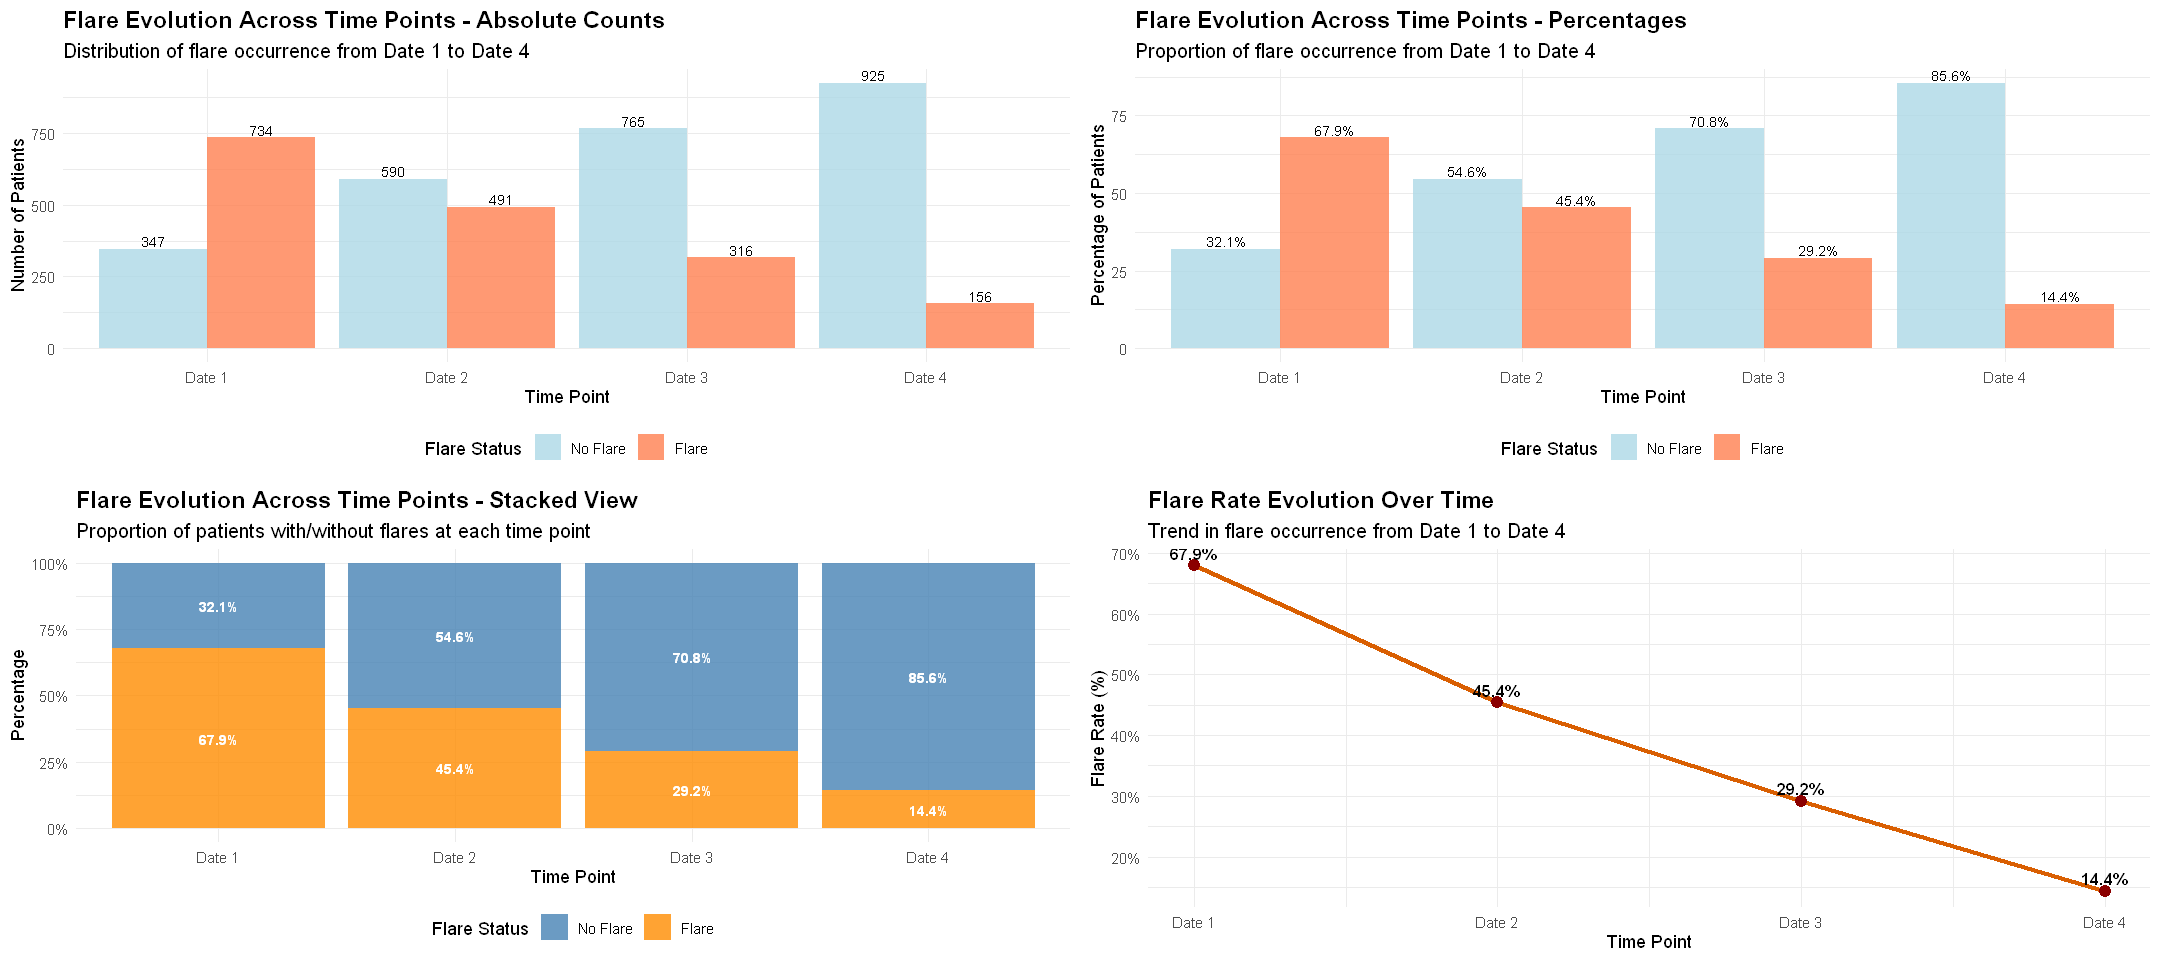

In [48]:
# ===============================================================================
# 1. DEPENDENT VARIABLES ANALYSIS
# ===============================================================================



# Define dependent variables
dependent_vars <- c("flare_date1", "flare_date2", "flare_date3", "flare_date4")

print("=== DEPENDENT VARIABLES ANALYSIS ===")

# Summary of flare variables
flare_summary <- combined_dataset %>%
  dplyr::select(all_of(dependent_vars)) %>%
  dplyr::summarise(across(
    everything(),
    list(
      count_1 = ~sum(. == 1, na.rm = TRUE),
      count_0 = ~sum(. == 0, na.rm = TRUE),
      prop_1 = ~mean(. == 1, na.rm = TRUE),
      missing = ~sum(is.na(.))
    ),
    .names = "{.col}_{.fn}"
  ))

# Prepare flare evolution data
flare_evolution_data <- combined_dataset %>%
  dplyr::select(all_of(dependent_vars)) %>%
  pivot_longer(
    cols = everything(), 
    names_to = "flare_timepoint", 
    values_to = "flare_status"
  ) %>%
  filter(!is.na(flare_status)) %>%
  mutate(
    flare_timepoint = factor(
      flare_timepoint, 
      levels = dependent_vars,
      labels = c("Date 1", "Date 2", "Date 3", "Date 4")
    ),
    flare_status = factor(
      flare_status, 
      levels = c(0, 1),
      labels = c("No Flare", "Flare")
    )
  ) %>%
  group_by(flare_timepoint, flare_status) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(flare_timepoint) %>%
  mutate(
    total = sum(count),
    percentage = round(count / total * 100, 1)
  )

# === Plot 1: Absolute Count ===
  options(repr.plot.width=18, repr.plot.height=8)
flare_evolution_plot_counts <- ggplot(flare_evolution_data, 
                                      aes(x = flare_timepoint, y = count, fill = flare_status)) +
  geom_bar(stat = "identity", position = "dodge", alpha = 0.8) +
  geom_text(aes(label = count), 
            position = position_dodge(width = 0.9), 
            vjust = -0.25, size = 3) +
  scale_fill_manual(values = c("No Flare" = "lightblue", "Flare" = "coral")) +
  labs(title = "Flare Evolution Across Time Points - Absolute Counts",
       subtitle = "Distribution of flare occurrence from Date 1 to Date 4",
       x = "Time Point", 
       y = "Number of Patients",
       fill = "Flare Status") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    plot.subtitle = element_text(size = 12),
    legend.position = "bottom"
  )

# === Plot 2: Percentage ===
flare_evolution_plot_pct <- ggplot(flare_evolution_data, 
                                   aes(x = flare_timepoint, y = percentage, fill = flare_status)) +
  geom_bar(stat = "identity", position = "dodge", alpha = 0.8) +
  geom_text(aes(label = paste0(percentage, "%")), 
            position = position_dodge(width = 0.9), 
            vjust = -0.25, size = 3) +
  scale_fill_manual(values = c("No Flare" = "lightblue", "Flare" = "coral")) +
  labs(title = "Flare Evolution Across Time Points - Percentages",
       subtitle = "Proportion of flare occurrence from Date 1 to Date 4",
       x = "Time Point", 
       y = "Percentage of Patients",
       fill = "Flare Status") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    plot.subtitle = element_text(size = 12),
    legend.position = "bottom"
  )

# === Plot 3: Stacked View ===
flare_evolution_plot_stacked <- ggplot(flare_evolution_data, 
                                       aes(x = flare_timepoint, y = percentage, fill = flare_status)) +
  geom_bar(stat = "identity", position = "stack", alpha = 0.8) +
  geom_text(aes(label = paste0(percentage, "%")), 
            position = position_stack(vjust = 0.5), 
            size = 3, color = "white", fontface = "bold") +
  scale_fill_manual(values = c("No Flare" = "steelblue", "Flare" = "darkorange")) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  labs(title = "Flare Evolution Across Time Points - Stacked View",
       subtitle = "Proportion of patients with/without flares at each time point",
       x = "Time Point", 
       y = "Percentage",
       fill = "Flare Status") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    plot.subtitle = element_text(size = 12),
    legend.position = "bottom"
  )

# === Plot 4: Line Plot ===
flare_rates <- flare_evolution_data %>%
  filter(flare_status == "Flare") %>%
  mutate(timepoint_numeric = as.numeric(flare_timepoint))

flare_evolution_line <- ggplot(flare_rates, aes(x = timepoint_numeric, y = percentage)) +
  geom_line(color =  "#D95F02", size = 1.2) +
  geom_point(color = "darkred", size = 3) +
  geom_text(aes(label = paste0(percentage, "%")), 
            vjust = -0.5, size = 3.5, fontface = "bold") +
  scale_x_continuous(breaks = 1:4, labels = c("Date 1", "Date 2", "Date 3", "Date 4")) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  labs(title = "Flare Rate Evolution Over Time",
       subtitle = "Trend in flare occurrence from Date 1 to Date 4",
       x = "Time Point", 
       y = "Flare Rate (%)") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    plot.subtitle = element_text(size = 12)
  )

# === Display All Plots ===
grid.arrange(
  flare_evolution_plot_counts, flare_evolution_plot_pct, 
  flare_evolution_plot_stacked, flare_evolution_line,
  ncol = 2
)

# === Summary Table ===
print("Flare evolution summary:")
flare_summary_table <- flare_evolution_data %>%
  dplyr::select(flare_timepoint, flare_status, count, percentage) %>%
  pivot_wider(
    names_from = flare_status, 
    values_from = c(count, percentage),
    names_sep = "_"
  ) %>%
  arrange(flare_timepoint)

print(flare_summary_table)


In [49]:
# ===============================================================================
# COMPREHENSIVE SUMMARY TABLES: CATEGORICAL AND NUMERICAL VARIABLES BY FLARE STATUS
# ===============================================================================

library(knitr)
library(kableExtra)

# ===============================================================================
# PART 1: CATEGORICAL VARIABLES
# ===============================================================================

create_categorical_summary_table <- function(df, flare_var) {
  
  # Identify categorical variables (exclude flare variables and patient ID)
  categorical_vars <- names(df)[sapply(df, function(x) is.factor(x) | is.character(x))]
  categorical_vars <- setdiff(categorical_vars, 
                               c("flare_date1", "flare_date2", 
                                 "flare_date3", "flare_date4"))
  
  # Initialize results list
  results_list <- list()
  
  # Loop through each categorical variable
  for (var in categorical_vars) {
    
    # Create contingency table
    tbl <- table(df[[var]], df[[flare_var]], useNA = "no")
    
    # Skip if insufficient data
    if (nrow(tbl) < 1 || ncol(tbl) < 2) {
      next
    }
    
    # Calculate counts and percentages for No Flare (0) and Flare (1)
    no_flare_counts <- tbl[, "0"]
    flare_counts <- tbl[, "1"]
    
    no_flare_total <- sum(no_flare_counts)
    flare_total <- sum(flare_counts)
    
    no_flare_pct <- round(100 * no_flare_counts / no_flare_total, 1)
    flare_pct <- round(100 * flare_counts / flare_total, 1)
    
    # Perform chi-square test
    chisq_result <- tryCatch({
      test <- chisq.test(tbl)
      list(
        statistic = round(test$statistic, 3),
        p_value = ifelse(test$p.value < 0.001, "<0.001", 
                        round(test$p.value, 3))
      )
    }, error = function(e) {
      list(statistic = NA, p_value = NA)
    })
    
    # Create formatted strings
    no_flare_str <- paste0(no_flare_counts, " (", no_flare_pct, "%)")
    flare_str <- paste0(flare_counts, " (", flare_pct, "%)")
    
    # Create data frame for this variable
    var_df <- data.frame(
      Variable = c(var, rep("", length(rownames(tbl)) - 1)),
      Category = rownames(tbl),
      No_Flare = no_flare_str,
      Flare = flare_str,
      ChiSq = c(as.character(chisq_result$statistic), rep("", length(rownames(tbl)) - 1)),
      P_Value = c(as.character(chisq_result$p_value), rep("", length(rownames(tbl)) - 1)),
      stringsAsFactors = FALSE
    )
    
    results_list[[var]] <- var_df
  }
  
  # Combine all results
  final_table <- do.call(rbind, results_list)
  rownames(final_table) <- NULL
  
  # Rename columns
  colnames(final_table) <- c("Variable", "Category", 
                              "No Flare n (%)", "Flare n (%)", 
                              "χ² Statistic", "P-Value")
  
  return(final_table)
}

# ===============================================================================
# PART 2: NUMERICAL VARIABLES
# ===============================================================================

create_numerical_summary_table <- function(df, flare_var) {
  
  # Identify numerical variables (exclude flare variables and IDs)
  numerical_vars <- names(df)[sapply(df, is.numeric)]
  numerical_vars <- setdiff(numerical_vars, 
                            c("flare_date1", "flare_date2", 
                              "flare_date3", "flare_date4"))
  
  # Initialize results list
  results_list <- list()
  
  # Loop through each numerical variable
  for (var in numerical_vars) {
    
    # Extract data
    x <- df[[var]]
    y <- df[[flare_var]]
    
    # Remove NAs
    valid_idx <- !is.na(x) & !is.na(y)
    x_clean <- x[valid_idx]
    y_clean <- y[valid_idx]
    
    # Skip if insufficient data
    if (length(unique(y_clean)) < 2 || length(x_clean) < 3) {
      next
    }
    
    # Calculate mean and SD for No Flare (0)
    no_flare_vals <- x_clean[y_clean == 0]
    no_flare_mean <- mean(no_flare_vals, na.rm = TRUE)
    no_flare_sd <- sd(no_flare_vals, na.rm = TRUE)
    no_flare_str <- paste0(round(no_flare_mean, 2), " (", round(no_flare_sd, 2), ")")
    
    # Calculate mean and SD for Flare (1)
    flare_vals <- x_clean[y_clean == 1]
    flare_mean <- mean(flare_vals, na.rm = TRUE)
    flare_sd <- sd(flare_vals, na.rm = TRUE)
    flare_str <- paste0(round(flare_mean, 2), " (", round(flare_sd, 2), ")")
    
    # Perform t-test
    ttest_result <- tryCatch({
      test <- t.test(x_clean ~ y_clean)
      list(
        statistic = round(test$statistic, 3),
        p_value = ifelse(test$p.value < 0.001, "<0.001", 
                        round(test$p.value, 3))
      )
    }, error = function(e) {
      list(statistic = NA, p_value = NA)
    })
    
    # Create data frame for this variable
    var_df <- data.frame(
      Variable = var,
      No_Flare = no_flare_str,
      Flare = flare_str,
      t_Statistic = as.character(ttest_result$statistic),
      P_Value = as.character(ttest_result$p_value),
      stringsAsFactors = FALSE
    )
    
    results_list[[var]] <- var_df
  }
  
  # Combine all results
  final_table <- do.call(rbind, results_list)
  rownames(final_table) <- NULL
  
  # Rename columns
  colnames(final_table) <- c("Variable", 
                              "No Flare Mean (SD)", "Flare Mean (SD)", 
                              "t Statistic", "P-Value")
  
  return(final_table)
}

# ===============================================================================
# PART 3: GENERATE ALL TABLES
# ===============================================================================




In [50]:
# Create categorical tables for all flare dates
cat_table_date1 <- create_categorical_summary_table(combined_dataset, "flare_date1")
cat_table_date2 <- create_categorical_summary_table(combined_dataset, "flare_date2")
cat_table_date3 <- create_categorical_summary_table(combined_dataset, "flare_date3")
cat_table_date4 <- create_categorical_summary_table(combined_dataset, "flare_date4")

# Create numerical tables for all flare dates
num_table_date1 <- create_numerical_summary_table(combined_dataset, "flare_date1")
num_table_date2 <- create_numerical_summary_table(combined_dataset, "flare_date2")
num_table_date3 <- create_numerical_summary_table(combined_dataset, "flare_date3")
num_table_date4 <- create_numerical_summary_table(combined_dataset, "flare_date4")

In [51]:

# ===============================================================================
# PART 4: DISPLAY TABLES
# ===============================================================================

cat("\n=======================================================================\n")
cat("CATEGORICAL VARIABLES - FLARE DATE 1\n")
cat("=======================================================================\n")
print(kable(cat_table_date1, format = "simple"))

cat("\n=======================================================================\n")
cat("CATEGORICAL VARIABLES - FLARE DATE 2\n")
cat("=======================================================================\n")
print(kable(cat_table_date2, format = "simple"))

cat("\n=======================================================================\n")
cat("CATEGORICAL VARIABLES - FLARE DATE 3\n")
cat("=======================================================================\n")
print(kable(cat_table_date3, format = "simple"))

cat("\n=======================================================================\n")
cat("CATEGORICAL VARIABLES - FLARE DATE 4\n")
cat("=======================================================================\n")
print(kable(cat_table_date4, format = "simple"))

cat("\n=======================================================================\n")
cat("NUMERICAL VARIABLES - FLARE DATE 1\n")
cat("=======================================================================\n")
print(kable(num_table_date1, format = "simple"))

cat("\n=======================================================================\n")
cat("NUMERICAL VARIABLES - FLARE DATE 2\n")
cat("=======================================================================\n")
print(kable(num_table_date2, format = "simple"))

cat("\n=======================================================================\n")
cat("NUMERICAL VARIABLES - FLARE DATE 3\n")
cat("=======================================================================\n")
print(kable(num_table_date3, format = "simple"))

cat("\n=======================================================================\n")
cat("NUMERICAL VARIABLES - FLARE DATE 4\n")
cat("=======================================================================\n")
print(kable(num_table_date4, format = "simple"))



CATEGORICAL VARIABLES - FLARE DATE 1


Variable                     Category   No Flare n (%)   Flare n (%)   χ² Statistic   P-Value 
---------------------------  ---------  ---------------  ------------  -------------  --------
DiseaseEntity                CD         290 (83.6%)      438 (59.7%)   60.119         <0.001  
                             UC         57 (16.4%)       296 (40.3%)                          
gender                       Male       139 (40.1%)      349 (47.5%)   5.039          0.025   
                             Female     208 (59.9%)      385 (52.5%)                          
montreal_extent_uc           1          4 (1.2%)         25 (3.4%)     64.205         <0.001  
                             2          26 (7.5%)        93 (12.7%)                           
                             3          29 (8.4%)        184 (25.1%)                          
                             9999       288 (83%)        432 (58.9%)                          
montreal_s

In [159]:
# ===============================================================================
# PART 6: CREATE COMBINED EXCEL WORKBOOK (OPTIONAL - requires openxlsx)
# ===============================================================================

library(openxlsx)

# Create workbook
wb <- createWorkbook()

# Add categorical sheets
addWorksheet(wb, "Cat_Date1")
writeData(wb, "Cat_Date1", cat_table_date1)

addWorksheet(wb, "Cat_Date2")
writeData(wb, "Cat_Date2", cat_table_date2)

addWorksheet(wb, "Cat_Date3")
writeData(wb, "Cat_Date3", cat_table_date3)

addWorksheet(wb, "Cat_Date4")
writeData(wb, "Cat_Date4", cat_table_date4)

# Add numerical sheets
addWorksheet(wb, "Num_Date1")
writeData(wb, "Num_Date1", num_table_date1)

addWorksheet(wb, "Num_Date2")
writeData(wb, "Num_Date2", num_table_date2)

addWorksheet(wb, "Num_Date3")
writeData(wb, "Num_Date3", num_table_date3)

addWorksheet(wb, "Num_Date4")
writeData(wb, "Num_Date4", num_table_date4)

# Save workbook
saveWorkbook(wb, "Flare_Summary_Tables.xlsx", overwrite = TRUE)

cat("\n✓ Combined Excel workbook created: Flare_Summary_Tables.xlsx\n")



✓ Combined Excel workbook created: Flare_Summary_Tables.xlsx


## 3.2 Factor features

evaluate each predictor variable against your four dependent variables (flare_date1, flare_date2, flare_date3, flare_date4). This will systematically test significance and provide data cleaning recommendations.

In [53]:
summarize_chisq_for_factor <- function(df, predictor, flares = c("flare_date1", "flare_date2", "flare_date3", "flare_date4")) {
  # Treat 9999 as NA
  x_raw <- df[[predictor]]
  x <- factor(ifelse(as.character(x_raw) == "9999", NA, as.character(x_raw)))
  print(table(x, useNA = "ifany"))

  results <- lapply(flares, function(flare) {
    y <- df[[flare]]
    tbl <- table(x, y, useNA = "no")

    if (nrow(tbl) < 2 || ncol(tbl) < 2) {
      return(data.frame(Flare = flare, ChiSq = NA, df = NA, p_value = NA))
    }

    test_result <- suppressWarnings(chisq.test(tbl))

    data.frame(
      Flare = flare,
      ChiSq = round(test_result$statistic, 3),
      df = test_result$parameter,
      p_value = signif(test_result$p.value, 4),
      row.names = NULL  # <-- Ensures no row names
      
    )
  })

  result_df <- do.call(rbind, results)
  cat("\nChi-squared summary for predictor:", predictor, "\n")
  print(result_df)
  invisible(result_df)
}


In [54]:
summarize_chisq_for_factor(combined_dataset, "DiseaseEntity")

x
 CD  UC 
728 353 

Chi-squared summary for predictor: DiseaseEntity 
        Flare  ChiSq df   p_value
1 flare_date1 60.119  1 8.930e-15
2 flare_date2 37.745  1 8.061e-10
3 flare_date3 25.353  1 4.774e-07
4 flare_date4 14.397  1 1.480e-04


In [55]:
summarize_chisq_for_factor(combined_dataset, "gender")

x
Female   Male 
   593    488 

Chi-squared summary for predictor: gender 
        Flare ChiSq df  p_value
1 flare_date1 5.039  1 0.024780
2 flare_date2 4.276  1 0.038650
3 flare_date3 7.113  1 0.007654
4 flare_date4 2.492  1 0.114400


In [56]:
summarize_chisq_for_factor(combined_dataset, "montreal_extent_uc")

x
   1    2    3 <NA> 
  29  119  213  720 

Chi-squared summary for predictor: montreal_extent_uc 
        Flare ChiSq df p_value
1 flare_date1 3.936  2  0.1398
2 flare_date2 1.146  2  0.5639
3 flare_date3 2.681  2  0.2617
4 flare_date4 1.638  2  0.4410


In [57]:
summarize_chisq_for_factor(combined_dataset, "montreal_severity_uc")

x
  0   1   2   3 
764 157 123  37 

Chi-squared summary for predictor: montreal_severity_uc 
        Flare  ChiSq df   p_value
1 flare_date1 49.459  3 1.042e-10
2 flare_date2 27.860  3 3.886e-06
3 flare_date3 25.961  3 9.716e-06
4 flare_date4 18.699  3 3.155e-04


create a binary variable where:

0 = no severity (original value 0) 1 = any severity (original values 1, 2, or 3)

In [58]:
# Recode factor montreal_severity_uc into binary
combined_dataset <- combined_dataset %>%
  mutate(montreal_severity_uc = case_when(
    as.character(montreal_severity_uc) == "0" ~ "0",
    as.character(montreal_severity_uc) %in% c("1", "2", "3") ~ "1",
    TRUE ~ as.character(montreal_severity_uc)  # Keep any other values unchanged
  ))

summarize_chisq_for_factor(combined_dataset, "montreal_severity_uc")
combined_dataset$montreal_severity_uc <- factor(combined_dataset$montreal_severity_uc)

x
  0   1 
764 317 

Chi-squared summary for predictor: montreal_severity_uc 
        Flare  ChiSq df   p_value
1 flare_date1 45.733  1 1.355e-11
2 flare_date2 25.341  1 4.805e-07
3 flare_date3 15.536  1 8.094e-05
4 flare_date4 10.145  1 1.447e-03


In [59]:
summarize_chisq_for_factor(combined_dataset, "montreal_age_cd")

x
   0    1 <NA> 
 507  186  388 

Chi-squared summary for predictor: montreal_age_cd 
        Flare ChiSq df p_value
1 flare_date1 0.437  1  0.5085
2 flare_date2 0.205  1  0.6511
3 flare_date3 0.168  1  0.6822
4 flare_date4 1.500  1  0.2207


In [60]:
summarize_chisq_for_factor(combined_dataset, "surg_colon_resection")

x
   0    1 
1047   34 

Chi-squared summary for predictor: surg_colon_resection 
        Flare ChiSq df p_value
1 flare_date1 0.350  1  0.5538
2 flare_date2 0.000  1  0.9841
3 flare_date3 0.000  1  1.0000
4 flare_date4 1.654  1  0.1984


In [61]:
summarize_chisq_for_factor(combined_dataset, "surg_subtotal_colectomy")

x
   0    1 
1057   24 

Chi-squared summary for predictor: surg_subtotal_colectomy 
        Flare ChiSq df p_value
1 flare_date1 1.528  1  0.2163
2 flare_date2 0.991  1  0.3195
3 flare_date3 0.055  1  0.8149
4 flare_date4 0.000  1  1.0000


In [62]:
summarize_chisq_for_factor(combined_dataset, "surg_fistula_abcess")

x
   0    1 
1002   79 

Chi-squared summary for predictor: surg_fistula_abcess 
        Flare ChiSq df p_value
1 flare_date1 0.618  1  0.4317
2 flare_date2 0.000  1  1.0000
3 flare_date3 0.168  1  0.6822
4 flare_date4 0.000  1  1.0000


In [63]:
summarize_chisq_for_factor(combined_dataset, "surg_ileo_anal_pouch")

x
   0    1 
1074    7 

Chi-squared summary for predictor: surg_ileo_anal_pouch 
        Flare ChiSq df p_value
1 flare_date1 0.042  1  0.8372
2 flare_date2 1.636  1  0.2009
3 flare_date3 1.662  1  0.1974
4 flare_date4 0.303  1  0.5820


In [64]:
summarize_chisq_for_factor(combined_dataset, "surg_small_bowel_resection")

x
   0    1 
1045   36 

Chi-squared summary for predictor: surg_small_bowel_resection 
        Flare ChiSq df p_value
1 flare_date1 2.051  1  0.1521
2 flare_date2 0.084  1  0.7719
3 flare_date3 0.146  1  0.7028
4 flare_date4 1.236  1  0.2662


In [65]:
summarize_chisq_for_factor(combined_dataset, "surg_ileocaecal_resection")

x
  0   1 
963 118 

Chi-squared summary for predictor: surg_ileocaecal_resection 
        Flare ChiSq df  p_value
1 flare_date1 9.332  1 0.002252
2 flare_date2 1.426  1 0.232400
3 flare_date3 0.412  1 0.520800
4 flare_date4 0.022  1 0.883300


In [66]:
summarize_chisq_for_factor(combined_dataset, "surg_small_bowel_stoma")

x
   0    1 
1042   39 

Chi-squared summary for predictor: surg_small_bowel_stoma 
        Flare ChiSq df p_value
1 flare_date1 1.934  1  0.1643
2 flare_date2 1.109  1  0.2924
3 flare_date3 0.001  1  0.9716
4 flare_date4 0.755  1  0.3850


In [67]:
summarize_chisq_for_factor(combined_dataset, "surg_colostoma")

x
   0    1 
1069   12 

Chi-squared summary for predictor: surg_colostoma 
        Flare ChiSq df p_value
1 flare_date1 0.048  1  0.8268
2 flare_date2 0.000  1  1.0000
3 flare_date3 0.000  1  0.9960
4 flare_date4 0.000  1  1.0000


In [68]:
summarize_chisq_for_factor(combined_dataset, "surg_proctocolectomy")

x
   0    1 
1076    5 

Chi-squared summary for predictor: surg_proctocolectomy 
        Flare ChiSq df p_value
1 flare_date1 0.010  1  0.9197
2 flare_date2 2.542  1  0.1108
3 flare_date3 0.898  1  0.3433
4 flare_date4 0.080  1  0.7775


In [69]:
summarize_chisq_for_factor(combined_dataset, "surg_stoma_reversal")

x
   0    1 
1051   30 

Chi-squared summary for predictor: surg_stoma_reversal 
        Flare ChiSq df p_value
1 flare_date1 3.731  1 0.05342
2 flare_date2 0.000  1 1.00000
3 flare_date3 0.088  1 0.76620
4 flare_date4 0.008  1 0.92830


In [70]:
summarize_chisq_for_factor(combined_dataset, "surg_proctectomy")

x
   0    1 
1078    3 

Chi-squared summary for predictor: surg_proctectomy 
        Flare ChiSq df p_value
1 flare_date1 0.329  1  0.5664
2 flare_date2 1.003  1  0.3165
3 flare_date3 0.230  1  0.6318
4 flare_date4 0.000  1  1.0000


In [71]:
summarize_chisq_for_factor(combined_dataset, "surg_stenoplasty")

x
   0    1 
1076    5 

Chi-squared summary for predictor: surg_stenoplasty 
        Flare ChiSq df p_value
1 flare_date1 0.000  1  1.0000
2 flare_date2 0.482  1  0.4876
3 flare_date3 0.898  1  0.3433
4 flare_date4 0.080  1  0.7775


In [72]:
summarize_chisq_for_factor(combined_dataset, "Family_IBD_final")

x
   0    1 <NA> 
 483  102  496 

Chi-squared summary for predictor: Family_IBD_final 
        Flare ChiSq df p_value
1 flare_date1 1.441  1 0.23000
2 flare_date2 3.036  1 0.08143
3 flare_date3 2.085  1 0.14880
4 flare_date4 4.048  1 0.04423


In [73]:
summarize_chisq_for_factor(combined_dataset, "History_colitis")

x
   0    1 <NA> 
 510   42  529 

Chi-squared summary for predictor: History_colitis 
        Flare ChiSq df p_value
1 flare_date1 3.113  1 0.07767
2 flare_date2 2.651  1 0.10350
3 flare_date3 3.316  1 0.06860
4 flare_date4 1.949  1 0.16270


In [74]:
summarize_chisq_for_factor(combined_dataset, "History_crohn")

x
   0    1 <NA> 
 476   75  530 

Chi-squared summary for predictor: History_crohn 
        Flare ChiSq df p_value
1 flare_date1 0.667  1  0.4139
2 flare_date2 0.000  1  1.0000
3 flare_date3 0.545  1  0.4605
4 flare_date4 0.882  1  0.3475


In [75]:
summarize_chisq_for_factor(combined_dataset, "smoker")

x
   1    2    3    4 <NA> 
 433  230  154   43  221 

Chi-squared summary for predictor: smoker 
        Flare  ChiSq df  p_value
1 flare_date1  9.626  3 0.022030
2 flare_date2 11.606  3 0.008863
3 flare_date3  6.387  3 0.094240
4 flare_date4  7.466  3 0.058450


## 3.3 numeric features

In [76]:

library(patchwork)
library(caret)

analyze_numeric_predictor <- function(df, predictor,Process=FALSE, flares = c("flare_date1", "flare_date2", "flare_date3", "flare_date4")) {
  cat("\n========== ANALYSIS FOR:", predictor, "==========\n")

  x_raw <- df[[predictor]]
  if (!is.numeric(x_raw)) {
    cat("Skipping: not a numeric variable.\n")
    return(NULL)
  }

  # Treat 9999 as NA
  x <- ifelse(x_raw == 9999, NA, x_raw)

  ## === 1. Raw histogram ===
    options(repr.plot.width=18, repr.plot.height=6)
  hist(x, main = paste(predictor, "(Raw Histogram)"), xlab = predictor, col = "skyblue", border = "white")

  ## === 2. Histograms and Boxplots ===
  hist_list <- list()
  box_list <- list()

  for (i in seq_along(flares)) {
    flare <- flares[i]
    df_flare <- df %>%
      mutate(
        flare_val = factor(.data[[flare]]),
        predictor_val = ifelse(x_raw == 9999, NA, x_raw)
      ) %>%
      filter(!is.na(predictor_val), !is.na(flare_val))

    # Histogram
      options(repr.plot.width=18, repr.plot.height=6)
    hist_list[[i]] <- ggplot(df_flare, aes(x = predictor_val, fill = flare_val)) +
      geom_histogram(position = "identity", bins = 30, alpha = 0.5) +
      labs(title = paste("Histogram:", flare), fill = flare) +
      theme_minimal()

    # Boxplot
      options(repr.plot.width=18, repr.plot.height=6)
    box_list[[i]] <- ggplot(df_flare, aes(x = flare_val, y = predictor_val)) +
      geom_boxplot(fill = "orange") +
      labs(title = paste("Boxplot:", flare), x = flare, y = predictor) +
      theme_minimal()
  }

  ## === 3. Show plots ===
  cat("\n== Displaying 4 Histograms ==\n")
  print(wrap_plots(hist_list, ncol = 2))

  cat("\n== Displaying 4 Boxplots ==\n")
  print(wrap_plots(box_list, ncol = 2))

  ## === 4. Box-Cox with caret ===
  df_valid <- df %>% select(all_of(flares)) %>% mutate(predictor_val = x)
  df_valid <- df_valid[complete.cases(df_valid), ]

  # Make strictly positive if needed (Box-Cox requires > 0)
  min_val <- min(df_valid$predictor_val, na.rm = TRUE)
  if (min_val <= 0) {
    df_valid$predictor_val <- df_valid$predictor_val + abs(min_val) + 1
  }

  # Apply Box-Cox via caret
  pp <- preProcess(as.data.frame(df_valid$predictor_val), method =  c("BoxCox", "center", "scale"))
  df_valid$predictor_boxcox <- predict(pp, as.data.frame(df_valid$predictor_val))[[1]]

  ## === 5. T-tests ===
  t_results <- lapply(flares, function(flare) {
    y <- df_valid[[flare]]
    if (length(unique(y)) != 2) return(NULL)
    test <- t.test(df_valid$predictor_boxcox ~ y)
    data.frame(
      Dependent = flare,
      t_stat = round(test$statistic, 3),
      df = round(test$parameter, 1),
      p_value = format.pval(test$p.value, digits = 4, eps = .0001),
      row.names = NULL 
    )
  })

  t_table <- do.call(rbind, t_results)
  cat("\n== T-test Results on Box-Cox Transformed Predictor ==\n")
  print(t_table, row.names = FALSE)
  
  
  ## === 6. Replace raw predictor with processed values in df ===
  if (Process) {
    transformed_full <- rep(NA, nrow(df))
    transformed_full[as.numeric(rownames(df_valid))] <- df_valid$predictor_boxcox
    #df[[predictor]] <- transformed_full
    return(transformed_full)
  }

  # If not processing, return df unchanged invisibly
  
}


Attaching package: 'patchwork'


The following object is masked from 'package:MASS':

    area


Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift




## 3.4 Missing Data Handling

Multiple imputation using MICE with appropriate methods:

- Logistic regression for binary variables (Family_IBD_final, History_colitis, etc.)
- Polytomous regression for multi-category variables (smoker status)
- Predictive mean matching (PMM) for continuous variables (BMI)

which variable contains na:


In [77]:
str(combined_dataset[colSums(is.na(combined_dataset))>1])


tibble [1,081 × 6] (S3: tbl_df/tbl/data.frame)
 $ bmi             : num [1:1081] 24.6 21.6 22.7 23.9 41.4 ...
 $ montreal_age_cd : num [1:1081] 0 1 1 0 NA 0 NA 1 NA NA ...
 $ Family_IBD_final: Factor w/ 2 levels "0","1": NA 1 NA NA NA 1 1 NA NA 2 ...
 $ History_colitis : Factor w/ 2 levels "0","1": NA 1 NA NA NA 1 NA NA NA 2 ...
 $ History_crohn   : Factor w/ 2 levels "0","1": NA 1 NA NA NA 1 NA NA NA 1 ...
 $ smoker          : Factor w/ 4 levels "1","2","3","4": 3 3 2 NA NA 3 1 1 1 1 ...


In [78]:
print(colMeans(is.na(combined_dataset[colSums(is.na(combined_dataset))>1])))

             bmi  montreal_age_cd Family_IBD_final  History_colitis 
       0.1341351        0.3589269        0.4588344        0.4893617 
   History_crohn           smoker 
       0.4902868        0.2044403 


High missing values in:
 - montreal_age_cd: 36%
 - Family_IBD_final: 46%
 - History_colitis: 49%
 - History_crohn : 49%
 - smoker: 20%
 -  bmi : 13%
 
   

In [79]:
# remove vars with na >5%
combined_dataset$montreal_age_cd <-  NULL
combined_dataset$Family_IBD_final <-  NULL
combined_dataset$History_colitis <-  NULL
combined_dataset$History_crohn <-  NULL


In [80]:

combined_dataset <- combined_dataset %>%
  mutate(smoker = ifelse(smoker %in% c(3, 4), 3, smoker))

combined_dataset$smoker <- factor(
  combined_dataset$smoker,
  levels = c(1, 2, 3),
  labels = c("Never", "Former", "Current")
)



Attaching package: 'mice'


The following object is masked from 'package:stats':

    filter


The following objects are masked from 'package:base':

    cbind, rbind




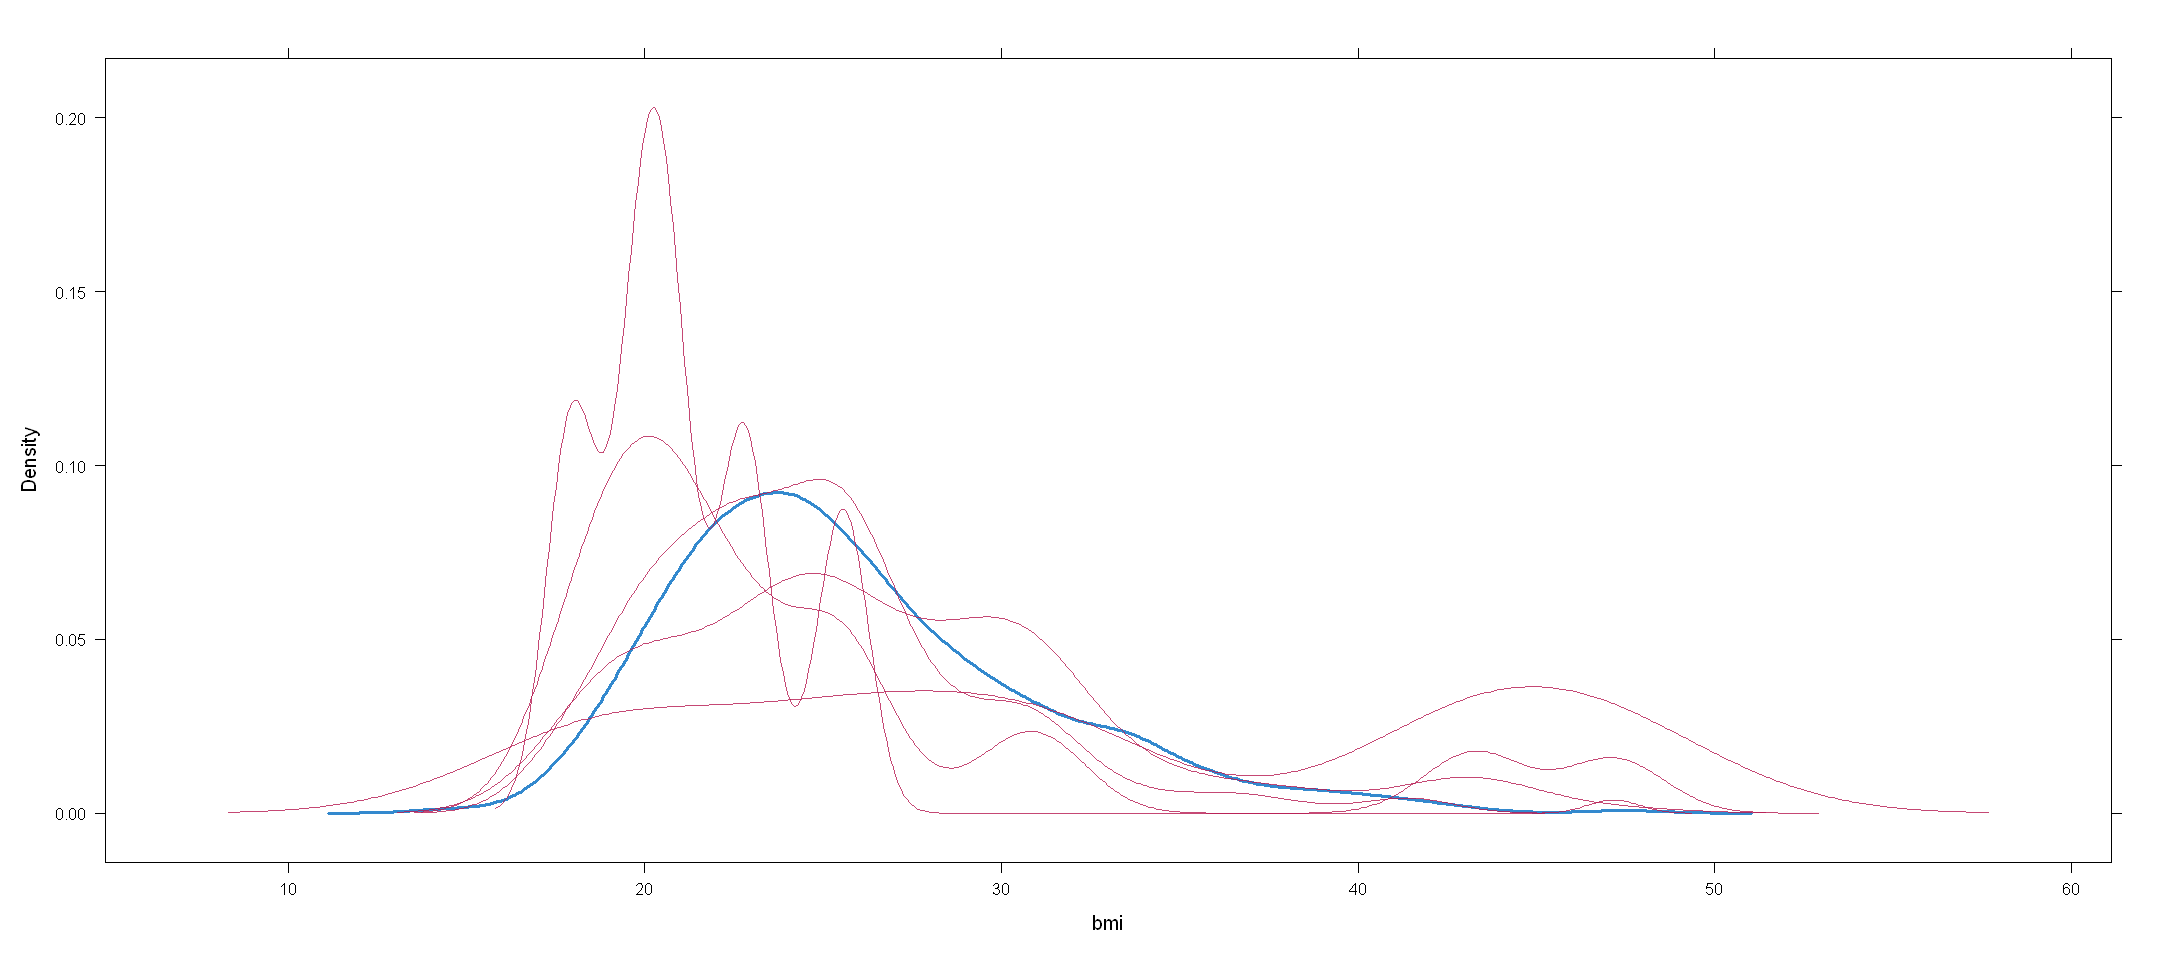

In [81]:
library(mice)

# Initialize mice to get default methods
init <- mice(combined_dataset, maxit = 0)
method <- init$method
predictorMatrix <- init$predictorMatrix

# Set all variables to not be imputed by default
method[] <- ""

# Multi-category variables - use polyreg
method["smoker"] <- "polyreg"              # 1, 2, 3, 4 (4 categories)


# Set imputation methods for numerical variables
# Use pmm (predictive mean matching) for numerical variables
method["bmi"] <- "pmm"


# Perform imputation
imputed_data <- mice(combined_dataset, 
                     method = method,
                     m = 5,           # 5 imputed datasets
                     maxit = 30,      # 10 iterations
                     seed = 123,      # reproducibility
                     printFlag = FALSE
                     )

# Get completed dataset (first imputation)
combined_dataset_imputed <- complete(imputed_data, 1)


# Check imputed values
densityplot(imputed_data)

## 3.5. Variable Transformation and Selection

This chunk constructs a standardized, disease-aware composite score that integrates objective clinical severity and subjective symptom burden into a single interpretable measure of overall disease impact, improving both clinical validity and predictive stability.

In [82]:
# ==============================================================================
# DISEASE BURDEN COMPOSITE SCORE
# ==============================================================================

combined_dataset_imputed <- combined_dataset_imputed %>%
  mutate(
    # Standardize each component (z-score) before combining
    # This ensures each component contributes equally
    
    # UC severity component (only for UC patients)
    severity_uc_std = ifelse(
      DiseaseEntity == "UC",
      scale(as.numeric(as.character(montreal_severity_uc)))[,1],
      0
    ),
    
    # CD surgery component (only for CD patients)
    surgery_cd_std = ifelse(
      DiseaseEntity == "CD",
      scale(as.numeric(as.character(surg_ileocaecal_resection)))[,1],
      0
    ),
    
    # Universal components (both UC and CD)
    fatigue_std = scale(Fatigue_mean)[,1],
    pain_std = scale(Pain_mean)[,1],
    
    # Composite disease burden score
    # Average of standardized components
    disease_burden_score = (
      abs(severity_uc_std) + 
      abs(surgery_cd_std) + 
      abs(fatigue_std) + 
      abs(pain_std)
    ) / 4
  )

### 3.5.1 Categorization Strategy

Continuous variables undergo systematic evaluation using four categorization schemes:

- Tertiles (Low/Medium/High)
- Quartiles (Q1/Q2/Q3/Q4)
- Median split (Low/High)
- Top 25% (Normal/High)

Chi-square tests determine which categorization best predicts each outcome.

In [83]:
# Main function to categorize and test a numerical predictor 
categorize_and_test_predictor <- function(data, predictor_name, outcomes) {
  
  cat("\n", strrep("=", 80), "\n")
  cat("PROCESSING:", predictor_name, "\n")
  cat(strrep("=", 80), "\n\n")
  
  # Extract the predictor
  predictor <- data[[predictor_name]]
  
  # Check for unique values
  n_unique <- length(unique(na.omit(predictor)))
  n_valid <- sum(!is.na(predictor))
  cat("Number of unique values:", n_unique, "\n")
  cat("Number of valid observations:", n_valid, "\n")
  
  if(n_unique < 2 || n_valid < 10) {
    cat("\nWARNING: Insufficient data for categorization\n")
    return(NULL)
  }
  
  # Overall summary statistics
  cat("\nOverall summary statistics:\n")
  print(summary(predictor))
  
  # ==============================================================================
  # Safe cut function
  # ==============================================================================
  
  safe_cut <- function(x, breaks, labels = NULL, include.lowest = TRUE, right = TRUE) {
    breaks_unique <- unique(breaks)
    if(length(breaks_unique) <= 2) {
      return(rep(NA, length(x)))
    }
    if(!is.null(labels) && length(labels) != (length(breaks_unique) - 1)) {
      labels <- NULL
    }
    
    result <- cut(x, breaks = breaks_unique, labels = labels, 
                 include.lowest = include.lowest, right = right)
    
    return(result)
  }
  
  # ==============================================================================
  # Create temporary data with all categorizations
  # ==============================================================================
  
  temp_data <- data %>%
    mutate(
      predictor = !!sym(predictor_name),
      
      # Quantile-based categorizations
      cat_q3 = safe_cut(
        predictor,
        breaks = quantile(predictor, probs = c(0, 1/3, 2/3, 1), na.rm = TRUE),
        labels = c("Low", "Medium", "High")
      ),
      
      cat_q4 = safe_cut(
        predictor,
        breaks = quantile(predictor, probs = c(0, 0.25, 0.5, 0.75, 1), na.rm = TRUE),
        labels = c("Q1", "Q2", "Q3", "Q4")
      ),
      
      cat_median = safe_cut(
        predictor,
        breaks = c(-Inf, median(predictor, na.rm = TRUE), Inf),
        labels = c("Low", "High")
      ),
      
      cat_top25 = safe_cut(
        predictor,
        breaks = c(-Inf, quantile(predictor, 0.75, na.rm = TRUE), Inf),
        labels = c("Normal", "High")
      )
    )
  
  # ==============================================================================
  # Identify valid categorizations
  # ==============================================================================
  
  cat_vars <- grep("^cat_", names(temp_data), value = TRUE)
  valid_cats <- c()
  
  cat("\n=== CATEGORIZATION DISTRIBUTIONS ===\n")
  for(cat_var in cat_vars) {
    tbl <- table(temp_data[[cat_var]], useNA = "ifany")
    n_categories <- length(unique(na.omit(temp_data[[cat_var]])))
    n_obs <- sum(!is.na(temp_data[[cat_var]]))
    
    if(n_categories >= 2 && n_obs >= 10) {
      cat("\n", cat_var, ":\n")
      print(tbl)
      valid_cats <- c(valid_cats, cat_var)
    } else {
      cat("\n", cat_var, ": SKIPPED (insufficient categories or data)\n")
    }
  }
  
  if(length(valid_cats) == 0) {
    cat("\nERROR: No valid categorizations created\n")
    return(NULL)
  }
  
  # ==============================================================================
  # Chi-square testing function
  # ==============================================================================
  
  compute_chisq <- function(data, cat_var, outcome) {
    
    # Filter out any remaining missing values
    test_data <- data %>%
      filter(!is.na(.data[[cat_var]]), !is.na(.data[[outcome]]))
    
    if(nrow(test_data) < 10) return(NULL)
    
    tbl <- table(test_data[[cat_var]], test_data[[outcome]])
    
    # Remove categories with 0 observations
    if(any(rowSums(tbl) == 0)) {
      tbl <- tbl[rowSums(tbl) > 0, , drop = FALSE]
    }
    if(any(colSums(tbl) == 0)) {
      tbl <- tbl[, colSums(tbl) > 0, drop = FALSE]
    }
    
    if (min(dim(tbl)) > 0 && all(rowSums(tbl) > 0) && all(colSums(tbl) > 0)) {
      test <- tryCatch({
        chisq.test(tbl)
      }, warning = function(w) {
        if(prod(dim(tbl)) <= 4 && all(tbl < 1000)) {
          fisher.test(tbl, simulate.p.value = TRUE, B = 10000)
        } else {
          chisq.test(tbl)
        }
      }, error = function(e) {
        cat("Error in chi-square test for", cat_var, "vs", outcome, ":", e$message, "\n")
        return(NULL)
      })
      
      if(!is.null(test)) {
        return(data.frame(
          predictor = predictor_name,
          categorization = cat_var,
          outcome = outcome,
          chi_sq = ifelse("statistic" %in% names(test), round(test$statistic, 3), NA),
          df = ifelse("parameter" %in% names(test), test$parameter, NA),
          p_value = test$p.value,
          p_formatted = ifelse(test$p.value < 0.001, "< 0.001", 
                              sprintf("%.4f", test$p.value)),
          n = nrow(test_data)
        ))
      }
    }
    return(NULL)
  }
  
  # ==============================================================================
  # Test all categorizations against all outcomes
  # ==============================================================================
  
  results <- expand.grid(
    cat_var = valid_cats,
    outcome = outcomes,
    stringsAsFactors = FALSE
  ) %>%
    rowwise() %>%
    do({
      compute_chisq(temp_data, .$cat_var, .$outcome)
    }) %>%
    ungroup() %>%
    filter(!is.na(p_value)) %>%
    arrange(outcome, p_value)
  
  cat("\n=== CHI-SQUARE TEST RESULTS ===\n")
  print(results)
  
  # Find best categorization for each outcome
  
  best_by_outcome <- results %>%
    group_by(outcome) %>%
    slice_min(p_value, n = 1) %>%
    ungroup()
  
  cat("\n=== BEST CATEGORIZATION FOR EACH OUTCOME ===\n")
  print(best_by_outcome)
  
  # Create detailed crosstabs for best categorizations
  
  cat("\n=== DETAILED CROSSTABS FOR BEST CATEGORIZATIONS ===\n")
  
  crosstabs_list <- list()
  
  for(i in 1:nrow(best_by_outcome)) {
    outcome <- best_by_outcome$outcome[i]
    cat_var <- best_by_outcome$categorization[i]
    
    cat("\n", strrep("-", 80), "\n")
    cat("OUTCOME:", outcome, "| CATEGORIZATION:", cat_var, "\n")
    cat("p-value:", best_by_outcome$p_formatted[i], "| N:", best_by_outcome$n[i], "\n")
    cat(strrep("-", 80), "\n\n")
    
    tbl <- table(temp_data[[cat_var]], temp_data[[outcome]], useNA = "ifany")
    cat("Frequency table:\n")
    print(tbl)
    
    cat("\nRow proportions (% within each category):\n")
    row_props <- round(prop.table(tbl, margin = 1) * 100, 1)
    print(row_props)
    
    crosstabs_list[[outcome]] <- list(
      table = tbl,
      row_proportions = row_props
    )
  }
  
  # ==============================================================================
  # Return results
  # ==============================================================================
  
  return(list(
    predictor_name = predictor_name,
    summary_stats = summary(predictor),
    n_unique = n_unique,
    n_valid = n_valid,
    all_results = results,
    best_by_outcome = best_by_outcome,
    crosstabs = crosstabs_list
    ))
  
}


# Helper function to add best categorizations to main dataset

# Define the function with error handling
add_best_categorizations <- function(data, predictor_name, best_cat) {
  
  if(is.null(best_cat)) {
    message("No categorization results provided")
    return(data)
  }
  
  # Extract the predictor values
  predictor <- data[[predictor_name]]
  
  # Check for sufficient unique values
  n_unique <- length(unique(na.omit(predictor)))
  if(n_unique < 2) {
    warning("Predictor '", predictor_name, "' has fewer than 2 unique values. Cannot categorize.")
    return(data)
  }
  
  # Safe cut function that checks for unique breaks
  safe_cut <- function(x, breaks, labels, include.lowest = TRUE, right = TRUE) {
    breaks_unique <- unique(breaks)
    
    if(length(breaks_unique) < 2) {
      warning("Not enough unique break points for categorization")
      return(rep(NA, length(x)))
    }
    
    # If we don't have enough unique breaks for the labels, adjust
    if(!is.null(labels) && length(labels) != (length(breaks_unique) - 1)) {
      warning("Adjusting labels due to non-unique quantiles")
      labels <- NULL  # Let cut() generate default labels
    }
    
    result <- cut(x, 
                  breaks = breaks_unique, 
                  labels = labels,
                  include.lowest = include.lowest, 
                  right = right)
    
    return(result)
  }
  
  # Apply the appropriate categorization based on best_cat
  if(best_cat == "cat_q3") {
    breaks <- quantile(predictor, probs = c(0, 1/3, 2/3, 1), na.rm = TRUE)
    data[[predictor_name]] <- safe_cut(
      predictor,
      breaks = breaks,
      labels = c("Low", "Medium", "High")
    )
    message("Applied cat_q3 categorization to ", predictor_name)
    
  } else if(best_cat == "cat_q4") {
    breaks <- quantile(predictor, probs = c(0, 0.25, 0.5, 0.75, 1), na.rm = TRUE)
    data[[predictor_name]] <- safe_cut(
      predictor,
      breaks = breaks,
      labels = c("Q1", "Q2", "Q3", "Q4")
    )
    message("Applied cat_q4 categorization to ", predictor_name)
    
  } else if(best_cat == "cat_median") {
    breaks <- c(-Inf, median(predictor, na.rm = TRUE), Inf)
    data[[predictor_name]] <- safe_cut(
      predictor,
      breaks = breaks,
      labels = c("Low", "High")
    )
    message("Applied cat_median categorization to ", predictor_name)
    
  } else if(best_cat == "cat_top25") {
    breaks <- c(-Inf, quantile(predictor, 0.75, na.rm = TRUE), Inf)
    data[[predictor_name]] <- safe_cut(
      predictor,
      breaks = breaks,
      labels = c("Normal", "High")
    )
    message("Applied cat_top25 categorization to ", predictor_name)
    
  } else {
    message("Unknown categorization type: ", best_cat)
    message("Valid options: cat_q3, cat_q4, cat_median, cat_top25")
  }
  
  return(data)
}

flare_outcomes <- c("flare_date1", "flare_date2", "flare_date3", "flare_date4")

#### disease_burden_score


PROCESSING: disease_burden_score 

Number of unique values: 237 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1186  0.4695  0.6685  0.6756  0.8635  1.5429 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

   Low Medium   High 
   366    358    357 

 cat_q4 :

 Q1  Q2  Q3  Q4 
274 374 175 258 

 cat_median :

 Low High 
 648  433 

 cat_top25 :

Normal   High 
   823    258 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor      categorization outcome chi_sq    df  p_value p_formatted     n
   <chr>          <chr>          <chr>    <dbl> <int>    <dbl> <chr>       <int>
 1 disease_burde… cat_q3         flare_… 14.3       2 7.69e- 4 < 0.001      1081
 2 disease_burde… cat_median     flare_…  0.217     1 6.41e- 1 0.6410       1081
 3 disease_burde… cat_top25      flare_…  0.066     1 7.97e- 1 0.7971       1081
 4 disease_burde… cat_q4         flare_…  0.504     3 9.18e- 1 0.9181       1081
 5 disease

Applied cat_q3 categorization to disease_burden_score



x
  High    Low Medium 
   357    366    358 

Chi-squared summary for predictor: disease_burden_score 
        Flare  ChiSq df   p_value
1 flare_date1 14.340  2 7.694e-04
2 flare_date2 42.386  2 6.252e-10
3 flare_date3 42.395  2 6.223e-10
4 flare_date4 34.762  2 2.829e-08


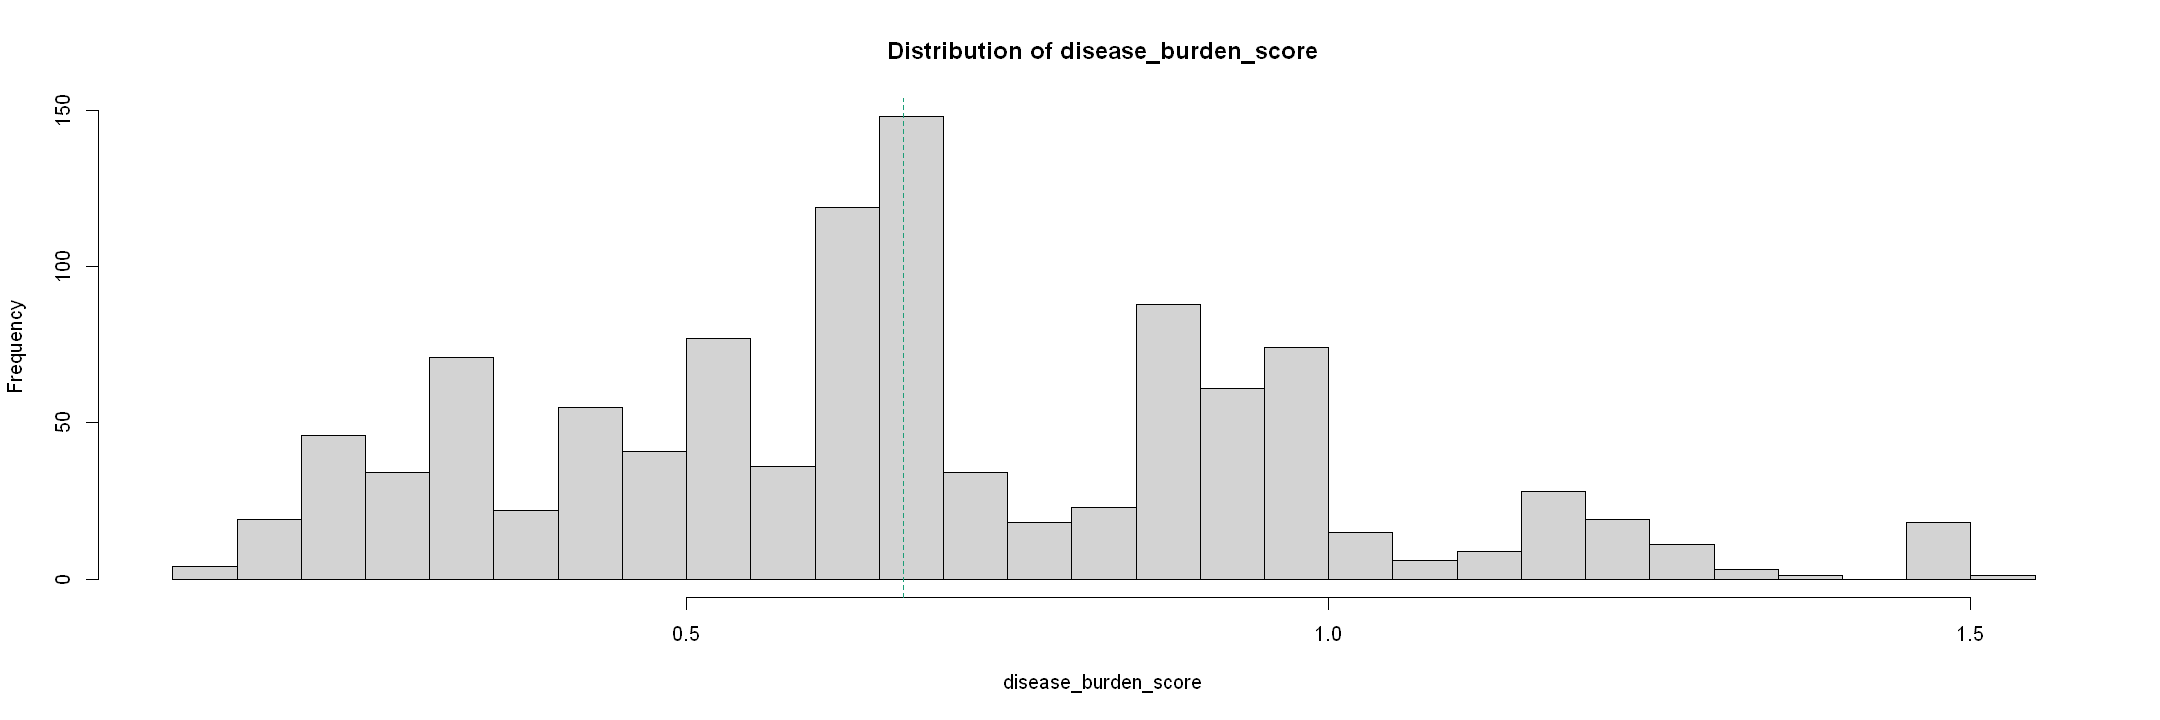

In [84]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$disease_burden_score, breaks = 30, 
     main = "Distribution of disease_burden_score",
     xlab = "disease_burden_score")
abline(v = c(0, median(combined_dataset_imputed$disease_burden_score, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "disease_burden_score",
  outcomes = flare_outcomes
)


# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "disease_burden_score",  
                                                     best_cat= "cat_q3"  )


summarize_chisq_for_factor(combined_dataset_imputed, "disease_burden_score")

#### age_at_inclusion



PROCESSING: age_at_inclusion 

Number of unique values: 1053 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1944 35.2389 46.6886 47.1564 59.0582 87.2882 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

   Low Medium   High 
   361    360    360 

 cat_q4 :

 Q1  Q2  Q3  Q4 
271 270 270 270 

 cat_median :

 Low High 
 541  540 

 cat_top25 :

Normal   High 
   811    270 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor       categorization outcome chi_sq    df p_value p_formatted     n
   <chr>           <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
 1 age_at_inclusi… cat_q4         flare_…  6.69      3 8.26e-2 0.0826       1081
 2 age_at_inclusi… cat_q3         flare_…  2.46      2 2.92e-1 0.2921       1081
 3 age_at_inclusi… cat_top25      flare_…  0.862     1 3.53e-1 0.3531       1081
 4 age_at_inclusi… cat_median     flare_…  0.579     1 4.47e-1 0.4467       1081
 5 age_at_inc

Applied cat_q4 categorization to age_at_inclusion



x
 Q1  Q2  Q3  Q4 
271 270 270 270 

Chi-squared summary for predictor: age_at_inclusion 
        Flare  ChiSq df   p_value
1 flare_date1  6.686  3 8.262e-02
2 flare_date2 24.172  3 2.299e-05
3 flare_date3 22.923  3 4.191e-05
4 flare_date4 22.739  3 4.576e-05


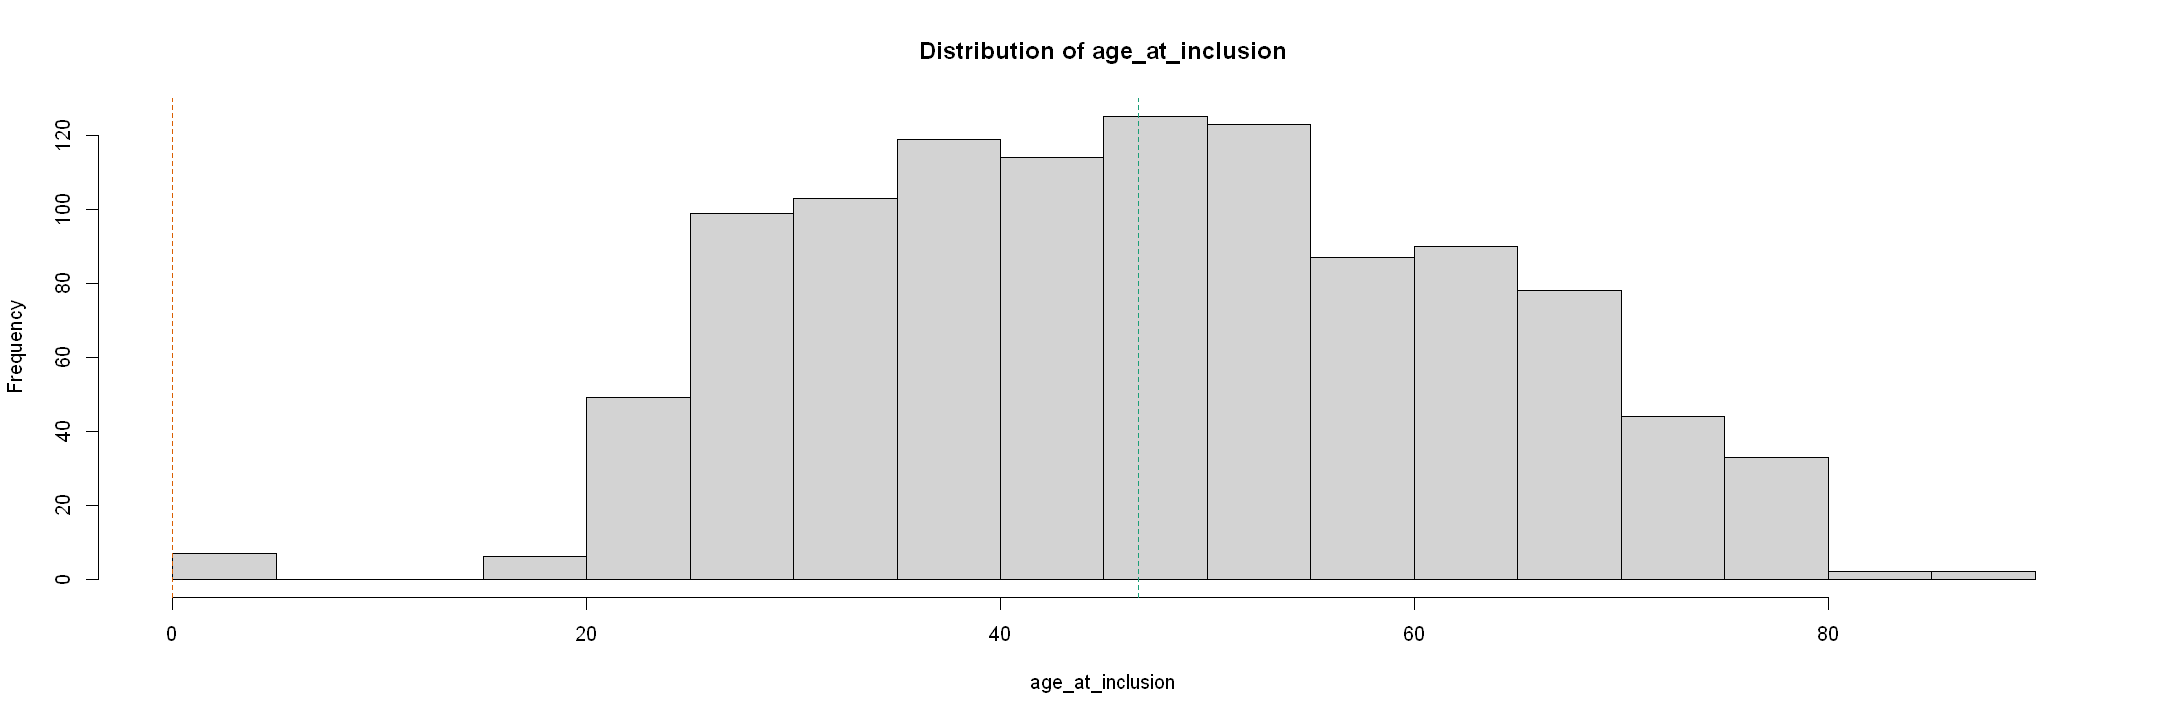

In [85]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_inclusion, breaks = 30, 
     main = "Distribution of age_at_inclusion",
     xlab = "age_at_inclusion")
abline(v = c(0, median(combined_dataset_imputed$age_at_inclusion, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_inclusion",
  outcomes = flare_outcomes
)


# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "age_at_inclusion",  
                                                     best_cat= "cat_q4"  )


summarize_chisq_for_factor(combined_dataset_imputed, "age_at_inclusion")

#### bmi


PROCESSING: bmi 

Number of unique values: 706 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  14.37   21.48   24.38   25.21   27.77   47.78 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

   Low Medium   High 
   361    360    360 

 cat_q4 :

 Q1  Q2  Q3  Q4 
272 270 269 270 

 cat_median :

 Low High 
 542  539 

 cat_top25 :

Normal   High 
   811    270 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor categorization outcome     chi_sq    df p_value p_formatted     n
   <chr>     <chr>          <chr>        <dbl> <int>   <dbl> <chr>       <int>
 1 bmi       cat_q4         flare_date1  6.05      3  0.109  0.1091       1081
 2 bmi       cat_top25      flare_date1  0.332     1  0.564  0.5643       1081
 3 bmi       cat_q3         flare_date1  0.819     2  0.664  0.6639       1081
 4 bmi       cat_median     flare_date1  0.108     1  0.743  0.7428       1081
 5 bmi       cat_median     flare_date2

Applied cat_q3 categorization to bmi



x
  High    Low Medium 
   360    361    360 

Chi-squared summary for predictor: bmi 
        Flare ChiSq df p_value
1 flare_date1 0.819  2  0.6639
2 flare_date2 0.050  2  0.9751
3 flare_date3 2.067  2  0.3558
4 flare_date4 2.798  2  0.2468


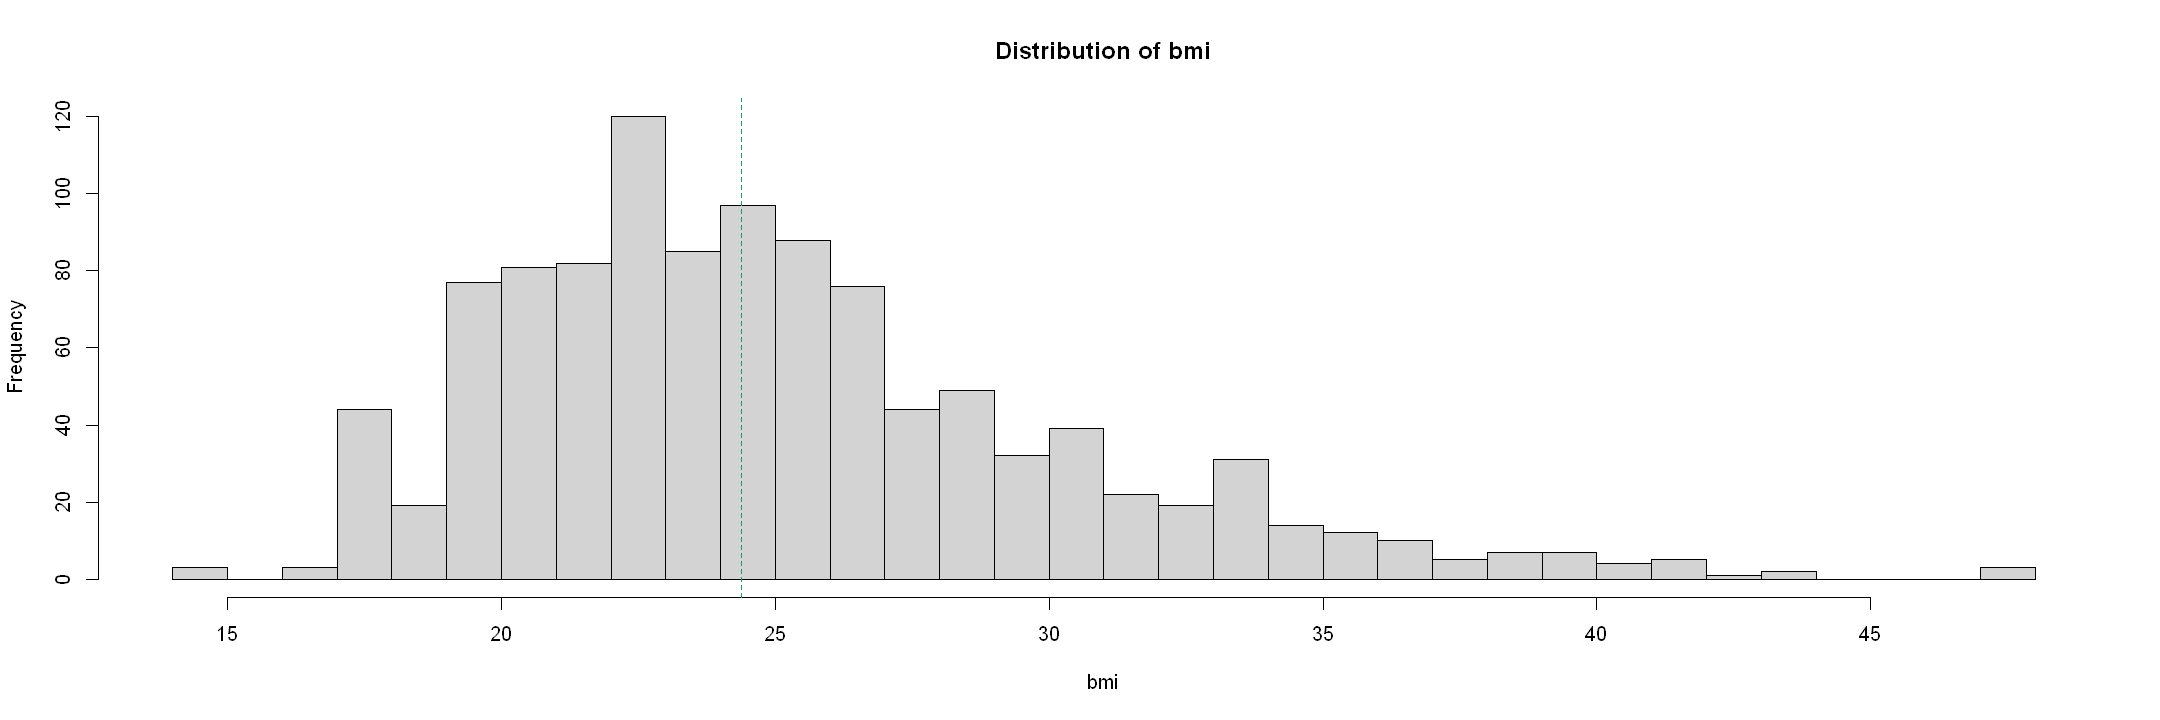

In [86]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$bmi, breaks = 30, 
     main = "Distribution of bmi",
     xlab = "bmi")
abline(v = c(0, median(combined_dataset_imputed$bmi, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "bmi",
  outcomes = flare_outcomes
)


# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "bmi",  
                                                     best_cat= "cat_q3"  )


summarize_chisq_for_factor(combined_dataset_imputed, "bmi")

#### number_of_surgeries

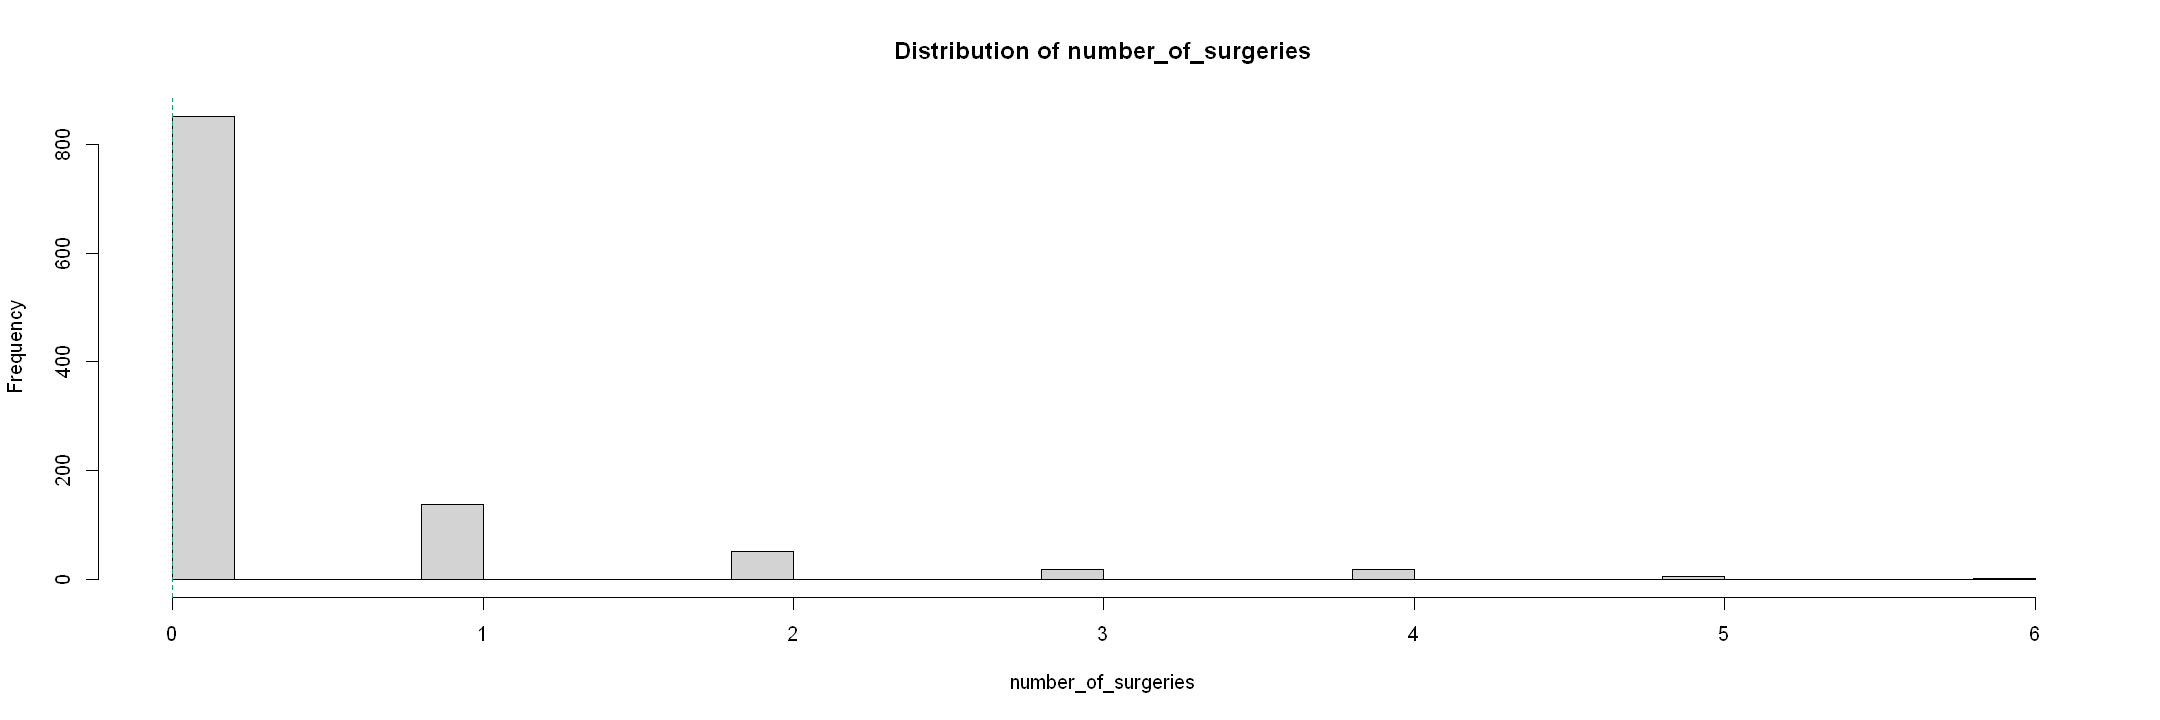

In [87]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$number_of_surgeries, breaks = 30, 
     main = "Distribution of number_of_surgeries",
     xlab = "number_of_surgeries")
abline(v = c(0, median(combined_dataset_imputed$number_of_surgeries, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)




combined_dataset_imputed$number_of_surgeries <- ifelse(combined_dataset_imputed$number_of_surgeries==0,0,1)

#### age_at_surg_colon_resection


PROCESSING: age_at_surg_colon_resection 

Number of unique values: 35 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.262   0.000  73.985 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1047   34 

 cat_top25 :

Normal   High 
  1047     34 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_col… cat_median     flare_…   0.35     1   0.554 0.5538       1081
2 age_at_surg_col… cat_top25      flare_…   0.35     1   0.554 0.5538       1081
3 age_at_surg_col… cat_median     flare_…   0        1   0.984 0.9841       1081
4 age_at_surg_col… cat_top25      flare_…   0        1   0.984 0.9841       1081
5

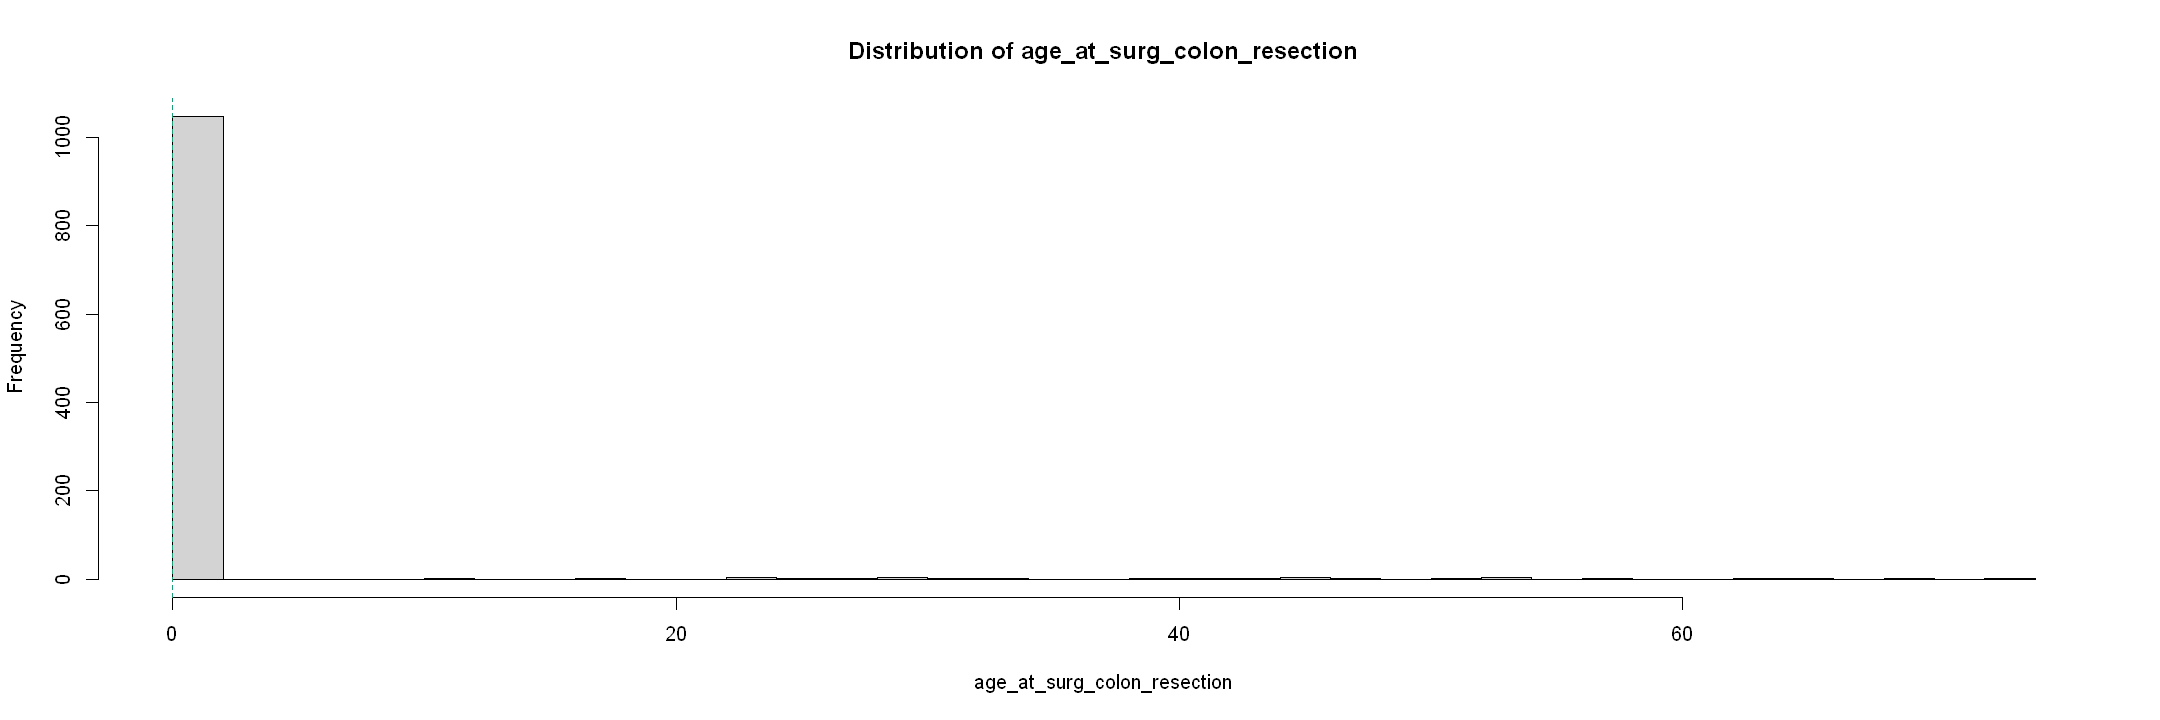

In [88]:

# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_colon_resection, breaks = 30, 
     main = "Distribution of age_at_surg_colon_resection",
     xlab = "age_at_surg_colon_resection")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_colon_resection, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_colon_resection",
  outcomes = flare_outcomes
)
combined_dataset_imputed$age_at_surg_colon_resection <- scale(combined_dataset_imputed$age_at_surg_colon_resection)

#### age_at_surg_subtotal_colectomy


PROCESSING: age_at_surg_subtotal_colectomy 

Number of unique values: 25 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   0.724   0.000  55.568 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1057   24 

 cat_top25 :

Normal   High 
  1057     24 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_sub… cat_median     flare_…  1.53      1   0.216 0.2163       1081
2 age_at_surg_sub… cat_top25      flare_…  1.53      1   0.216 0.2163       1081
3 age_at_surg_sub… cat_median     flare_…  0.991     1   0.320 0.3195       1081
4 age_at_surg_sub… cat_top25      flare_…  0.991     1   0.320 0.3195       108

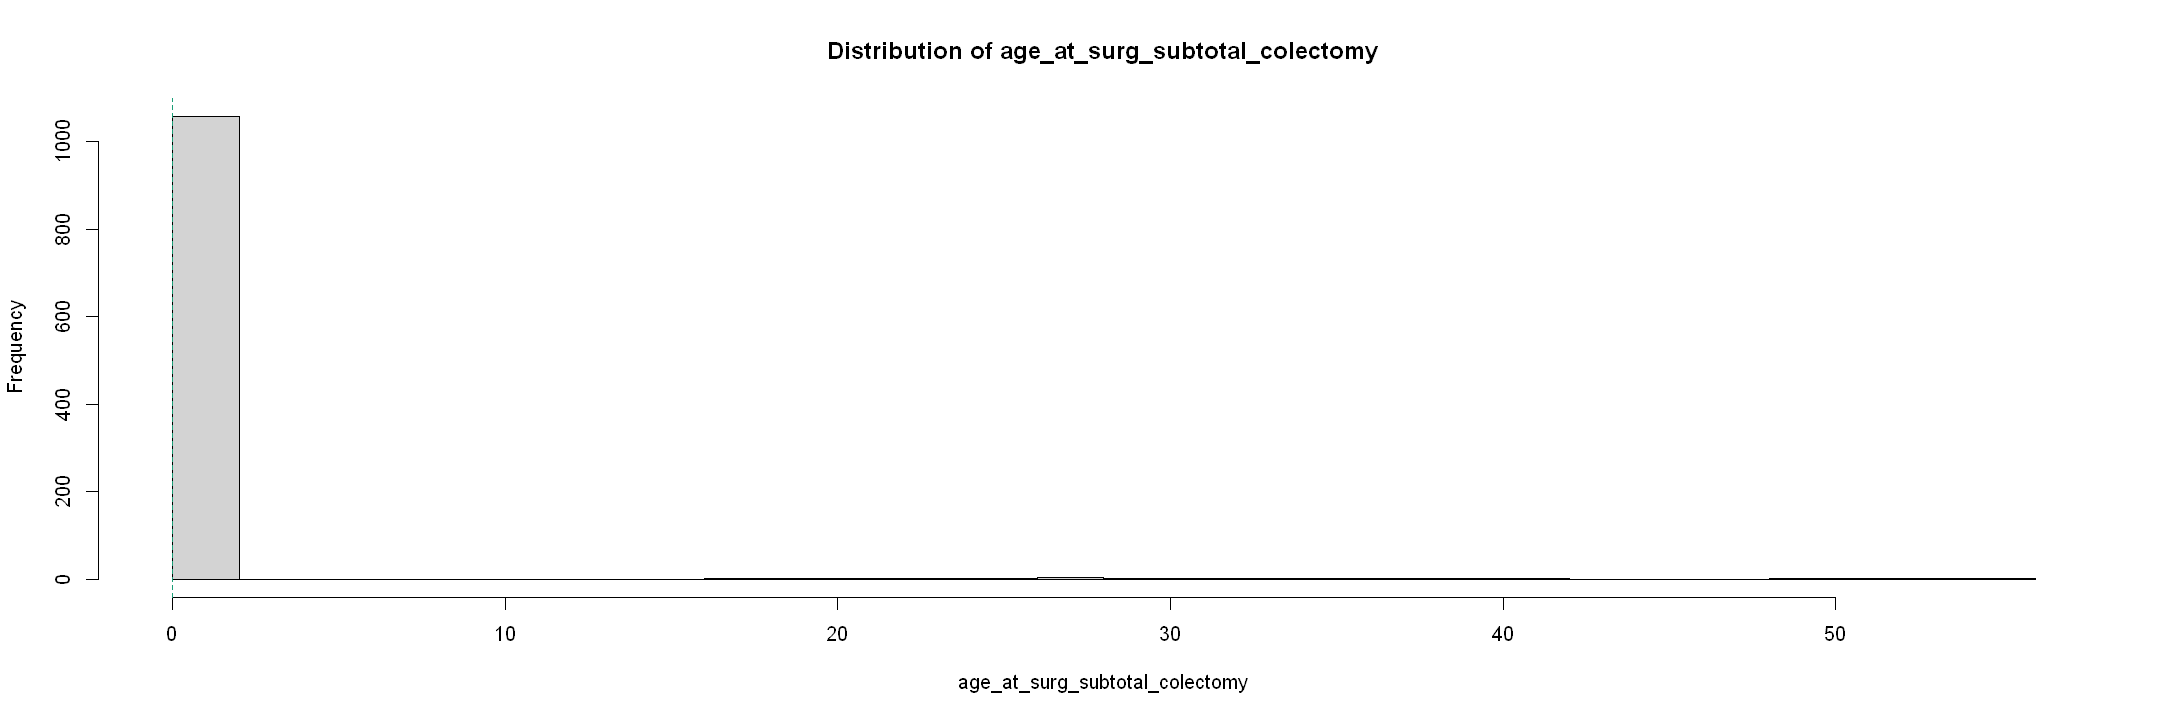

In [89]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_subtotal_colectomy, breaks = 30, 
     main = "Distribution of age_at_surg_subtotal_colectomy",
     xlab = "age_at_surg_subtotal_colectomy")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_subtotal_colectomy, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_subtotal_colectomy",
  outcomes = flare_outcomes
)
combined_dataset_imputed$age_at_surg_subtotal_colectomy <- scale(combined_dataset_imputed$age_at_surg_subtotal_colectomy)


#### age_at_surg_fistula_abcess


PROCESSING: age_at_surg_fistula_abcess 

Number of unique values: 80 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   2.574   0.000  70.680 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1002   79 

 cat_top25 :

Normal   High 
  1002     79 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_fis… cat_median     flare_…  0.618     1   0.432 0.4317       1081
2 age_at_surg_fis… cat_top25      flare_…  0.618     1   0.432 0.4317       1081
3 age_at_surg_fis… cat_median     flare_…  0         1   1.00  1.0000       1081
4 age_at_surg_fis… cat_top25      flare_…  0         1   1.00  1.0000       1081
5 

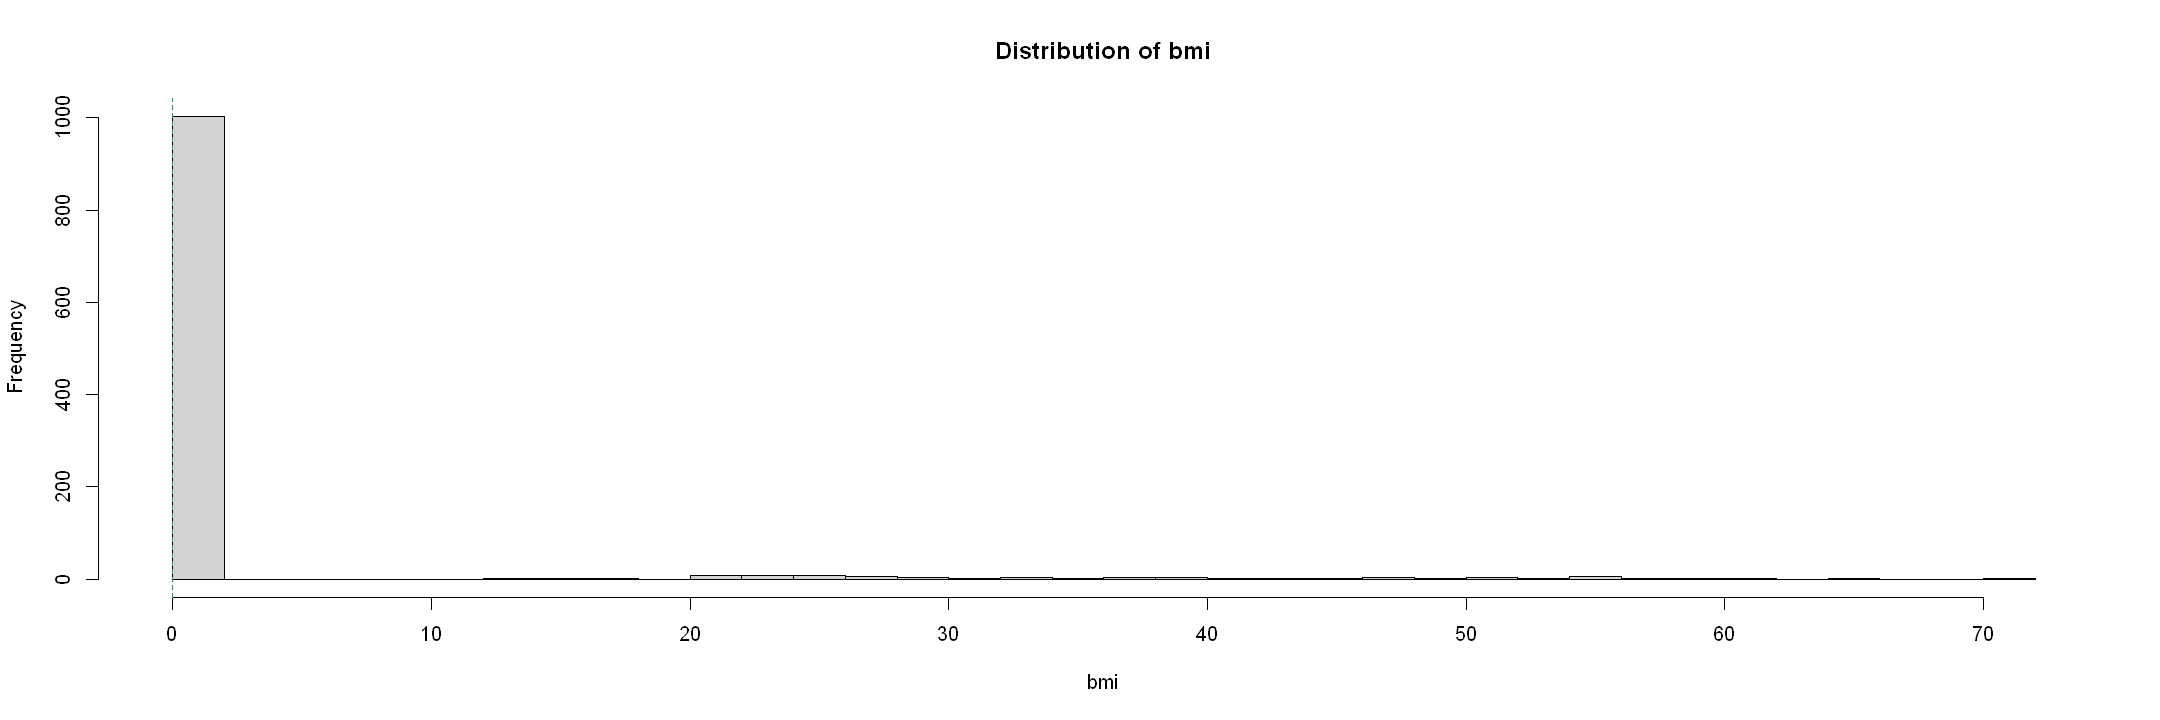

In [90]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_fistula_abcess, breaks = 30, 
     main = "Distribution of bmi",
     xlab = "bmi")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_fistula_abcess, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_fistula_abcess",
  outcomes = flare_outcomes
)
combined_dataset_imputed$age_at_surg_fistula_abcess <- scale(combined_dataset_imputed$age_at_surg_fistula_abcess)

#### age_at_surg_ileo_anal_pouch


PROCESSING: age_at_surg_ileo_anal_pouch 

Number of unique values: 8 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.2059  0.0000 40.6490 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1074    7 

 cat_top25 :

Normal   High 
  1074      7 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq df    p_value p_formatted     n
  <chr>            <chr>          <chr>   <lgl>  <lgl>   <dbl> <chr>       <int>
1 age_at_surg_ile… cat_median     flare_… NA     NA      0.687 0.6868       1081
2 age_at_surg_ile… cat_top25      flare_… NA     NA      0.687 0.6868       1081
3 age_at_surg_ile… cat_median     flare_… NA     NA      0.135 0.1348       1081
4 age_at_surg_ile… cat_top25      flare_… NA     NA      0.135 0.1348       1081
5 

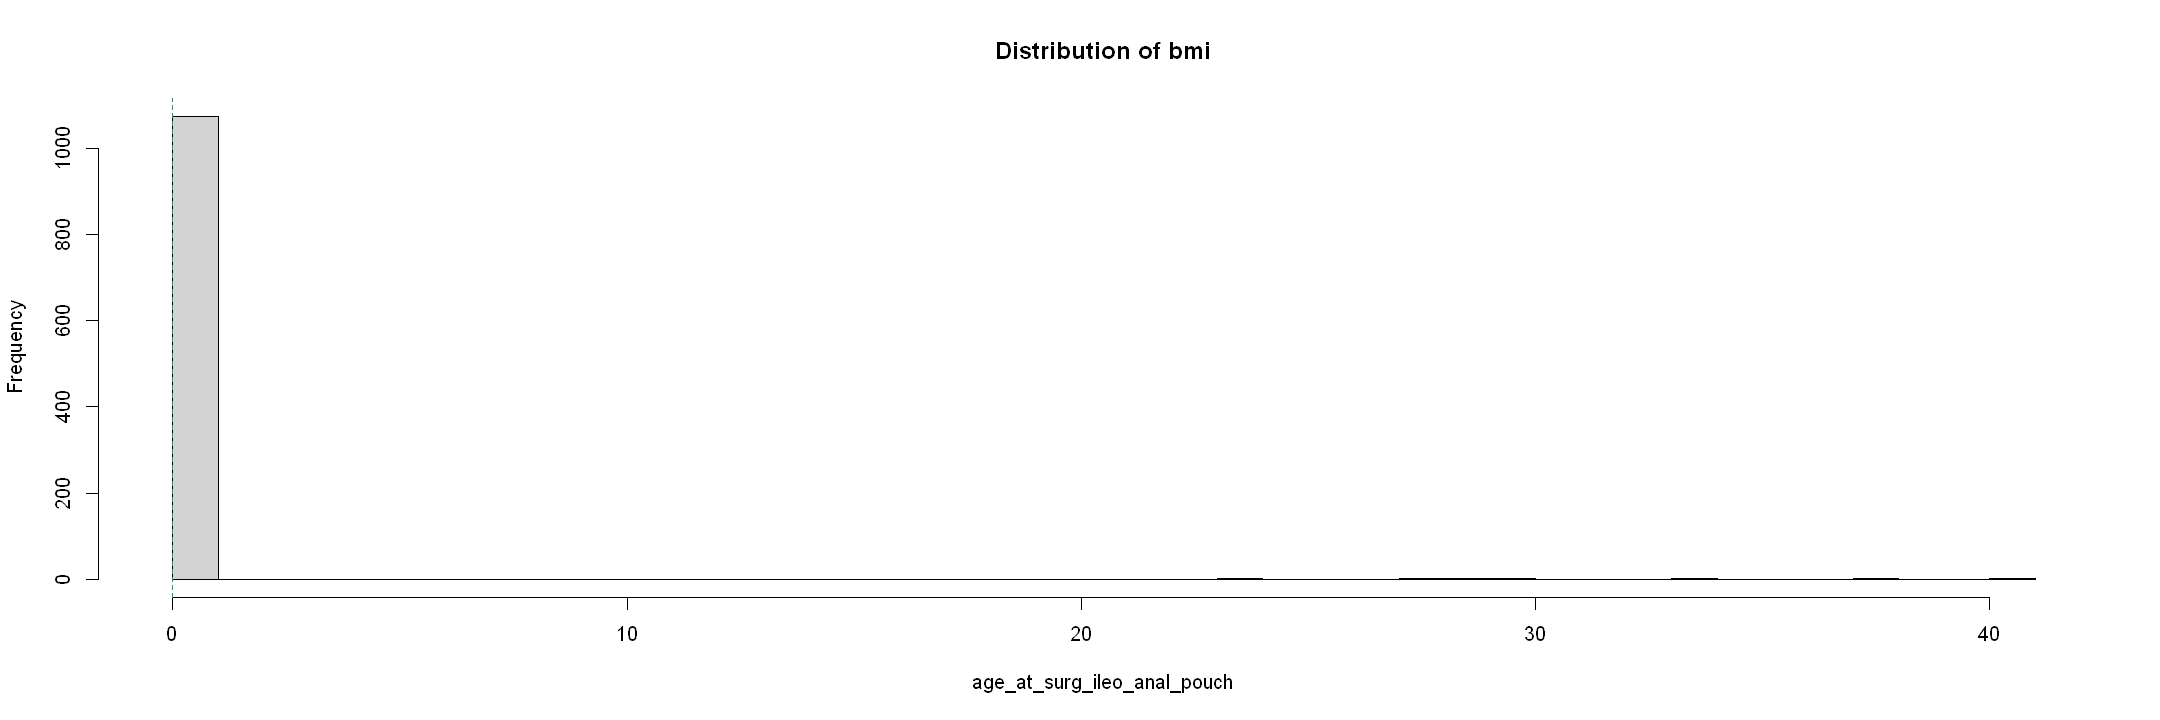

In [91]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_ileo_anal_pouch, breaks = 30, 
     main = "Distribution of bmi",
     xlab = "age_at_surg_ileo_anal_pouch")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_ileo_anal_pouch, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_ileo_anal_pouch",
  outcomes = flare_outcomes
)
combined_dataset_imputed$age_at_surg_ileo_anal_pouch <- scale(combined_dataset_imputed$age_at_surg_ileo_anal_pouch)


#### age_at_surg_small_bowel_resection


PROCESSING: age_at_surg_small_bowel_resection 

Number of unique values: 37 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.376   0.000  64.550 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1045   36 

 cat_top25 :

Normal   High 
  1045     36 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_sma… cat_median     flare_…  2.05      1   0.152 0.1521       1081
2 age_at_surg_sma… cat_top25      flare_…  2.05      1   0.152 0.1521       1081
3 age_at_surg_sma… cat_median     flare_…  0.084     1   0.772 0.7719       1081
4 age_at_surg_sma… cat_top25      flare_…  0.084     1   0.772 0.7719       

Applied cat_median categorization to age_at_surg_small_bowel_resection



x
High  Low 
  36 1045 

Chi-squared summary for predictor: age_at_surg_small_bowel_resection 
        Flare ChiSq df p_value
1 flare_date1 2.051  1  0.1521
2 flare_date2 0.084  1  0.7719
3 flare_date3 0.146  1  0.7028
4 flare_date4 1.236  1  0.2662


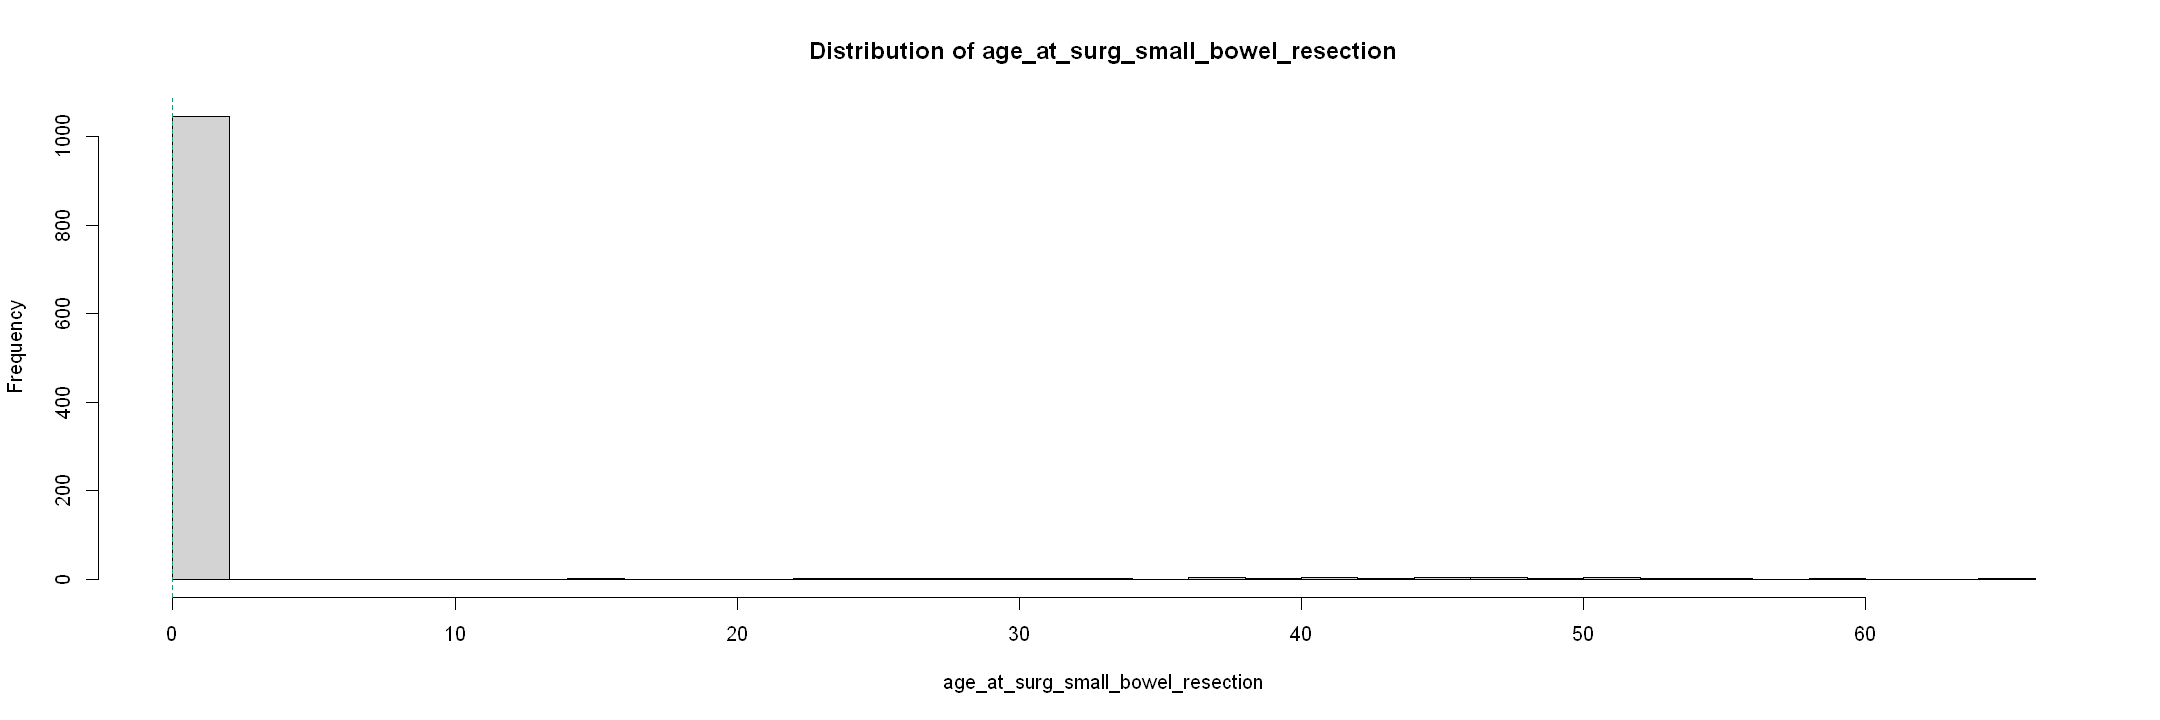

In [92]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_small_bowel_resection, breaks = 30, 
     main = "Distribution of age_at_surg_small_bowel_resection",
     xlab = "age_at_surg_small_bowel_resection")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_small_bowel_resection, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_small_bowel_resection",
  outcomes = flare_outcomes
)


# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "age_at_surg_small_bowel_resection",  
                                                     best_cat= "cat_median"  )


summarize_chisq_for_factor(combined_dataset_imputed, "age_at_surg_small_bowel_resection")

#### age_at_surg_ileocaecal_resection


PROCESSING: age_at_surg_ileocaecal_resection 

Number of unique values: 119 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   3.954   0.000  70.539 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
 963  118 

 cat_top25 :

Normal   High 
   963    118 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_ile… cat_median     flare_…  9.33      1 0.00225 0.0023       1081
2 age_at_surg_ile… cat_top25      flare_…  9.33      1 0.00225 0.0023       1081
3 age_at_surg_ile… cat_median     flare_…  1.43      1 0.232   0.2324       1081
4 age_at_surg_ile… cat_top25      flare_…  1.43      1 0.232   0.2324       

Applied cat_median categorization to age_at_surg_ileocaecal_resection



x
High  Low 
 118  963 

Chi-squared summary for predictor: age_at_surg_ileocaecal_resection 
        Flare ChiSq df  p_value
1 flare_date1 9.332  1 0.002252
2 flare_date2 1.426  1 0.232400
3 flare_date3 0.412  1 0.520800
4 flare_date4 0.022  1 0.883300


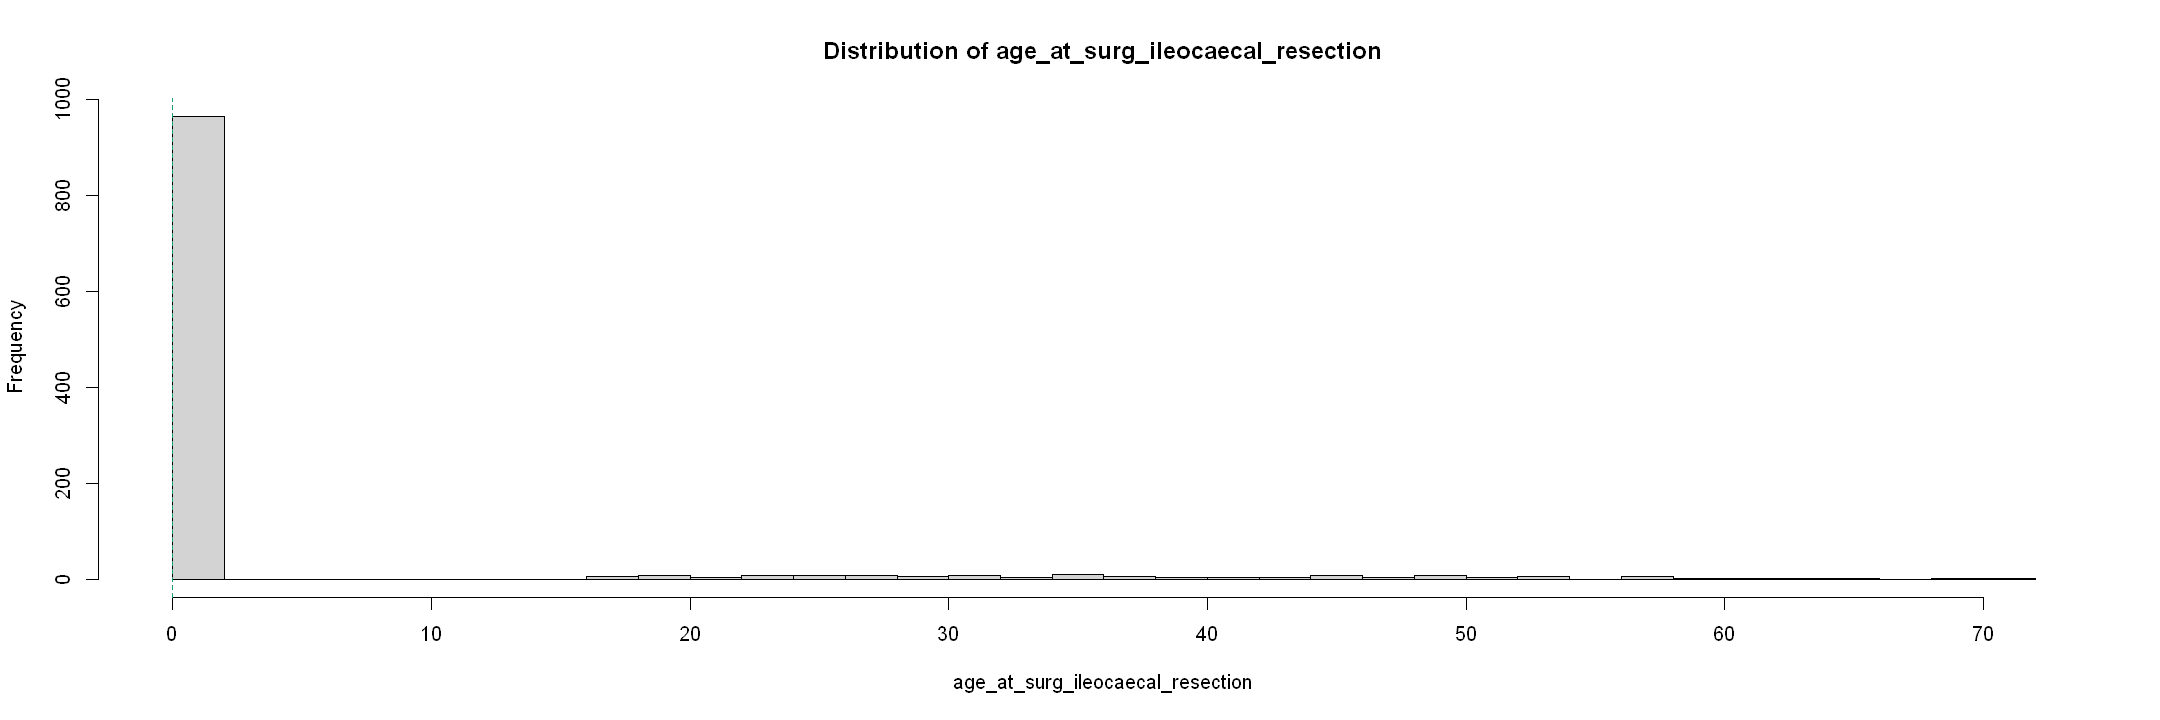

In [93]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_ileocaecal_resection, breaks = 30, 
     main = "Distribution of age_at_surg_ileocaecal_resection",
     xlab = "age_at_surg_ileocaecal_resection")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_ileocaecal_resection, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_ileocaecal_resection",
  outcomes = flare_outcomes
)


# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "age_at_surg_ileocaecal_resection",  
                                                     best_cat= "cat_median"  )


summarize_chisq_for_factor(combined_dataset_imputed, "age_at_surg_ileocaecal_resection")

#### age_at_surg_small_bowel_stoma


PROCESSING: age_at_surg_small_bowel_stoma 

Number of unique values: 40 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.253   0.000  67.493 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1042   39 

 cat_top25 :

Normal   High 
  1042     39 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_sma… cat_median     flare_…  1.93      1   0.164 0.1643       1081
2 age_at_surg_sma… cat_top25      flare_…  1.93      1   0.164 0.1643       1081
3 age_at_surg_sma… cat_median     flare_…  1.11      1   0.292 0.2924       1081
4 age_at_surg_sma… cat_top25      flare_…  1.11      1   0.292 0.2924       1081

Applied cat_median categorization to age_at_surg_small_bowel_stoma



x
High  Low 
  39 1042 

Chi-squared summary for predictor: age_at_surg_small_bowel_stoma 
        Flare ChiSq df p_value
1 flare_date1 1.934  1  0.1643
2 flare_date2 1.109  1  0.2924
3 flare_date3 0.001  1  0.9716
4 flare_date4 0.755  1  0.3850


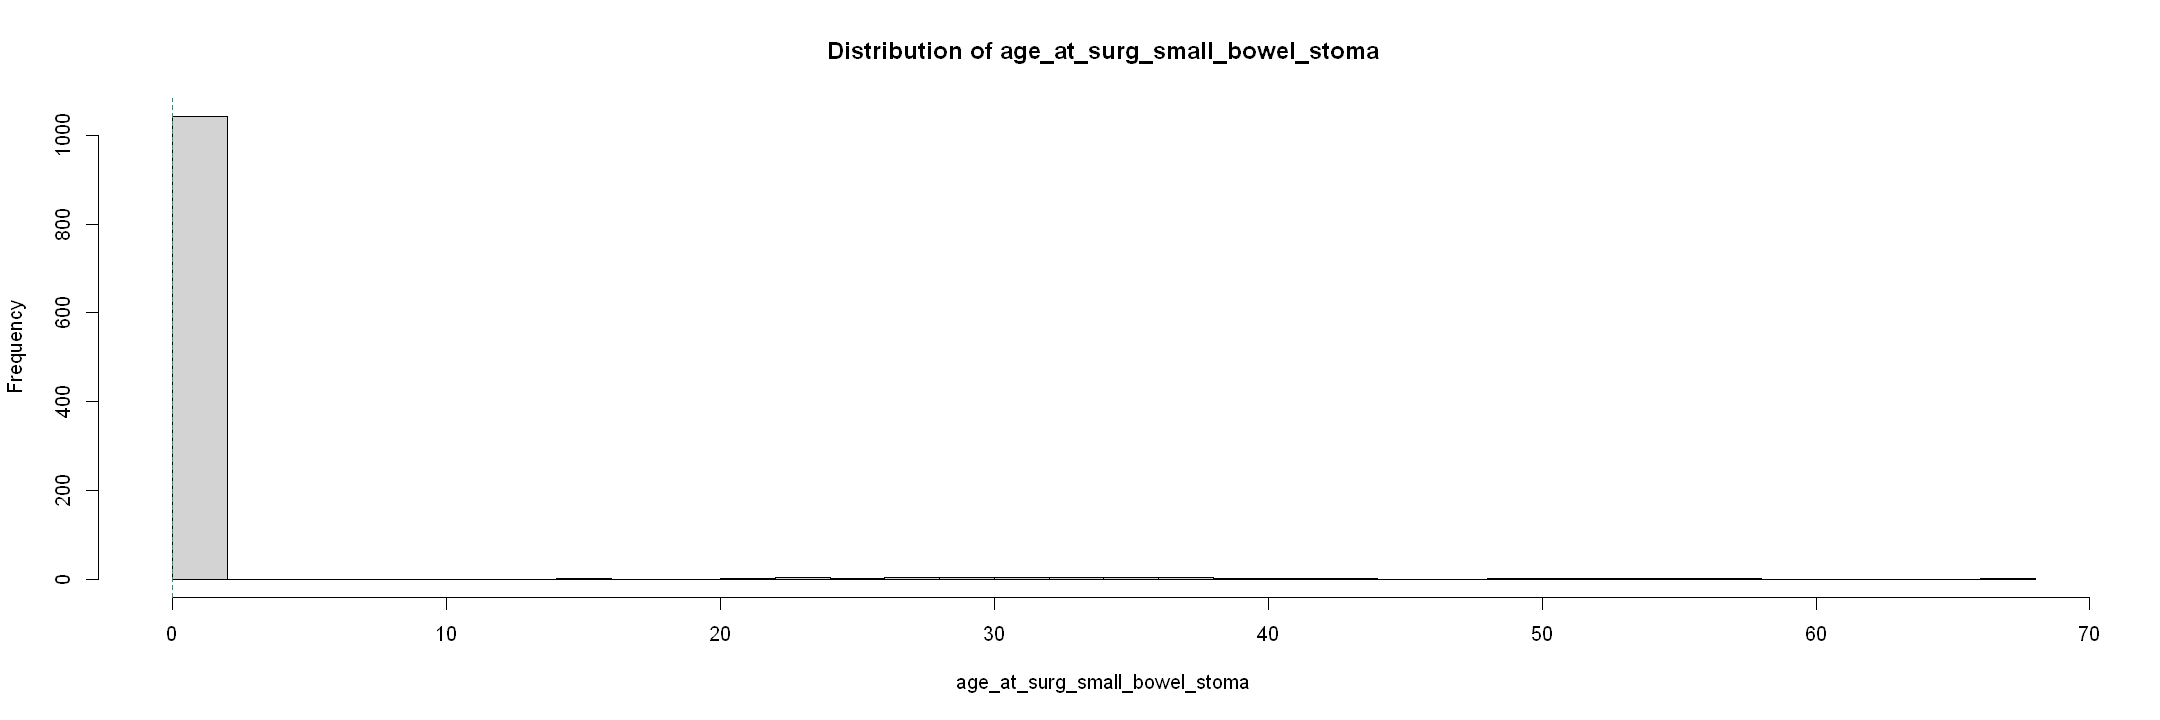

In [94]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_small_bowel_stoma, breaks = 30, 
     main = "Distribution of age_at_surg_small_bowel_stoma",
     xlab = "age_at_surg_small_bowel_stoma")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_small_bowel_stoma, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_small_bowel_stoma",
  outcomes = flare_outcomes
)


# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "age_at_surg_small_bowel_stoma",  
                                                     best_cat= "cat_median"  )


summarize_chisq_for_factor(combined_dataset_imputed, "age_at_surg_small_bowel_stoma")

#### age_at_surg_colostoma


PROCESSING: age_at_surg_colostoma 

Number of unique values: 13 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.4308  0.0000 57.8865 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1069   12 

 cat_top25 :

Normal   High 
  1069     12 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_col… cat_median     flare_…     NA    NA   0.761 0.7612       1081
2 age_at_surg_col… cat_top25      flare_…     NA    NA   0.761 0.7612       1081
3 age_at_surg_col… cat_median     flare_…      0     1   1.00  1.0000       1081
4 age_at_surg_col… cat_top25      flare_…      0     1   1.00  1.0000       1081
5 age_a

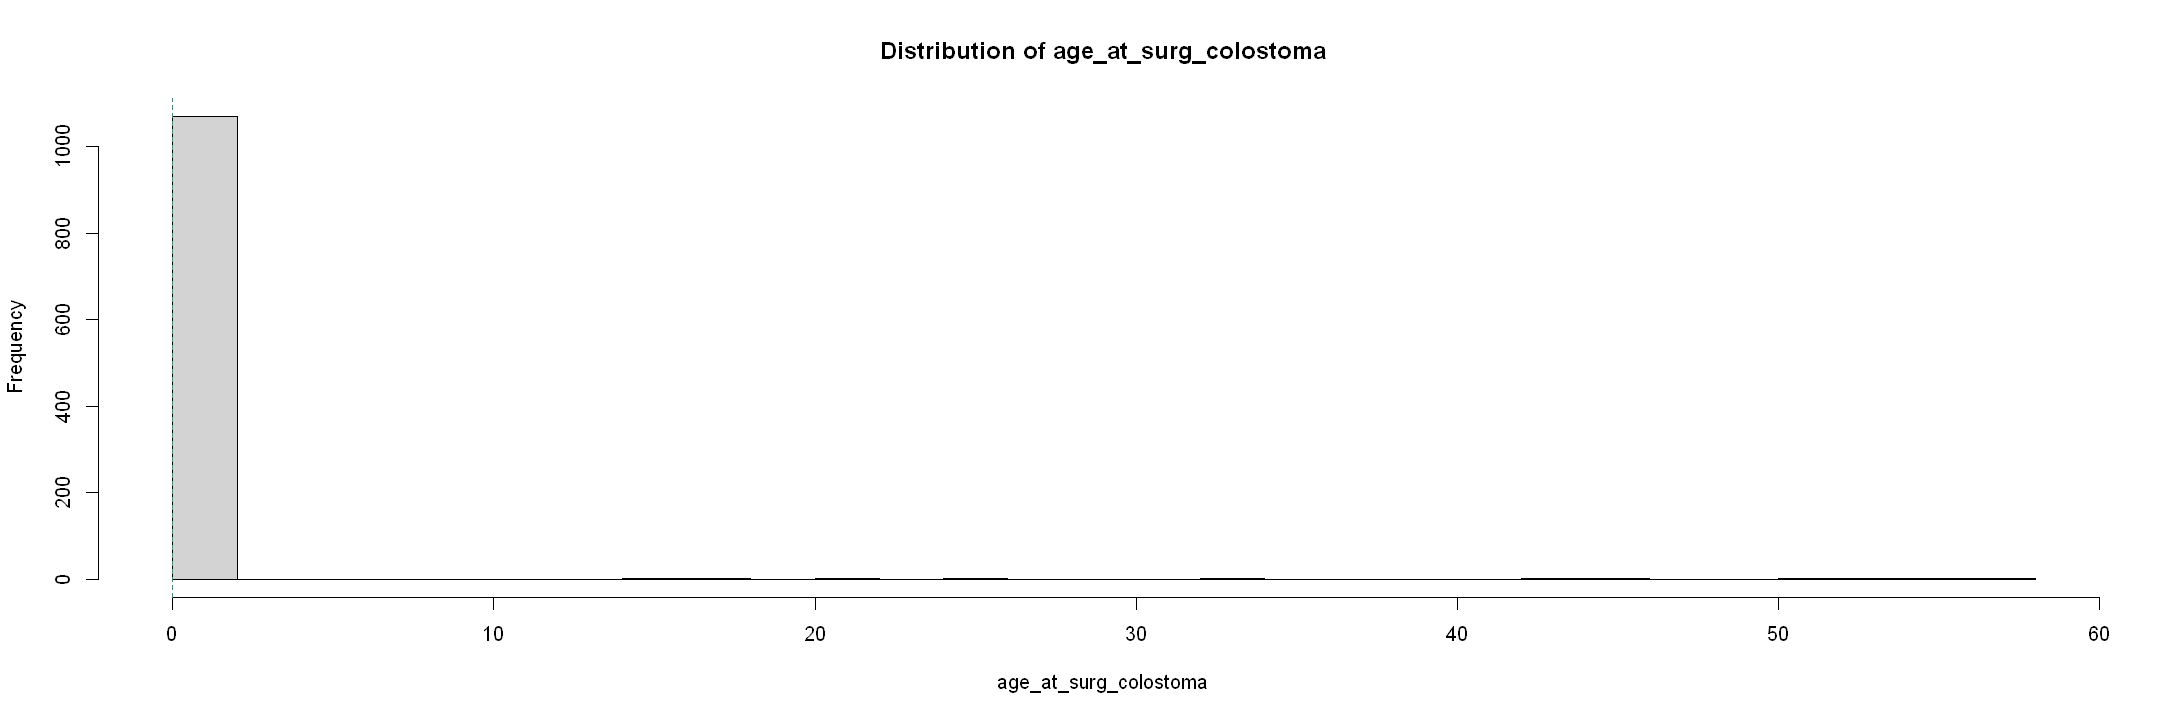

In [95]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_colostoma, breaks = 30, 
     main = "Distribution of age_at_surg_colostoma",
     xlab = "age_at_surg_colostoma")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_colostoma, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)



results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_colostoma",
  outcomes = flare_outcomes
)

combined_dataset_imputed$age_at_surg_colostoma <- scale(combined_dataset_imputed$age_at_surg_colostoma)

#### age_at_surg_proctocolectomy


PROCESSING: age_at_surg_proctocolectomy 

Number of unique values: 6 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.1296  0.0000 34.1028 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1076    5 

 cat_top25 :

Normal   High 
  1076      5 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq df    p_value p_formatted     n
  <chr>            <chr>          <chr>   <lgl>  <lgl>   <dbl> <chr>       <int>
1 age_at_surg_pro… cat_median     flare_… NA     NA     1      1.0000       1081
2 age_at_surg_pro… cat_top25      flare_… NA     NA     1      1.0000       1081
3 age_at_surg_pro… cat_median     flare_… NA     NA     0.0672 0.0672       1081
4 age_at_surg_pro… cat_top25      flare_… NA     NA     0.0672 0.0672       1081
5 

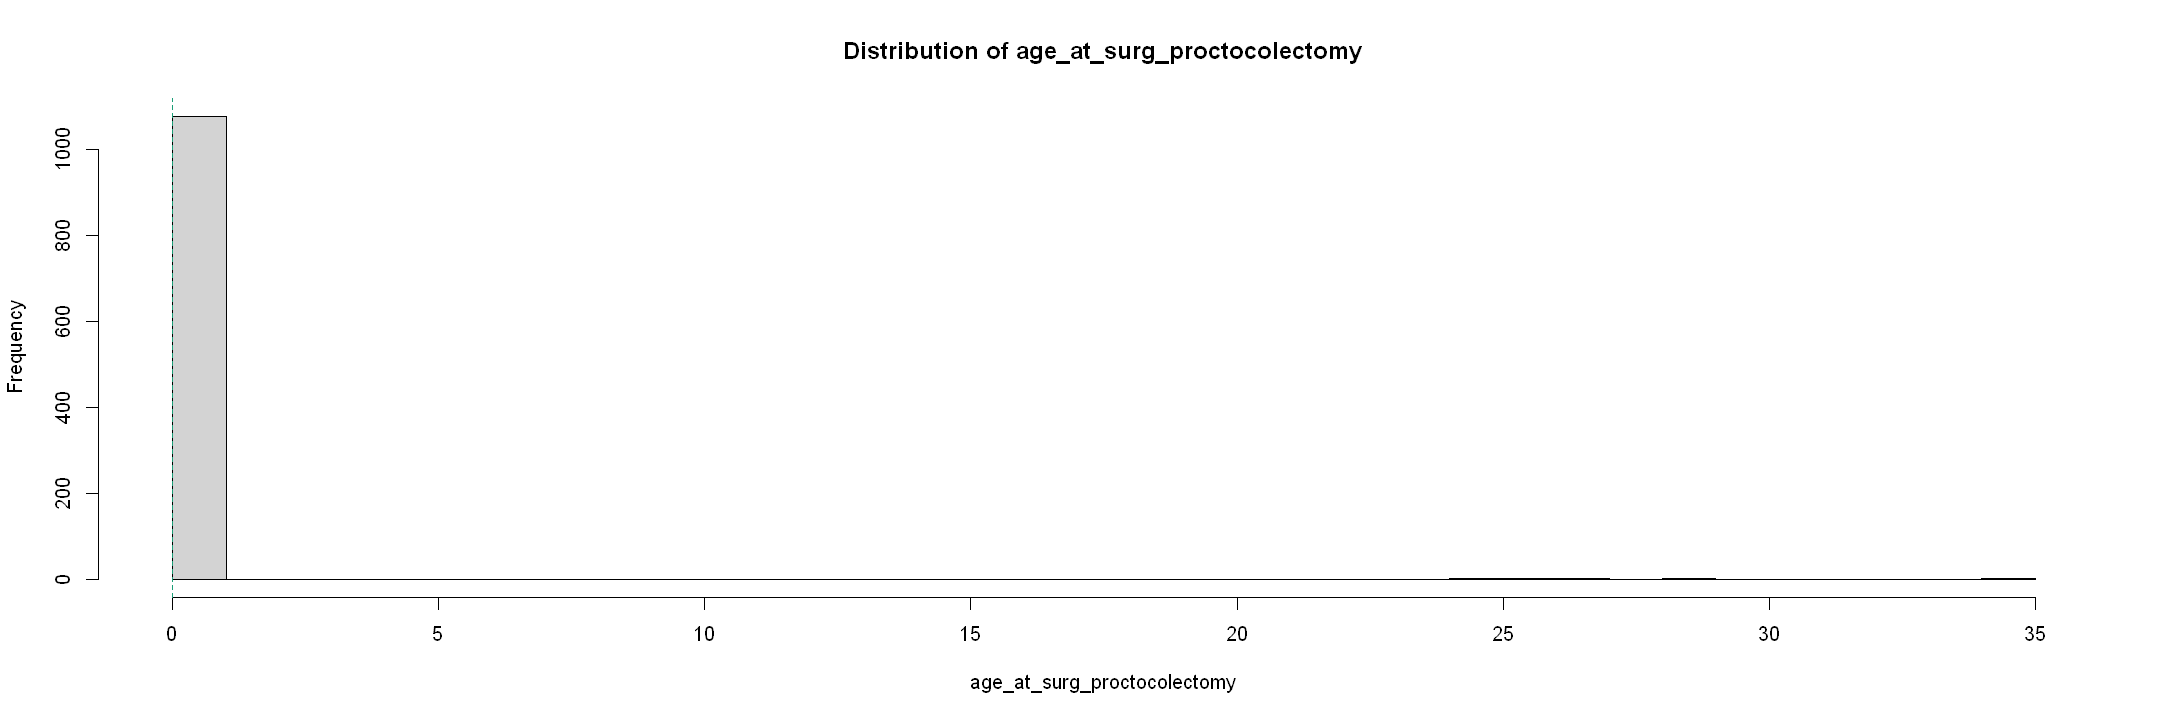

In [96]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_proctocolectomy, breaks = 30, 
     main = "Distribution of age_at_surg_proctocolectomy",
     xlab = "age_at_surg_proctocolectomy")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_proctocolectomy, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_proctocolectomy",
  outcomes = flare_outcomes
)

combined_dataset_imputed$age_at_surg_proctocolectomy <- scale(combined_dataset_imputed$age_at_surg_proctocolectomy)

#### age_at_surg_stoma_reversal


PROCESSING: age_at_surg_stoma_reversal 

Number of unique values: 31 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.031   0.000  61.240 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1051   30 

 cat_top25 :

Normal   High 
  1051     30 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 age_at_surg_sto… cat_median     flare_…  3.73      1  0.0534 0.0534       1081
2 age_at_surg_sto… cat_top25      flare_…  3.73      1  0.0534 0.0534       1081
3 age_at_surg_sto… cat_median     flare_…  0         1  1.00   1.0000       1081
4 age_at_surg_sto… cat_top25      flare_…  0         1  1.00   1.0000       1081
5 

Applied cat_median categorization to age_at_surg_stoma_reversal



x
High  Low 
  30 1051 

Chi-squared summary for predictor: age_at_surg_stoma_reversal 
        Flare ChiSq df p_value
1 flare_date1 3.731  1 0.05342
2 flare_date2 0.000  1 1.00000
3 flare_date3 0.088  1 0.76620
4 flare_date4 0.008  1 0.92830


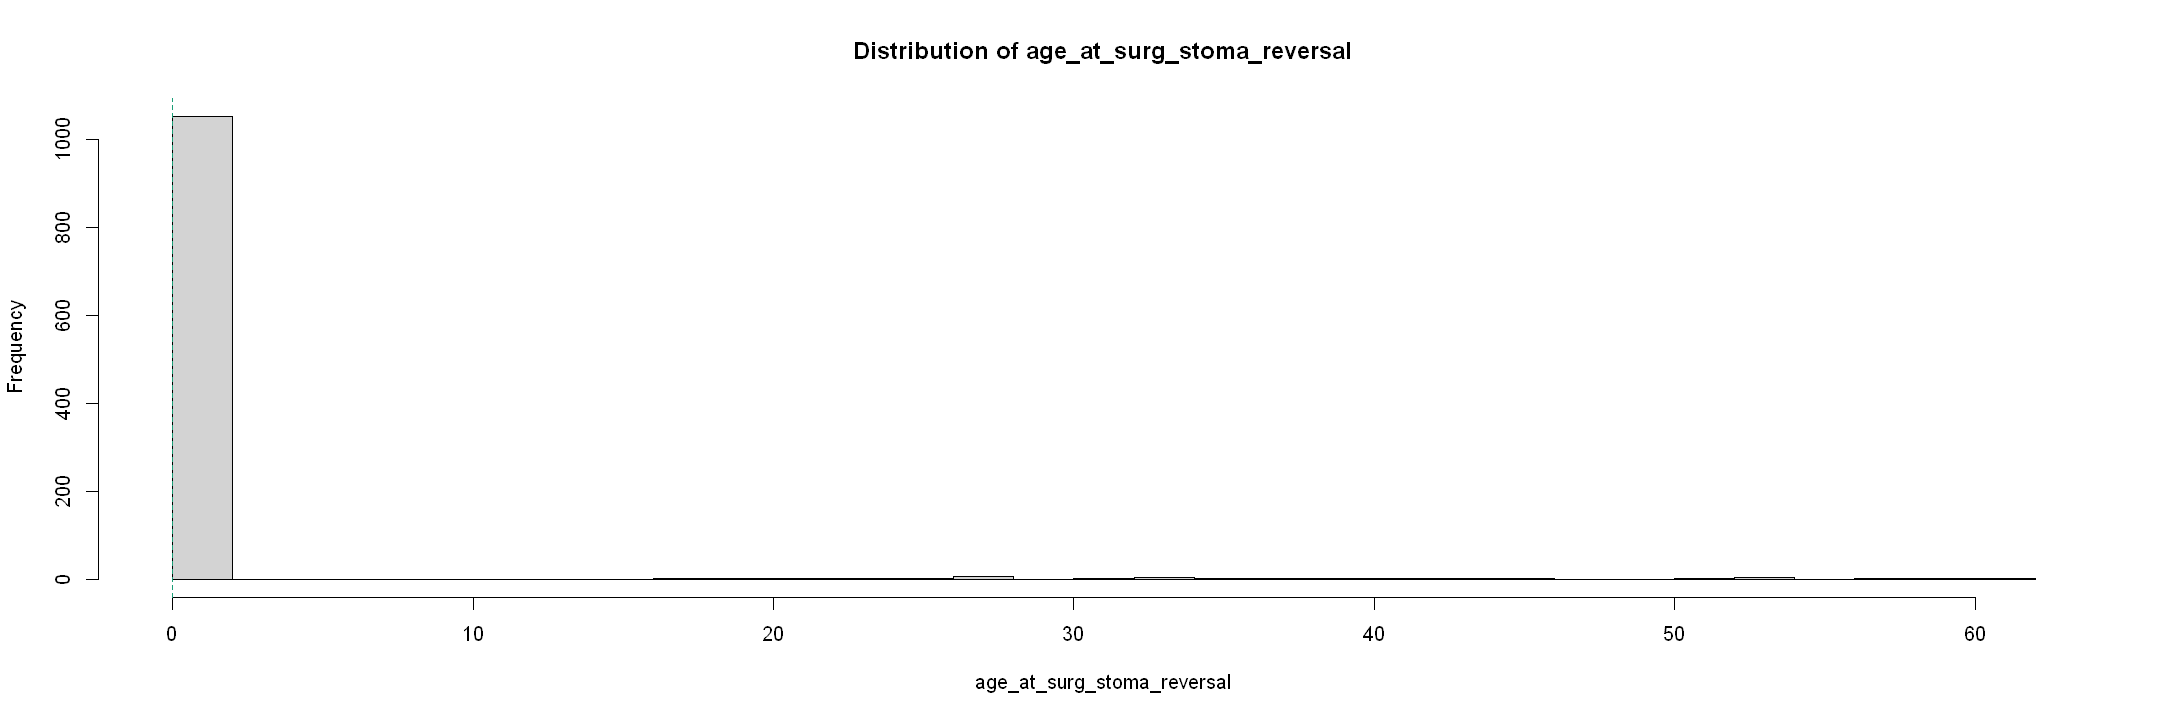

In [97]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_stoma_reversal, breaks = 30, 
     main = "Distribution of age_at_surg_stoma_reversal",
     xlab = "age_at_surg_stoma_reversal")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_stoma_reversal, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_stoma_reversal",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "age_at_surg_stoma_reversal",  
                                                     best_cat= "cat_median"  )

summarize_chisq_for_factor(combined_dataset_imputed, "age_at_surg_stoma_reversal")

#### age_at_surg_proctectomy


PROCESSING: age_at_surg_proctectomy 

Number of unique values: 4 
Number of valid observations: 1081 

Overall summary statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.00000  0.00000  0.00000  0.07693  0.00000 34.10278 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1078    3 

 cat_top25 :

Normal   High 
  1078      3 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq df    p_value p_formatted     n
  <chr>            <chr>          <chr>   <lgl>  <lgl>   <dbl> <chr>       <int>
1 age_at_surg_pro… cat_median     flare_… NA     NA      0.555 0.5554       1081
2 age_at_surg_pro… cat_top25      flare_… NA     NA      0.555 0.5554       1081
3 age_at_surg_pro… cat_median     flare_… NA     NA      0.256 0.2556       1081
4 age_at_surg_pro… cat_top25      flare_… NA     NA      0.256 0.2556      

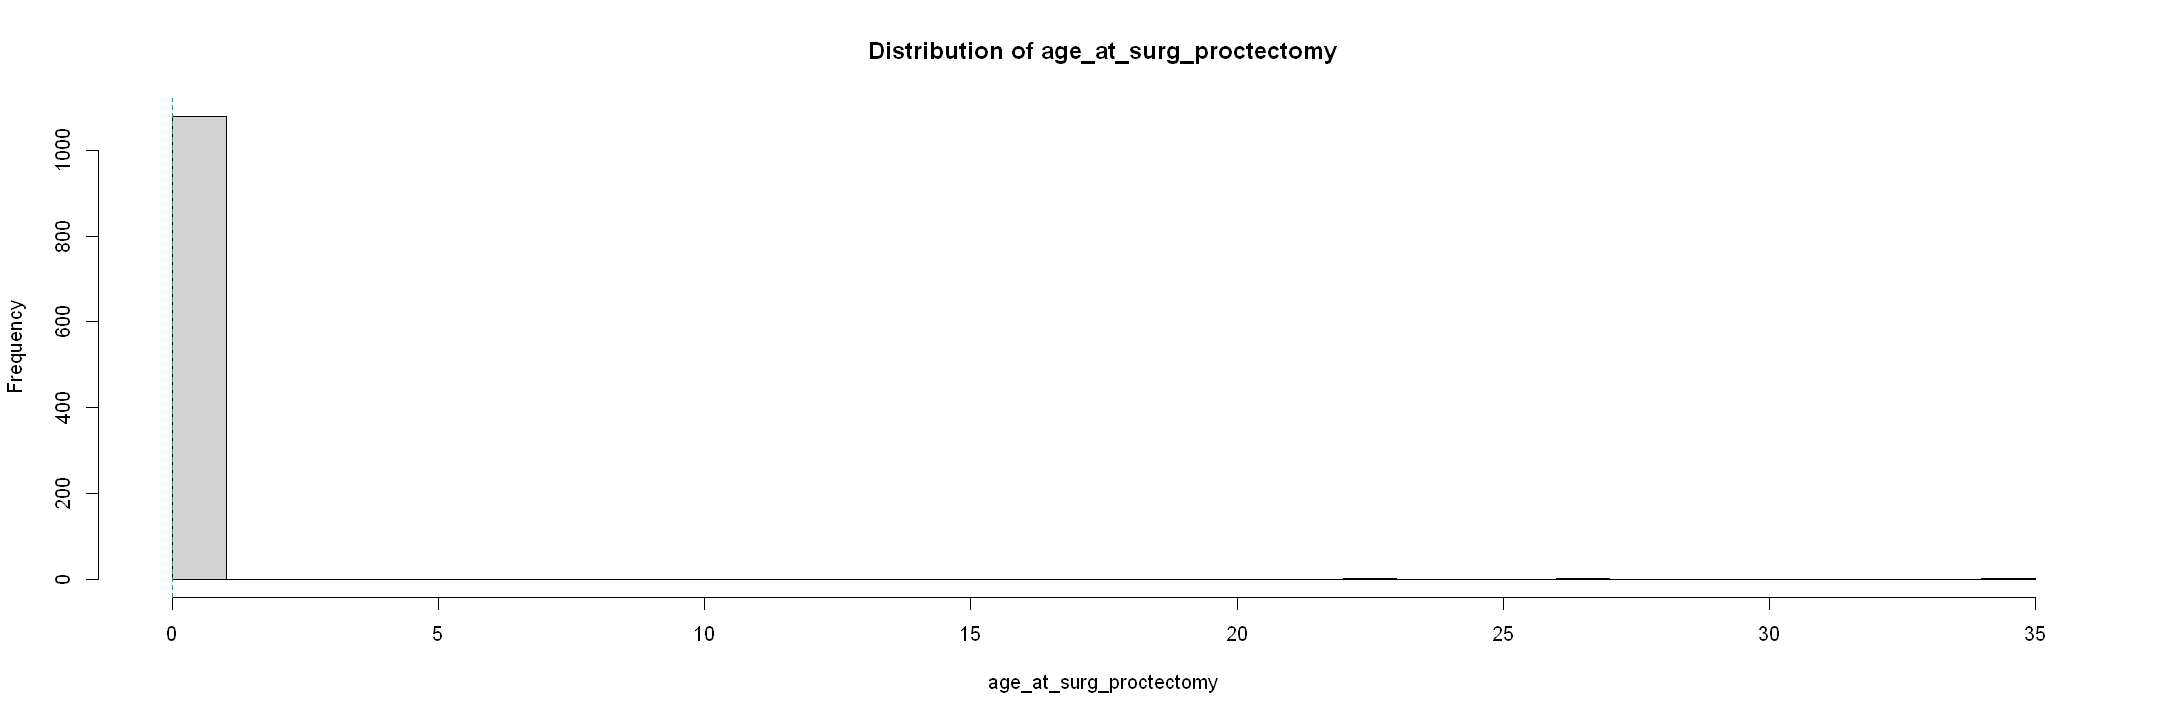

In [98]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_proctectomy, breaks = 30, 
     main = "Distribution of age_at_surg_proctectomy",
     xlab = "age_at_surg_proctectomy")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_proctectomy, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "age_at_surg_proctectomy",
  outcomes = flare_outcomes
)


combined_dataset_imputed$age_at_surg_proctectomy <- scale(combined_dataset_imputed$age_at_surg_proctectomy)

#### age_at_surg_stenoplast

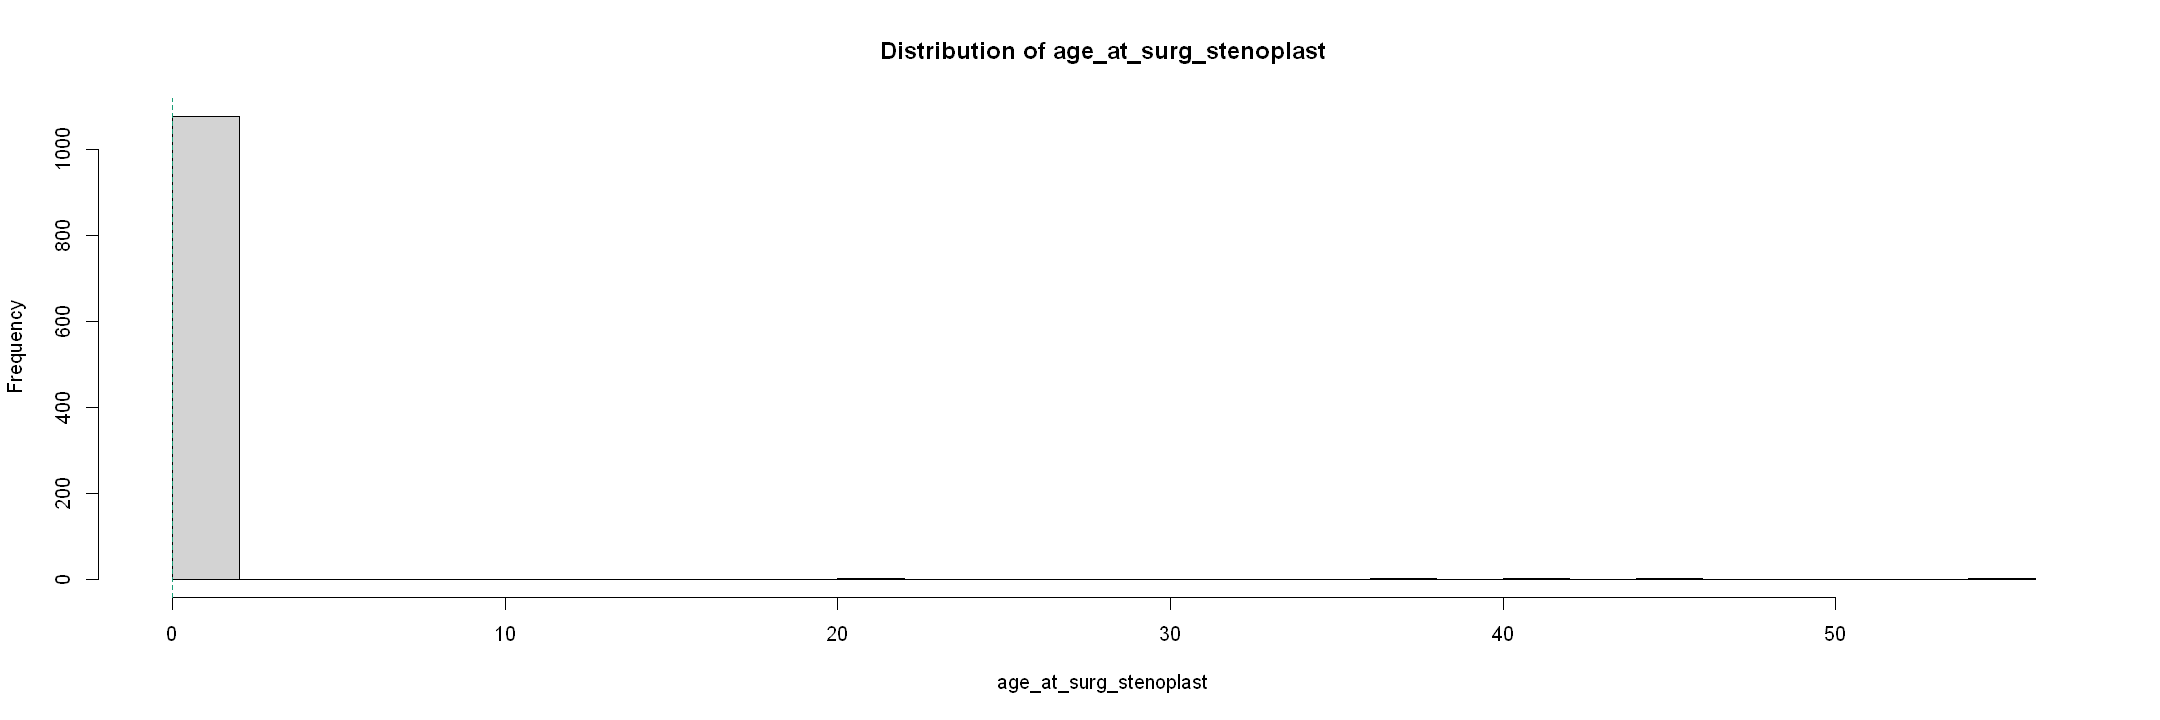

In [99]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$age_at_surg_stenoplast, breaks = 30, 
     main = "Distribution of age_at_surg_stenoplast",
     xlab = "age_at_surg_stenoplast")
abline(v = c(0, median(combined_dataset_imputed$age_at_surg_stenoplast, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

combined_dataset_imputed$age_at_surg_stenoplast <- scale(combined_dataset_imputed$age_at_surg_stenoplast)

#### max_age_at_surg


PROCESSING: max_age_at_surg 

Number of unique values: 231 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   8.215   0.000  73.985 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
 851  230 

 cat_top25 :

Normal   High 
   851    230 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor       categorization outcome  chi_sq    df p_value p_formatted     n
  <chr>           <chr>          <chr>     <dbl> <int>   <dbl> <chr>       <int>
1 max_age_at_surg cat_median     flare_d…  2.37      1   0.124 0.1237       1081
2 max_age_at_surg cat_top25      flare_d…  2.37      1   0.124 0.1237       1081
3 max_age_at_surg cat_median     flare_d…  0.351     1   0.554 0.5537       1081
4 max_age_at_surg cat_top25      flare_d…  0.351     1   0.554 0.5537       1081
5 max_age_at

Applied cat_top25 categorization to max_age_at_surg



x
  High Normal 
   230    851 

Chi-squared summary for predictor: max_age_at_surg 
        Flare ChiSq df p_value
1 flare_date1 2.370  1  0.1237
2 flare_date2 0.351  1  0.5537
3 flare_date3 0.878  1  0.3488
4 flare_date4 1.260  1  0.2616


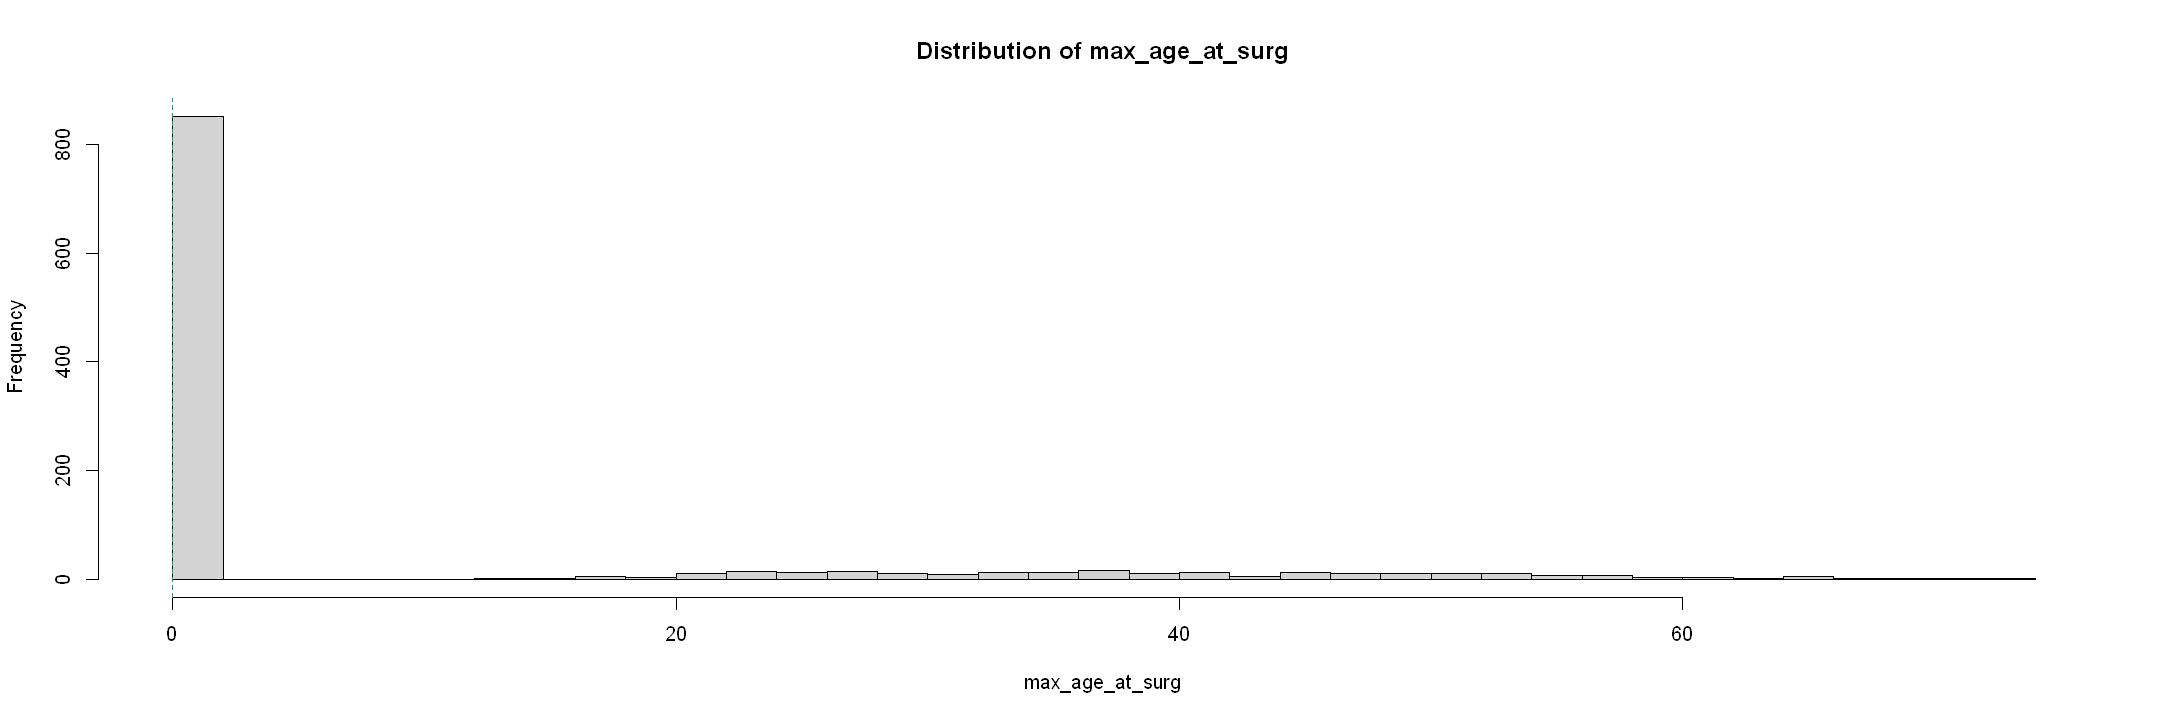

In [100]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$max_age_at_surg, breaks = 30, 
     main = "Distribution of max_age_at_surg",
     xlab = "max_age_at_surg")
abline(v = c(0, median(combined_dataset_imputed$max_age_at_surg, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "max_age_at_surg",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "max_age_at_surg",  
                                                     best_cat= "cat_top25"  )

summarize_chisq_for_factor(combined_dataset_imputed, "max_age_at_surg")

#### Anxious_mean


PROCESSING: Anxious_mean 

Number of unique values: 23 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.2500  0.4560  0.6667  2.0000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

[0,0.5] (0.5,2] 
    733     348 

 cat_q4 :

    [0,0.25] (0.25,0.667]    (0.667,2] 
         548          271          262 

 cat_median :

 Low High 
 548  533 

 cat_top25 :

Normal   High 
   819    262 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor    categorization outcome   chi_sq    df  p_value p_formatted     n
   <chr>        <chr>          <chr>      <dbl> <int>    <dbl> <chr>       <int>
 1 Anxious_mean cat_top25      flare_da…  41.5      1 1.15e-10 < 0.001      1081
 2 Anxious_mean cat_q4         flare_da…  44.1      2 2.69e-10 < 0.001      1081
 3 Anxious_mean cat_q3         flare_da…  26.3      1 2.89e- 7 < 0.001      1081
 4 Anxious_mean cat_median     flare_da…   7.07     1 7.83e- 3 0

Applied cat_q4 categorization to Anxious_mean



x
(0.25,0.667]    (0.667,2]     [0,0.25] 
         271          262          548 

Chi-squared summary for predictor: Anxious_mean 
        Flare  ChiSq df   p_value
1 flare_date1 44.073  2 2.690e-10
2 flare_date2 54.514  2 1.454e-12
3 flare_date3 78.172  2 1.060e-17
4 flare_date4 95.513  2 1.818e-21


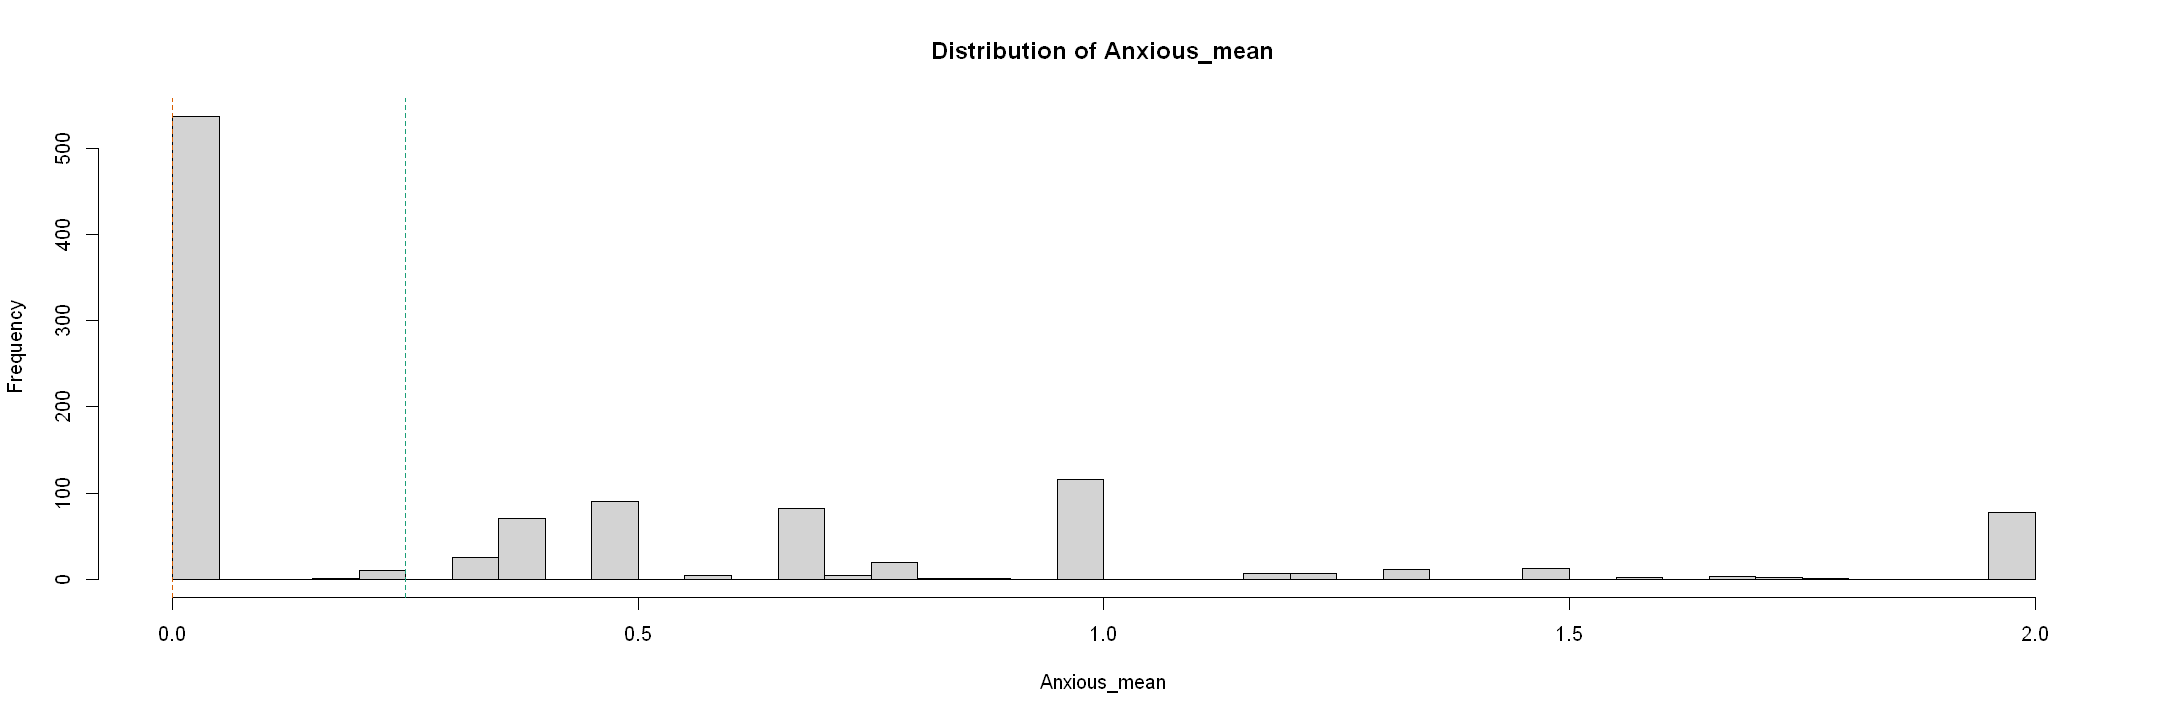

In [101]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$Anxious_mean, breaks = 30, 
     main = "Distribution of Anxious_mean",
     xlab = "Anxious_mean")
abline(v = c(0, median(combined_dataset_imputed$Anxious_mean, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "Anxious_mean",
  outcomes = flare_outcomes
)
# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "Anxious_mean",  
                                                     best_cat= "cat_q4"  )
summarize_chisq_for_factor(combined_dataset_imputed, "Anxious_mean")

#### Stress_mean


PROCESSING: Stress_mean 

Number of unique values: 169 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   4.000   5.000   4.768   5.667   7.000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

   Low Medium   High 
   368    356    357 

 cat_q4 :

 Q1  Q2  Q3  Q4 
313 350 164 254 

 cat_median :

 Low High 
 663  418 

 cat_top25 :

Normal   High 
   827    254 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor   categorization outcome    chi_sq    df  p_value p_formatted     n
   <chr>       <chr>          <chr>       <dbl> <int>    <dbl> <chr>       <int>
 1 Stress_mean cat_q4         flare_dat…  46.2      3 5.16e-10 < 0.001      1081
 2 Stress_mean cat_q3         flare_dat…  35.6      2 1.90e- 8 < 0.001      1081
 3 Stress_mean cat_median     flare_dat…  22.8      1 1.82e- 6 < 0.001      1081
 4 Stress_mean cat_top25      flare_dat…  13.6      1 2.22e- 4 < 0.001      1081
 5 Stress_mean cat_

Applied cat_q4 categorization to Stress_mean



x
 Q1  Q2  Q3  Q4 
313 350 164 254 

Chi-squared summary for predictor: Stress_mean 
        Flare  ChiSq df   p_value
1 flare_date1 46.194  3 5.158e-10
2 flare_date2 56.484  3 3.311e-12
3 flare_date3 45.857  3 6.084e-10
4 flare_date4 31.789  3 5.799e-07


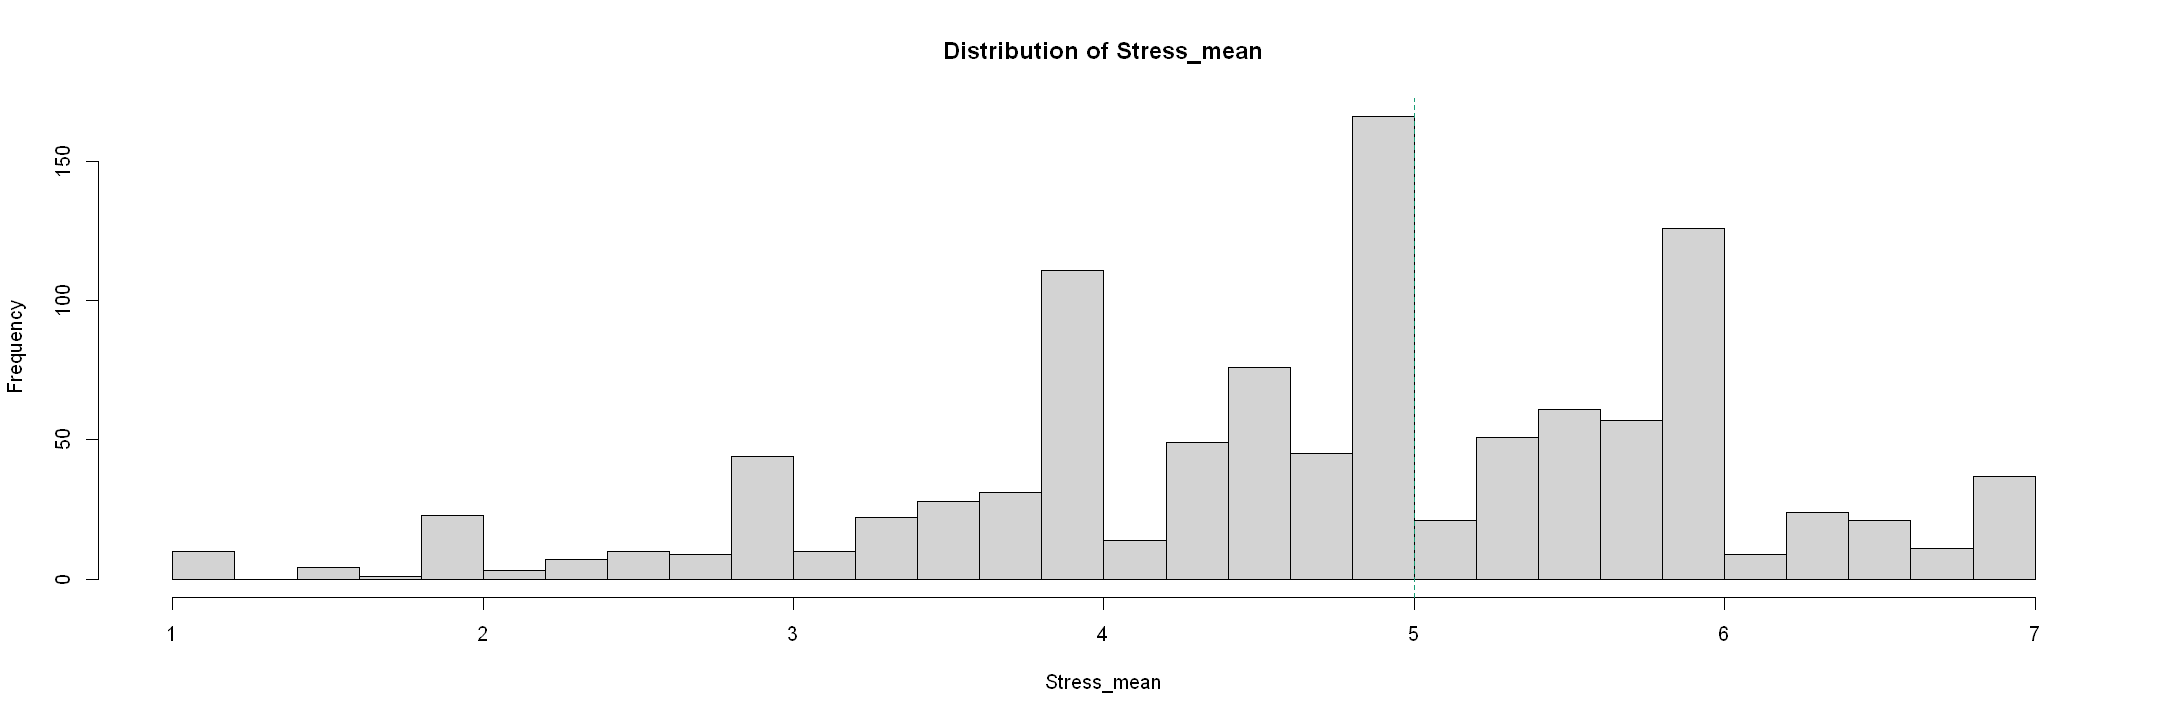

In [102]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$Stress_mean, breaks = 30, 
     main = "Distribution of Stress_mean",
     xlab = "Stress_mean")
abline(v = c(0, median(combined_dataset_imputed$Stress_mean, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "Stress_mean",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "Stress_mean",  
                                                     best_cat= "cat_q4"  )
summarize_chisq_for_factor(combined_dataset_imputed, "Stress_mean")

#### Fatigue_mean


PROCESSING: Fatigue_mean 

Number of unique values: 22 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.6667  2.0000  2.1655  4.0000  4.0000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

   Low Medium   High 
   386    349    346 

 cat_q4 :

[0,0.667] (0.667,2]     (2,4] 
      271       282       528 

 cat_median :

 Low High 
 553  528 

 cat_top25 : SKIPPED (insufficient categories or data)

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 12 × 8
   predictor    categorization outcome   chi_sq    df  p_value p_formatted     n
   <chr>        <chr>          <chr>      <dbl> <int>    <dbl> <chr>       <int>
 1 Fatigue_mean cat_q3         flare_da…  66.3      2 4.01e-15 < 0.001      1081
 2 Fatigue_mean cat_median     flare_da…  42.5      1 7.12e-11 < 0.001      1081
 3 Fatigue_mean cat_q4         flare_da…  44.3      2 2.46e-10 < 0.001      1081
 4 Fatigue_mean cat_q3         flare_da…  71.7      2 2.75e-1

Applied cat_q3 categorization to Fatigue_mean



x
  High    Low Medium 
   346    386    349 

Chi-squared summary for predictor: Fatigue_mean 
        Flare  ChiSq df   p_value
1 flare_date1 66.301  2 4.007e-15
2 flare_date2 71.660  2 2.749e-16
3 flare_date3 56.889  2 4.434e-13
4 flare_date4 38.231  2 4.993e-09


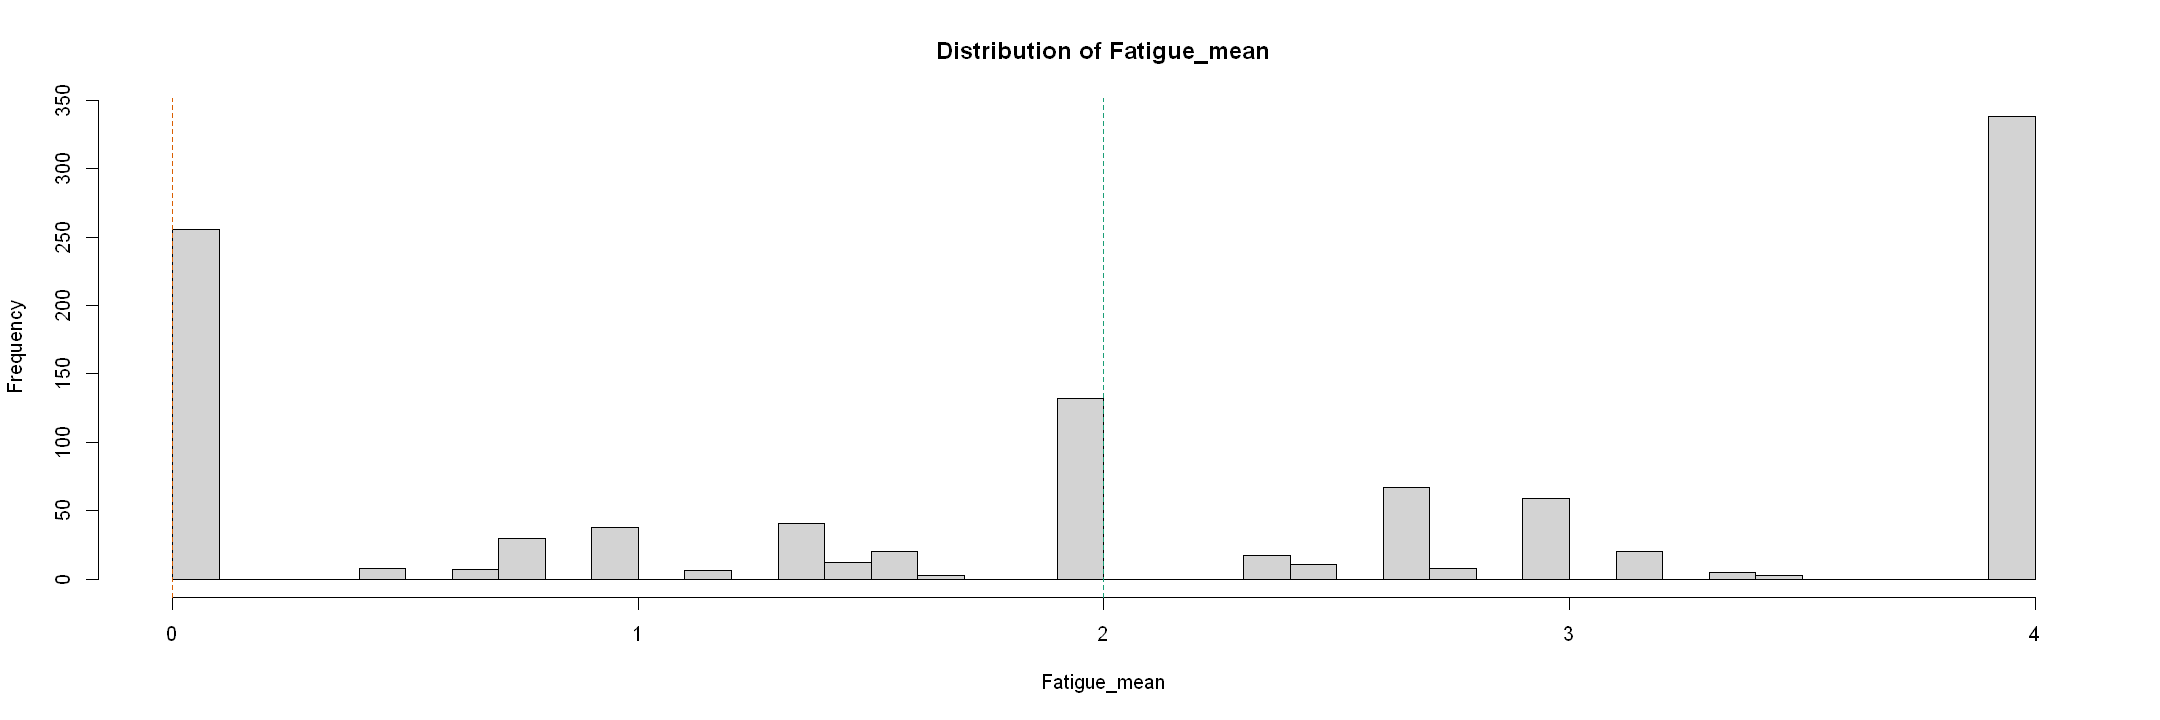

In [103]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$Fatigue_mean, breaks = 30, 
     main = "Distribution of Fatigue_mean",
     xlab = "Fatigue_mean")
abline(v = c(0, median(combined_dataset_imputed$Fatigue_mean, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "Fatigue_mean",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "Fatigue_mean",  
                                                     best_cat= "cat_q3"  )

summarize_chisq_for_factor(combined_dataset_imputed, "Fatigue_mean")

#### Pain_mean


PROCESSING: Pain_mean 

Number of unique values: 22 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.5000  0.6538  1.0000  2.0000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

[0,1] (1,2] 
  850   231 

 cat_q4 :

[0,0.5] (0.5,1]   (1,2] 
    578     272     231 

 cat_median :

 Low High 
 578  503 

 cat_top25 :

Normal   High 
   850    231 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor categorization outcome     chi_sq    df  p_value p_formatted     n
   <chr>     <chr>          <chr>        <dbl> <int>    <dbl> <chr>       <int>
 1 Pain_mean cat_q4         flare_date1  46.3      2 8.98e-11 < 0.001      1081
 2 Pain_mean cat_q3         flare_date1  37.1      1 1.10e- 9 < 0.001      1081
 3 Pain_mean cat_top25      flare_date1  37.1      1 1.10e- 9 < 0.001      1081
 4 Pain_mean cat_median     flare_date1  33.1      1 8.83e- 9 < 0.001      1081
 5 Pain_mean cat_q3         fl

Applied cat_q3 categorization to Pain_mean



x
(1,2] [0,1] 
  231   850 

Chi-squared summary for predictor: Pain_mean 
        Flare  ChiSq df   p_value
1 flare_date1 37.148  1 1.095e-09
2 flare_date2 39.967  1 2.583e-10
3 flare_date3 15.363  1 8.871e-05
4 flare_date4 12.637  1 3.782e-04


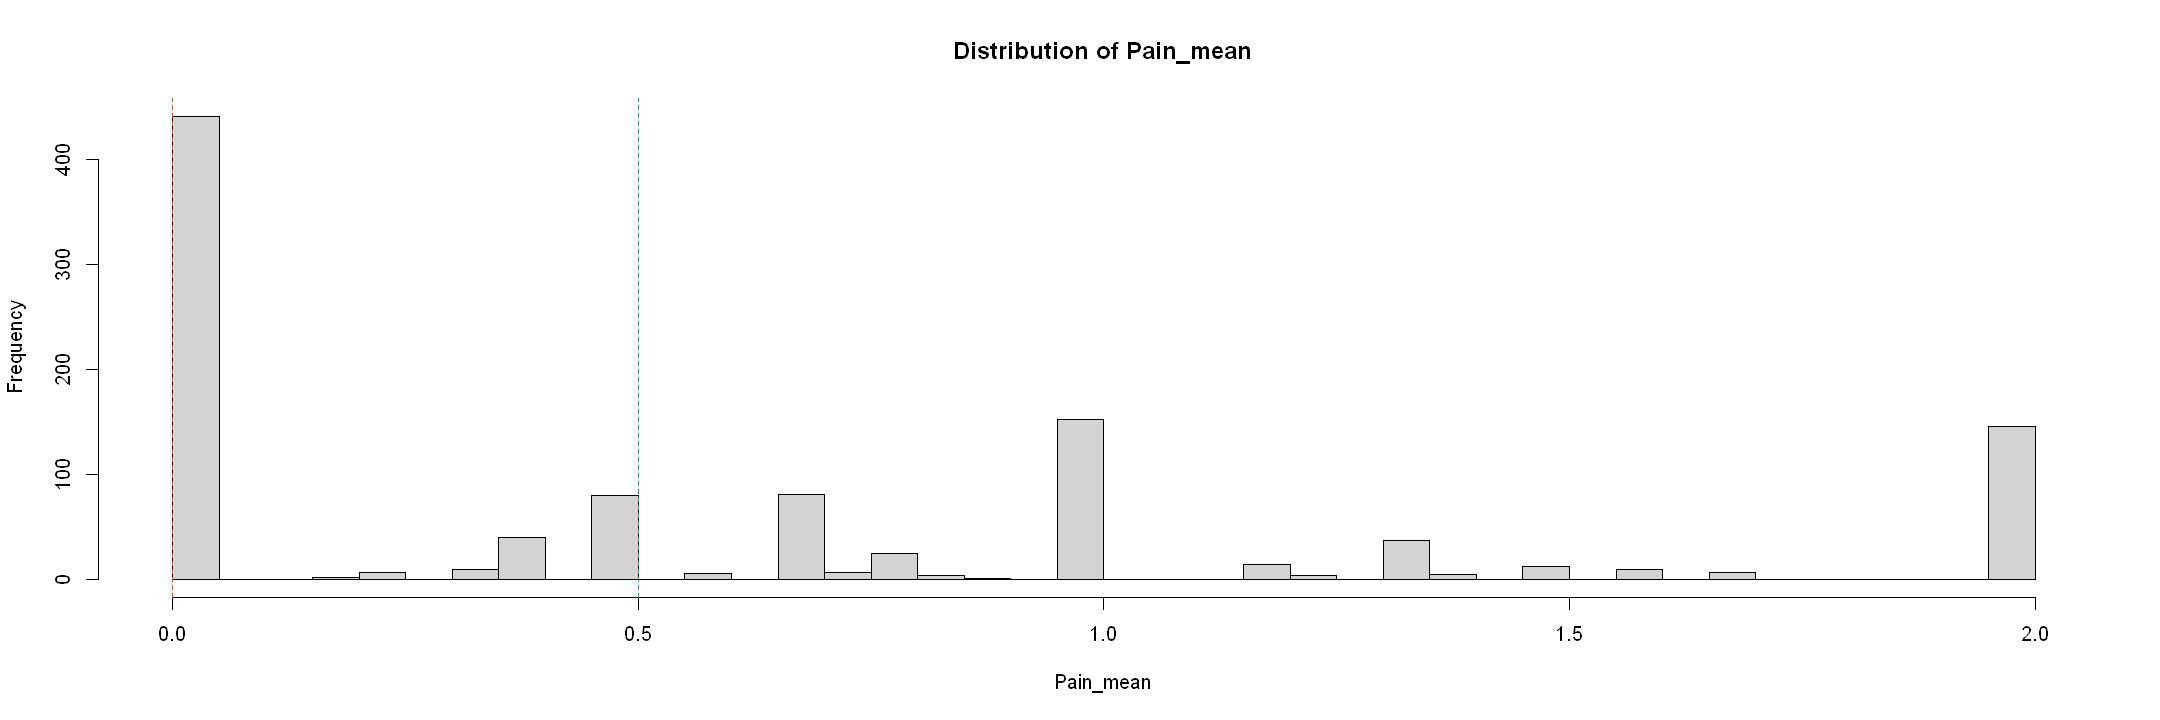

In [104]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$Pain_mean, breaks = 30, 
     main = "Distribution of Pain_mean",
     xlab = "Pain_mean")
abline(v = c(0, median(combined_dataset_imputed$Pain_mean, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "Pain_mean",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "Pain_mean",  
                                                     best_cat= "cat_q3"  )
summarize_chisq_for_factor(combined_dataset_imputed, "Pain_mean")

#### total_medication


PROCESSING: total_medication 

Number of unique values: 5 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   1.191   1.000   5.000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
 918  163 

 cat_top25 :

Normal   High 
   918    163 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 total_medication cat_median     flare_…  3.88      1  0.0488 0.0488       1081
2 total_medication cat_top25      flare_…  3.88      1  0.0488 0.0488       1081
3 total_medication cat_median     flare_…  4.53      1  0.0334 0.0334       1081
4 total_medication cat_top25      flare_…  4.53      1  0.0334 0.0334       1081
5 total_medic

Applied cat_top25 categorization to total_medication



x
  High Normal 
   163    918 

Chi-squared summary for predictor: total_medication 
        Flare ChiSq df p_value
1 flare_date1 3.882  1 0.04879
2 flare_date2 4.527  1 0.03336
3 flare_date3 0.001  1 0.97790
4 flare_date4 0.535  1 0.46470


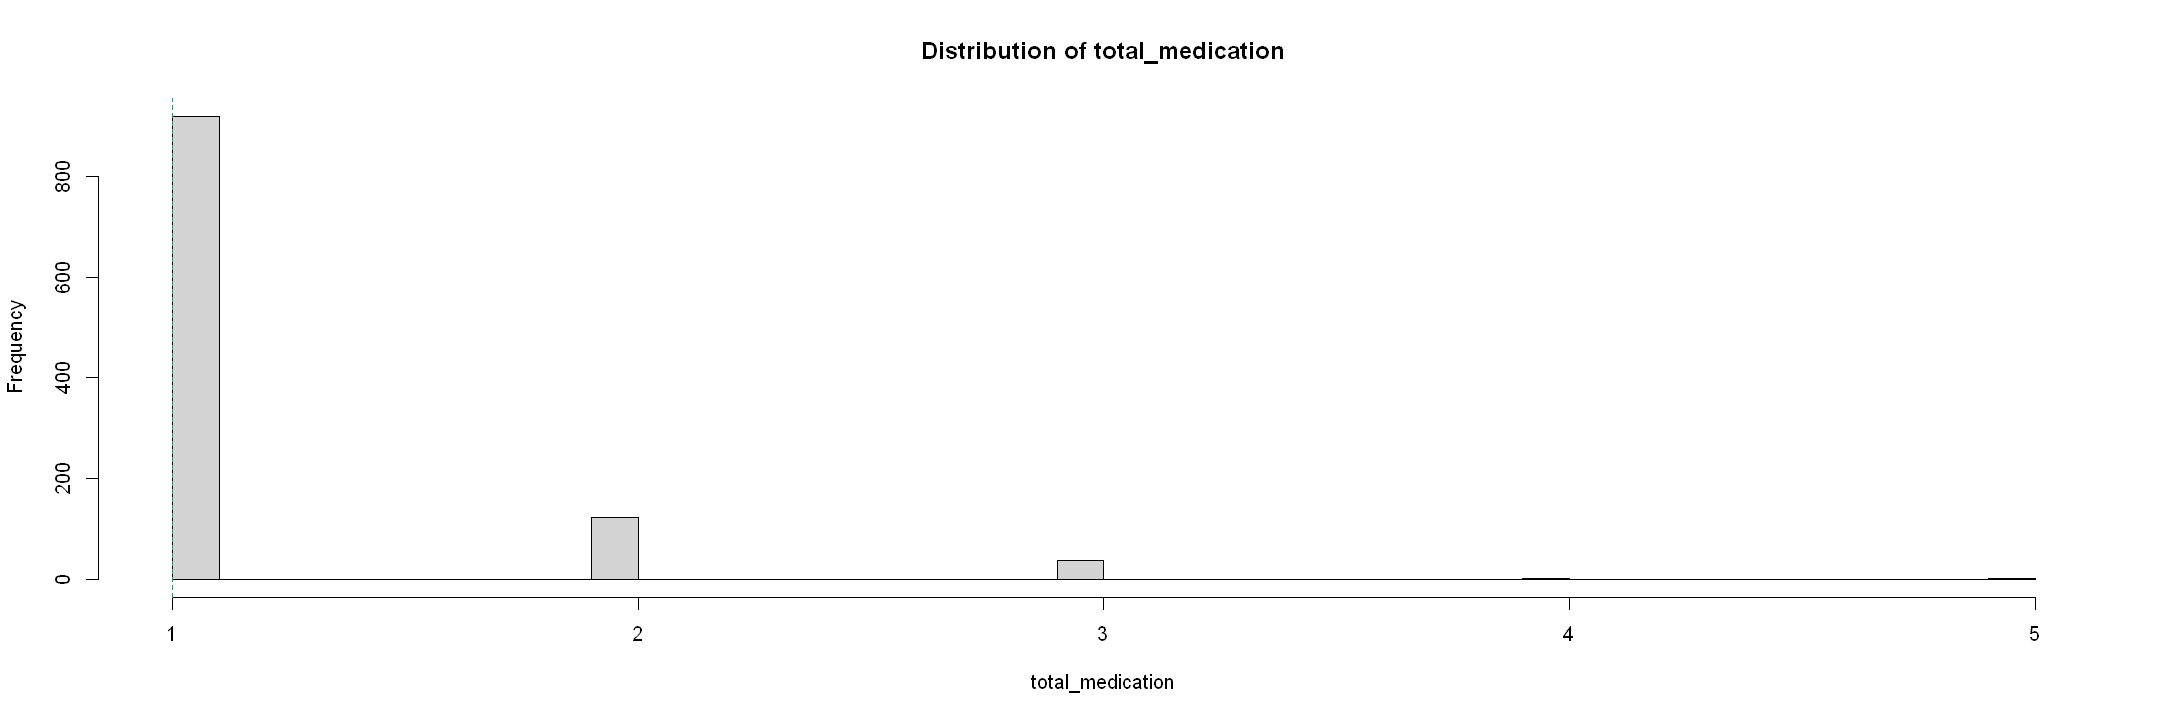

In [105]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$total_medication, breaks = 30, 
     main = "Distribution of total_medication",
     xlab = "total_medication")
abline(v = c(0, median(combined_dataset_imputed$total_medication, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "total_medication",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "total_medication",  
                                                     best_cat= "cat_top25"  )

summarize_chisq_for_factor(combined_dataset_imputed, "total_medication")

#### total_medication_period


PROCESSING: total_medication_period 

Number of unique values: 978 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0    1341    2129    2504    3320    8983 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

   Low Medium   High 
   361    360    360 

 cat_q4 :

 Q1  Q2  Q3  Q4 
271 270 270 270 

 cat_median :

 Low High 
 541  540 

 cat_top25 :

Normal   High 
   811    270 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor       categorization outcome chi_sq    df p_value p_formatted     n
   <chr>           <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
 1 total_medicati… cat_top25      flare_…  2.66      1   0.103 0.1031       1081
 2 total_medicati… cat_q3         flare_…  3.69      2   0.158 0.1577       1081
 3 total_medicati… cat_q4         flare_…  4.12      3   0.248 0.2484       1081
 4 total_medicati… cat_median     flare_…  0         1   0.983 0.9833       1081
 5 tota

Applied cat_top25 categorization to total_medication_period



x
  High Normal 
   270    811 

Chi-squared summary for predictor: total_medication_period 
        Flare ChiSq df p_value
1 flare_date1 2.657  1  0.1031
2 flare_date2 2.046  1  0.1526
3 flare_date3 0.158  1  0.6910
4 flare_date4 0.243  1  0.6223


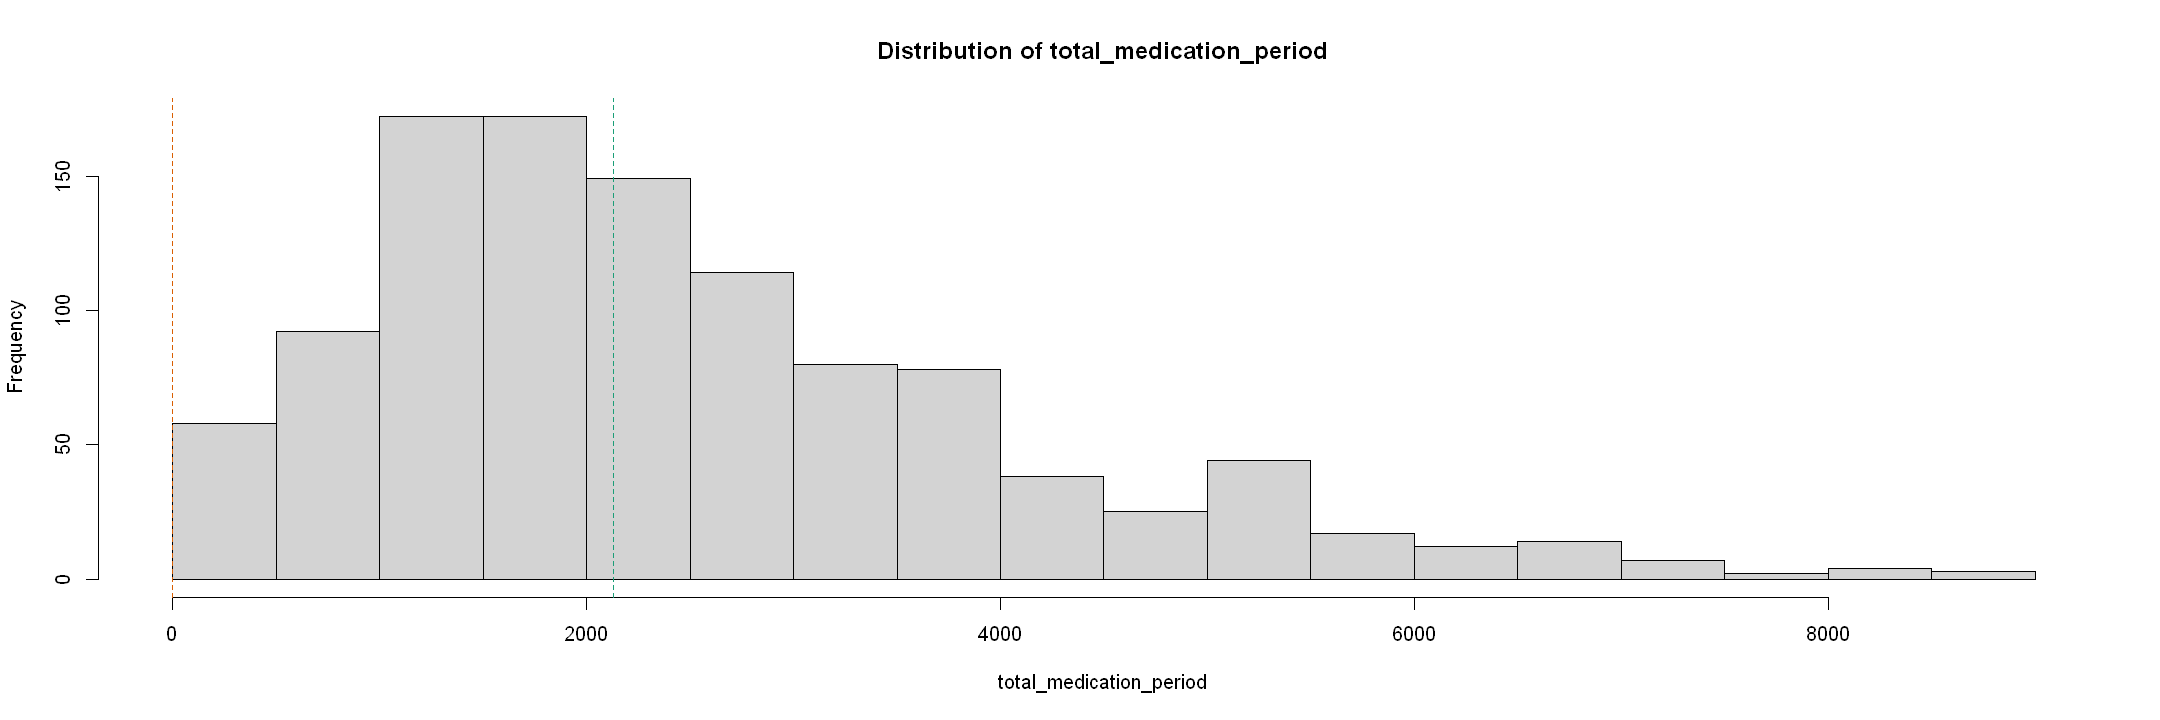

In [106]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$total_medication_period, breaks = 30, 
     main = "Distribution of total_medication_period",
     xlab = "total_medication_period")
abline(v = c(0, median(combined_dataset_imputed$total_medication_period, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "total_medication_period",
  outcomes = flare_outcomes
)

# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "total_medication_period",  
                                                     best_cat= "cat_top25"  )

summarize_chisq_for_factor(combined_dataset_imputed, "total_medication_period")

#### period_Adalimumab


PROCESSING: period_Adalimumab 

Number of unique values: 334 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0     0.0     0.0   812.7  1004.0  7198.0 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 :

      [0,1e+03] (1e+03,7.2e+03] 
            811             270 

 cat_median :

 Low High 
 737  344 

 cat_top25 :

Normal   High 
   811    270 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 12 × 8
   predictor       categorization outcome chi_sq    df p_value p_formatted     n
   <chr>           <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
 1 period_Adalimu… cat_q4         flare_…  3.17      1  0.0750 0.0750       1081
 2 period_Adalimu… cat_top25      flare_…  3.17      1  0.0750 0.0750       1081
 3 period_Adalimu… cat_median     flare_…  0.325     1  0.569  0.5686       1081
 4 period_Adalimu… cat_q4         flare_…  1.01      1  0.314  0.

Applied cat_top25 categorization to period_Adalimumab



x
  High Normal 
   270    811 

Chi-squared summary for predictor: period_Adalimumab 
        Flare ChiSq df p_value
1 flare_date1 3.170  1  0.0750
2 flare_date2 1.014  1  0.3139
3 flare_date3 0.000  1  1.0000
4 flare_date4 0.000  1  1.0000


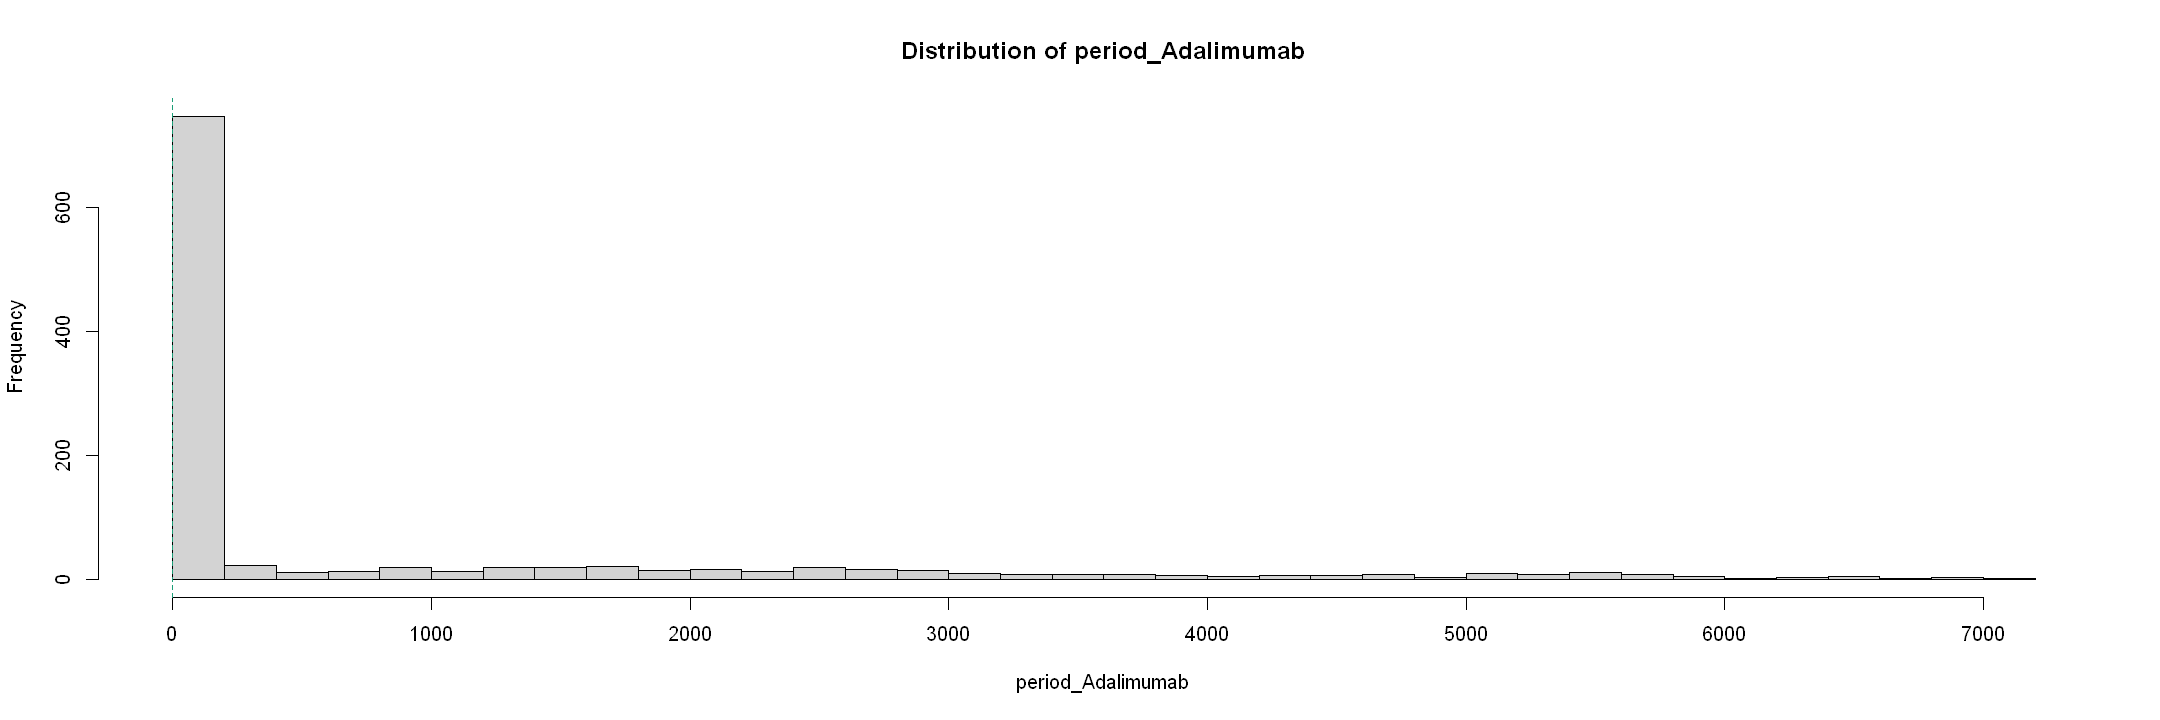

In [107]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_Adalimumab, breaks = 30, 
     main = "Distribution of period_Adalimumab",
     xlab = "period_Adalimumab")
abline(v = c(0, median(combined_dataset_imputed$period_Adalimumab, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_Adalimumab",
  outcomes = flare_outcomes
)
# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "period_Adalimumab",  
                                                     best_cat= "cat_top25"  )
summarize_chisq_for_factor(combined_dataset_imputed, "period_Adalimumab")

#### period_Infliximab_Remicade


PROCESSING: period_Infliximab_Remicade 

Number of unique values: 362 
Number of valid observations: 1081 

Overall summary statistics:
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
  -0.0833    0.0000    0.0000 1033.4682 1728.9583 8982.9583 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 :

   Low Medium   High 
   704     17    360 

 cat_q4 :

        [-0.0833,0]        (0,1.73e+03] (1.73e+03,8.98e+03] 
                704                 107                 270 

 cat_median :

 Low High 
 704  377 

 cat_top25 :

Normal   High 
   811    270 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 16 × 8
   predictor       categorization outcome chi_sq    df p_value p_formatted     n
   <chr>           <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
 1 period_Inflixi… cat_top25      flare_…  1.16      1  0.281  0.2806       1081
 2 period_Inflixi… cat_median     flare_…  1.06      1  0.304  0.3042       1081
 3 period_Inflixi… cat_q3         flare_…  1.54      2

Applied cat_q4 categorization to period_Infliximab_Remicade



x
       (0,1.73e+03] (1.73e+03,8.98e+03]         [-0.0833,0] 
                107                 270                 704 

Chi-squared summary for predictor: period_Infliximab_Remicade 
        Flare ChiSq df p_value
1 flare_date1 1.424  2 0.49080
2 flare_date2 0.549  2 0.76010
3 flare_date3 2.177  2 0.33680
4 flare_date4 6.287  2 0.04313


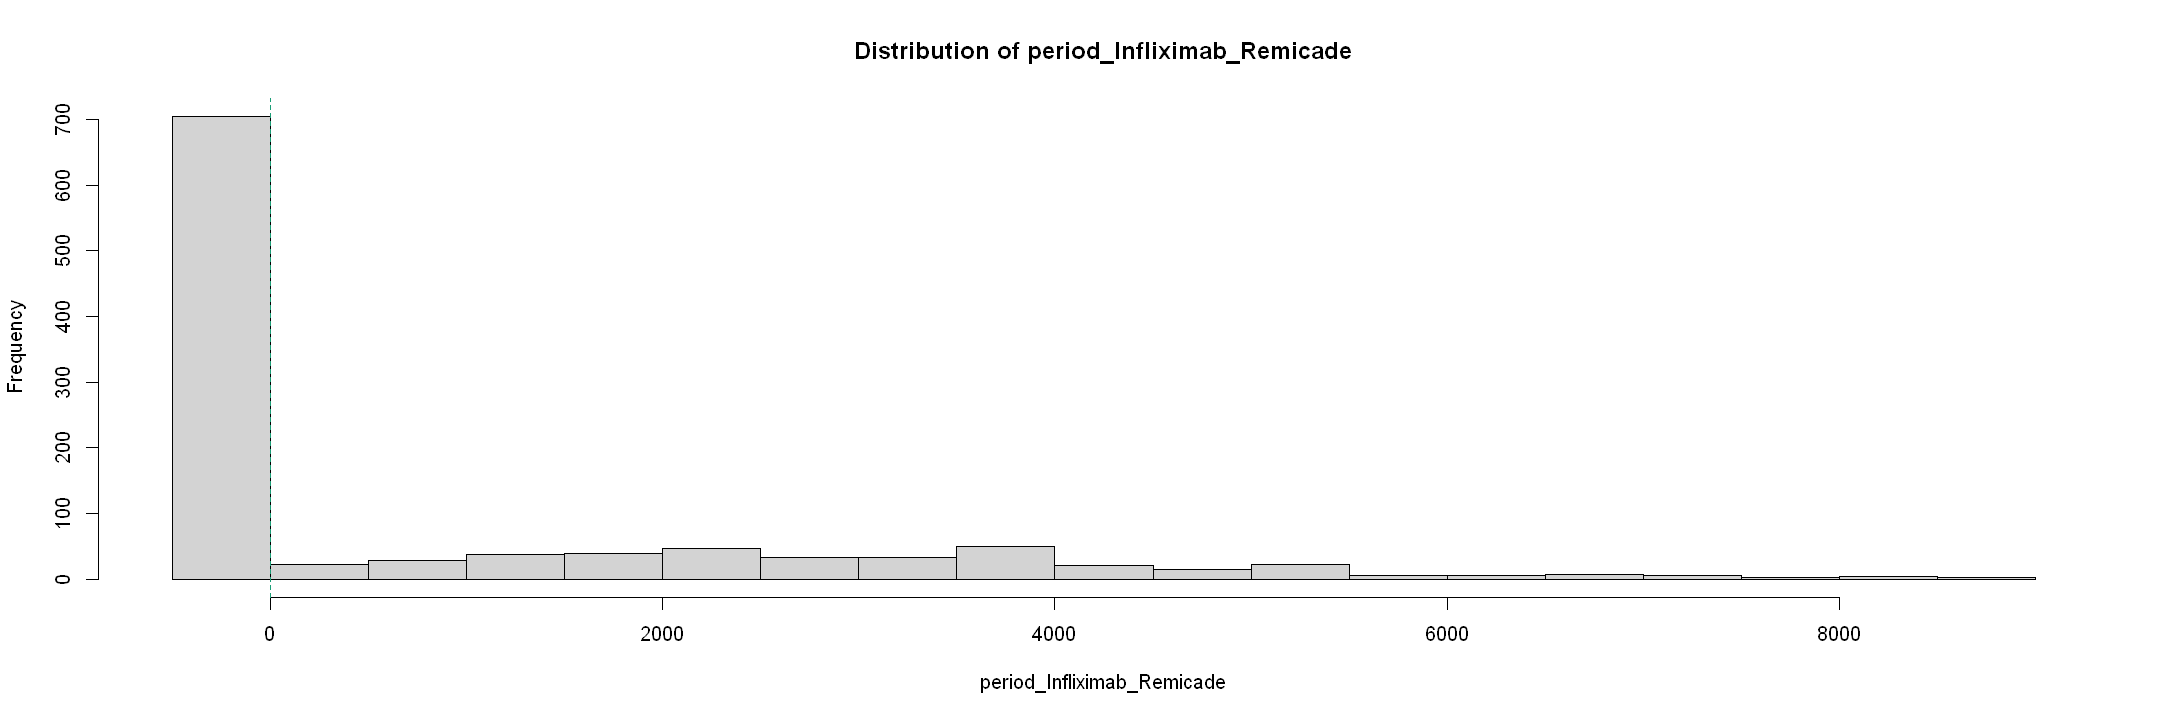

In [108]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_Infliximab_Remicade, breaks = 30, 
     main = "Distribution of period_Infliximab_Remicade",
     xlab = "period_Infliximab_Remicade")
abline(v = c(0, median(combined_dataset_imputed$period_Infliximab_Remicade, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_Infliximab_Remicade",
  outcomes = flare_outcomes
)
# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "period_Infliximab_Remicade",  
                                                     best_cat= "cat_q4"  )
summarize_chisq_for_factor(combined_dataset_imputed, "period_Infliximab_Remicade")

#### period_Vedolizumab


PROCESSING: period_Vedolizumab 

Number of unique values: 185 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0     0.0     0.0   279.3     0.0  4067.0 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
 888  193 

 cat_top25 :

Normal   High 
   888    193 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 period_Vedolizu… cat_median     flare_…  1.20      1   0.272 0.2723       1081
2 period_Vedolizu… cat_top25      flare_…  1.20      1   0.272 0.2723       1081
3 period_Vedolizu… cat_median     flare_…  0.375     1   0.540 0.5404       1081
4 period_Vedolizu… cat_top25      flare_…  0.375     1   0.540 0.5404       1081
5 period_

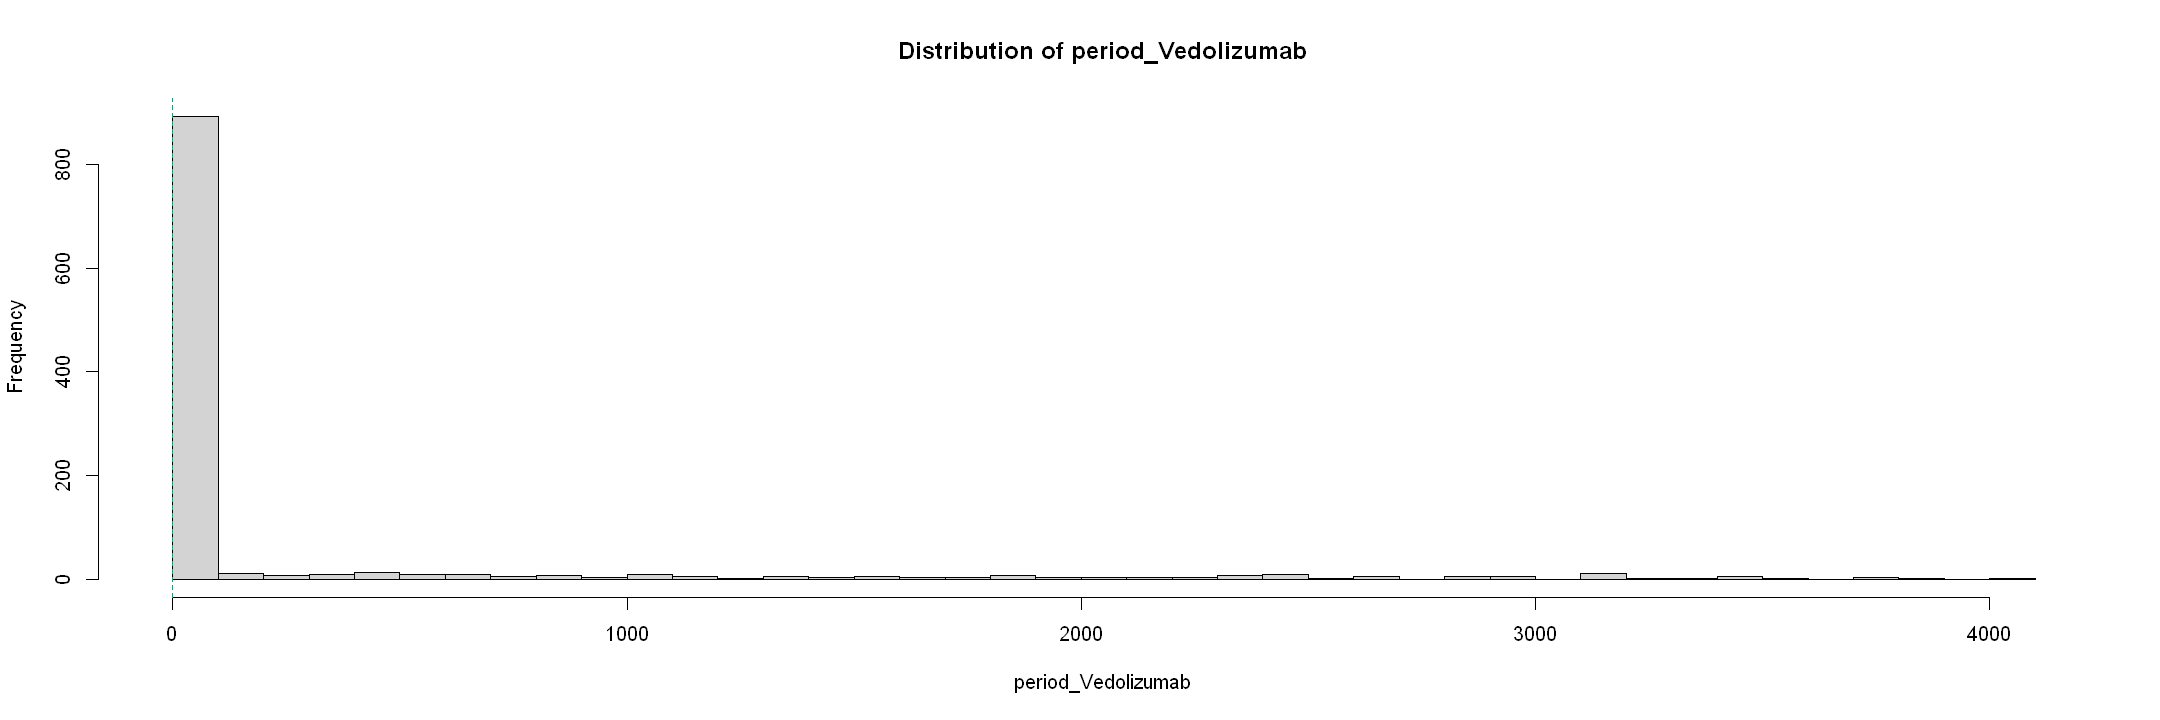

In [109]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_Vedolizumab, breaks = 30, 
     main = "Distribution of period_Vedolizumab",
     xlab = "period_Vedolizumab")
abline(v = c(0, median(combined_dataset_imputed$period_Vedolizumab, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_Vedolizumab",
  outcomes = flare_outcomes
)

combined_dataset_imputed$period_Vedolizumab<- scale(combined_dataset_imputed$period_Vedolizumab) 

#### period_UNknown80


PROCESSING: period_UNknown80 

Number of unique values: 21 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   6.113   0.000 729.000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1061   20 

 cat_top25 :

Normal   High 
  1061     20 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 period_UNknown80 cat_median     flare_…  0.198     1   0.656 0.6565       1081
2 period_UNknown80 cat_top25      flare_…  0.198     1   0.656 0.6565       1081
3 period_UNknown80 cat_median     flare_…  0         1   1.00  1.0000       1081
4 period_UNknown80 cat_top25      flare_…  0         1   1.00  1.0000       1081
5 period_UNk

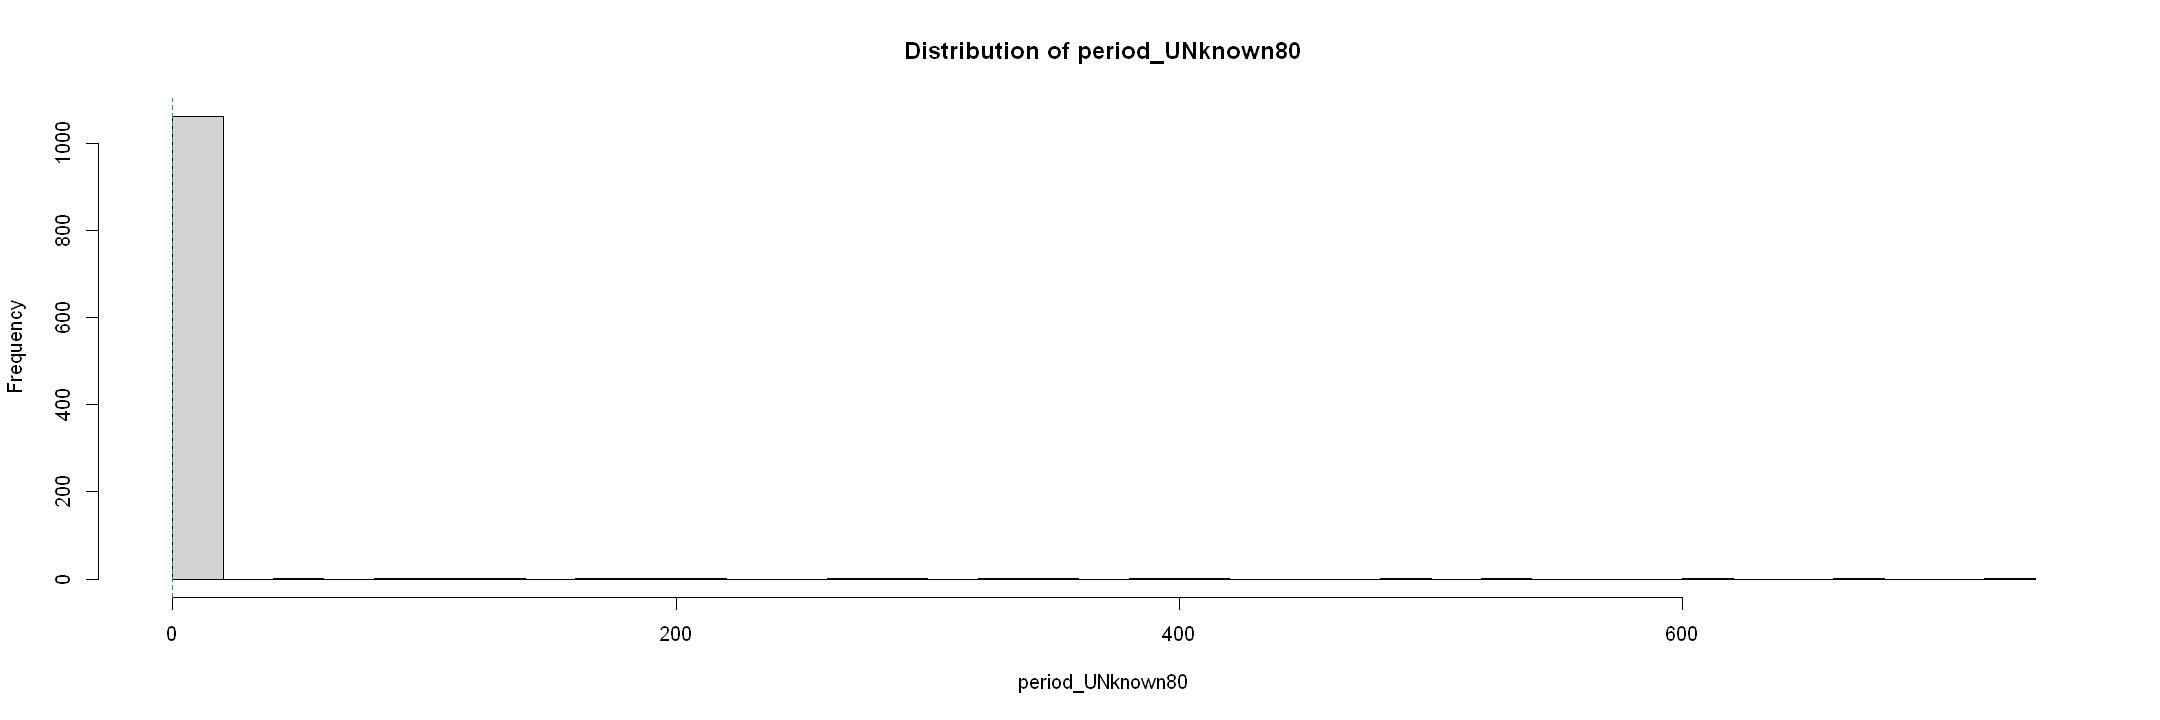

In [110]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_UNknown80, breaks = 30, 
     main = "Distribution of period_UNknown80",
     xlab = "period_UNknown80")
abline(v = c(0, median(combined_dataset_imputed$period_UNknown80, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_UNknown80",
  outcomes = flare_outcomes
)
combined_dataset_imputed$period_UNknown80<- scale(combined_dataset_imputed$period_UNknown80)


#### period_Ustekinumab_Stelara


PROCESSING: period_Ustekinumab_Stelara 

Number of unique values: 240 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0     0.0     0.0   296.3     0.0  3220.0 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
 835  246 

 cat_top25 :

Normal   High 
   835    246 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 period_Ustekinu… cat_median     flare_…  0.155     1  0.694  0.6937       1081
2 period_Ustekinu… cat_top25      flare_…  0.155     1  0.694  0.6937       1081
3 period_Ustekinu… cat_median     flare_…  0.032     1  0.857  0.8572       1081
4 period_Ustekinu… cat_top25      flare_…  0.032     1  0.857  0.8572       1081
5

Applied cat_top25 categorization to period_Ustekinumab_Stelara



x
  High Normal 
   246    835 

Chi-squared summary for predictor: period_Ustekinumab_Stelara 
        Flare ChiSq df p_value
1 flare_date1 0.155  1 0.69370
2 flare_date2 0.032  1 0.85720
3 flare_date3 4.576  1 0.03243
4 flare_date4 4.262  1 0.03897


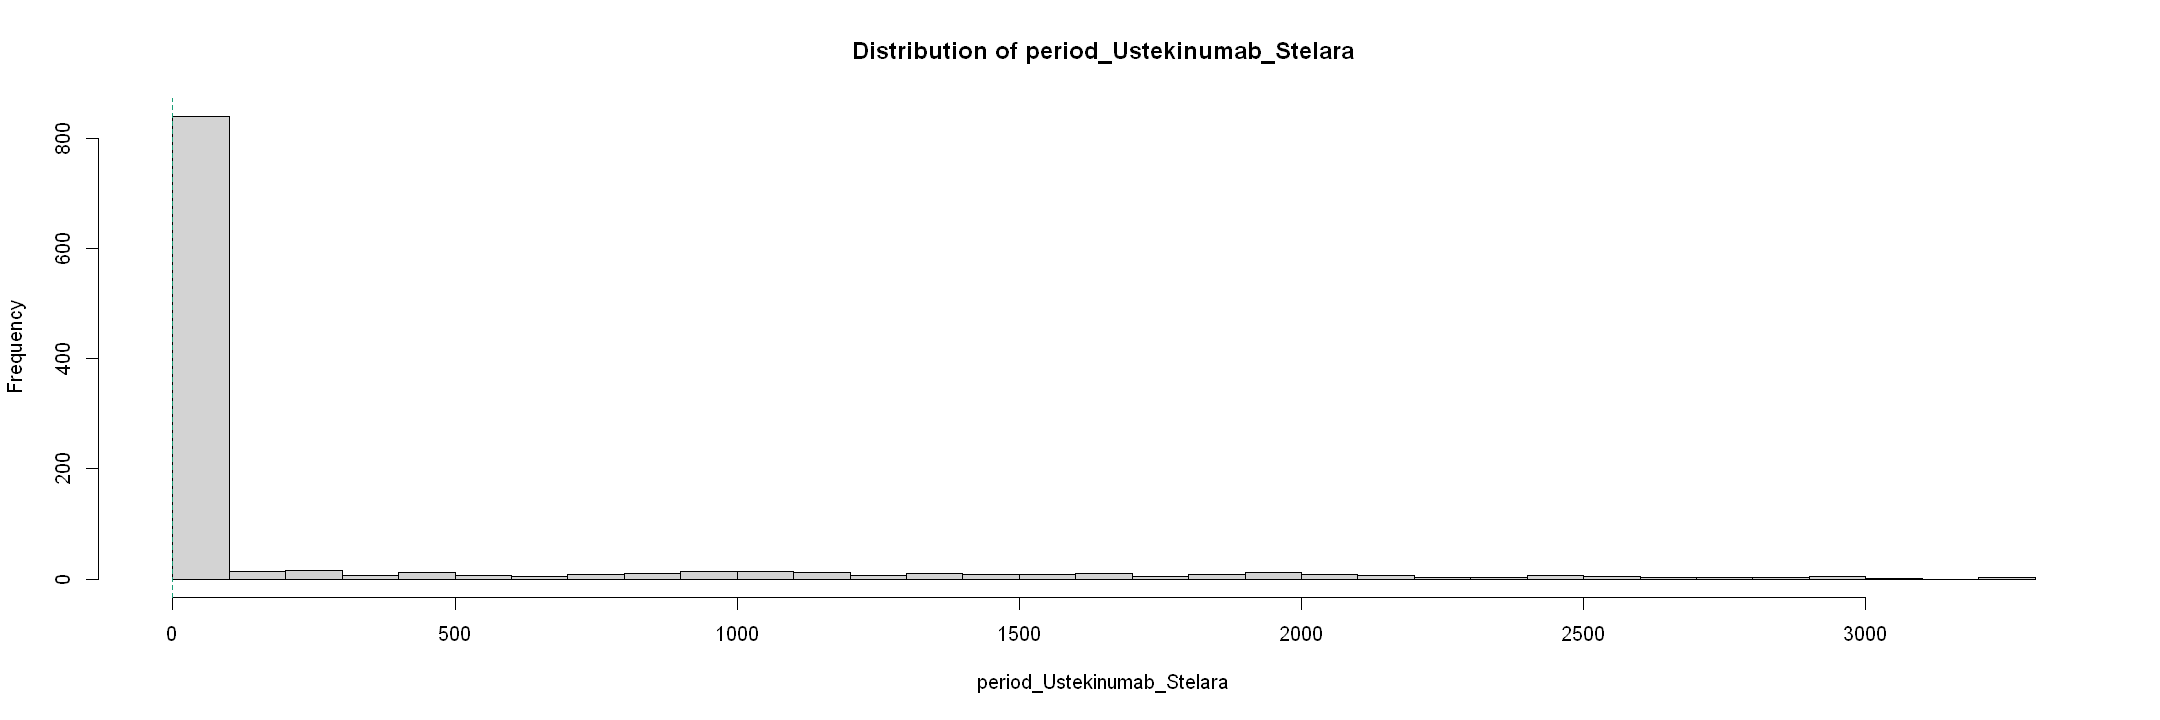

In [111]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_Ustekinumab_Stelara, breaks = 30, 
     main = "Distribution of period_Ustekinumab_Stelara",
     xlab = "period_Ustekinumab_Stelara")
abline(v = c(0, median(combined_dataset_imputed$period_Ustekinumab_Stelara, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_Ustekinumab_Stelara",
  outcomes = flare_outcomes
)
# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "period_Ustekinumab_Stelara",  
                                                     best_cat= "cat_top25"  )
summarize_chisq_for_factor(combined_dataset_imputed, "period_Ustekinumab_Stelara")

#### period_Tofacitinib


PROCESSING: period_Tofacitinib 

Number of unique values: 20 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    0.00   23.92    0.00 2408.96 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1062   19 

 cat_top25 :

Normal   High 
  1062     19 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 period_Tofaciti… cat_median     flare_…  1.66      1   0.198 0.1976       1081
2 period_Tofaciti… cat_top25      flare_…  1.66      1   0.198 0.1976       1081
3 period_Tofaciti… cat_median     flare_…  0.756     1   0.385 0.3847       1081
4 period_Tofaciti… cat_top25      flare_…  0.756     1   0.385 0.3847       1081
5 period_T

Applied cat_top25 categorization to period_Tofacitinib



x
  High Normal 
    19   1062 

Chi-squared summary for predictor: period_Tofacitinib 
        Flare ChiSq df p_value
1 flare_date1 1.660  1  0.1976
2 flare_date2 0.756  1  0.3847
3 flare_date3 2.247  1  0.1338
4 flare_date4 0.249  1  0.6175


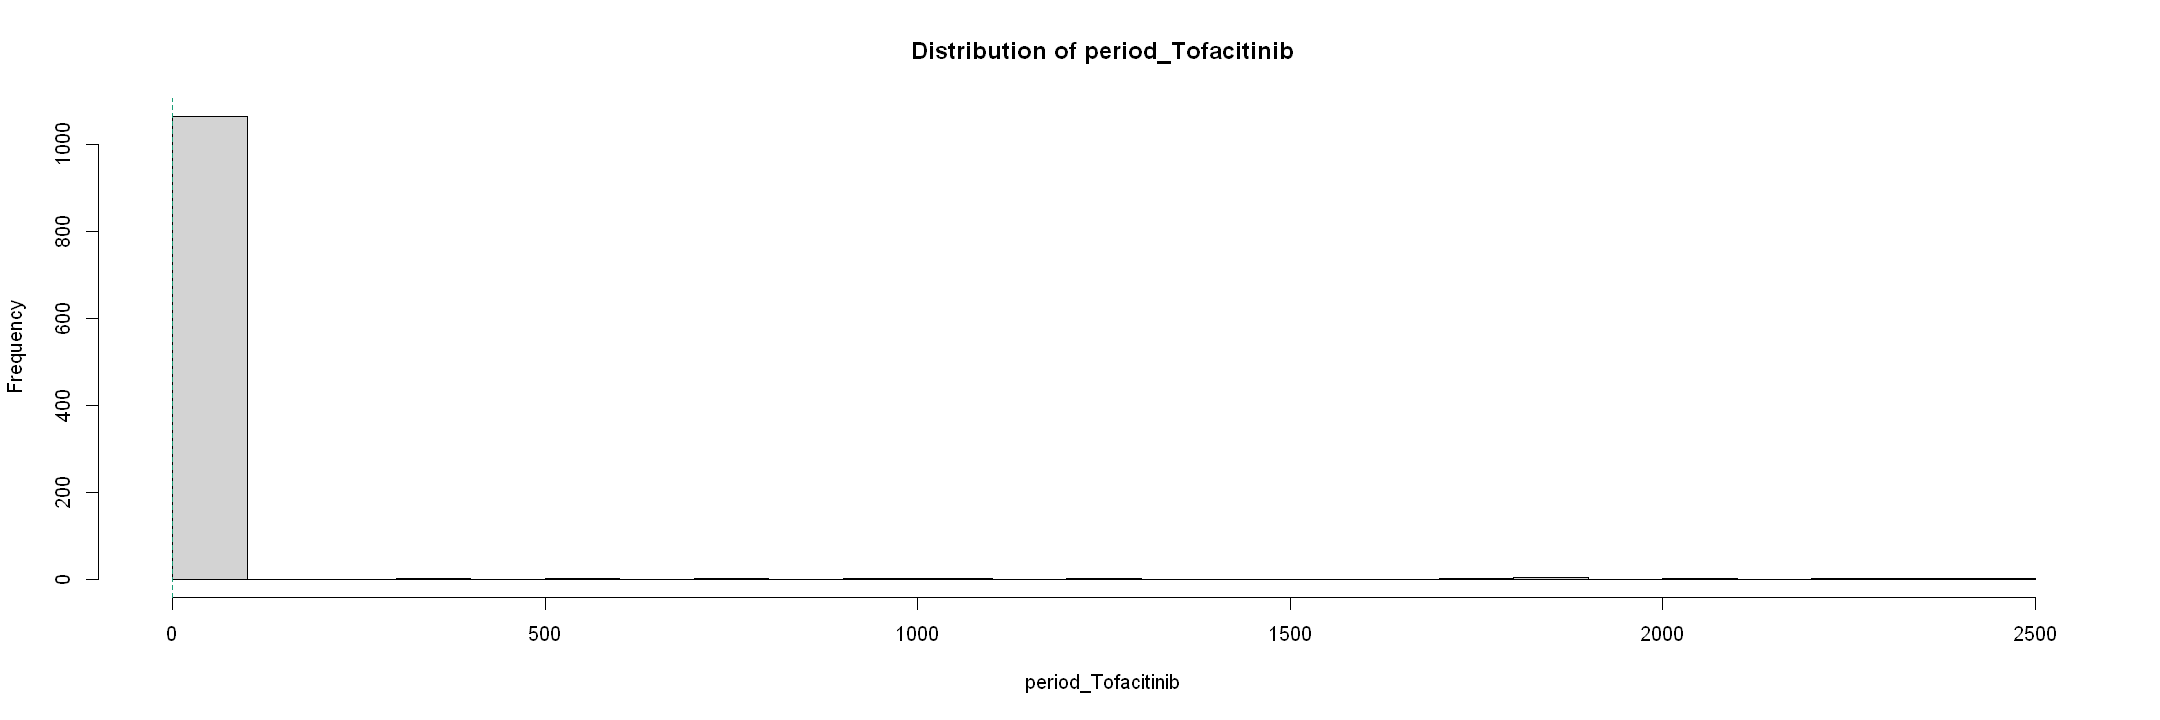

In [112]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_Tofacitinib, breaks = 30, 
     main = "Distribution of period_Tofacitinib",
     xlab = "period_Tofacitinib")
abline(v = c(0, median(combined_dataset_imputed$period_Tofacitinib, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)


results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_Tofacitinib",
  outcomes = flare_outcomes)
# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "period_Tofacitinib",  
                                                     best_cat= "cat_top25"  )


summarize_chisq_for_factor(combined_dataset_imputed, "period_Tofacitinib")

#### period_UNknown88


PROCESSING: period_UNknown88 

Number of unique values: 54 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    0.00   27.35    0.00 3148.96 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1028   53 

 cat_top25 :

Normal   High 
  1028     53 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 period_UNknown88 cat_median     flare_…  2.77      1  0.0962 0.0962       1081
2 period_UNknown88 cat_top25      flare_…  2.77      1  0.0962 0.0962       1081
3 period_UNknown88 cat_median     flare_…  0.94      1  0.332  0.3323       1081
4 period_UNknown88 cat_top25      flare_…  0.94      1  0.332  0.3323       1081
5 period_UNk

Applied cat_top25 categorization to period_UNknown88



x
  High Normal 
    53   1028 

Chi-squared summary for predictor: period_UNknown88 
        Flare ChiSq df p_value
1 flare_date1 2.767  1 0.09625
2 flare_date2 0.940  1 0.33230
3 flare_date3 3.461  1 0.06284
4 flare_date4 0.551  1 0.45800


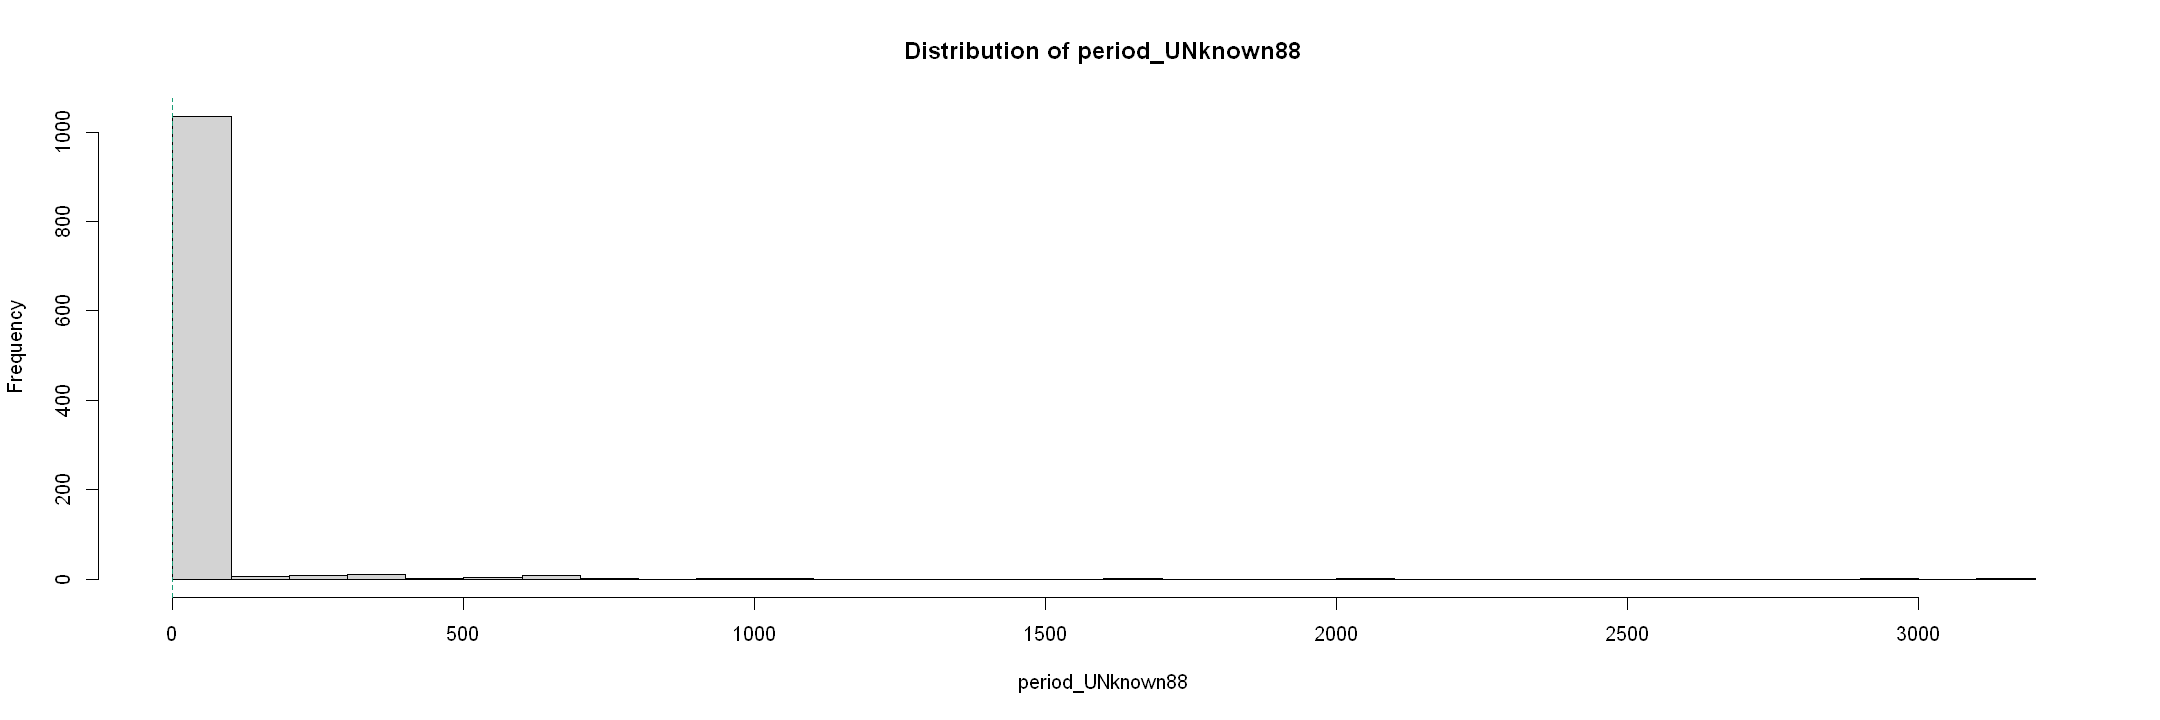

In [113]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_UNknown88, breaks = 30, 
     main = "Distribution of period_UNknown88",
     xlab = "period_UNknown88")
abline(v = c(0, median(combined_dataset_imputed$period_UNknown88, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_UNknown88",
  outcomes = flare_outcomes)
# Add best categorizations to the main dataset
combined_dataset_imputed <- add_best_categorizations(data= combined_dataset_imputed, 
                                                     predictor_name= "period_UNknown88",  
                                                     best_cat= "cat_top25"  )


summarize_chisq_for_factor(combined_dataset_imputed, "period_UNknown88")

#### period_UNknown77


PROCESSING: period_UNknown77 

Number of unique values: 16 
Number of valid observations: 1081 

Overall summary statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    0.000    0.000    7.051    0.000 1304.042 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1066   15 

 cat_top25 :

Normal   High 
  1066     15 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq    df p_value p_formatted     n
  <chr>            <chr>          <chr>    <dbl> <int>   <dbl> <chr>       <int>
1 period_UNknown77 cat_median     flare_… NA        NA   1     1.0000       1081
2 period_UNknown77 cat_top25      flare_… NA        NA   1     1.0000       1081
3 period_UNknown77 cat_median     flare_…  0.129     1   0.720 0.7198       1081
4 period_UNknown77 cat_top25      flare_…  0.129     1   0.720 0.7198       1081


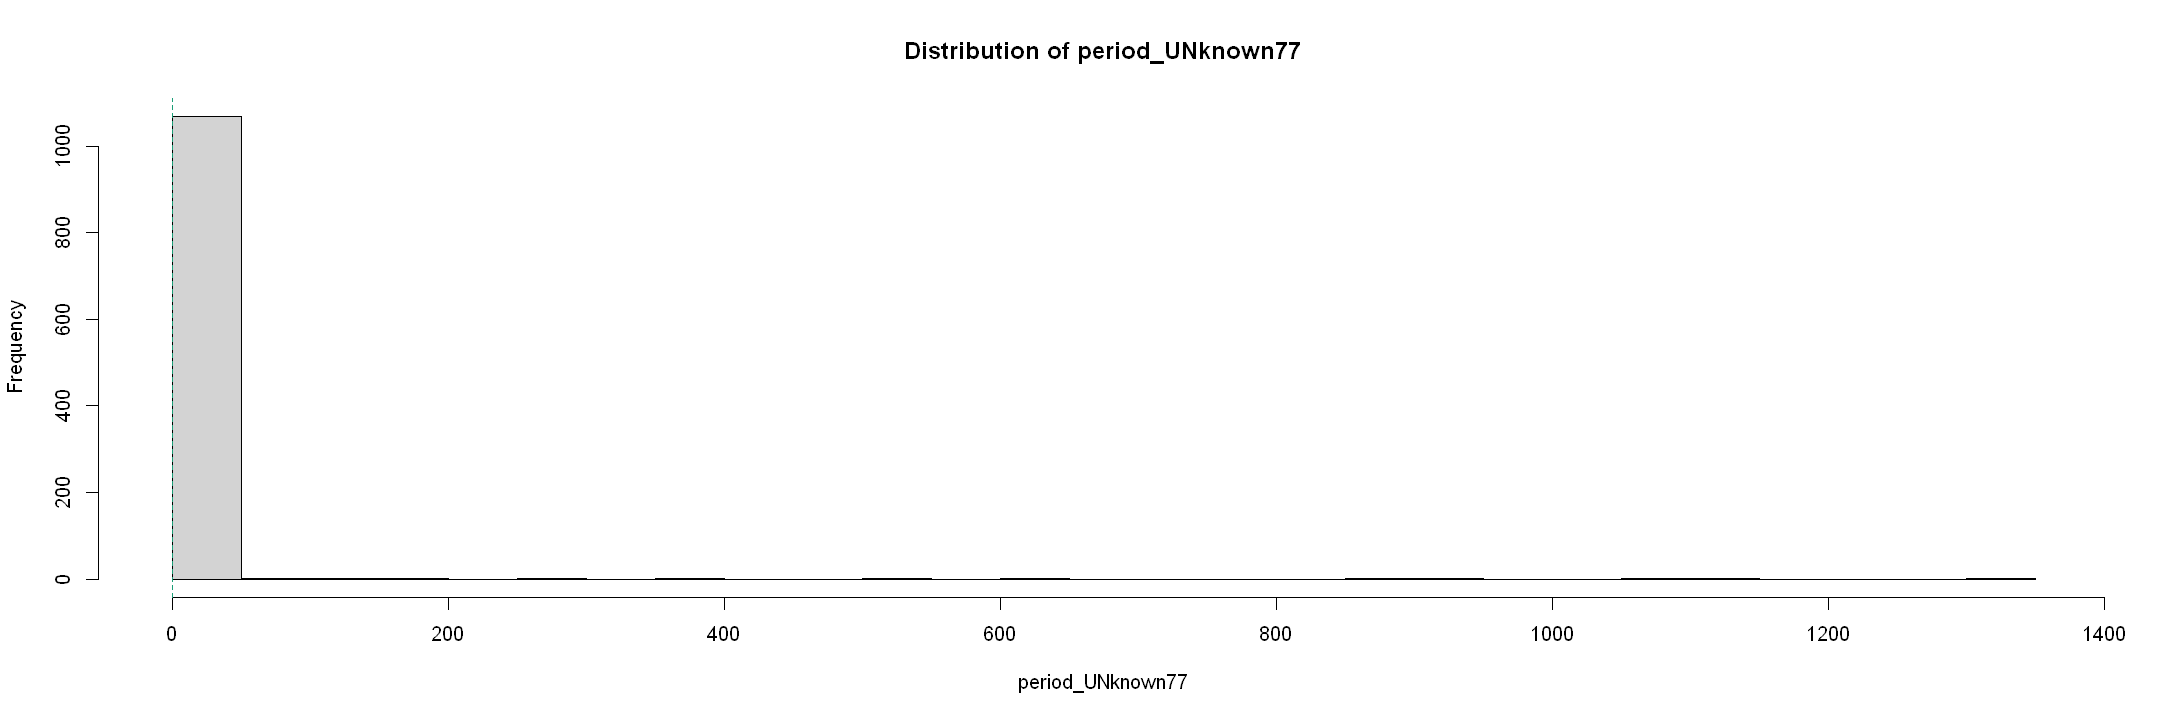

In [114]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_UNknown77, breaks = 30, 
     main = "Distribution of period_UNknown77",
     xlab = "period_UNknown77")
abline(v = c(0, median(combined_dataset_imputed$period_UNknown77, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_UNknown77",
  outcomes = flare_outcomes
)
combined_dataset_imputed$period_UNknown77<- scale(combined_dataset_imputed$period_UNknown77)

#### period_UNknown70


PROCESSING: period_UNknown70 

Number of unique values: 6 
Number of valid observations: 1081 

Overall summary statistics:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    0.000    0.000    2.945    0.000 1471.000 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1076    5 

 cat_top25 :

Normal   High 
  1076      5 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq df    p_value p_formatted     n
  <chr>            <chr>          <chr>   <lgl>  <lgl>   <dbl> <chr>       <int>
1 period_UNknown70 cat_median     flare_… NA     NA      0.658 0.6585       1081
2 period_UNknown70 cat_top25      flare_… NA     NA      0.658 0.6585       1081
3 period_UNknown70 cat_median     flare_… NA     NA      0.664 0.6639       1081
4 period_UNknown70 cat_top25      flare_… NA     NA      0.664 0.6639       1081
5

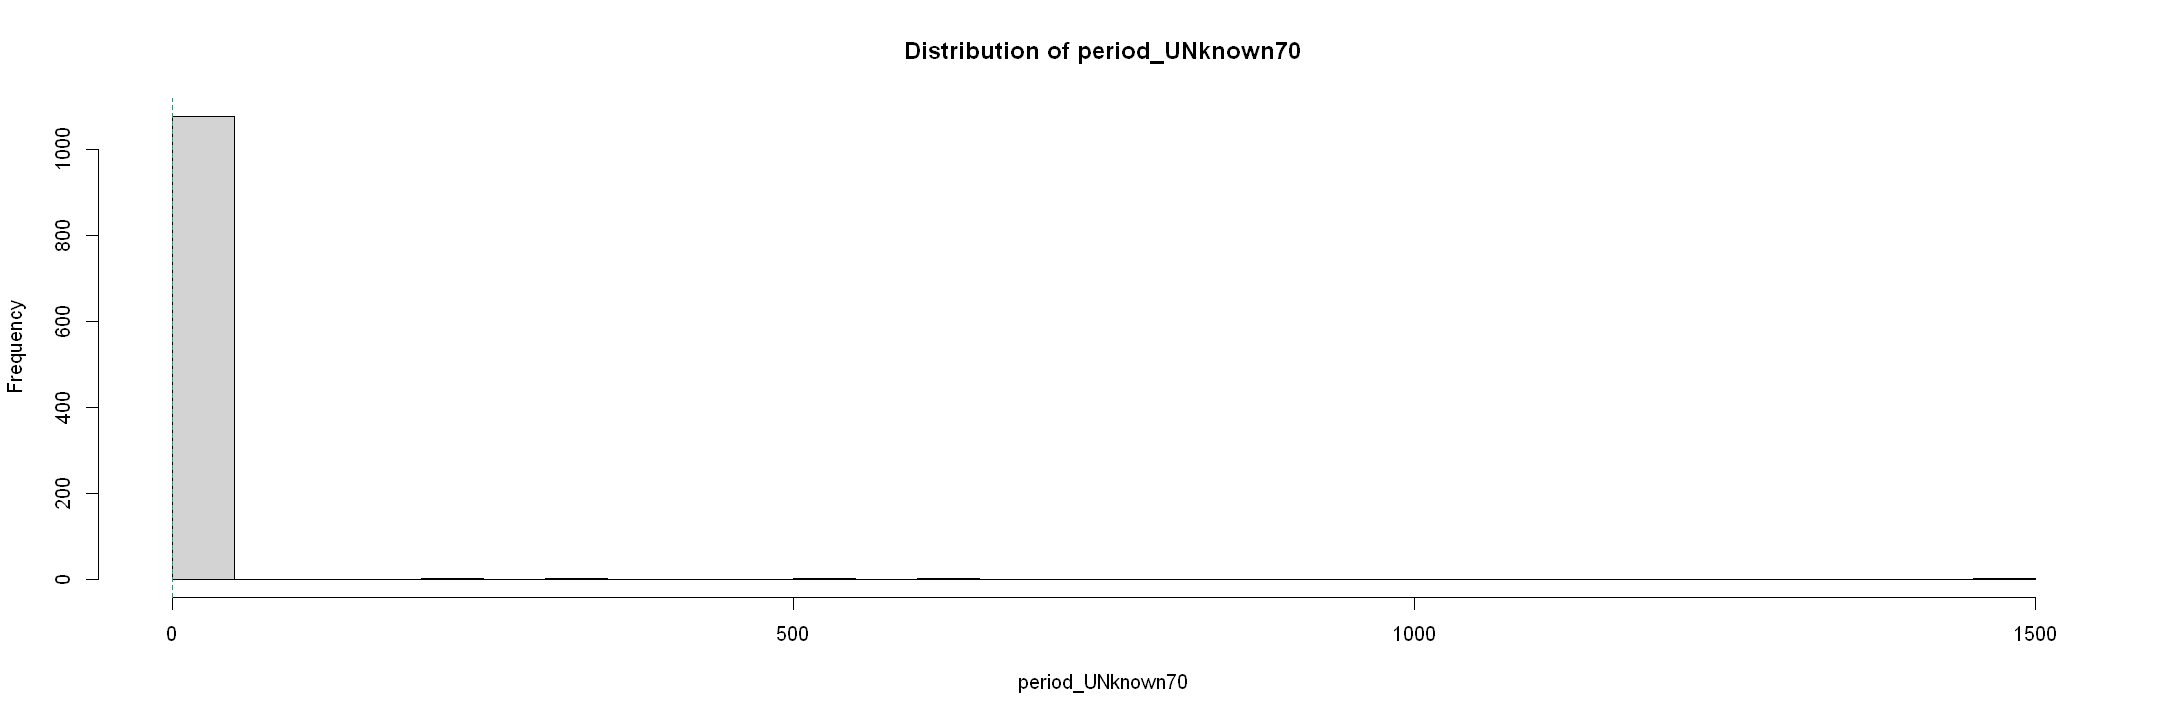

In [115]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_UNknown70, breaks = 30, 
     main = "Distribution of period_UNknown70",
     xlab = "period_UNknown70")
abline(v = c(0, median(combined_dataset_imputed$period_UNknown70, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)

results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_UNknown70",
  outcomes = flare_outcomes
)
combined_dataset_imputed$period_UNknown70<- scale(combined_dataset_imputed$period_UNknown70)

#### period_Golimumab


PROCESSING: period_Golimumab 

Number of unique values: 11 
Number of valid observations: 1081 

Overall summary statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    0.00   14.62    0.00 3604.96 

=== CATEGORIZATION DISTRIBUTIONS ===

 cat_q3 : SKIPPED (insufficient categories or data)

 cat_q4 : SKIPPED (insufficient categories or data)

 cat_median :

 Low High 
1071   10 

 cat_top25 :

Normal   High 
  1071     10 

=== CHI-SQUARE TEST RESULTS ===
# A tibble: 8 × 8
  predictor        categorization outcome chi_sq df    p_value p_formatted     n
  <chr>            <chr>          <chr>   <lgl>  <lgl>   <dbl> <chr>       <int>
1 period_Golimumab cat_median     flare_… NA     NA     0.515  0.5154       1081
2 period_Golimumab cat_top25      flare_… NA     NA     0.515  0.5154       1081
3 period_Golimumab cat_median     flare_… NA     NA     0.200  0.1998       1081
4 period_Golimumab cat_top25      flare_… NA     NA     0.200  0.1998       1081
5 period_Gol

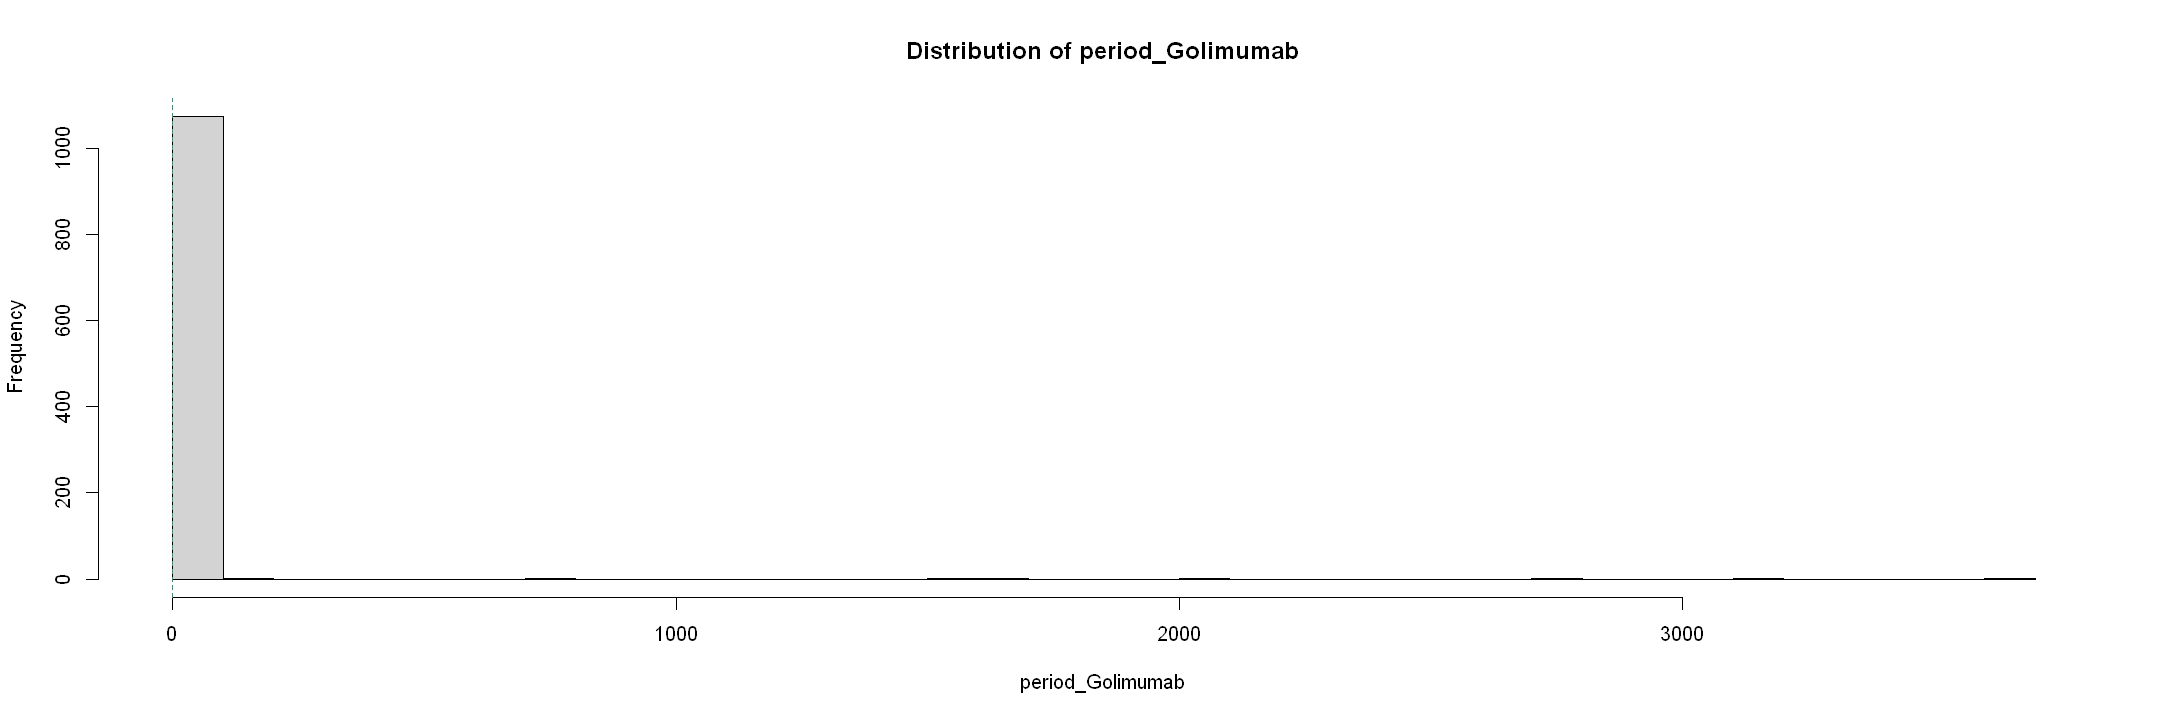

In [116]:
# Visualize distribution
options(repr.plot.width=18, repr.plot.height=6)
hist(combined_dataset_imputed$period_Golimumab, breaks = 30, 
     main = "Distribution of period_Golimumab",
     xlab = "period_Golimumab")
abline(v = c(0, median(combined_dataset_imputed$period_Golimumab, na.rm = TRUE)), 
       col = c( "#D95F02", "#1B9E77"), lty = 2)





results <- categorize_and_test_predictor(
  data = combined_dataset_imputed,
  predictor_name = "period_Golimumab",
  outcomes = flare_outcomes
)


### 3.5.2 Univariate Validation

Each predictor is screened using:

- Univariate logistic regression
- AUC calculation with 95% CI
- Variables retained if AUC > 0.52 and CI excludes 0.5

This reduces dimensionality while preserving predictive variables.

A univariate logistic approach  for each predictor is used.  AUC + 95% CI are computed per predictor per outcome, and then filter predictors with AUC > 0.55 to get “best” predictors.

In [117]:
library(pROC)

univariate_validation <- function(df, outcomes, predictors, auc_threshold = 0.55) {

  compute_simple_auc <- function(y, x) {
    tmp <- data.frame(y = y, x = x)
    tmp <- tmp[complete.cases(tmp), ]

    # Convert factor to numeric if needed
    if(is.factor(tmp$x)) tmp$x <- as.numeric(tmp$x)

    if(length(unique(tmp$x)) < 2 || length(unique(tmp$y)) < 2) {
      return(list(auc = NA, ci_lower = NA, ci_upper = NA))
    }
    set.seed(12)

    fit <- glm(y ~ x, data = tmp, family = binomial)
    prob <- predict(fit, type = "response")
    
    roc_obj <- roc(tmp$y, prob, quiet = TRUE)
    auc_val <- as.numeric(roc_obj$auc)
    
    ci <- tryCatch({
      ci_result <- ci.auc(roc_obj, conf.level = 0.95)
      c(ci_result[1], ci_result[3])
    }, error = function(e) c(NA, NA))
    
    list(auc = auc_val, ci_lower = ci[1], ci_upper = ci[2])
  }

  results <- expand.grid(outcome = outcomes, predictor = predictors, stringsAsFactors = FALSE)
  results$auc <- NA
  results$ci_lower <- NA
  results$ci_upper <- NA

  for(i in seq_len(nrow(results))) {
    stats <- compute_simple_auc(df[[results$outcome[i]]], df[[results$predictor[i]]])
    results$auc[i] <- stats$auc
    results$ci_lower[i] <- stats$ci_lower
    results$ci_upper[i] <- stats$ci_upper
  }

  # Flag “validated” predictors
  results$ci_excludes_0.5 <- results$ci_lower > 0.5
  results$above_threshold <- results$auc > auc_threshold
  results$validated <- results$ci_excludes_0.5 & results$above_threshold

  return(results)
}

In [118]:
outcomes <- c("flare_date1", "flare_date2", "flare_date3", "flare_date4")
predictors <- setdiff(colnames(combined_dataset_imputed), outcomes)

validation_results <- univariate_validation(
  df = combined_dataset_imputed,
  outcomes = outcomes,
  predictors = predictors,
  auc_threshold = 0.52
)

# Filter validated predictors
validated_predictors <- validation_results[validation_results$validated, ]

# Get unique predictors that are validated for at least one outcome
unique_validated_predictors <- validated_predictors %>%
  pull(predictor) %>%
  unique()


# Select only the validated predictors 
filtered_data <- combined_dataset_imputed %>%
  dplyr::select(outcomes, all_of(unique_validated_predictors))

### 3.5.2 Create disease-specific interactions

Three critical interaction terms capture disease-specific effects:

- DiseaseEntity × montreal_extent_uc (UC-specific extent)
- DiseaseEntity × montreal_severity_uc (UC-specific severity)
- DiseaseEntity × surg_ileocaecal_resection (CD-specific surgery)

Disease-specific interaction variables Are created by explicitly interacting DiseaseEntity (CD vs UC) with selected clinical features. Rather than fitting separate models for CD and UC, disease-specific effects are encoded directly in the design matrix.

The following interaction variables are created:

* DiseaseEntity_x_extent_uc: Captures Montreal extent only for UC patients, set to zero for CD patients.

* DiseaseEntity × montreal_severity_uc: Encodes UC-specific disease severity, ensuring that severity information is not incorrectly applied to CD patients.

* DiseaseEntity × surg_ileocaecal_resection: Encodes surgical burden only for CD patients, since ileocaecal resection is not clinically meaningful for UC.

* DiseaseEntity_x_age_cd: Encodes age effects only within CD, allowing age to influence risk differently by disease type.

Why these variables were created

- CD and UC have distinct disease mechanisms, clinical trajectories, and treatment pathways

- Raw variables such as extent, severity, and surgery are not shared constructs

- Without interactions, the model implicitly assumes identical effects across diseases, which is clinically incorrect

These interaction variables enforce clinical validity directly at the encoding level, rather than relying on the model to learn this implicitly.

In [119]:

filtered_data <- filtered_data %>%
  mutate(
    # Interaction: DiseaseEntity × montreal_extent_uc
    # Only meaningful for UC patients (CD will have this = 0)
    DiseaseEntity_x_extent_uc = factor(
         ifelse(DiseaseEntity == "UC", 
                as.numeric(as.character(montreal_extent_uc)), 
                0)),
    
    # Interaction: DiseaseEntity × montreal_severity_uc
    # Only meaningful for UC patients (CD will have this = 0)
    DiseaseEntity_x_severity_uc = factor(ifelse(
      DiseaseEntity == "UC", 
      as.numeric(as.character(montreal_severity_uc)), 
      0
    )),
    
    # Interaction: DiseaseEntity × surg_ileocaecal_resection
    # Only meaningful for CD patients (UC will have this = 0)
    DiseaseEntity_x_surg_ileo = factor(ifelse(
      DiseaseEntity == "CD", 
      as.numeric(as.character(surg_ileocaecal_resection)), 
      0
    ))
  )


In [120]:
print(names(filtered_data))

 [1] "flare_date1"                      "flare_date2"                     
 [3] "flare_date3"                      "flare_date4"                     
 [5] "DiseaseEntity"                    "gender"                          
 [7] "age_at_inclusion"                 "montreal_extent_uc"              
 [9] "montreal_severity_uc"             "surg_ileocaecal_resection"       
[11] "age_at_surg_ileocaecal_resection" "Anxious_mean"                    
[13] "Stress_mean"                      "Fatigue_mean"                    
[15] "Pain_mean"                        "smoker"                          
[17] "used_Ustekinumab_Stelara"         "total_medication"                
[19] "period_Ustekinumab_Stelara"       "severity_uc_std"                 
[21] "surgery_cd_std"                   "fatigue_std"                     
[23] "pain_std"                         "disease_burden_score"            
[25] "DiseaseEntity_x_extent_uc"        "DiseaseEntity_x_severity_uc"     
[27] "DiseaseEntity_x_sur

In [121]:

# select & order predictors
filtered_data <- filtered_data %>%
  dplyr::select(starts_with("flare"),
                "DiseaseEntity",
                "gender",
                "age_at_inclusion",
                
                "DiseaseEntity_x_extent_uc",
                "DiseaseEntity_x_severity_uc",                
                "DiseaseEntity_x_surg_ileo",
                
                "period_Ustekinumab_Stelara",
                "total_medication",
                
                "Anxious_mean",
                "Stress_mean",
                
                "disease_burden_score",
                "Fatigue_mean",
                "Pain_mean",
                
                "smoker")

# 4. GLASSO Models

## 4.1 Feature extraction:

Dataset is randomly split into training (70%) and testing (30%) sets using a fixed seed to ensure reproducibility. Separate outcome vectors (y1–y4) are created for each prediction time point, while the same predictor matrix X is used across models.

In [122]:
# Set dataset parameters
#=========================

## 1. Dependent variable

# ---------------------------
y1 <- as.numeric(filtered_data$flare_date1)  # Convert y from factor to numeric
y1 <- ifelse(y1 == 0, -1, 1) # Convert y from {1, 2} to {-1, 1}

y2 <- as.numeric(filtered_data$flare_date2)  # Convert y from factor to numeric
y2 <- ifelse(y2 == 0, -1, 1) # Convert y from {1, 2} to {-1, 1}

y3 <- as.numeric(filtered_data$flare_date3)  # Convert y from factor to numeric
y3 <- ifelse(y3 == 0, -1, 1) # Convert y from {1, 2} to {-1, 1}

y4 <- as.numeric(filtered_data$flare_date4)  # Convert y from factor to numeric
y4 <- ifelse(y4 == 0, -1, 1) # Convert y from {1, 2} to {-1, 1}

## 1. Create data matrix for independent variables  one-hotmatrix


outcomes <- c("flare_date1", "flare_date2", "flare_date3", "flare_date4")

predictors <- setdiff(
  colnames(filtered_data),
  outcomes
)

X <- model.matrix(
  ~ . - 1,
  data = filtered_data[, predictors]
)

X <- as.data.frame(X) %>%
    dplyr::select(-ends_with("NA"),-ends_with("9999"))

column_names <- colnames(X)
print(column_names)

 [1] "DiseaseEntityCD"                "DiseaseEntityUC"               
 [3] "genderFemale"                   "age_at_inclusionQ2"            
 [5] "age_at_inclusionQ3"             "age_at_inclusionQ4"            
 [7] "DiseaseEntity_x_extent_uc1"     "DiseaseEntity_x_extent_uc2"    
 [9] "DiseaseEntity_x_extent_uc3"     "DiseaseEntity_x_severity_uc1"  
[11] "DiseaseEntity_x_surg_ileo1"     "period_Ustekinumab_StelaraHigh"
[13] "total_medicationHigh"           "Anxious_mean(0.25,0.667]"      
[15] "Anxious_mean(0.667,2]"          "Stress_meanQ2"                 
[17] "Stress_meanQ3"                  "Stress_meanQ4"                 
[19] "disease_burden_scoreMedium"     "disease_burden_scoreHigh"      
[21] "Fatigue_meanMedium"             "Fatigue_meanHigh"              
[23] "Pain_mean(1,2]"                 "smokerFormer"                  
[25] "smokerCurrent"                 


Split data into training (70%) and test (30%) sets

-   Training set (e.g. 70%)

-   Test set (e.g. 30%)

In [123]:
# 1  Split data into training (0%) and test (30%) sets
set.seed(123) # For reproducibility
n <- length(y1)
train_indices <- sample(1:n, size = round(0.7 * n))
test_indices <- setdiff(1:n, train_indices)

# Training data
X_train <- X[train_indices, ]
y1_train <- y1[train_indices]
y2_train <- y2[train_indices]
y3_train <- y3[train_indices]
y4_train <- y4[train_indices]

# Test data
X_test <- X[test_indices, ]
y1_test <- y1[test_indices]
y2_test <- y2[test_indices]
y3_test <- y3[test_indices]
y4_test <- y4[test_indices]

cat("Training set size:", length(y1_train), "\n")
cat("Test set size:", length(y1_test), "\n")


Training set size: 757 
Test set size: 324 


## 4.2 Variable Grouping Structure

Predictors were grouped into clinically coherent domains to guide Group Lasso selection. 

**Group 1 (Baseline demographics)** included DiseaseEntityCD, DiseaseEntityUC, genderFemale, age_at_inclusionQ2–Q4, providing a stable anchor. 

**Group 2 (Disease-specific interactions)** comprised DiseaseEntity_x_extent_uc1–3, DiseaseEntity_x_severity_uc1, DiseaseEntity_x_age_cd1, encoding UC/CD heterogeneity. 

**Group 3 (CD surgery burden)** included DiseaseEntity_x_surg_ileo1. 

**Group 4 (Treatment intensity)** included period_Ustekinumab_StelaraHigh, total_medicationHigh. 

**Group 5 (Psychosocial distress)** comprised Anxious_mean, Stress_meanQ2–Q4. 

**Group 6 (Composite disease burden)** included disease_burden_scoreMedium, disease_burden_scoreHigh. 

**Group 7 (Lifestyle risk)** included smokerFormer, smokerCurrent. This structure improves stability, reduces collinearity, and enhances model fit.

## 4.3 Group Index Vectors

For each model, group membership is explicitly defined:

## 4.4 Model Architecture

Stepwise addition strategy to assess incremental value:

1. Model 1 (Baseline): (Demographics + Disease characteristics + Family history + Medication Use)
2. Model 2: Model 1 +  Psychological factors
3. Model 3: (Full): Model 2 + Lifestyle
5. Model 4 (Psychosocial only)
6. Model 5 (Lifestyle only) 

## 4.5 Function to perform glasso cross-validation

### 4.5.1 Class Imbalance Handling

Given the imbalanced nature of flare occurrence, class weights are computed:

`class_weights = n_samples / (n_classes × class_count)` 

This ensures minority class (flares) receives appropriate attention during model fitting.

### 4.5.2 Cross-Validation and Model Selection

#### Lambda Selection

- 200 lambda values on log scale from λ_max to λ_max × 0.00001
- 10-fold cross-validation with fixed seed (123) for reproducibility
- Optimal lambda selected as λ_min (minimum cross-validated loss)

#### Custom CV Function

The `cv_gglasso_collect_auc()` function:

1. Partitions training data into 10 folds
2. For each fold:

  - Fits gglasso model on 9 folds
  - Predicts on held-out fold
  - Computes AUC
  
3. Returns:

  - Mean AUC across folds
  - 95% confidence interval
  - Final model trained on all data
  
#### Visualization
Cross-validation curves show:

* Primary axis: Log(lambda) vs. cross-validated loss
* Secondary axis: Number of selected variables at each lambda
* Vertical line: Optimal lambda
* Number of selected variables

In [124]:
# Function to perform cross-validation and collect AUC values for each fold using parallel processing
#options(repr.plot.width=12, repr.plot.height=5)
# Function to perform cross-validation and collect AUC values for each fold
cv_gglasso_collect_auc <- function(x, y_input, group_indices, loss = "logit", nfolds = 10, seed = 123) {
  # CRITICAL: Set seed at the beginning of the function
  set.seed(seed)
  
  # Calculate and Add Weights to cv.gglasso
  # Calculate class weights for imbalance
  class_counts <- table(y_input)
  total <- length(y_input)
  n_classes <- length(class_counts)

  # Balanced weights: n_samples / (n_classes * class_count)
  class_weights_vec <- total / (n_classes * class_counts)

  # Assign to each observation
  weights <- ifelse(y_input == -1, 
                  class_weights_vec["-1"], 
                  class_weights_vec["1"])

  
  n <- length(y_input)
  fold_indices <- sample(rep(1:nfolds, length.out = n))

  lambda_max <- max(abs(t(x) %*% y_input)) / nrow(x)
  lambda_seq <- exp(seq(log(lambda_max), log(lambda_max * 0.00001), length.out = 200))

  # Set seed before cv.gglasso call
  set.seed(seed)
  cvfit <- cv.gglasso(x = x, y = y_input, group = group_indices, loss = loss,
                       lambda = lambda_seq, nfolds = nfolds, foldid = fold_indices,
                      intercept=FALSE,
                      weight  = weights)
  best_lambda <- cvfit$lambda.min 
  
  # Count number of selected variables for each lambda
  coef_mat <- coef(cvfit$gglasso.fit)
  selected_counts <- sapply(1:ncol(coef_mat), function(i) {
    sum(coef_mat[-1, i] != 0)  # exclude intercept
  })
  
  df <- data.frame(
    log_lambda = log(cvfit$lambda),
    cvm = cvfit$cvm,
    cvsd = cvfit$cvsd,
    selected_vars = selected_counts
  )
  
  # Select a subset of points for the top axis to avoid overcrowding
  # Choose every 10th point or points with unique variable counts
  n_points <- length(cvfit$lambda)
  
  # Method 1: Select evenly spaced points (every 8-10 points)
  step_size <- max(1, floor(n_points / 12))  # Show approximately 12 labels
  subset_indices <- seq(1, n_points, by = step_size)
  

  
  # Ensure we include the first and last points
  subset_indices <- unique(c(1, subset_indices, n_points))
  
  selected_log_lambda <- log(cvfit$lambda[subset_indices])
  selected_var_counts <- selected_counts[subset_indices]
  
  # Custom ggplot with readable top axis
  p <- ggplot(df, aes(x = log_lambda, y = cvm)) +
    geom_errorbar(aes(ymin = cvm - cvsd, ymax = cvm + cvsd), width = 0.1, color = "gray") +
    geom_point(color = "#1B9E77", size = 2) +
    geom_vline(xintercept = log(best_lambda), linetype = "dashed", color =  "#D95F02") +
    scale_x_continuous(
      name = "log(lambda)",
      sec.axis = sec_axis(
        transform = ~.,
        name = "Number of selected variables",
        breaks = selected_log_lambda,
        labels = selected_var_counts
      )
    ) +
    ylab("Cross-validated loss") +
    theme_bw() +
    ggtitle("Cross-validation Curve with Selected Variable Count") +
    theme(
      axis.text.x = element_text(size = 14),
      axis.text.x.top = element_text(size = 10, angle = 45, hjust = 0),  # Angle for better readability
      axis.text.y = element_text(size = 14),
      axis.title = element_text(size = 16),
      plot.title = element_text(size = 18, face = "bold")
    )
  
  print(p)
  
  # Compute fold AUCs - use the same fold_indices for consistency
  fold_aucs <- sapply(1:nfolds, function(i) {
    train_idx <- which(fold_indices != i)
    test_idx <- which(fold_indices == i)

    # Set seed before each model fit for consistency
    set.seed(seed + i)  # Different seed for each fold to avoid identical models
    model <- gglasso(x = x[train_idx, , drop = FALSE],
                     y = y_input[train_idx],
                     group = group_indices,
                     loss = loss,
                     lambda = best_lambda,
                      intercept=FALSE,
                     weight  = weights)

    probs <- plogis(predict(model, newx = x[test_idx, , drop = FALSE], type = "link"))
    y_test_bin <- ifelse(y_input[test_idx] == -1, 0, 1)

    suppressMessages(suppressWarnings(
      auc(roc(y_test_bin, probs, quiet = TRUE))
    ))
  })

  mean_auc <- mean(fold_aucs)
  sd_auc <- sd(fold_aucs)
  margin <- qt(0.975, df = nfolds - 1) * sd_auc / sqrt(nfolds)

  # Set seed before final model fit
  set.seed(seed)
  final_model <- gglasso(x = x, y = y_input, group = group_indices, loss = loss, 
                         lambda = best_lambda,  intercept=FALSE,
                         weight  = weights)

  return(list(
    fold_auc_values = fold_aucs,
    mean_auc = mean_auc,
    sd_auc = sd_auc,
    margin = margin,
    ci_lower = mean_auc - margin,
    ci_upper = mean_auc + margin,
    model = final_model,
    lambda = best_lambda,
    selected_variable_count = sum(coef(final_model)[-1] != 0)
  ))
}

# Function to calculate metrics 
calculate_metrics <- function(actual, predicted) {
    confusion_matrix <- table(factor(actual), factor(predicted))
    
    sensitivity <- confusion_matrix[2,2] / sum(confusion_matrix[2,])   # True Positives / (True Positives + False Negatives)
    specificity <- confusion_matrix[1,1] / sum(confusion_matrix[1,])   # True Negatives / (True Negatives + False Positives)
    ppv <- confusion_matrix[2,2] / sum(confusion_matrix[,2])            # True Positives / (True Positives + False Positives)
    npv <- confusion_matrix[1,1] / sum(confusion_matrix[,1])            # True Negatives / (True Negatives + False Negatives)
    
    return(c(Sensitivity = sensitivity,
             Specificity = specificity,
             PPV = ppv,
             NPV = npv))
}

# Function to compute performance metrics
compute_metrics <- function(model, x_test, y_test, seed = 123) {
    # Set seed for any random operations in prediction
    set.seed(seed)
    
    predicted_probs <- plogis(predict(model, newx = x_test, type = "link"))
    y_binary <- factor(ifelse(y_test == -1, 0, 1))
    
    # Calculate ROC curve
    suppressMessages(suppressWarnings(
        roc_curve <- roc(y_binary, as.vector(predicted_probs))))
    
    # Find optimal threshold
    optimal_threshold <- mean(predicted_probs)
   
    # Convert probabilities to predicted classes using optimal threshold
    predicted_classes <- ifelse(predicted_probs > optimal_threshold, 1, 0)
    
    # Calculate accuracy
    accuracy <- mean(predicted_classes == y_binary)
    
    # Calculate AUC
    suppressMessages(suppressWarnings(
        auc_value <- auc(roc_curve))) 
    
    # Calculate metrics for each model
    metrics_model <- calculate_metrics(y_binary, predicted_classes)
    
    return(list(
        accuracy = accuracy, 
        auc = auc_value, 
        roc_curve = roc_curve,
        metrics = metrics_model
    ))
}

# Create a function to display non-zero coefs
significant_coefs <- function(coefs, x) {
  
  # Convert to numeric vector
  coefs_vec <- as.numeric(coefs)
  names(coefs_vec) <- rownames(coefs)
  
  # Round
  coefs_vec <- round(coefs_vec, 4)
  
  # Remove intercept
  coefs_no_intercept <- coefs_vec[names(coefs_vec) != "(Intercept)"]
  
  # Keep non-zero coefficients
  nz_idx <- coefs_no_intercept != 0
  
  significant_df <- data.frame(
    Variable    = colnames(x)[nz_idx],
    Coefficient = coefs_no_intercept[nz_idx],
    row.names = NULL
  )
  
  return(significant_df)
}

combine_gglasso_coefficients <- function(cv_results_list) {
  # Step 1: Extract coefficients per model
  coefs_list <- lapply(cv_results_list, function(res) coef(res$model))

  # Step 2: Convert each to a tibble with named columns
  coef_dfs <- mapply(function(coefs, name) {
    tibble(
      Variable = rownames(coefs),
      !!name := round(coefs, 4)
    )
  }, coefs_list, names(coefs_list), SIMPLIFY = FALSE)

  # Step 3: Merge all into one dataframe by Variable
  coefs_combined <- Reduce(function(x, y) full_join(x, y, by = "Variable"), coef_dfs)

  # Step 4: Replace NAs with 0s, then 0s with empty strings
  coefs_cleaned <- coefs_combined %>%
    replace(is.na(.), 0) %>%
    mutate(across(-Variable, ~ ifelse(. == 0, "", .)))

  return(coefs_cleaned)
}



# 5. Training 

## 5.1 Models for flares_date1:  FLARE DATE 1 (Early Flares)

### Model Performance Overview

**Model 1: Baseline Only (AUC = 0.660)**
- **Variables selected**: 10 baseline characteristics
- **Test Performance**: Accuracy 56.2%, AUC 0.660
- **Key predictors**: 
  - Age Q2 (coef = 0.60) - strongest predictor
  - Disease severity (0.63), extent (0.56)
  - Age quartiles show dose-response relationship
- **Interpretation**: Baseline alone provides modest discrimination. Age emerges as surprisingly important - older patients at higher early flare risk.

**Model 2: Baseline + Psychosocial (AUC = 0.778)**
- **Variables selected**: 16 variables
- **Test Performance**: Accuracy 69.1%, AUC 0.778
- **Key predictors**:
  - Stress gradient: Q2 (0.39) → Q3 (0.43) → Q4 (0.55)
  - Disease severity: 0.88 (highest clinical predictor)
  - Anxiety moderate (0.32), high anxiety protective (-0.30)
  - Pain protective (-0.23), Fatigue high protective (-0.17)
- **Improvement**: +11.8% AUC over baseline
- **Interpretation**: Clear stress dose-response. Psychosocial factors transform prediction quality from poor to good.

**Model 3: Baseline + Psychosocial + Lifestyle (AUC = 0.787)**
- **Variables selected**: 22 variables (most complex)
- **Test Performance**: Accuracy 70.1%, AUC 0.787 - **BEST MODEL**
- **Key predictors**:
  - Stress Q4: 0.71 (very strong)
  - Current smoking: -0.38 (protective!)
  - Disease extent/severity maintained
  - Disease burden medium: 0.42
- **Improvement**: +12.7% AUC over baseline, +0.9% over Model 2
- **Interpretation**: Smoking paradox appears - current smokers have lower early flare risk (possibly due to immunosuppressive effects or behavioral factors)

**Model 4: Psychosocial Only (AUC = 0.709)**
- **Variables selected**: 10 psychosocial variables
- **Test Performance**: Accuracy 66.4%, AUC 0.709
- **Key predictors**:
  - Disease burden HIGH: 0.53 (switches to risk factor when baseline removed)
  - Stress across all quartiles (0.53-0.66)
  - Pain: -0.54 (protective)
  - Anxiety moderate: 0.45
- **Interpretation**: Performs reasonably well independently, confirming psychosocial factors have standalone predictive value

**Model 5: Lifestyle Only (AUC = 0.530)**
- **Variables selected**: 2 variables
- **Test Performance**: Accuracy 41.7%, AUC 0.530 - essentially random
- **Key predictors**: Smoking status (minimal coefficients: 0.10, 0.01)
- **Interpretation**: Lifestyle alone (smoking) provides no discrimination

### Clinical Performance - Date 1

| Model | Sensitivity | Specificity | PPV | NPV |
|-------|------------|-------------|-----|-----|
| M1: Baseline | 51.9% | 74.1% | 80.0% | 43.5% |
| M2: Base+Psy | 67.1% | 76.9% | 85.3% | 53.9% |
| **M3: Base+Psy+Life** | **67.1%** | **78.7%** | **86.3%** | **54.5%** |
| M4: Psy only | 66.2% | 66.7% | 79.9% | 49.7% |
| M5: Lifestyle | 25.5% | 74.1% | 66.3% | 33.2% |

**Best Clinical Model**: Model 3 achieves the best balance with highest PPV (86.3%) and specificity (78.7%)


### Date 1 Rankings
1. **Model 3** (AUC 0.787) - Adding lifestyle provides marginal but consistent benefit
2. Model 2 (AUC 0.778) - Strong core model
3. Model 4 (AUC 0.709) - Psychosocial standalone viable
4. Model 1 (AUC 0.660) - Baseline provides foundation
5. Model 5 (AUC 0.530) - Lifestyle alone useless

**Pattern**: Incremental benefit from each domain addition



In [125]:
## 2. Create data matrices for independent variables (training set)
x1_train <- as.matrix(X_train[, c(3:13)]) # Baseline + Medication characteristics 
x2_train <- as.matrix(X_train[, c(3:13, 14:23)]) # Baseline + psychosocial
x3_train <- as.matrix(X_train[, c(3:13, 14:23, 24:25)]) # Baseline + psychosocial + lifestyle 
x4_train <- as.matrix(X_train[, 14:23]) # Psychosocial only
x5_train <- as.matrix(X_train[,  24:25]) # Lifestyle only

## 3. Create data matrices for independent variables (test set)
x1_test <- as.matrix(X_test[, c(3:13)]) 
x2_test <- as.matrix(X_test[, c(3:13, 14:23)])
x3_test <- as.matrix(X_test[, c(3:13, 14:23, 24:25)])
x4_test <- as.matrix(X_test[, 14:23])
x5_test <- as.matrix(X_test[, 24:25])

## 4. Define group indices for each model
group_indices1 <- c(1, rep(2, 3), rep(3, 3),4, 5, rep(6, 2))  # Baseline 
group_indices2 <- c(1, rep(2, 3), rep(3, 3),4, 5, rep(6, 2),  # Baseline 
                    rep(7,2), rep(8,3), rep(9,2), rep(10,2),11)
group_indices3 <- c(1, rep(2, 3), rep(3, 3),4, 5, rep(6, 2),  # Baseline 
                     rep(7,2), rep(8,3), rep(9,2), rep(10,2),11,  #psychosocial
                    rep(12, 2)) # Lifestyle
group_indices4 <- c(rep(1,2), rep(2,3), rep(3,2), rep(4,2),5)
group_indices5 <-  rep(1, 2)

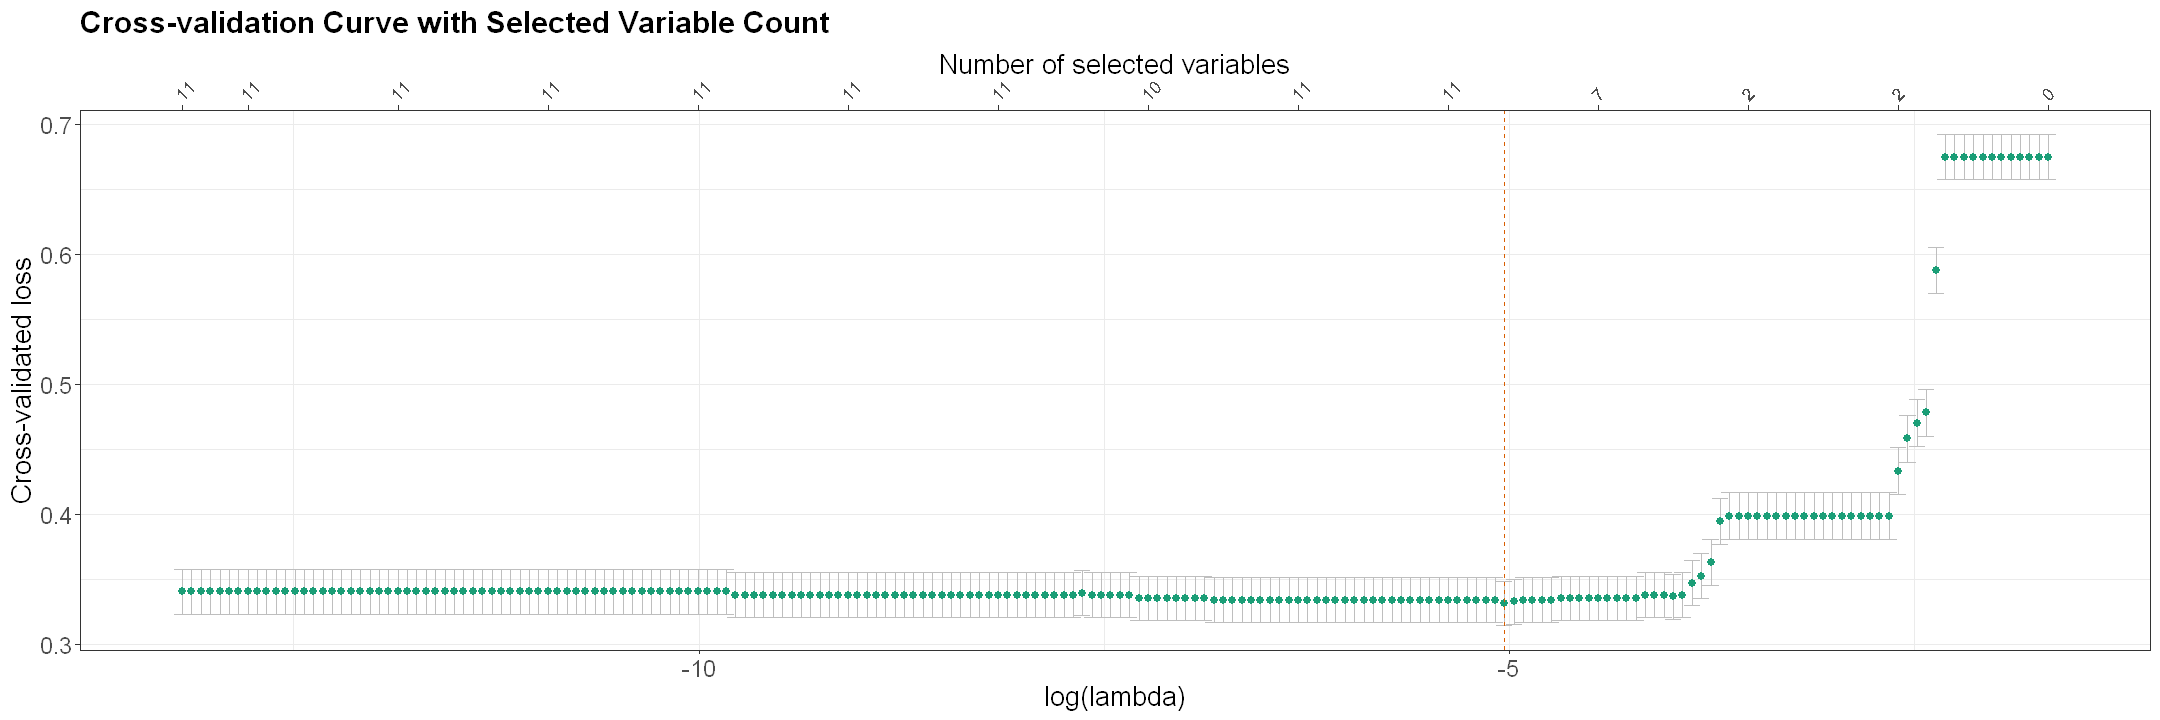

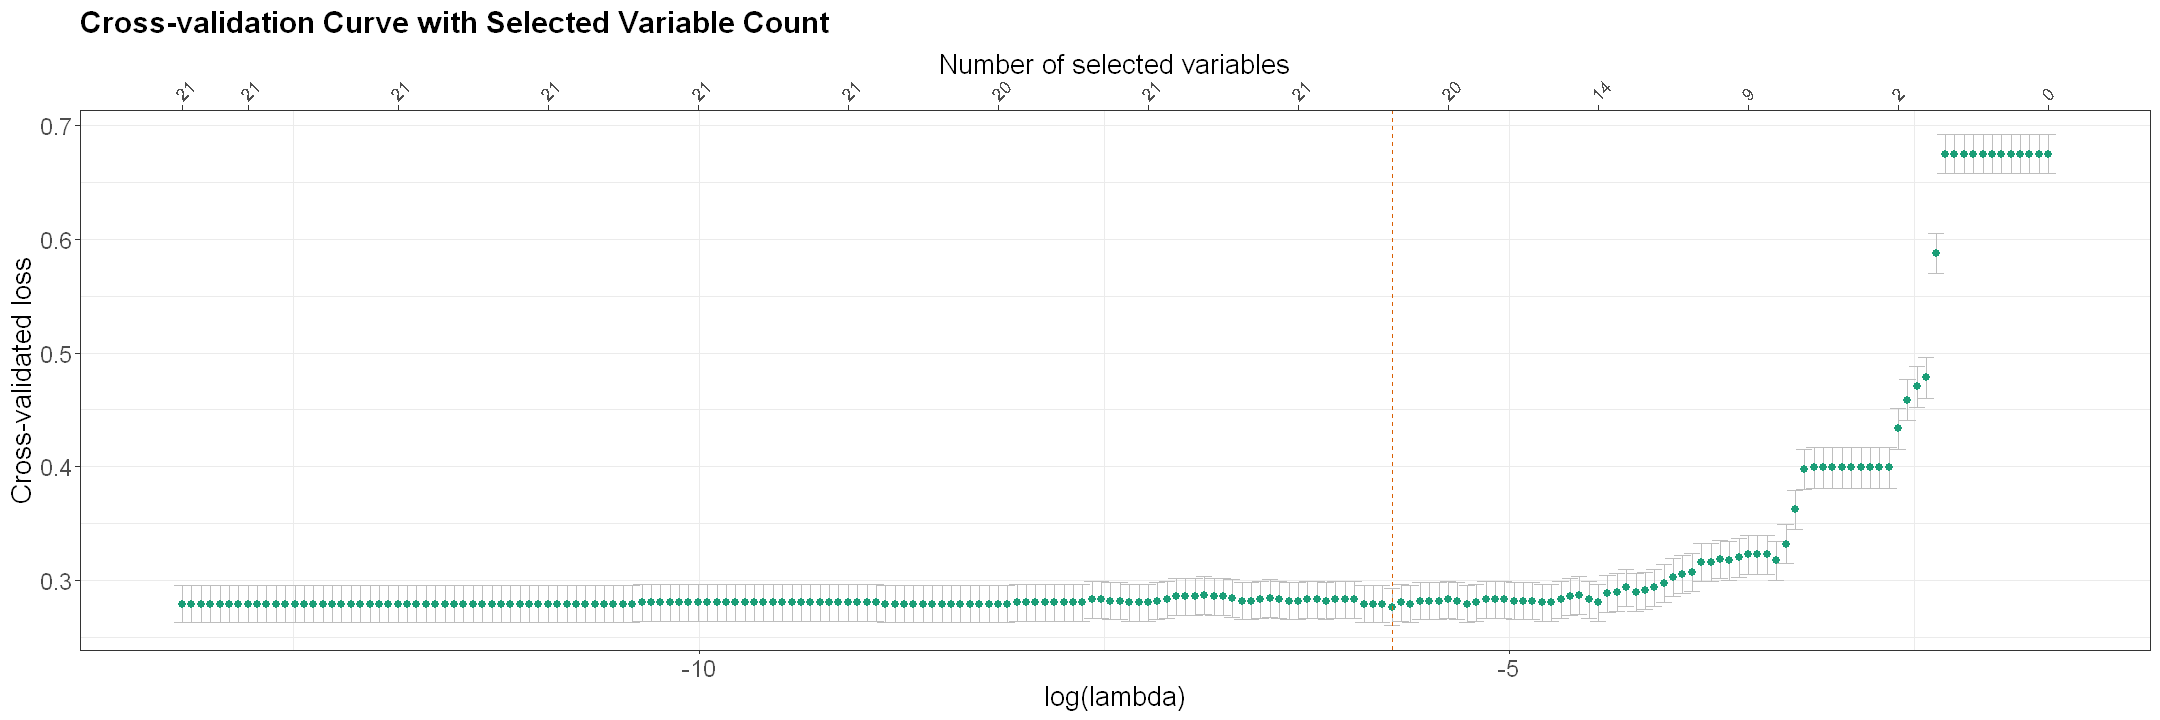

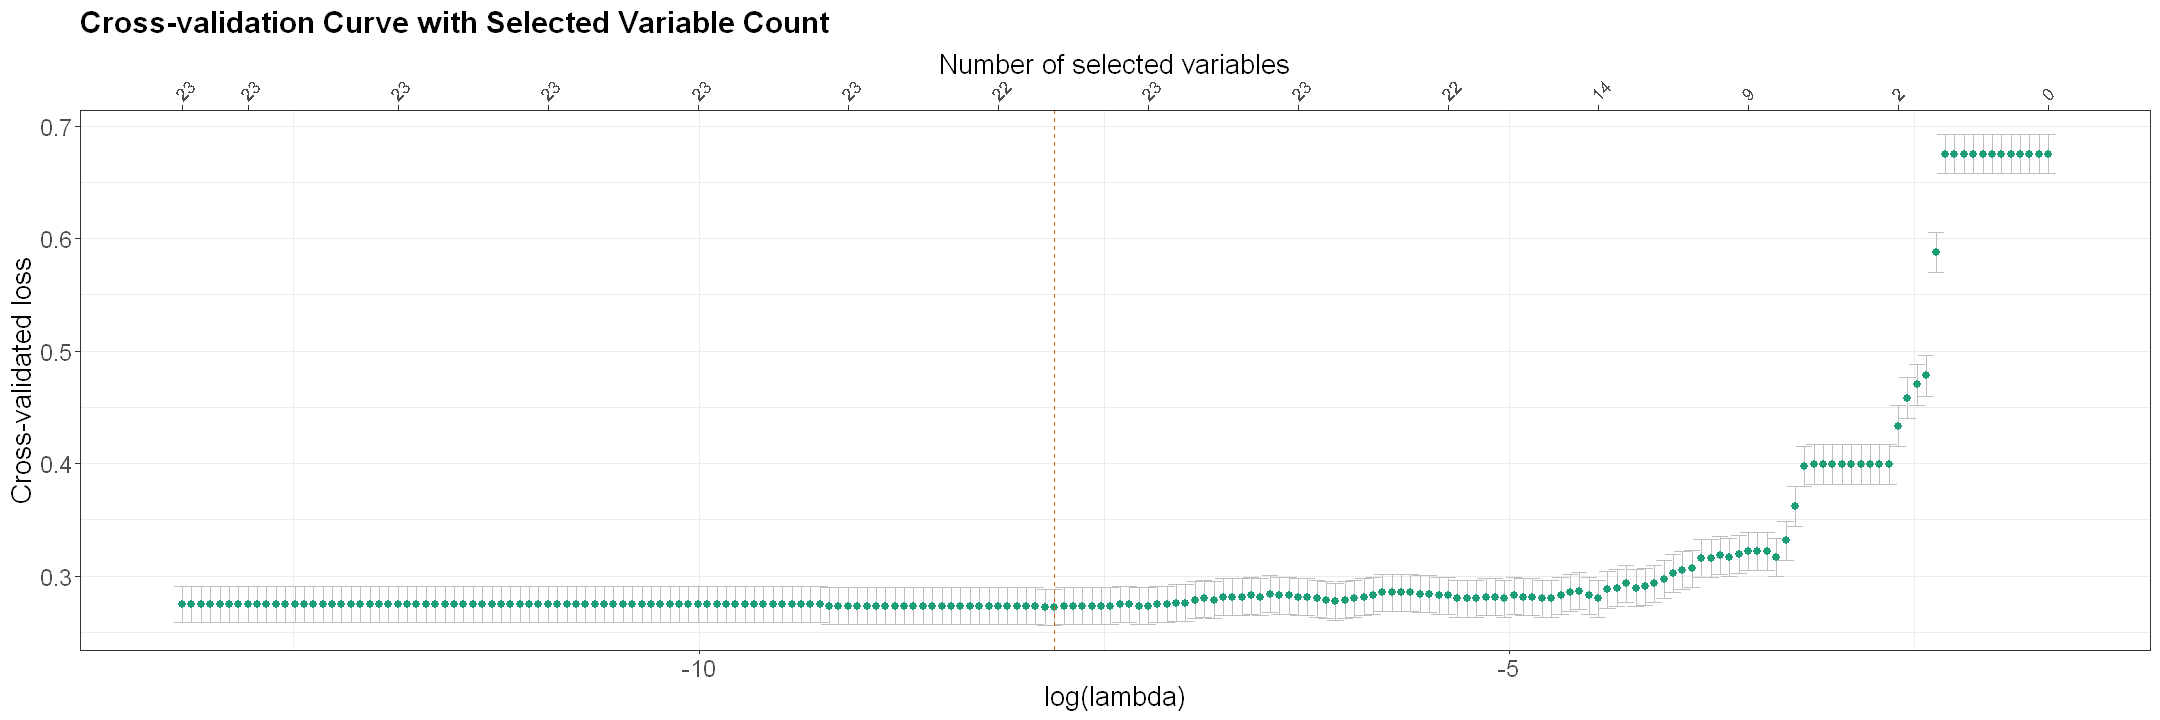

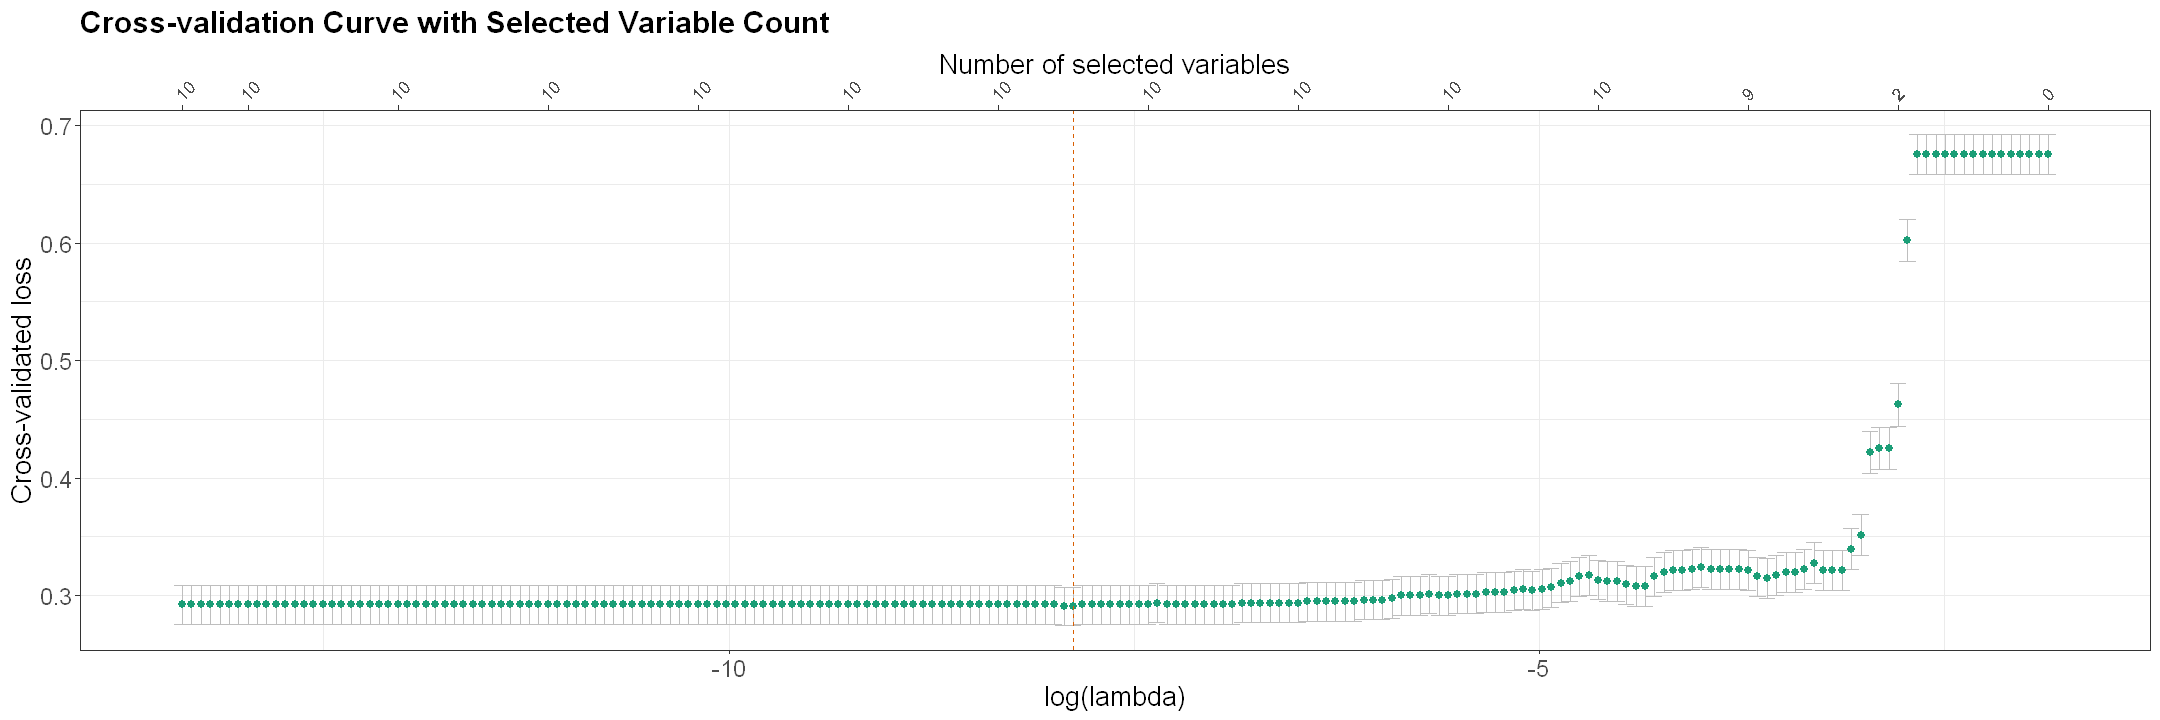

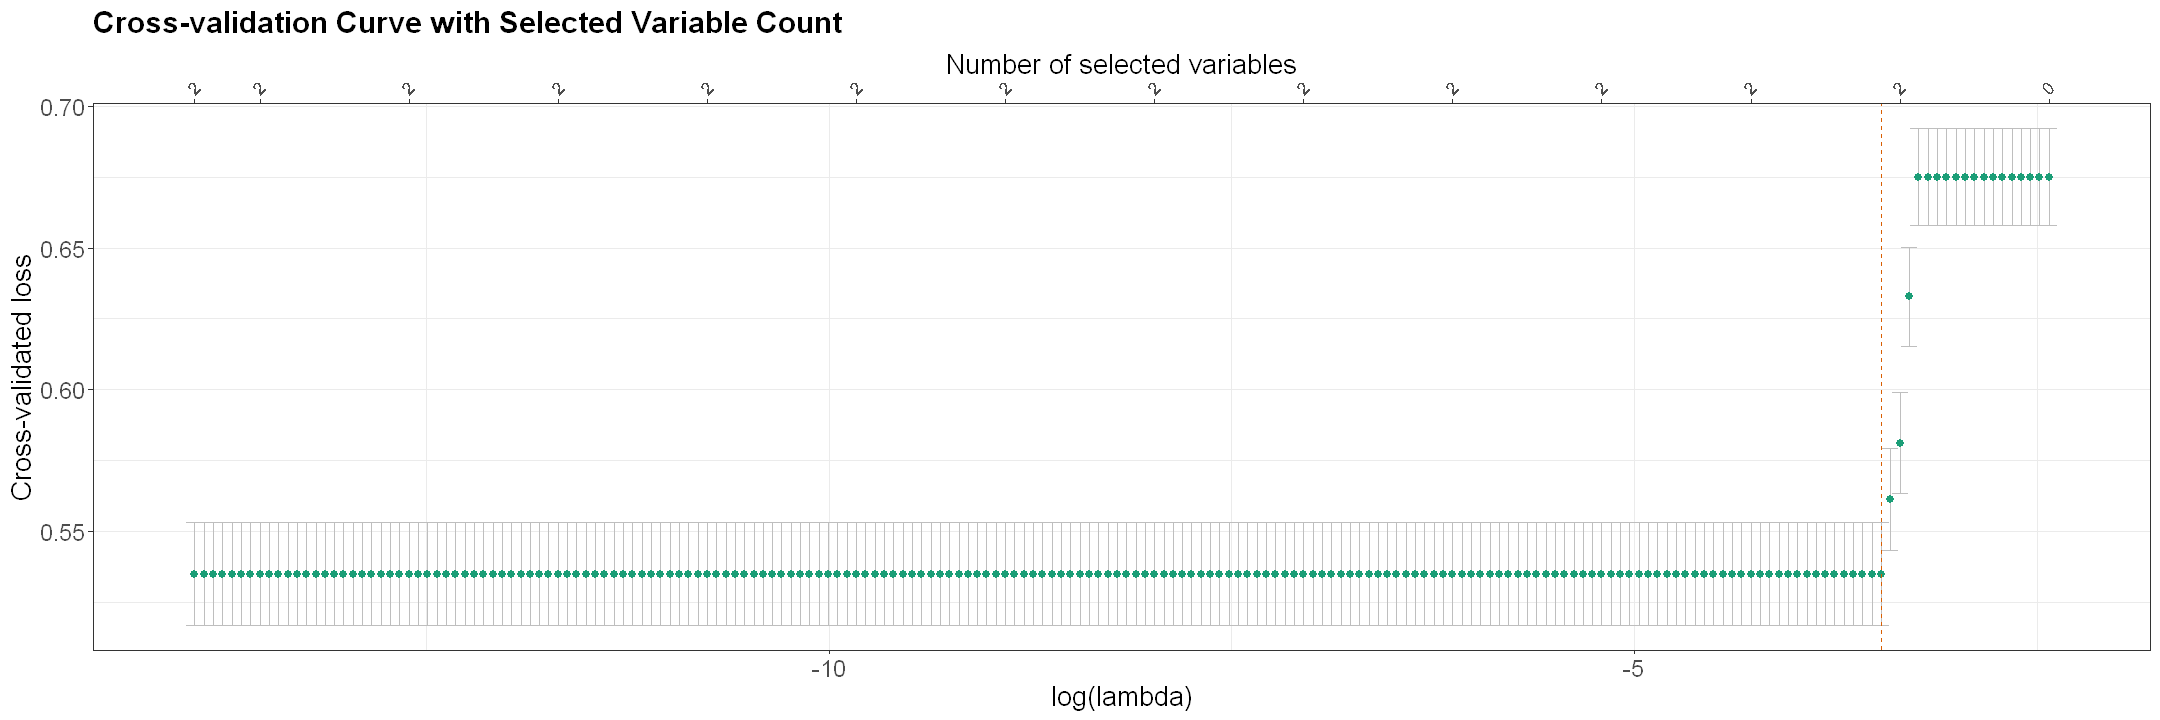

In [126]:
options(repr.plot.width=18, repr.plot.height=6)
set.seed(123)
cv1_results1 <- cv_gglasso_collect_auc(x1_train, y1_train, group_indices1)

set.seed(123)
cv1_results2 <- cv_gglasso_collect_auc(x2_train, y1_train, group_indices2)

set.seed(123)
cv1_results3 <- cv_gglasso_collect_auc(x3_train, y1_train, group_indices3)

set.seed(123)
cv1_results4 <- cv_gglasso_collect_auc(x4_train, y1_train, group_indices4)

set.seed(123)
cv1_results5 <- cv_gglasso_collect_auc(x5_train, y1_train, group_indices5)


### Model Evaluation

#### Training Performance

* 10-fold CV AUC with 95% CI
* Number of selected variables
* Coefficient values for selected variables

In [127]:
# 10-fold cross-validation results with confidence intervals
cat("\n--- Cross-Validation Results for y1 (on Training Set) ---\n")
cat("Model 1: Baseline characteristics only - AUC:", round(cv1_results1$mean_auc, 3), 
    "95% CI: [", round(cv1_results1$ci_lower, 3), "-", round(cv1_results1$ci_upper, 3), "]\n")

cat("Model 2: BaseLine + Psychosocial - AUC:", round(cv1_results2$mean_auc, 3), 
    "95% CI: [", round(cv1_results2$ci_lower, 3), "-", round(cv1_results2$ci_upper, 3), "]\n")

cat("Model 3: BaseLine + Psychosocial + Lifestyle - AUC:", round(cv1_results3$mean_auc, 3), 
    "95% CI: [", round(cv1_results3$ci_lower, 3), "-", round(cv1_results3$ci_upper, 3), "]\n")

cat("Model 4: Psychosocial only - AUC:", round(cv1_results4$mean_auc, 3), 
    "95% CI: [", round(cv1_results4$ci_lower, 3), "-", round(cv1_results4$ci_upper, 3), "]\n")

cat("Model 5: Lifestyle only - AUC:", round(cv1_results5$mean_auc, 3), 
    "95% CI: [", round(cv1_results5$ci_lower, 3), "-", round(cv1_results5$ci_upper, 3), "]\n")


--- Cross-Validation Results for y1 (on Training Set) ---
Model 1: Baseline characteristics only - AUC: 0.594 95% CI: [ 0.561 - 0.627 ]
Model 2: BaseLine + Psychosocial - AUC: 0.706 95% CI: [ 0.654 - 0.757 ]
Model 3: BaseLine + Psychosocial + Lifestyle - AUC: 0.715 95% CI: [ 0.665 - 0.766 ]
Model 4: Psychosocial only - AUC: 0.658 95% CI: [ 0.58 - 0.736 ]
Model 5: Lifestyle only - AUC: 0.521 95% CI: [ 0.473 - 0.57 ]


In [128]:
# Extract coefficients for each model
len_model1_y1 <- cv1_results1$selected_variable_count
len_model2_y1 <- cv1_results2$selected_variable_count
len_model3_y1 <- cv1_results3$selected_variable_count
len_model4_y1 <- cv1_results4$selected_variable_count
len_model5_y1 <- cv1_results5$selected_variable_count


cv_models <- list(
  `Model 1: BaseLine` = cv1_results1,
  `Model 2: BaseLine +Psychosocial` = cv1_results2,
  `Model 3: BaseLine+Psy+Lifestyle` = cv1_results3,
  `Model 4: Psychosocial` = cv1_results4,
  `Model 5: Lifestyle` = cv1_results5
)

coef_table <- combine_gglasso_coefficients(cv_models)
(coef_table)


Variable,Model 1: BaseLine,Model 2: BaseLine +Psychosocial,Model 3: BaseLine+Psy+Lifestyle,Model 4: Psychosocial,Model 5: Lifestyle
<chr>,"<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>"
(Intercept),,,,,
genderFemale,0.1311,0.0791,0.1101,,
age_at_inclusionQ2,0.356,0.2643,0.4485,,
age_at_inclusionQ3,0.266,0.138,0.2802,,
age_at_inclusionQ4,0.2879,0.058,0.1921,,
DiseaseEntity_x_extent_uc1,0.0309,0.2447,1.5243,,
DiseaseEntity_x_extent_uc2,0.0431,0.1775,0.9441,,
DiseaseEntity_x_extent_uc3,0.1403,0.4426,1.334,,
DiseaseEntity_x_severity_uc1,1.0317,0.841,,,


#### Test Set Performance

Independent test set (30% of data) evaluates:

- AUC with confidence intervals
- Accuracy
- Sensitivity (true positive rate)
- Specificity (true negative rate)
- PPV (positive predictive value)
- NPV (negative predictive value)

In [129]:

# ===== ANALYSIS FOR Y1 =====
cat("\n--- Cross-Validation Results for Y1 (on Testing Set) ---\n")

# Compute metrics for all models with y1
metrics_model1_y1 <- compute_metrics(model = cv1_results1$model, x = x1_test, y1_test)
metrics_model2_y1 <- compute_metrics(model = cv1_results2$model, x = x2_test, y1_test)
metrics_model3_y1 <- compute_metrics(model = cv1_results3$model, x = x3_test, y1_test)
metrics_model4_y1 <- compute_metrics(model = cv1_results4$model, x = x4_test, y1_test)
metrics_model5_y1 <- compute_metrics(model = cv1_results5$model, x = x5_test, y1_test)

# Print performance metrics for Y1
cat("Model 1: Baseline characteristics only - Accuracy:", metrics_model1_y1$accuracy, "AUC:", metrics_model1_y1$auc, "  (95% CI: [", round(metrics_model1_y1$auc-cv1_results1$margin, 3), "-", round(metrics_model1_y1$auc+cv1_results1$margin, 3), "])\n")
cat("Model 2: BaseLine + Psychosocial - Accuracy:", metrics_model2_y1$accuracy, "AUC:", metrics_model2_y1$auc, " (95% CI: [", round(metrics_model2_y1$auc-cv1_results2$margin, 3), "-", round(metrics_model2_y1$auc+cv1_results2$margin, 3), "])\n")
cat("Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy:", metrics_model3_y1$accuracy, "AUC:", metrics_model3_y1$auc,  " (95% CI: [", round(metrics_model3_y1$auc-cv1_results3$margin, 3), "-", round(metrics_model3_y1$auc+cv1_results3$margin, 3), "])\n")

cat("Model 4: Psychosocial only - Accuracy:", metrics_model4_y1$accuracy, "AUC:", metrics_model4_y1$auc,  " (95% CI: [", round(metrics_model4_y1$auc-cv1_results4$margin, 3), "-", round(metrics_model4_y1$auc+cv1_results4$margin, 3), "])\n")


cat("Model 5: Lifestyle only - Accuracy:", metrics_model5_y1$accuracy, "AUC:", metrics_model5_y1$auc,  " (95% CI: [", round(metrics_model5_y1$auc-cv1_results5$margin, 3), "-", round(metrics_model5_y1$auc+cv1_results5$margin, 3), "])\n")


--- Cross-Validation Results for Y1 (on Testing Set) ---
Model 1: Baseline characteristics only - Accuracy: 0.5277778 AUC: 0.6270257   (95% CI: [ 0.594 - 0.66 ])
Model 2: BaseLine + Psychosocial - Accuracy: 0.7037037 AUC: 0.7752076  (95% CI: [ 0.724 - 0.827 ])
Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy: 0.7160494 AUC: 0.7718332  (95% CI: [ 0.721 - 0.823 ])
Model 4: Psychosocial only - Accuracy: 0.691358 AUC: 0.7309639  (95% CI: [ 0.653 - 0.809 ])
Model 5: Lifestyle only - Accuracy: 0.4722222 AUC: 0.4965369  (95% CI: [ 0.448 - 0.545 ])


ROC curves for all models on each outcome

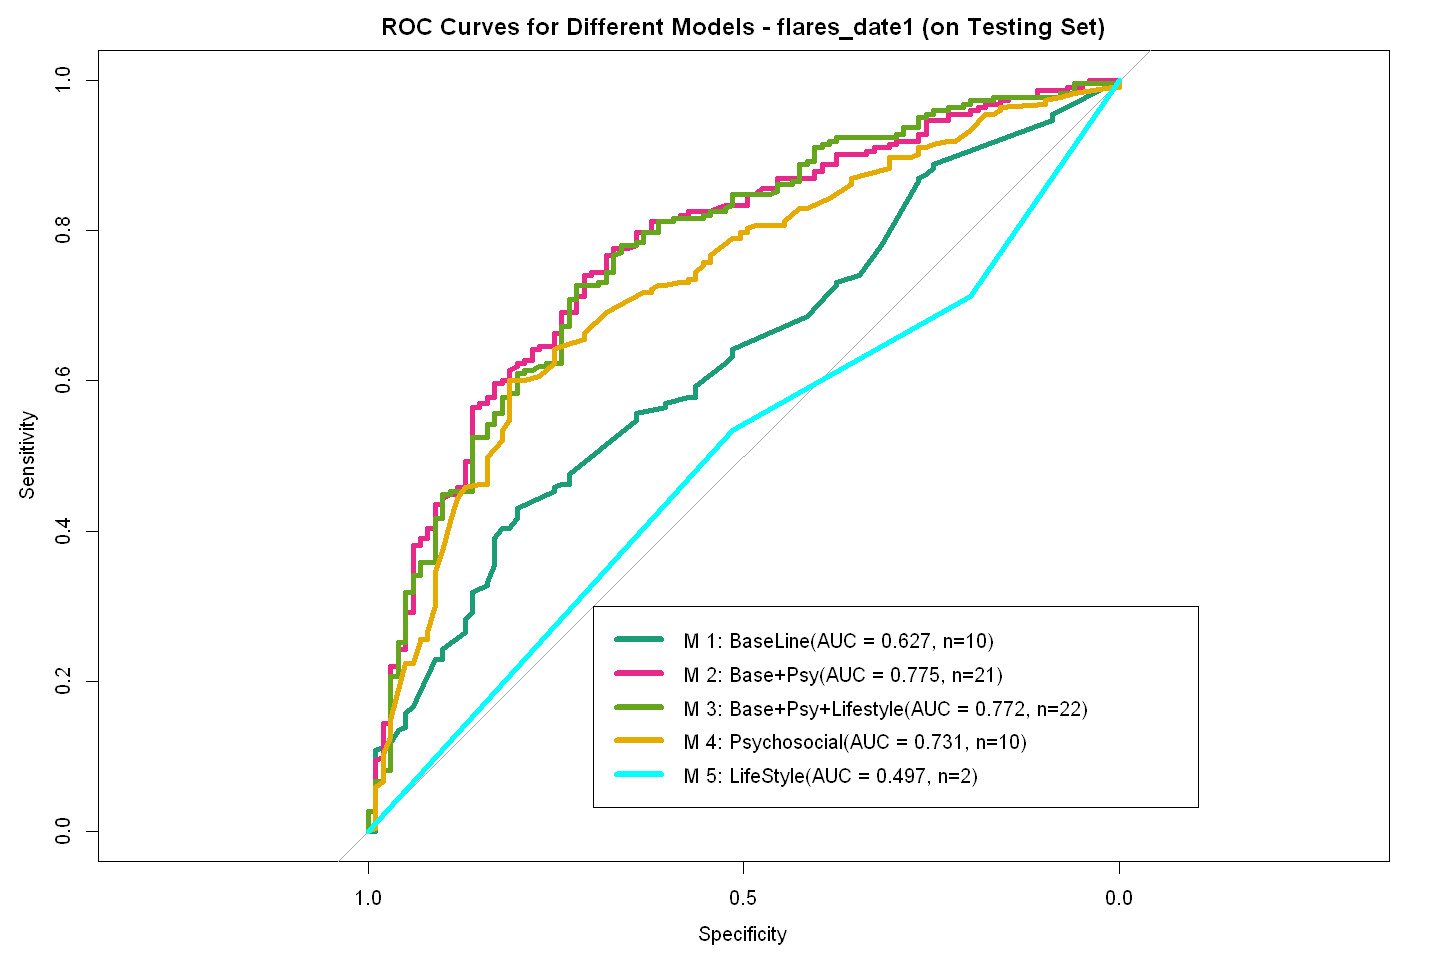

In [130]:
# Plot ROC Curves for All Models - Y1
roc_model1_y1 <- metrics_model1_y1$roc_curve
roc_model2_y1 <- metrics_model2_y1$roc_curve
roc_model3_y1 <- metrics_model3_y1$roc_curve
roc_model4_y1 <- metrics_model4_y1$roc_curve
roc_model5_y1 <- metrics_model5_y1$roc_curve

# ROC plot for Y1
options(repr.plot.width=12, repr.plot.height=8)
legend_labels_y1 <- c(
    paste0("M 1: BaseLine(AUC = ", sprintf("%.3f", auc(roc_model1_y1)),  ", n=",len_model1_y1,")"),
    paste0("M 2: Base+Psy(AUC = ", sprintf("%.3f", auc(roc_model2_y1)),  ", n=",len_model2_y1,")"),
    paste0("M 3: Base+Psy+Lifestyle(AUC = ", sprintf("%.3f", auc(roc_model3_y1)), ", n=",len_model3_y1, ")"),
    paste0("M 4: Psychosocial(AUC = ", sprintf("%.3f", auc(roc_model4_y1)), ", n=",len_model4_y1, ")"),
    paste0("M 5: LifeStyle(AUC = ", sprintf("%.3f", auc(roc_model5_y1)), ", n=",len_model5_y1,")")
    
)

# Create ROC plot for Y1
plot(roc_model1_y1, col = "#1B9E77", main = "ROC Curves for Different Models - flares_date1 (on Testing Set)", lwd=4)
plot(roc_model2_y1, col = "#E7298A", add = TRUE, lwd=4)
plot(roc_model3_y1, col =  "#66A61E", add = TRUE, lwd=4)
plot(roc_model4_y1, col = "#E6AB02", add = TRUE, lwd=4)
plot(roc_model5_y1, col = "cyan", add = TRUE, lwd=4)
    
# Add legend
legend(x = 0.7, y = 0.3, 
        legend = legend_labels_y1,
        col = c("#1B9E77","#E7298A",  "#66A61E", "#E6AB02", "cyan"),
        lwd = 5)

In [131]:
# Create a results table for Y1
results_table_y1 <- data.frame(
    Model = c("Model 1: BaseLine", 
              "Model 2: BaseLine +Psychosocial", 
              "Model 3: BaseLine+P+Lifestyle", 
              "Model 4: BaseLine+P+Lifestyle+Med", 
              "Model 5: Psychosocial"
              ),
    Sensitivity = c(metrics_model1_y1$metrics[1],
                    metrics_model2_y1$metrics[1],
                    metrics_model3_y1$metrics[1],
                    metrics_model4_y1$metrics[1],
                    metrics_model5_y1$metrics[1]
                    ),
    Specificity = c(metrics_model1_y1$metrics[2],
                    metrics_model2_y1$metrics[2],
                    metrics_model3_y1$metrics[2], 
                    metrics_model4_y1$metrics[2],
                    metrics_model5_y1$metrics[2]
                    ),
    PPV = c(metrics_model1_y1$metrics[3],
            metrics_model2_y1$metrics[3],
            metrics_model3_y1$metrics[3], 
            metrics_model4_y1$metrics[3],
            metrics_model5_y1$metrics[3]
            ),
    NPV = c(metrics_model1_y1$metrics[4],
            metrics_model2_y1$metrics[4],
            metrics_model3_y1$metrics[4],
            metrics_model4_y1$metrics[4],
            metrics_model5_y1$metrics[4]
            )
)

# Print the results table for Y1
cat("Results Table for Y1:\n")
print(kable(results_table_y1, format = "simple"))

Results Table for Y1:


Model                                Sensitivity   Specificity         PPV         NPV
----------------------------------  ------------  ------------  ----------  ----------
Model 1: BaseLine                      0.3901345     0.8316832   0.8365385   0.3818182
Model 2: BaseLine +Psychosocial        0.6950673     0.7227723   0.8469945   0.5177305
Model 3: BaseLine+P+Lifestyle          0.7264574     0.6930693   0.8393782   0.5343511
Model 4: BaseLine+P+Lifestyle+Med      0.7174888     0.6336634   0.8121827   0.5039370
Model 5: Psychosocial                  0.4663677     0.4851485   0.6666667   0.2916667


Performance plots showing AUC vs. model complexity

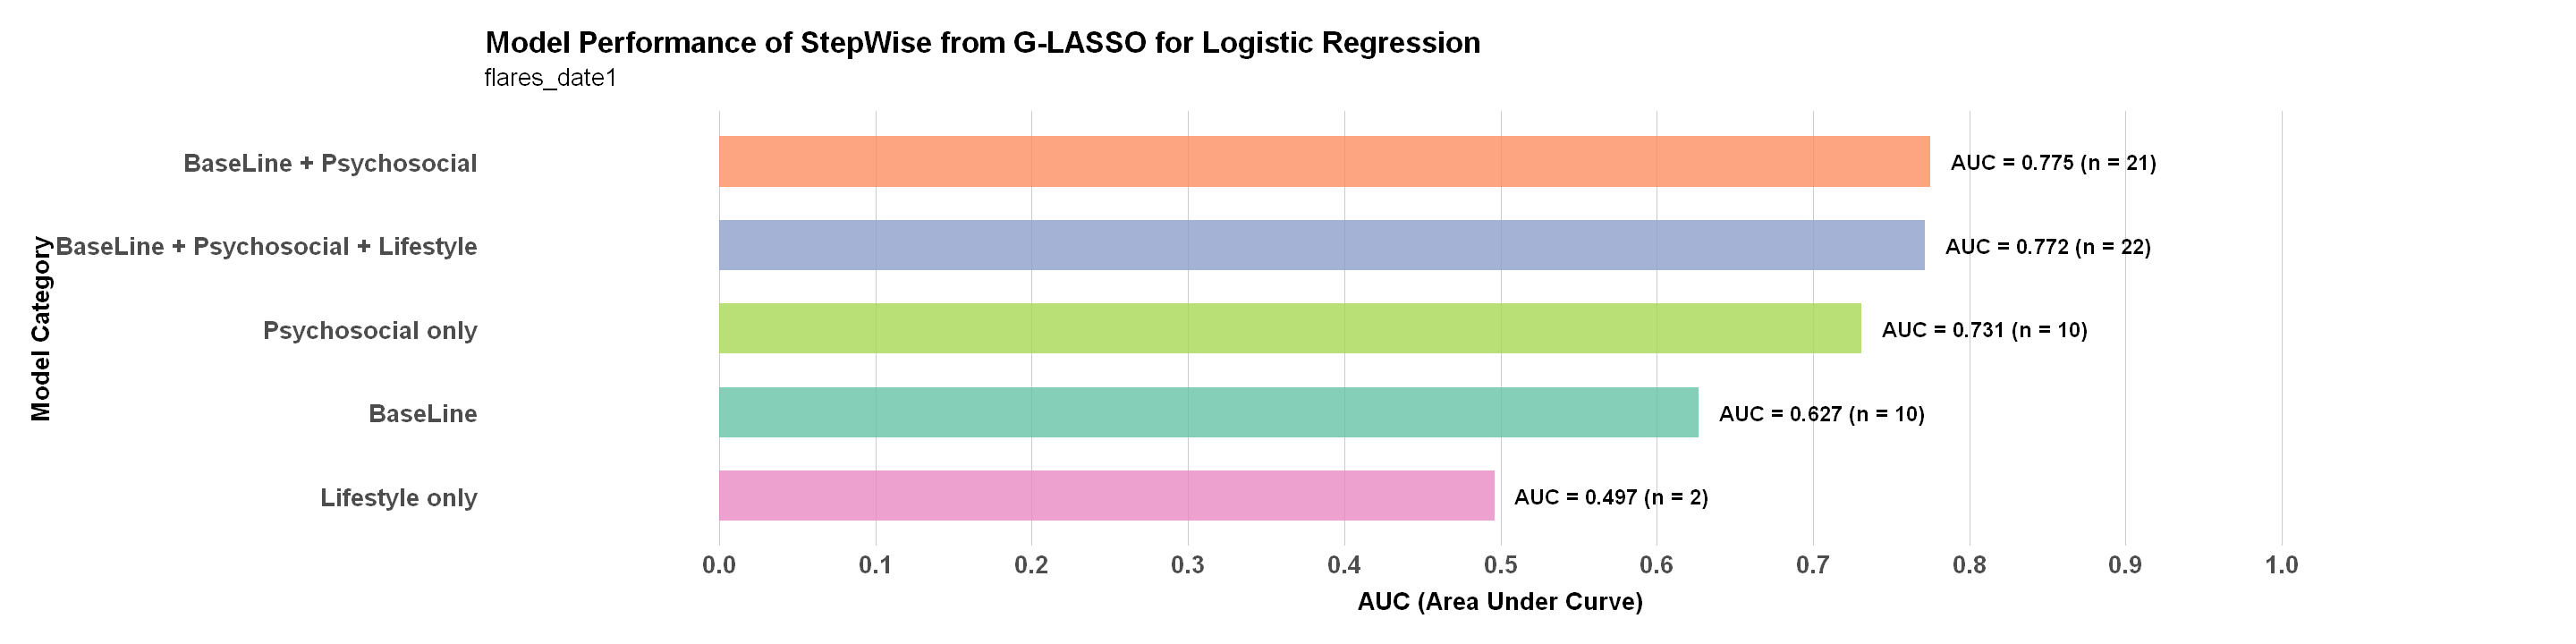

In [132]:
# Variable importance plot for Y1
variable_importance_y1 <- data.frame(
  Variable = c("BaseLine", 
               "BaseLine + Psychosocial", "BaseLine + Psychosocial + Lifestyle",
               "Psychosocial only", 
               "Lifestyle only"
               ),
  auc_values = c(metrics_model1_y1$auc,
                 metrics_model2_y1$auc, metrics_model3_y1$auc, metrics_model4_y1$auc
                 , metrics_model5_y1$auc
                 ),
  n_vars = c(len_model1_y1, 
             len_model2_y1, len_model3_y1, len_model4_y1, len_model5_y1
             )
)
options(repr.plot.width=24, repr.plot.height=6)
# Create Figure : Variable Importance Plot for Y1
ggplot(variable_importance_y1, aes(x = auc_values, y = reorder(Variable, auc_values))) +
  geom_col(aes(fill = Variable), width = 0.6, alpha = 0.8) +
  geom_text(aes(label = sprintf("AUC = %.3f (n = %d)", auc_values, n_vars)), 
            hjust = -0.1, size = 5, fontface = "bold") +
  scale_x_continuous(limits = c(0, 1), 
                     breaks = seq(0, 1, 0.1),
                     expand = c(0, 0.15)) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Model Performance of StepWise from G-LASSO for Logistic Regression",
       subtitle = "flares_date1",
       y = "Model Category",
       x = "AUC (Area Under Curve)") +
  theme_minimal() +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 20, face = "bold", hjust = 0),
    plot.subtitle = element_text(size = 16, hjust = 0, margin = margin(b = 15)),
    axis.title.x = element_text(size = 16, face = "bold", margin = margin(t = 10)),
    axis.title.y = element_text(size = 16, face = "bold", margin = margin(r = 10)),
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 16, face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.x = element_line(color = "gray80", linewidth = 0.5),
    plot.margin = margin(20, 40, 20, 20)
  )



## 5.2 MODELS FOR FLARE DATE 2 (Mid-term Flares)

### Model Performance Overview

**Model 1: Baseline Only (AUC = 0.588)**
- **Variables selected**: 4 variables (severe variable reduction!)
- **Test Performance**: Accuracy 58.3%, AUC 0.588
- **Key predictors**:
  - Female gender: -0.29 (protective)
  - Disease severity: 0.41
  - Medication usage (minimal)
- **Interpretation**: Baseline characteristics nearly fail for mid-term prediction. LASSO aggressively eliminated most baseline features.

**Model 2: Baseline + Psychosocial (AUC = 0.742)**
- **Variables selected**: 18 variables
- **Test Performance**: Accuracy 70.1%, AUC 0.742
- **Key predictors**:
  - Disease severity: 1.05 (very strong)
  - Surgery history: 0.58
  - Disease burden HIGH: -1.10 (strongly protective)
  - Fatigue high: -0.50, Pain: -0.41 (both protective)
  - Stress Q3: 0.35
- **Improvement**: +15.4% AUC over baseline
- **Interpretation**: The protective effect of high disease burden intensifies at mid-term

**Model 3: Baseline + Psychosocial + Lifestyle (AUC = 0.761) - BEST**
- **Variables selected**: 23 variables (maximum complexity)
- **Test Performance**: Accuracy 71.6%, AUC 0.761
- **Key predictors**:
  - Surgery history: 2.01 (massive predictor!)
  - Disease severity: 1.61
  - Disease burden HIGH: -2.51 (extremely protective)
  - Stress Q3: 0.80, Q4: 0.72
  - Current smoking: -0.48 (protective)
  - Age Q3: 0.43
- **Improvement**: +17.3% AUC over baseline, +1.9% over Model 2
- **Interpretation**: Surgery history becomes dominant predictor. Smoking paradox persists and strengthens.

**Model 4: Psychosocial Only (AUC = 0.677)**
- **Variables selected**: 5 variables (minimal selection)
- **Test Performance**: Accuracy 64.5%, AUC 0.677
- **Key predictors**: Anxiety, Fatigue, Pain (all small coefficients)
- **Interpretation**: Much weaker than Date 1, suggesting psychosocial factors need clinical context at mid-term

**Model 5: Lifestyle Only (AUC = 0.500)**
- Complete prediction failure (0 variables selected)
- **Interpretation**: No discrimination capability

### Clinical Performance - Date 2

| Model | Sensitivity | Specificity | PPV | NPV |
|-------|------------|-------------|-----|-----|
| M1: Baseline | 54.3% | 61.8% | 55.4% | 60.8% |
| M2: Base+Psy | 75.5% | 65.3% | 65.5% | 75.3% |
| **M3: Base+Psy+Life** | **72.2%** | **71.1%** | **68.6%** | **74.5%** |
| M4: Psy only | 76.2% | 54.3% | 59.3% | 72.3% |

**Best Clinical Model**: Model 3 with best balance of sensitivity/specificity

### Date 2 Rankings
1. **Model 3** (AUC 0.761) - Lifestyle adds meaningful value
2. Model 2 (AUC 0.742) - Excellent core
3. Model 4 (AUC 0.677) - Moderate standalone
4. Model 1 (AUC 0.588) - Baseline nearly fails
5. Model 5 (AUC 0.500) - Complete failure

**Pattern**: Baseline degradation accelerates; lifestyle contribution increases




=== MODELS FOR y2 ===


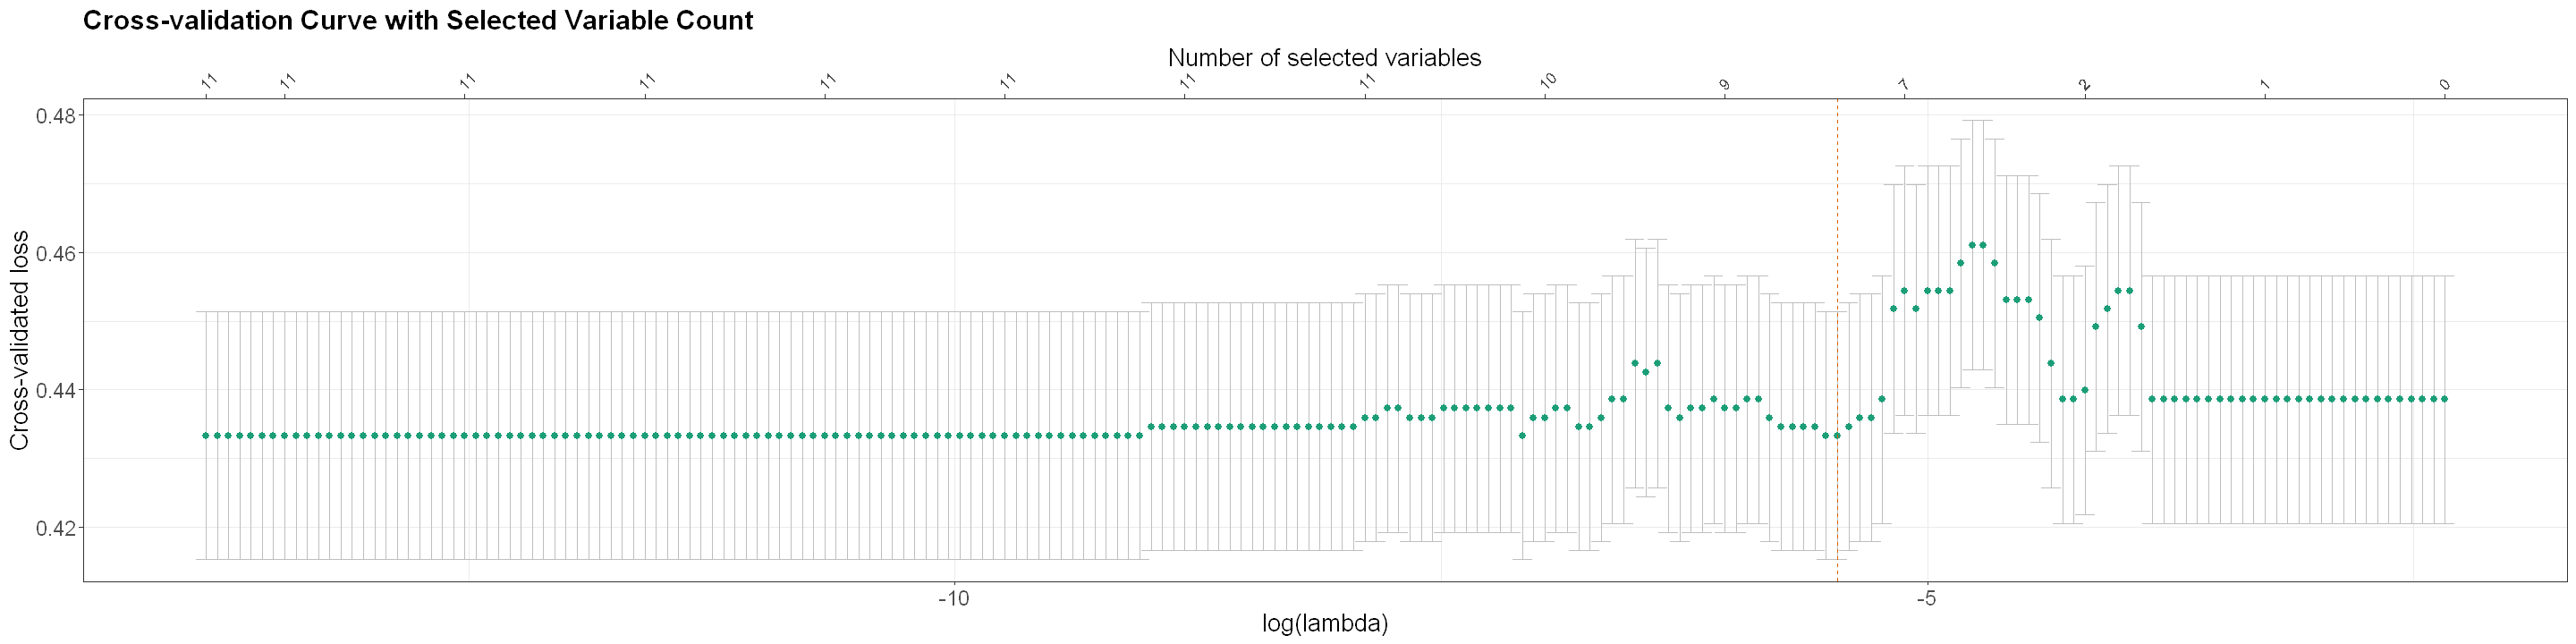

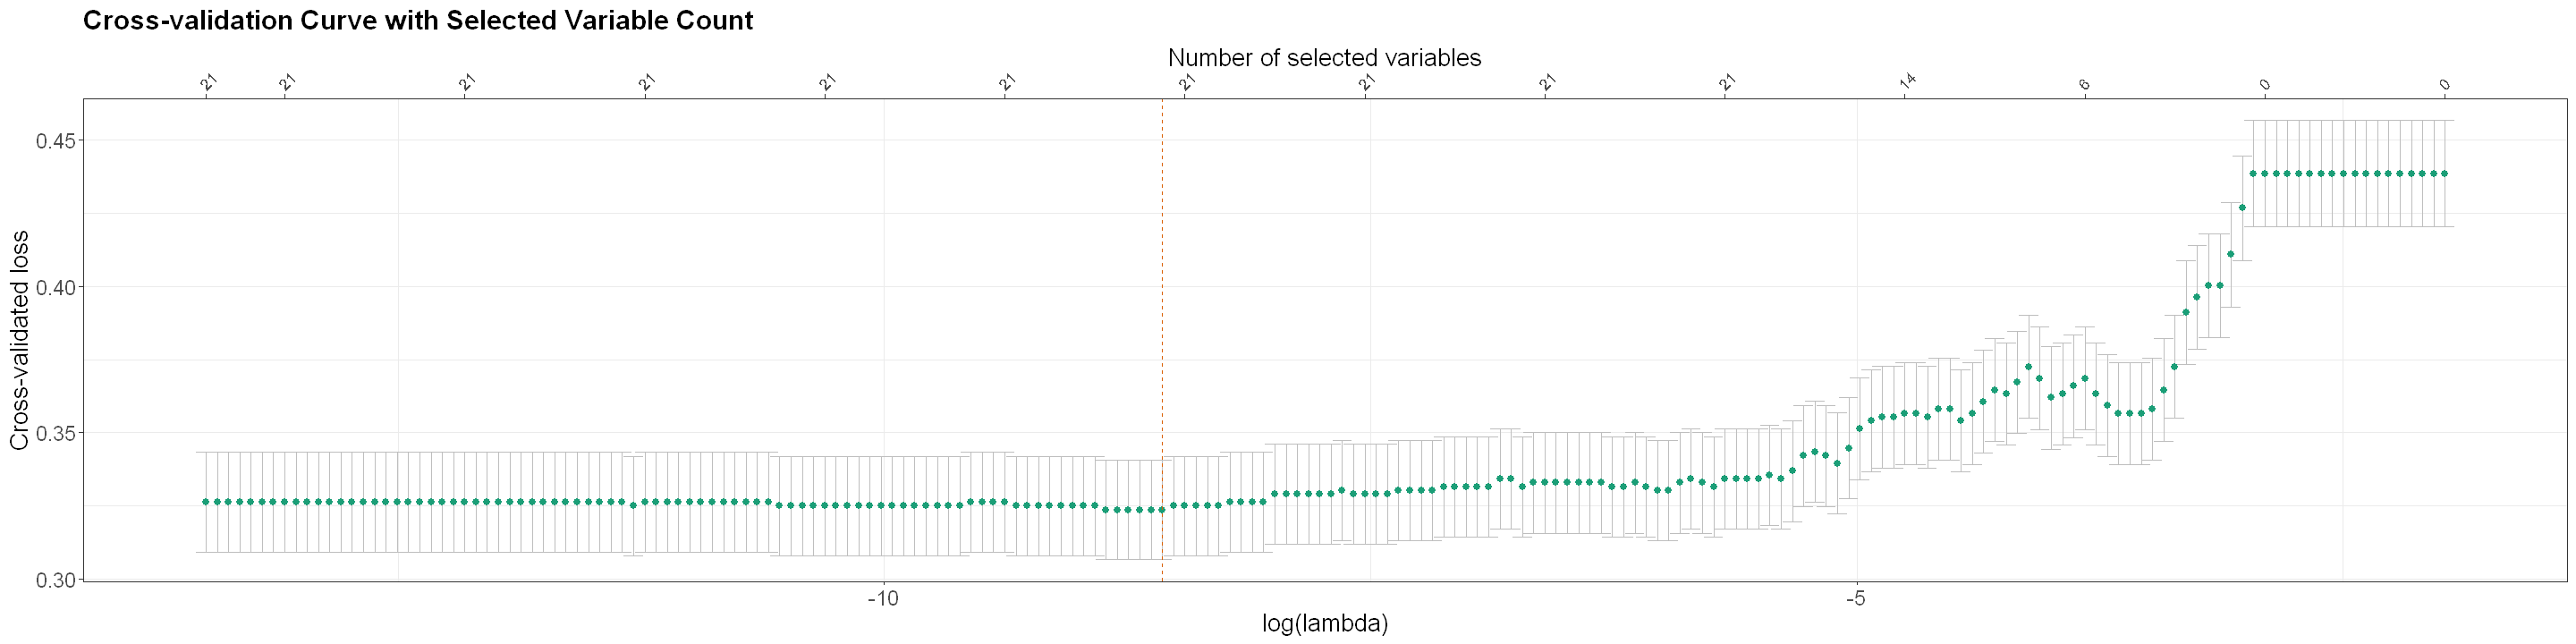

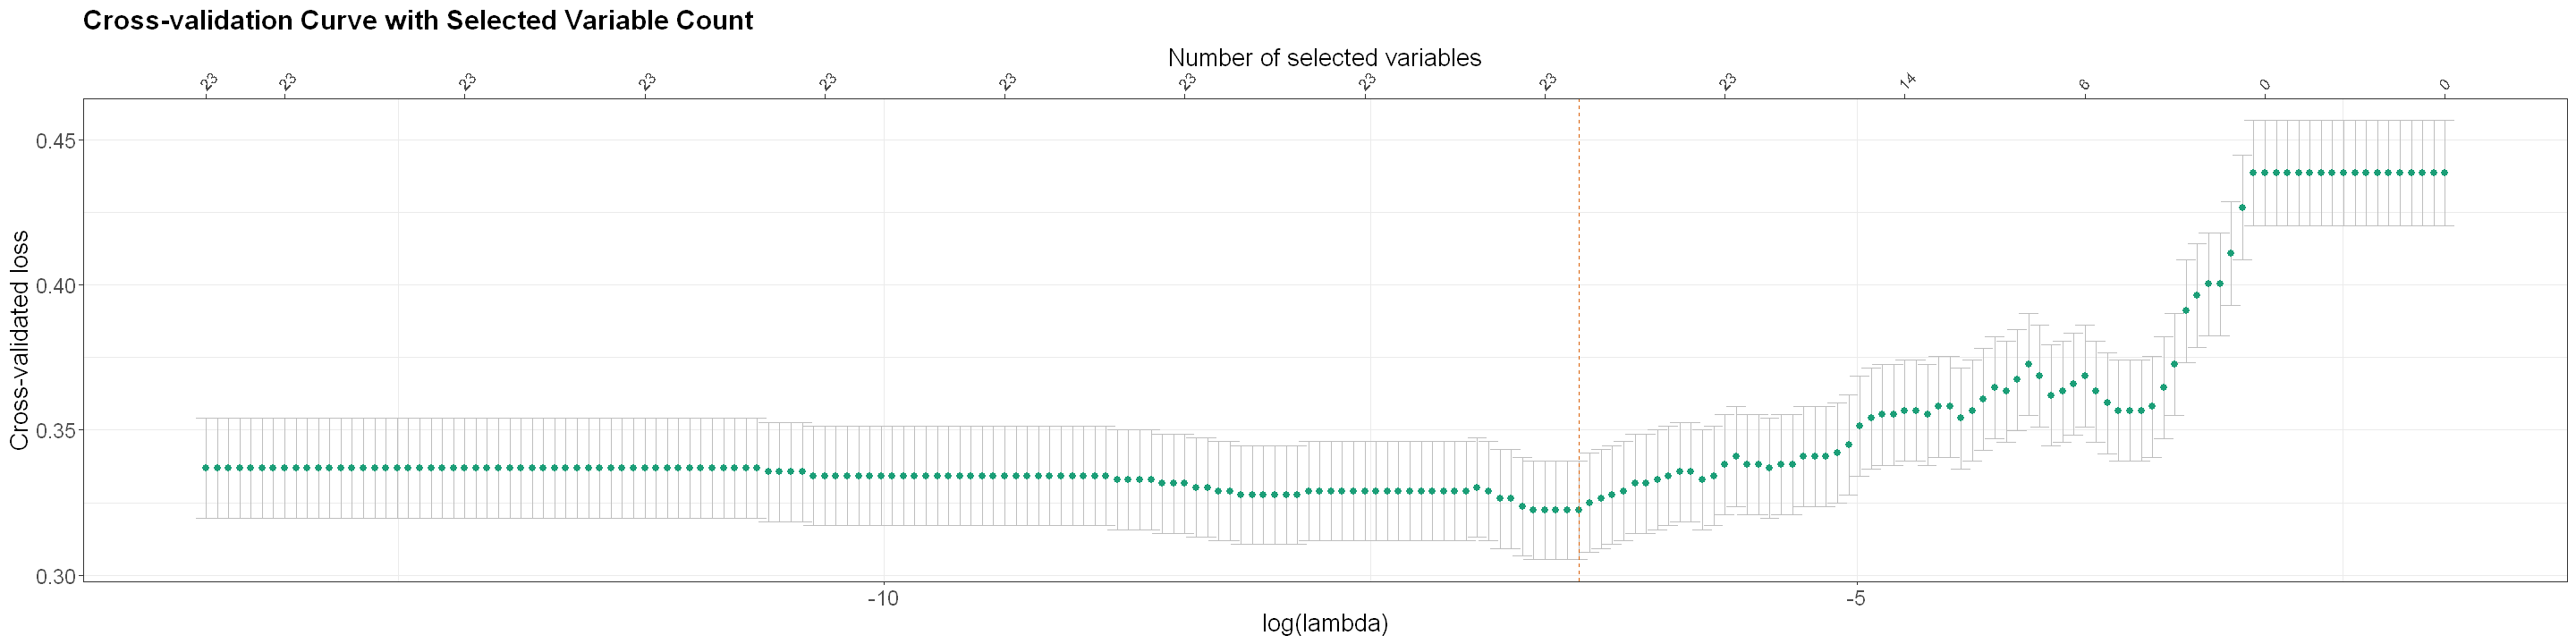

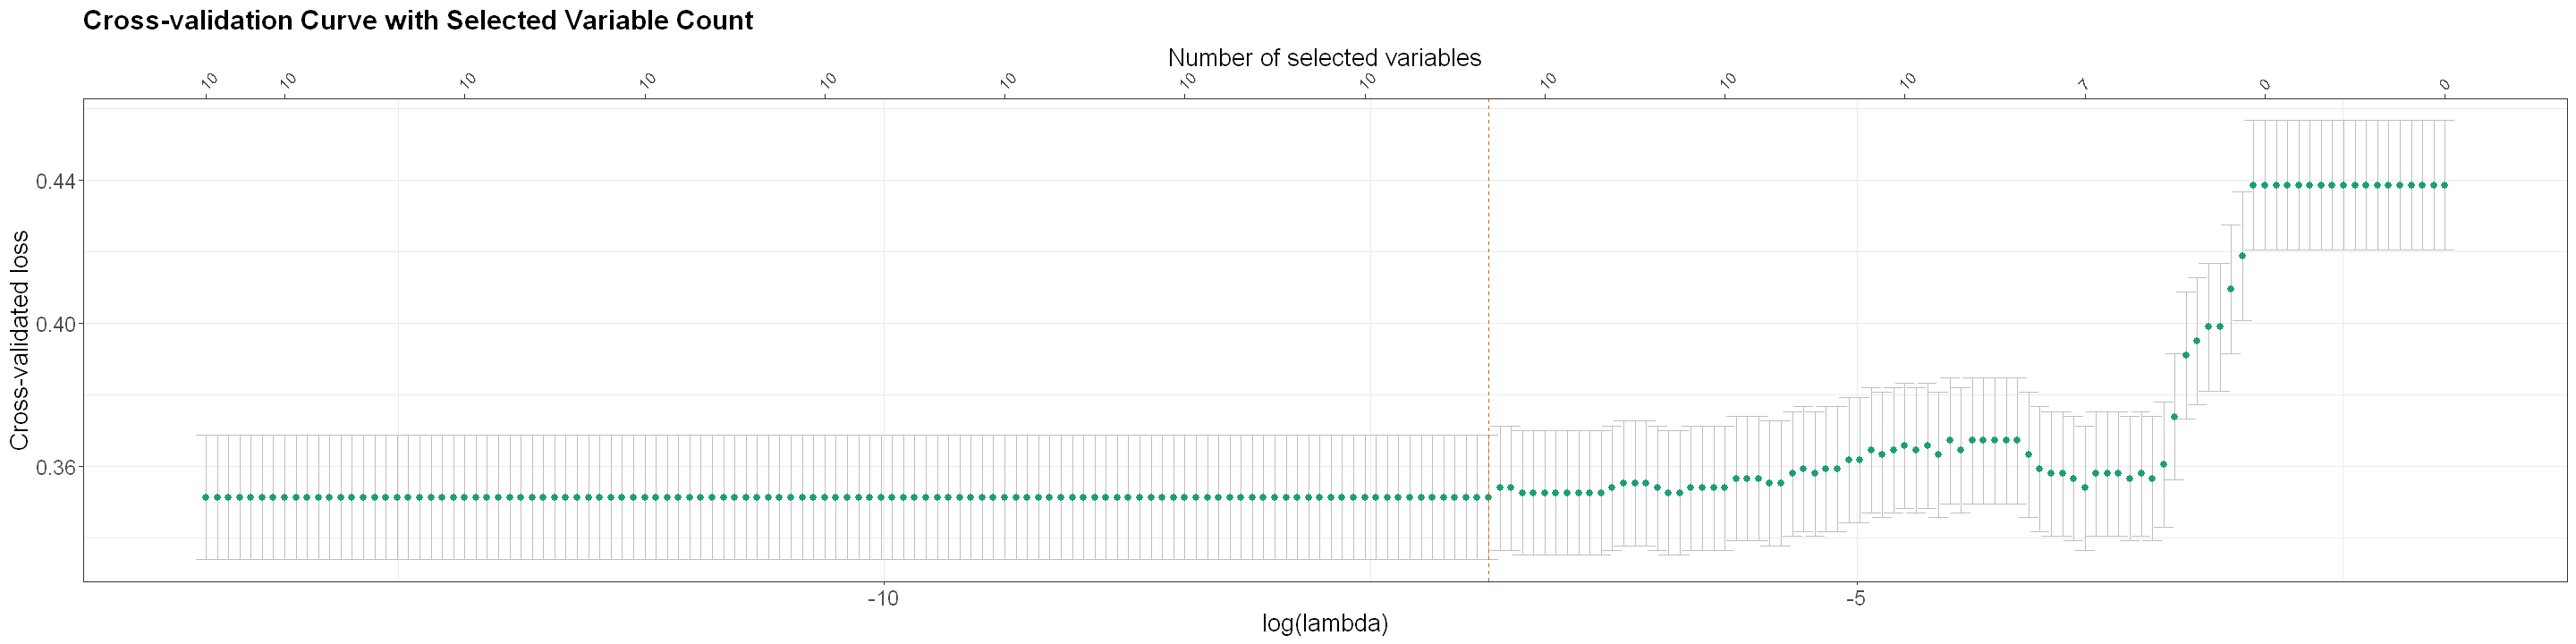

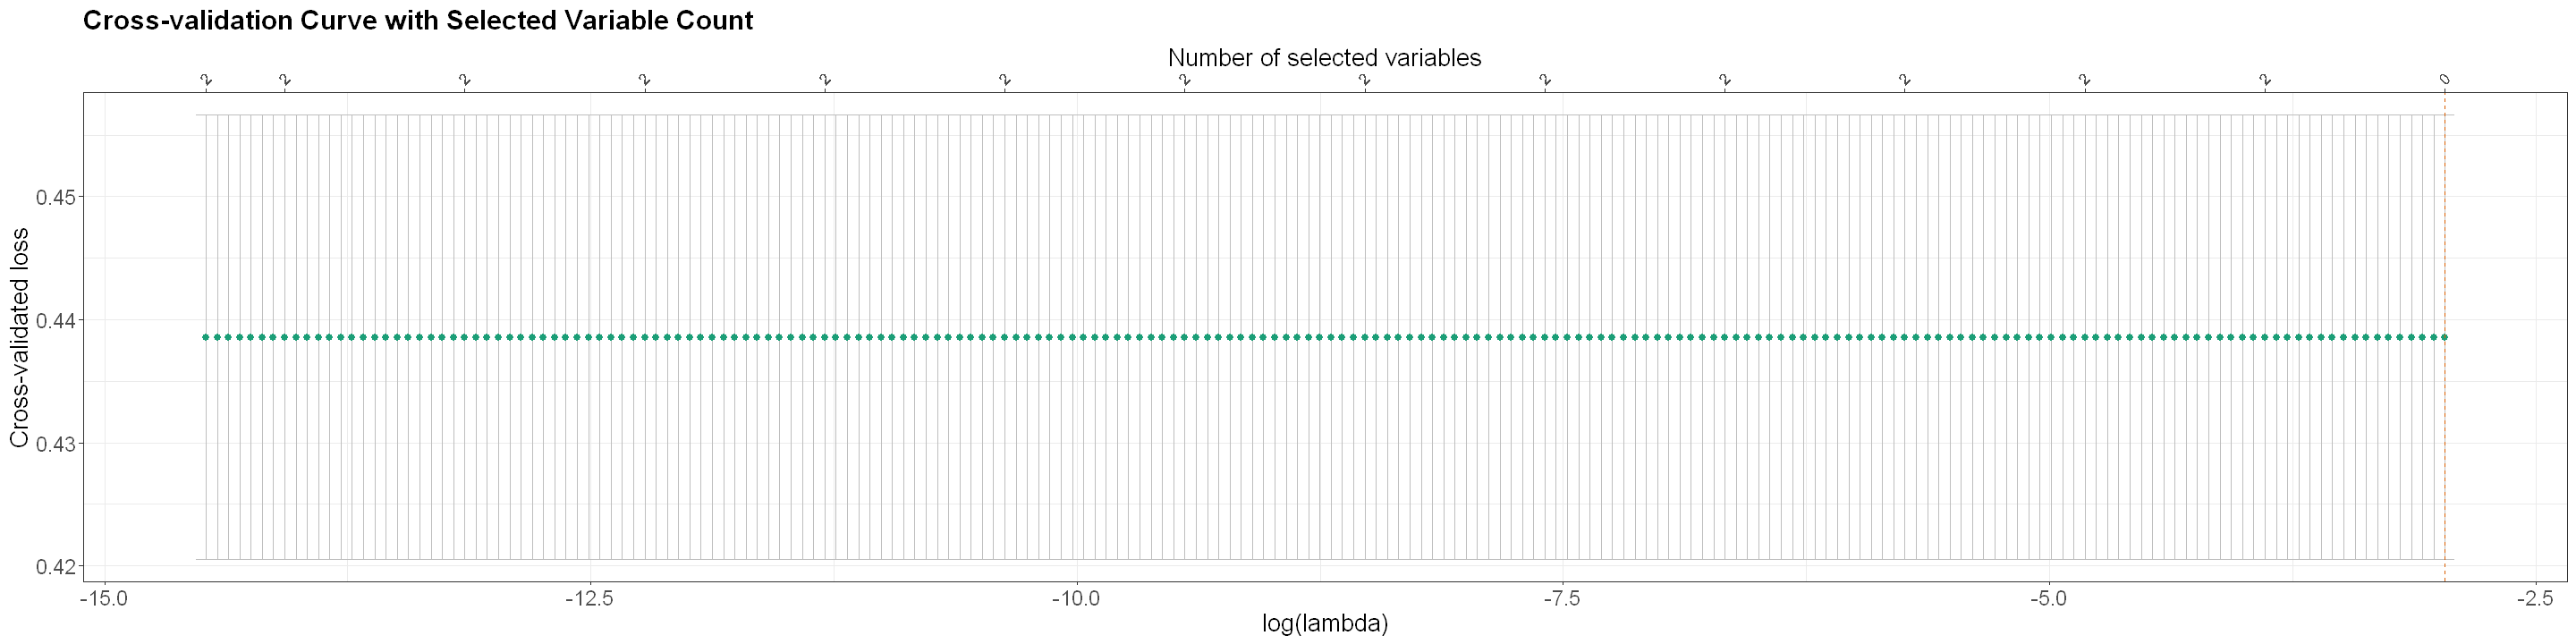

In [133]:
cat("\n=== MODELS FOR y2 ===\n")

# Run cross-validation for all 5 models with y2
set.seed(123)
cv2_results1 <- cv_gglasso_collect_auc(x1_train, y2_train, group_indices1)## Model 1: BaseLine model

set.seed(123)
cv2_results2 <- cv_gglasso_collect_auc(x2_train, y2_train, group_indices2)## Model 2: BaseLine + psychosocial model

set.seed(123)
cv2_results3 <- cv_gglasso_collect_auc(x3_train, y2_train, group_indices3)##  Model 3: BaseLine + psychosocial + lifestyle model

set.seed(123)
cv2_results4 <- cv_gglasso_collect_auc(x4_train, y2_train, group_indices4)##  Model 3: BaseLine + psychosocial + lifestyle + med model


set.seed(123)
cv2_results5 <- cv_gglasso_collect_auc(x5_train, y2_train, group_indices5)##  Model 4:  psychosocial  


### Model Evaluation
#### Training Performance

In [134]:
# Print cross-validation results with confidence intervals
cat("\n--- Cross-Validation Results for y2 (on Training Set) ---\n")
cat("Model 1: Baseline characteristics only - AUC:", round(cv2_results1$mean_auc, 3), 
    "95% CI: [", round(cv2_results1$ci_lower, 3), "-", round(cv2_results1$ci_upper, 3), "]\n")
cat("Model 2: BaseLine + Psychosocial - AUC:", round(cv2_results2$mean_auc, 3), 
    "95% CI: [", round(cv2_results2$ci_lower, 3), "-", round(cv2_results2$ci_upper, 3), "]\n")
cat("Model 3: BaseLine + Psychosocial + Lifestyle - AUC:", round(cv2_results3$mean_auc, 3), 
    "95% CI: [", round(cv2_results3$ci_lower, 3), "-", round(cv2_results3$ci_upper, 3), "]\n")

cat("Model 4: Psychosocial only - AUC:", round(cv2_results4$mean_auc, 3), 
    "95% CI: [", round(cv2_results4$ci_lower, 3), "-", round(cv2_results4$ci_upper, 3), "]\n")

cat("Model 5: Lifestyle only - AUC:", round(cv2_results5$mean_auc, 3), 
    "95% CI: [", round(cv2_results5$ci_lower, 3), "-", round(cv2_results5$ci_upper, 3), "]\n")



--- Cross-Validation Results for y2 (on Training Set) ---
Model 1: Baseline characteristics only - AUC: 0.593 95% CI: [ 0.564 - 0.622 ]
Model 2: BaseLine + Psychosocial - AUC: 0.728 95% CI: [ 0.703 - 0.754 ]
Model 3: BaseLine + Psychosocial + Lifestyle - AUC: 0.726 95% CI: [ 0.702 - 0.75 ]
Model 4: Psychosocial only - AUC: 0.694 95% CI: [ 0.661 - 0.727 ]
Model 5: Lifestyle only - AUC: 0.5 95% CI: [ 0.5 - 0.5 ]


In [135]:

len_model1_y2 <- cv2_results1$selected_variable_count
len_model2_y2 <- cv2_results2$selected_variable_count
len_model3_y2 <- cv2_results3$selected_variable_count
len_model4_y2 <- cv2_results4$selected_variable_count
len_model5_y2 <- cv2_results5$selected_variable_count

cv_models <- list(
  `Model 1: BaseLine` = cv2_results1,
  `Model 2: BaseLine +Psychosocial` = cv2_results2,
  `Model 3: BaseLine+Psy+Lifestyle` = cv2_results3,
  `Model 4: Psychosocial` = cv2_results4,
  `Model 5: Lifestyle` = cv2_results5
)

coef_table <- combine_gglasso_coefficients(cv_models)
(coef_table)

Variable,Model 1: BaseLine,Model 2: BaseLine +Psychosocial,Model 3: BaseLine+Psy+Lifestyle,Model 4: Psychosocial,Model 5: Lifestyle
<chr>,"<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>"
(Intercept),,,,,
genderFemale,-0.4081,-0.2336,-0.2068,,
age_at_inclusionQ2,0.0101,0.2998,0.2356,,
age_at_inclusionQ3,-0.0948,-0.076,-0.0593,,
age_at_inclusionQ4,0.0353,0.1197,0.1285,,
DiseaseEntity_x_extent_uc1,0.0485,1.5149,0.8224,,
DiseaseEntity_x_extent_uc2,0.0264,0.9833,0.5259,,
DiseaseEntity_x_extent_uc3,0.0677,1.0733,0.6107,,
DiseaseEntity_x_severity_uc1,0.2105,0.3295,0.5294,,


#### Test Set Performance



In [136]:
# ===== ANALYSIS FOR Y2 =====
cat("\n--- Cross-Validation Results for Y2 (on Testing Set) ---\n")

# Compute metrics for all models with y2
metrics_model1_y2 <- compute_metrics(model = cv2_results1$model, x = x1_test, y2_test)
metrics_model2_y2 <- compute_metrics(model = cv2_results2$model, x = x2_test, y2_test)
metrics_model3_y2 <- compute_metrics(model = cv2_results3$model, x = x3_test, y2_test)
metrics_model4_y2 <- compute_metrics(model = cv2_results4$model, x = x4_test, y2_test)
#metrics_model5_y2 <- compute_metrics(model = cv2_results5$model, x = x5_test, y2_test)

# Print performance metrics for Y2
cat("Model 1: Baseline characteristics only - Accuracy:", metrics_model1_y2$accuracy, "AUC:", metrics_model1_y2$auc, "  (95% CI: [", round(metrics_model1_y2$auc-cv2_results1$margin, 3), "-", round(metrics_model1_y2$auc+cv2_results1$margin, 3), "])\n")
cat("Model 2: BaseLine + Psychosocial - Accuracy:", metrics_model2_y2$accuracy, "AUC:", metrics_model2_y2$auc, " (95% CI: [", round(metrics_model2_y2$auc-cv2_results2$margin, 3), "-", round(metrics_model2_y2$auc+cv2_results2$margin, 3), "])\n")
cat("Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy:", metrics_model3_y2$accuracy, "AUC:", metrics_model3_y2$auc,  " (95% CI: [", round(metrics_model3_y2$auc-cv2_results3$margin, 3), "-", round(metrics_model3_y2$auc+cv2_results3$margin, 3), "])\n")

cat("Model 4: Psychosocial only - Accuracy:", metrics_model4_y2$accuracy, "AUC:", metrics_model4_y2$auc,  " (95% CI: [", round(metrics_model4_y2$auc-cv2_results4$margin, 3), "-", round(metrics_model4_y2$auc+cv2_results4$margin, 3), "])\n")

#cat("Model 5: Lifestyle only - Accuracy:", metrics_model5_y2$accuracy, "AUC:", metrics_model5_y2$auc,  " (95% CI: [", round(metrics_model5_y2$auc-cv2_results5$margin, 3), "-", round(metrics_model5_y2$auc+cv2_results5$margin, 3), "])\n")



--- Cross-Validation Results for Y2 (on Testing Set) ---
Model 1: Baseline characteristics only - Accuracy: 0.5555556 AUC: 0.5856299   (95% CI: [ 0.557 - 0.614 ])
Model 2: BaseLine + Psychosocial - Accuracy: 0.6604938 AUC: 0.7471508  (95% CI: [ 0.722 - 0.773 ])
Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy: 0.654321 AUC: 0.7428435  (95% CI: [ 0.719 - 0.767 ])
Model 4: Psychosocial only - Accuracy: 0.6604938 AUC: 0.7180675  (95% CI: [ 0.685 - 0.751 ])


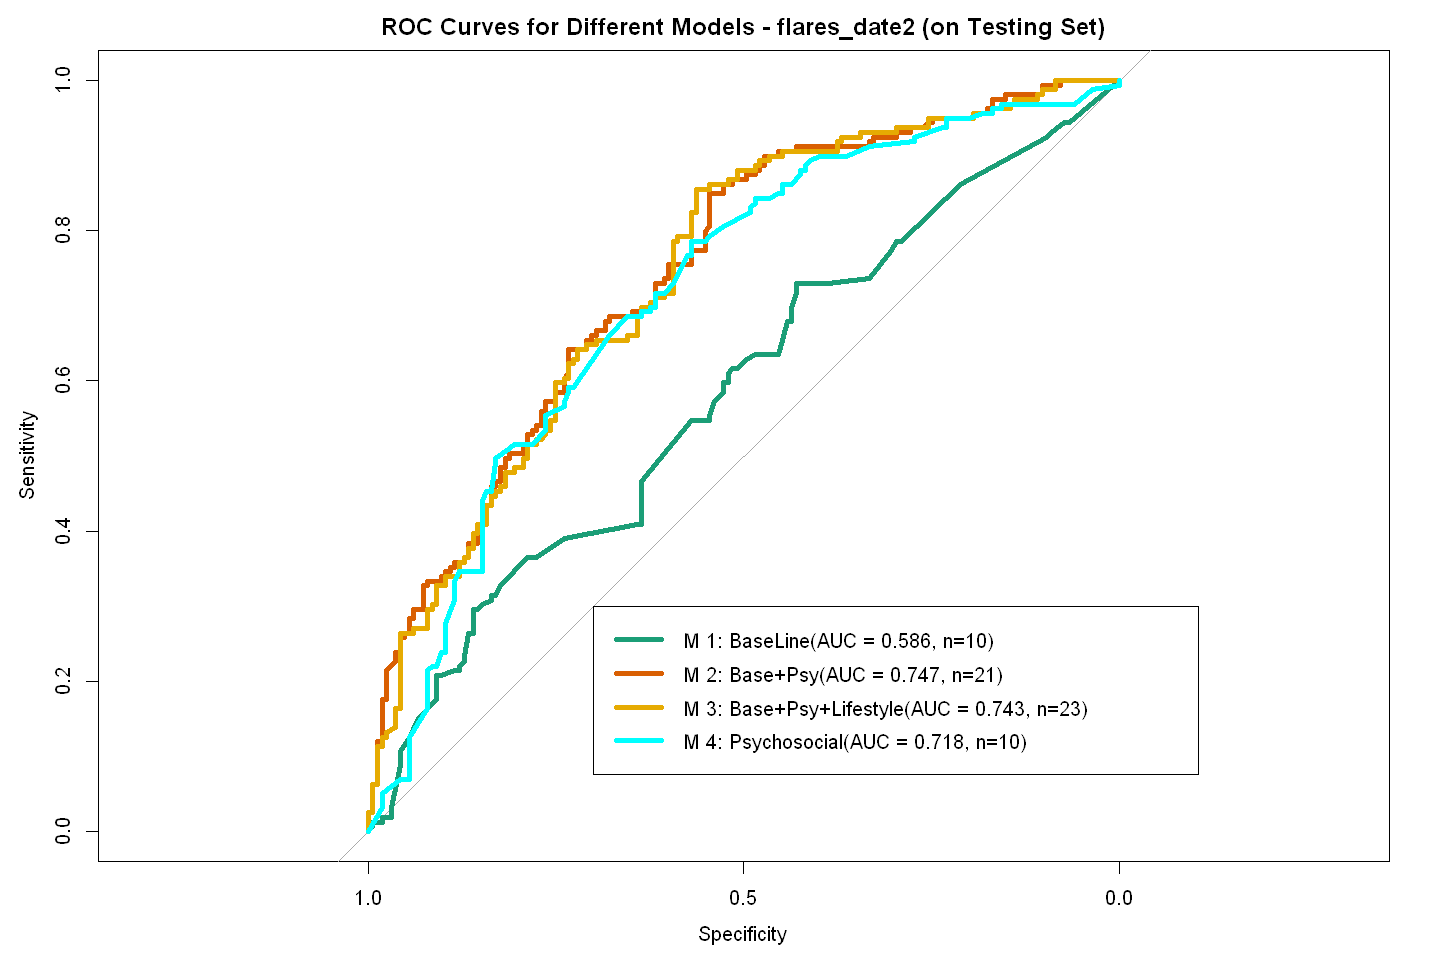

In [137]:
# Plot ROC Curves for All Models - Y2
roc_model1_y2 <- metrics_model1_y2$roc_curve
roc_model2_y2 <- metrics_model2_y2$roc_curve
roc_model3_y2 <- metrics_model3_y2$roc_curve
roc_model4_y2 <- metrics_model4_y2$roc_curve
#roc_model5_y2 <- metrics_model5_y2$roc_curve

# ROC plot for Y2
legend_labels_y2 <- c(
    paste0("M 1: BaseLine(AUC = ", sprintf("%.3f", auc(roc_model1_y2)),  ", n=",len_model1_y2,")"),
    paste0("M 2: Base+Psy(AUC = ", sprintf("%.3f", auc(roc_model2_y2)),  ", n=",len_model2_y2,")"),
    paste0("M 3: Base+Psy+Lifestyle(AUC = ", sprintf("%.3f", auc(roc_model3_y2)), ", n=",len_model3_y2, ")"),
    paste0("M 4: Psychosocial(AUC = ", sprintf("%.3f", auc(roc_model4_y2)),  ", n=",len_model4_y2,")")
     #paste0("M 5: LifeStyle(AUC = ", sprintf("%.3f", auc(roc_model5_y2)), ", n=",len_model5_y2,")")
)

# Create ROC plot for Y2
options(repr.plot.width=12, repr.plot.height=8)
plot(roc_model1_y2, col = "#1B9E77", main = "ROC Curves for Different Models - flares_date2 (on Testing Set)", lwd=4)
plot(roc_model2_y2, col =  "#D95F02", add = TRUE, lwd=4)
plot(roc_model3_y2, col = "#E6AB02", add = TRUE, lwd=4)
plot(roc_model4_y2, col = "cyan", add = TRUE, lwd=4)
#plot(roc_model5_y2, col = "#7570B3", add = TRUE)
    
# Add legend
legend(x = 0.7, y = 0.3, 
        legend = legend_labels_y2,
        col = c("#1B9E77",  "#D95F02", "#E6AB02","cyan", "#7570B3"),
        lwd = 4)



In [138]:
# Create a results table for Y2
results_table_y2 <- data.frame(
    Model = c("Model 1: BaseLine", 
              "Model 2: BaseLine +Psychosocial", 
              "Model 3: BaseLine+Psychosocial+Lifestyle", 
              "Model 4: Psychosocial only"#,              "Model 5: Lifestyle only"
              ),
    Sensitivity = c(metrics_model1_y2$metrics[1],
                    metrics_model2_y2$metrics[1],
                    metrics_model3_y2$metrics[1],
                    metrics_model4_y2$metrics[1]#,                    metrics_model5_y2$metrics[1]
                    ),
    Specificity = c(metrics_model1_y2$metrics[2],
                    metrics_model2_y2$metrics[2],
                    metrics_model3_y2$metrics[2], 
                    metrics_model4_y2$metrics[2]#,                    metrics_model5_y2$metrics[2]
                    ),
    PPV = c(metrics_model1_y2$metrics[3],
            metrics_model2_y2$metrics[3],
            metrics_model3_y2$metrics[3], 
            metrics_model4_y2$metrics[3]#,            metrics_model5_y2$metrics[3]
            ),
    NPV = c(metrics_model1_y2$metrics[4],
            metrics_model2_y2$metrics[4],
            metrics_model3_y2$metrics[4],
            metrics_model4_y2$metrics[4]#,            metrics_model5_y2$metrics[4]
            )
)

# Print the results table for Y2
cat("Results Table for Y2:\n")
print(kable(results_table_y2, format = "simple"))

Results Table for Y2:


Model                                       Sensitivity   Specificity         PPV         NPV
-----------------------------------------  ------------  ------------  ----------  ----------
Model 1: BaseLine                             0.5723270     0.5393939   0.5449102   0.5668790
Model 2: BaseLine +Psychosocial               0.6918239     0.6303030   0.6432749   0.6797386
Model 3: BaseLine+Psychosocial+Lifestyle      0.6666667     0.6424242   0.6424242   0.6666667
Model 4: Psychosocial only                    0.6855346     0.6363636   0.6449704   0.6774194


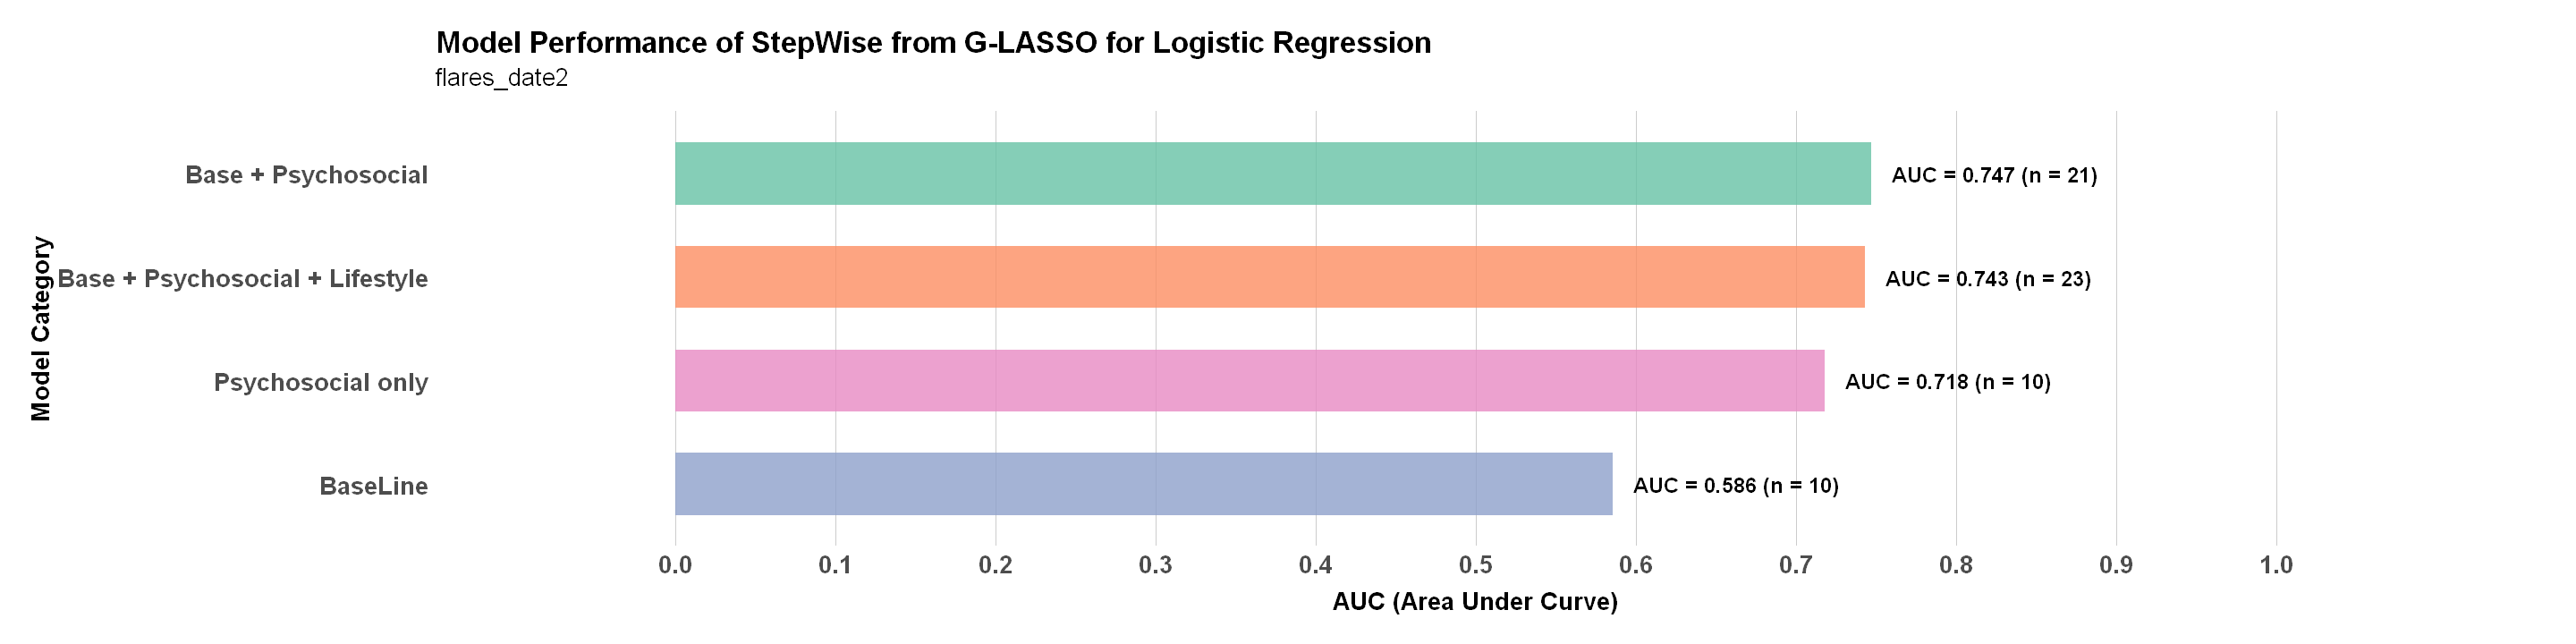

In [139]:

# Variable importance plot for Y2
variable_importance_y2 <- data.frame(
  Variable = c("BaseLine", 
               "Base + Psychosocial", "Base + Psychosocial + Lifestyle", "Psychosocial only"#, "Lifestyle"
               ),
  auc_values = c(metrics_model1_y2$auc,
                 metrics_model2_y2$auc, metrics_model3_y2$auc, metrics_model4_y2$auc#,  metrics_model5_y2$auc
                 
                 ),
  n_vars = c(len_model1_y2, 
             len_model2_y2, len_model3_y2, len_model4_y2#,             len_model5_y2
             )
)

options(repr.plot.width=24, repr.plot.height=6)
# Create Figure : Variable Importance Plot for Y1
ggplot(variable_importance_y2, aes(x = auc_values, y = reorder(Variable, auc_values))) +
  geom_col(aes(fill = Variable), width = 0.6, alpha = 0.8) +
  geom_text(aes(label = sprintf("AUC = %.3f (n = %d)", auc_values, n_vars)), 
            hjust = -0.1, size = 5, fontface = "bold") +
  scale_x_continuous(limits = c(0, 1), 
                     breaks = seq(0, 1, 0.1),
                     expand = c(0, 0.15)) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Model Performance of StepWise from G-LASSO for Logistic Regression",
       subtitle = "flares_date2",
       y = "Model Category",
       x = "AUC (Area Under Curve)") +
  theme_minimal() +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 20, face = "bold", hjust = 0),
    plot.subtitle = element_text(size = 16, hjust = 0, margin = margin(b = 15)),
    axis.title.x = element_text(size = 16, face = "bold", margin = margin(t = 10)),
    axis.title.y = element_text(size = 16, face = "bold", margin = margin(r = 10)),
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 16, face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.x = element_line(color = "gray80", linewidth = 0.5),
    plot.margin = margin(20, 40, 20, 20)
  )


## 5.3 MODELS FOR FLARE DATE 3 (Later Flares)

**Model 1: Baseline Only (AUC = 0.500)**
- **Complete failure** (0 variables selected)
- **Interpretation**: Baseline characteristics provide ZERO value for late flares

**Model 2: Baseline + Psychosocial (AUC = 0.766) - BEST**
- **Variables selected**: 21 variables
- **Test Performance**: Accuracy 71.0%, AUC 0.766
- **Key predictors**:
  - Surgery history: 2.32 (dominant predictor)
  - Disease severity: 1.22
  - Disease burden HIGH: -3.00 (massively protective!)
  - Fatigue medium: -0.93, high: -0.78 (both strongly protective)
  - Stress Q3: 0.62, Q4: 0.58
  - Female: -0.30 (protective)
- **Interpretation**: Surgery history becomes the single most important predictor. Disease burden paradox reaches maximum effect.

**Model 3: Baseline + Psychosocial + Lifestyle (AUC = 0.765)**
- **Variables selected**: 19 variables
- **Test Performance**: Accuracy 65.4%, AUC 0.765 (virtually identical to M2)
- **Key predictors**:
  - Disease severity: 0.56
  - Surgery: 0.31 (much reduced from M2!)
  - Disease burden HIGH: -1.15 (half the M2 effect)
  - Fatigue: -0.32 to -0.68
  - Current smoking: -0.08 (minimal)
- **Interpretation**: Adding lifestyle actually dilutes model performance - coefficients shrink, suggesting overfitting

**Model 4: Psychosocial Only (AUC = 0.728)**
- **Variables selected**: 10 variables
- **Test Performance**: Accuracy 60.8%, AUC 0.728
- **Key predictors**:
  - Anxiety moderate: 0.60
  - Fatigue high: -1.10 (very strong protective)
  - Disease burden HIGH: -1.08
  - Stress Q3: 0.46
- **Interpretation**: Strong performance independently, but still needs clinical context for optimal prediction

**Model 5: Lifestyle Only (AUC = 0.500)**
- Complete failure (0 variables selected)

### Clinical Performance - Date 3

| Model | Sensitivity | Specificity | PPV | NPV |
|-------|------------|-------------|-----|-----|
| **M2: Base+Psy** | **70.0%** | **71.4%** | **48.5%** | **86.1%** |
| M3: Base+Psy+Life | 78.9% | 60.3% | 43.3% | 88.1% |
| M4: Psy only | 67.8% | 58.1% | 38.4% | 82.4% |

**Best Clinical Model**: Model 2 - better balanced performance, excellent NPV


### Date 3 Rankings
1. **Model 2** (AUC 0.766) - Optimal without lifestyle
2. Model 3 (AUC 0.765) - Lifestyle adds no value (possible overfitting)
3. Model 4 (AUC 0.728) - Surprisingly strong standalone
4. Model 1 (AUC 0.500) - Complete failure
5. Model 5 (AUC 0.500) - Complete failure

**Pattern**: Lifestyle becomes redundant; core psychosocial+baseline optimal





=== MODELS FOR y3 ===


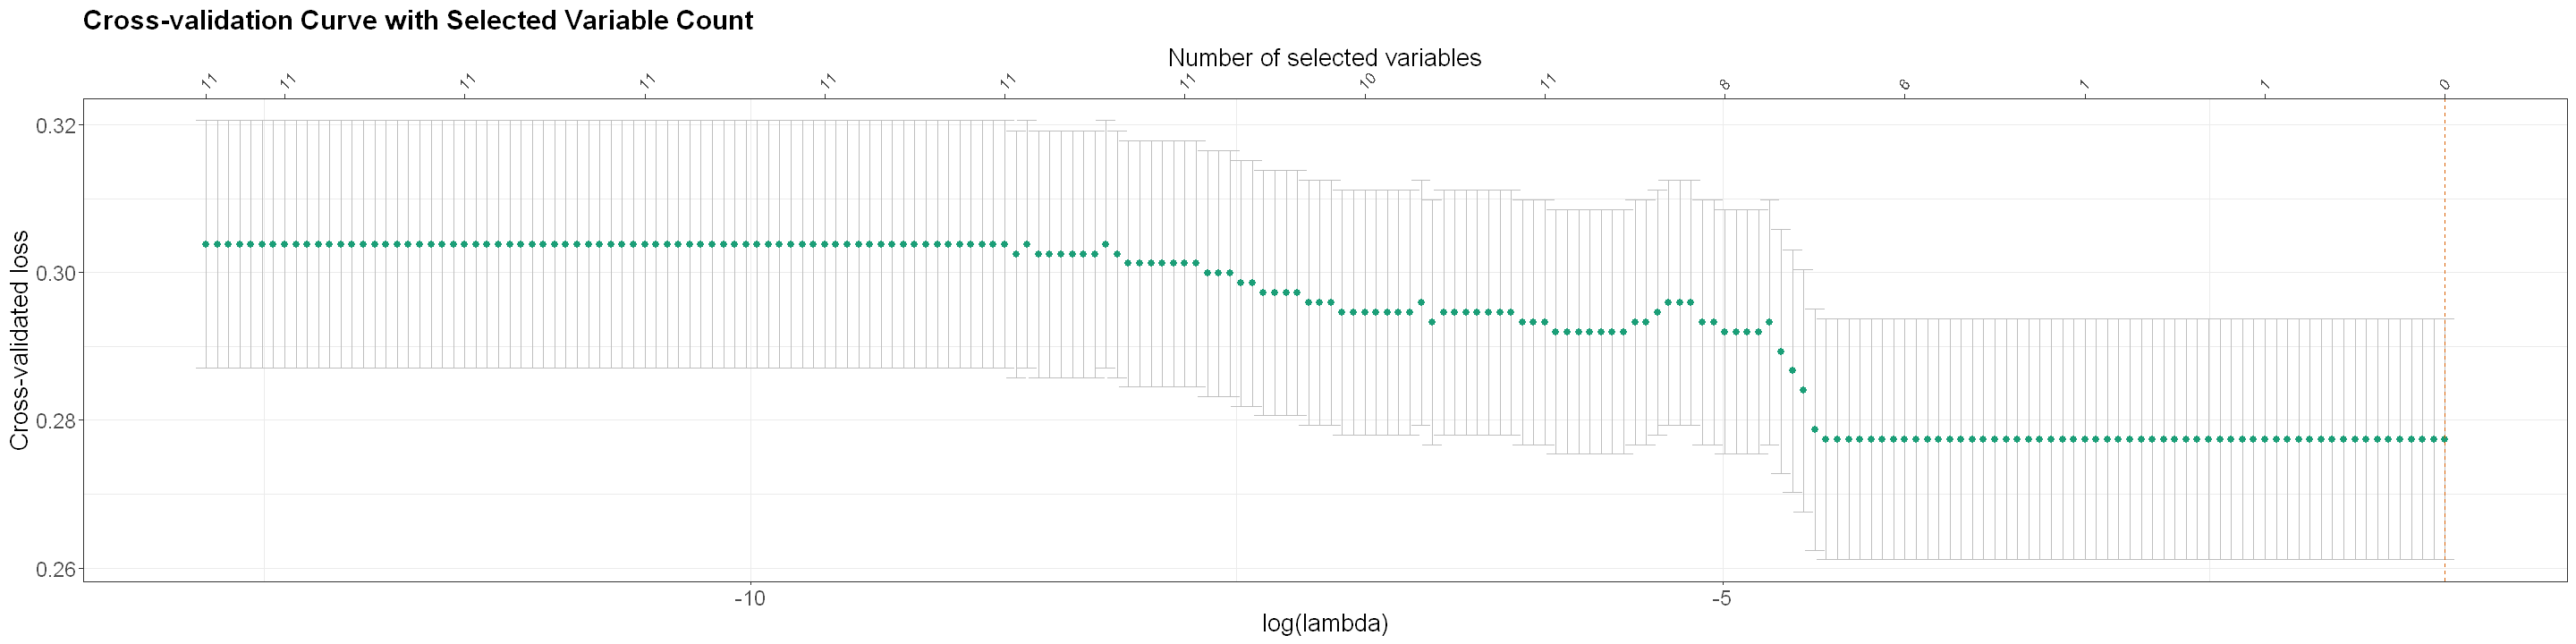

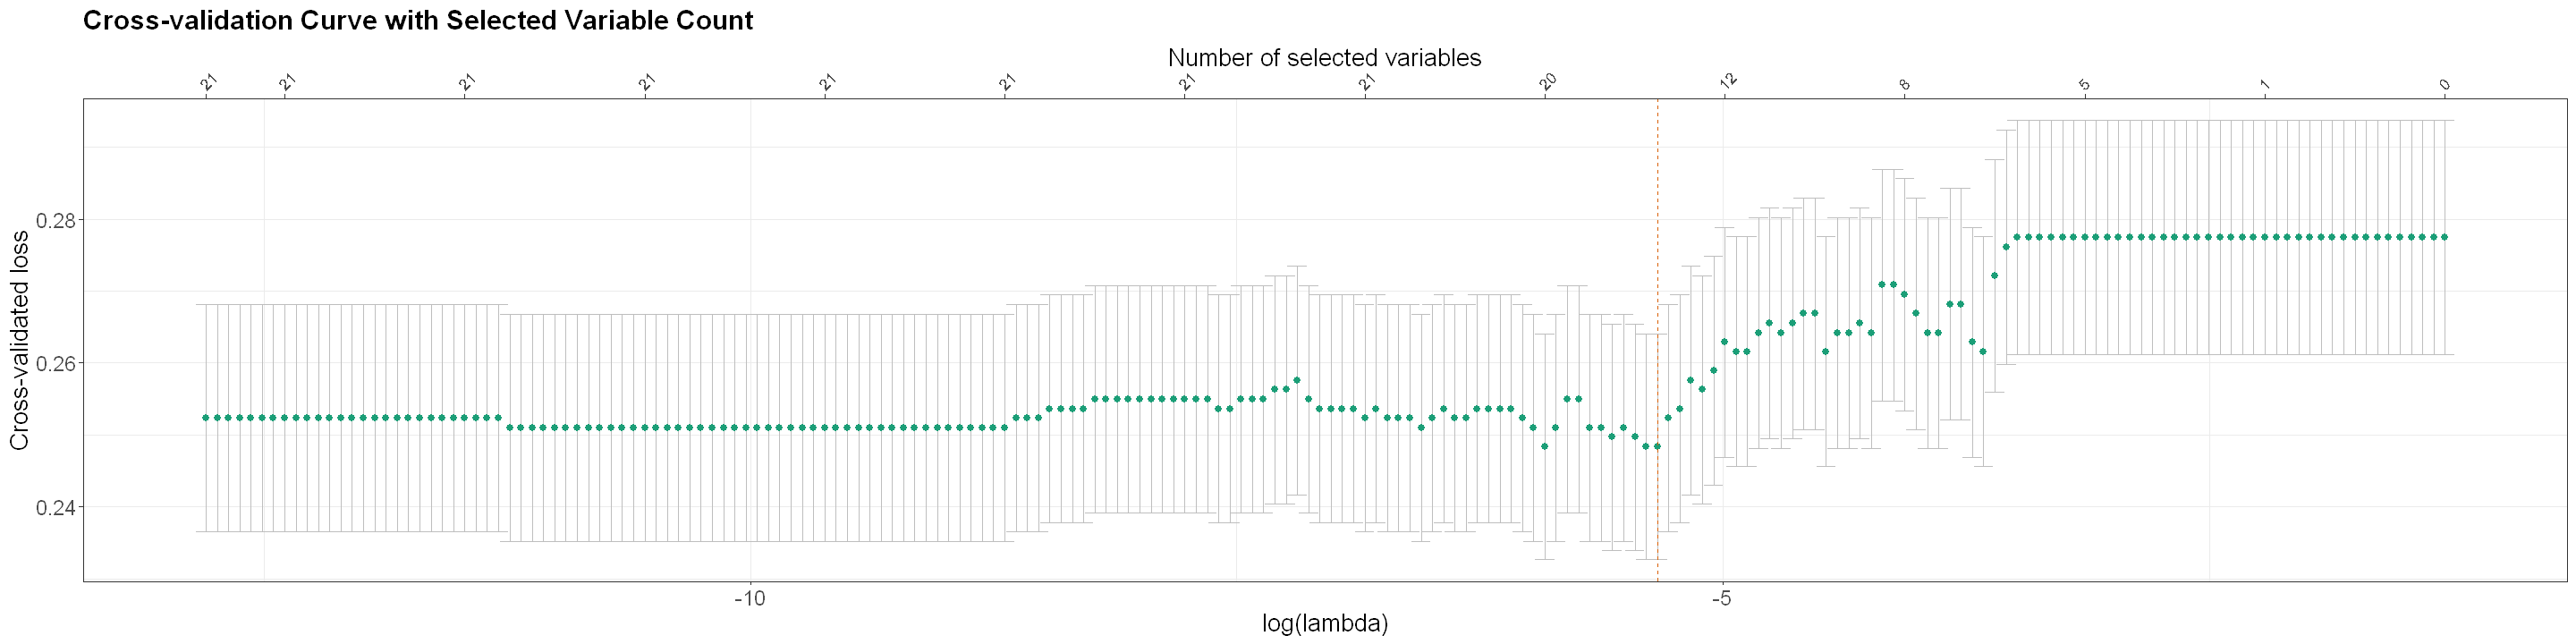

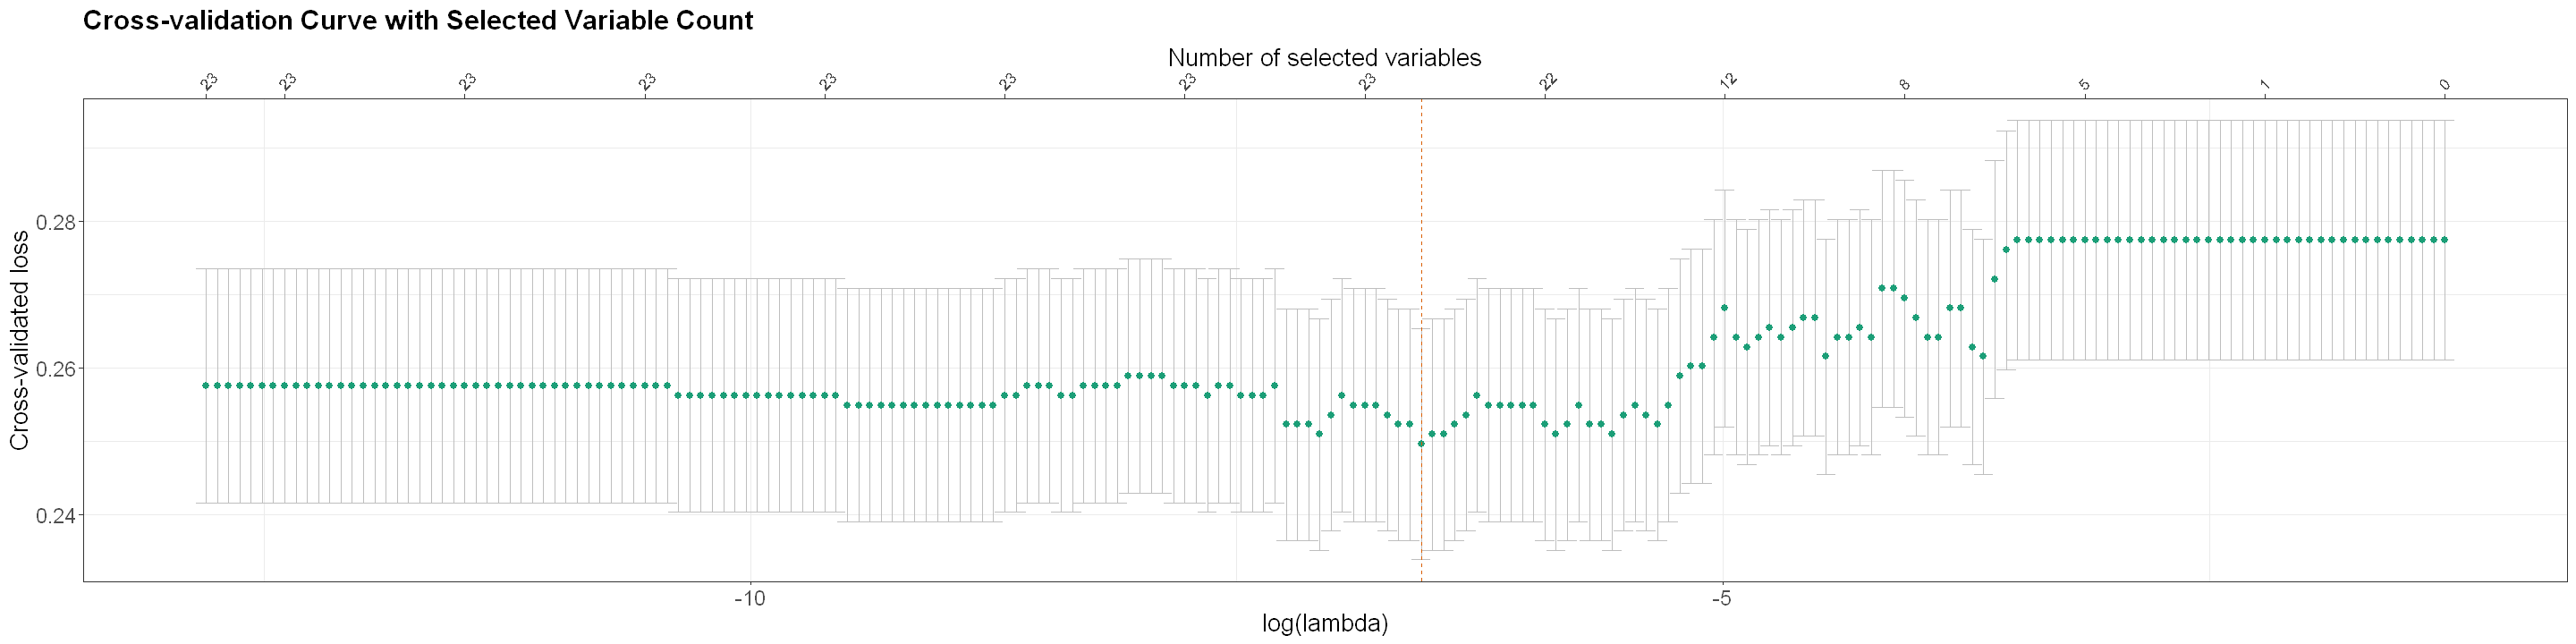

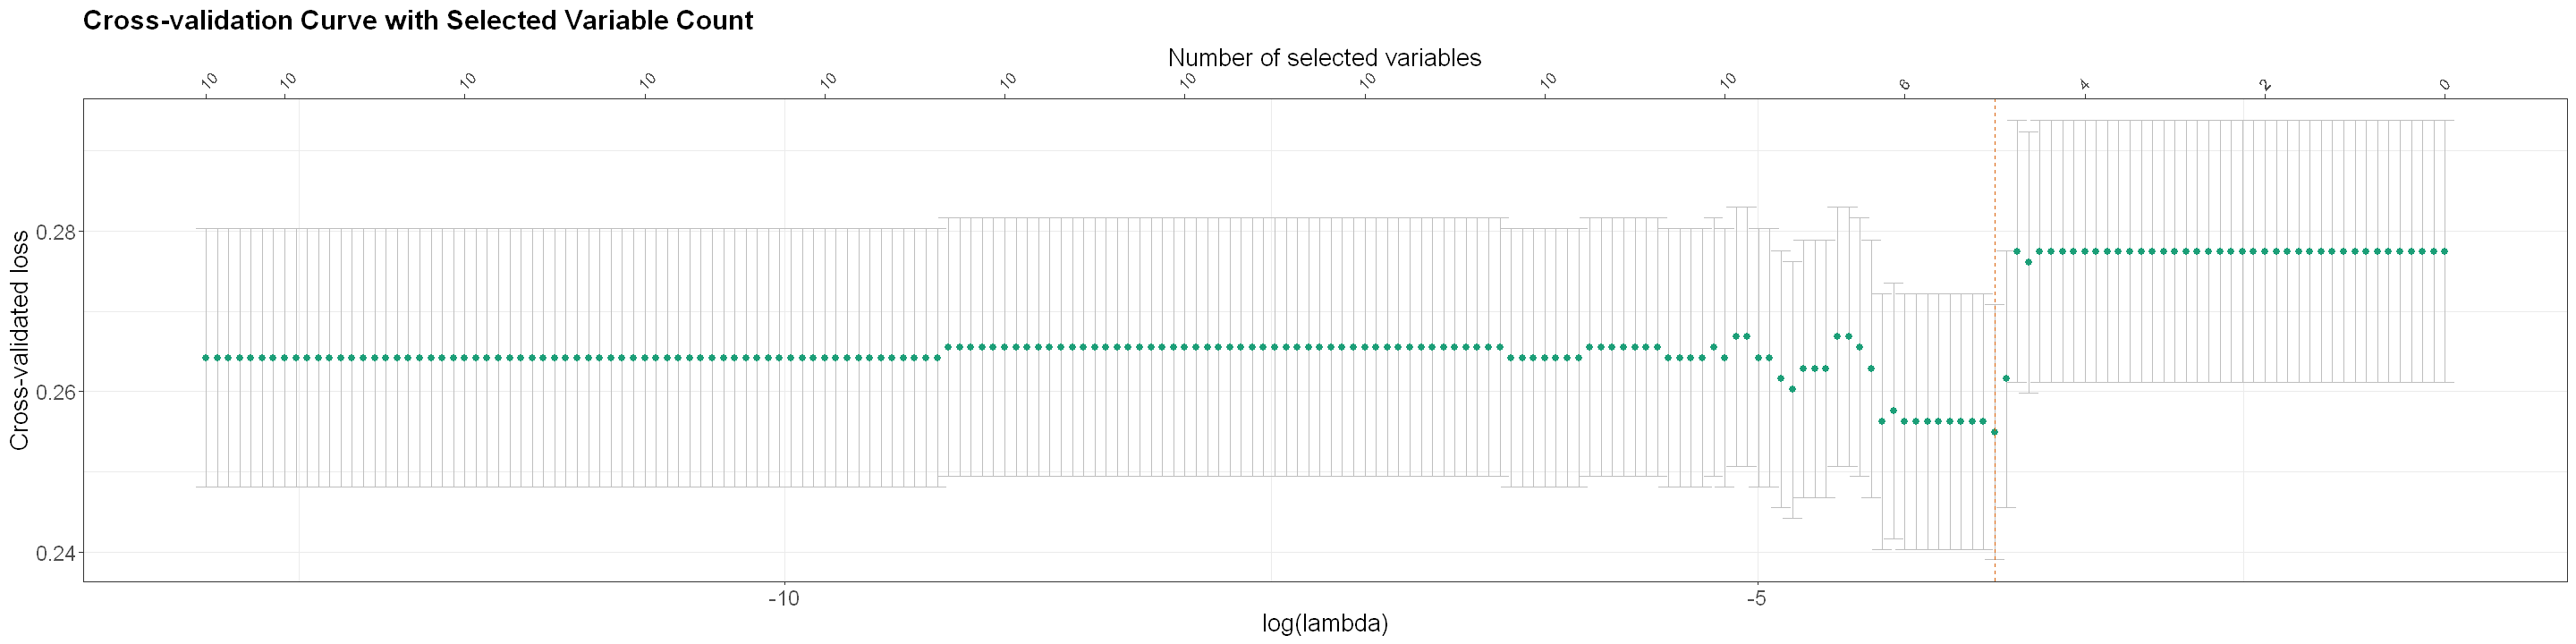

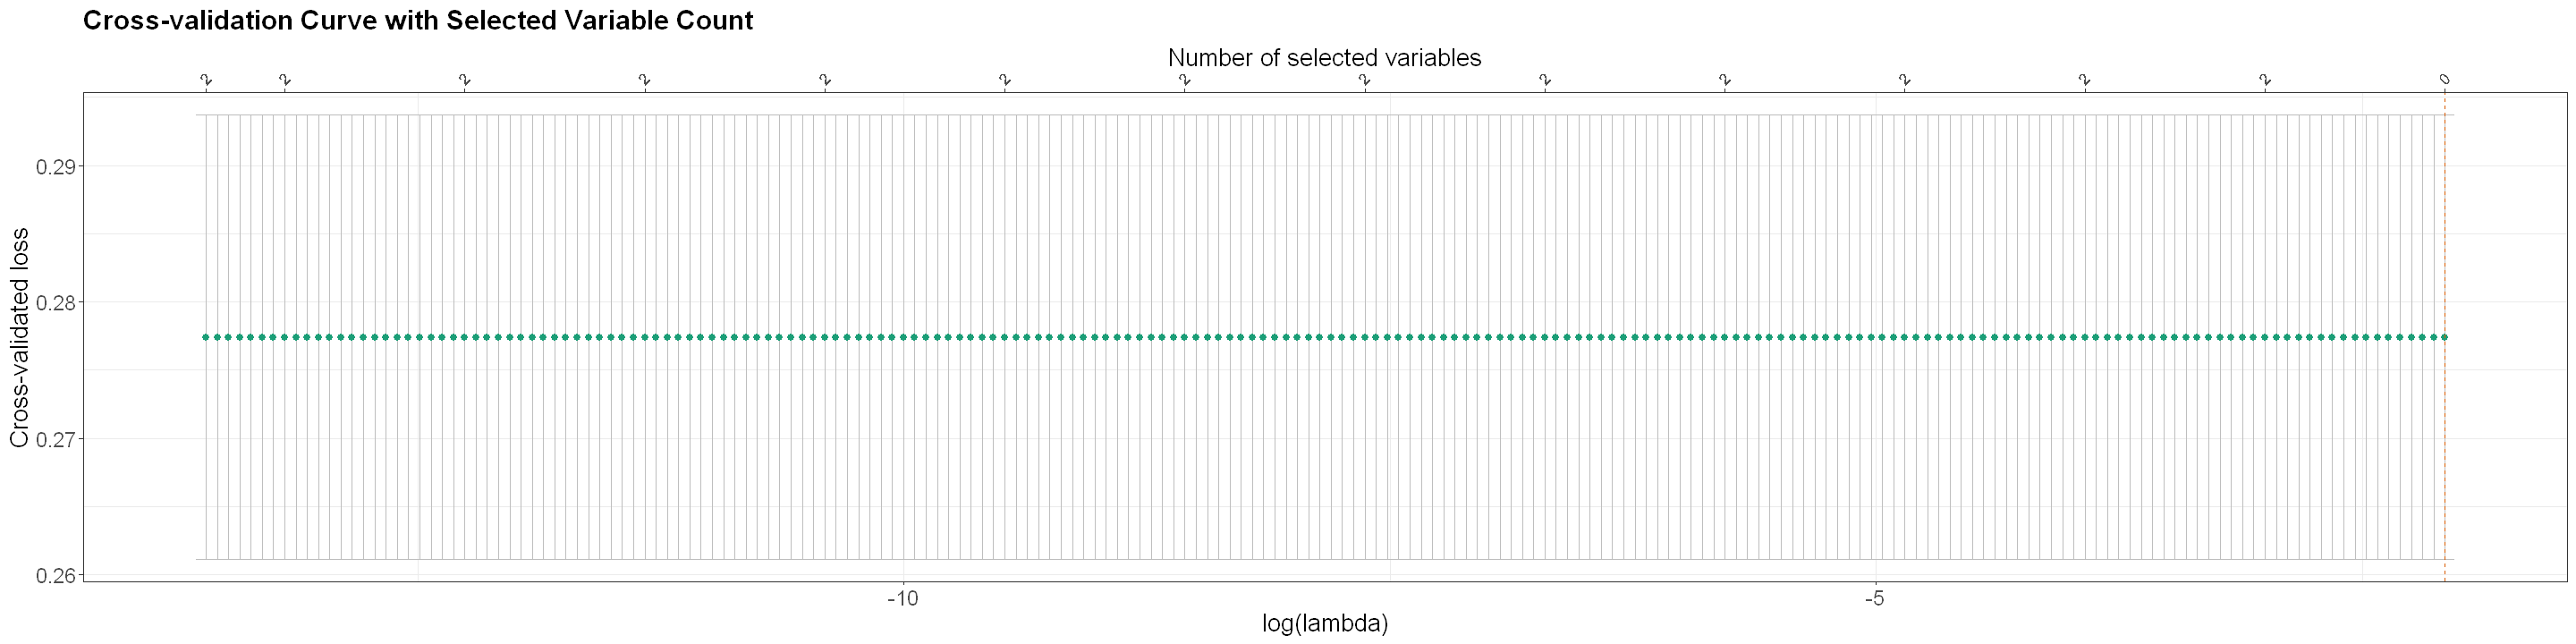

In [140]:
cat("\n\n=== MODELS FOR y3 ===\n")

# Run cross-validation for all 5 models with y3
set.seed(123)
cv3_results1 <- cv_gglasso_collect_auc(x1_train, y3_train, group_indices1)## Model 1: BaseLine model

set.seed(123)
cv3_results2 <- cv_gglasso_collect_auc(x2_train, y3_train, group_indices2)## Model 2: BaseLine + psychosocial model

set.seed(123)
cv3_results3 <- cv_gglasso_collect_auc(x3_train, y3_train, group_indices3)##  Model 3: BaseLine + psychosocial + lifestyle model

set.seed(123)
cv3_results4 <- cv_gglasso_collect_auc(x4_train, y3_train, group_indices4)##  Model 3: Lifestyle only model

set.seed(123)
cv3_results5 <- cv_gglasso_collect_auc(x5_train, y3_train, group_indices5)##  Model 4:  psychosocial  


### Model Evaluation

#### Training Performance




In [141]:

# Print cross-validation results with confidence intervals
cat("\n--- Cross-Validation Results for y3 (on Training Set) ---\n")
cat("Model 1: Baseline characteristics only - AUC:", round(cv3_results1$mean_auc, 3), 
    "95% CI: [", round(cv3_results1$ci_lower, 3), "-", round(cv3_results1$ci_upper, 3), "]\n")
cat("Model 2: BaseLine + Psychosocial - AUC:", round(cv3_results2$mean_auc, 3), 
    "95% CI: [", round(cv3_results2$ci_lower, 3), "-", round(cv3_results2$ci_upper, 3), "]\n")
cat("Model 3: BaseLine + Psychosocial + Lifestyle - AUC:", round(cv3_results3$mean_auc, 3), 
    "95% CI: [", round(cv3_results3$ci_lower, 3), "-", round(cv3_results3$ci_upper, 3), "]\n")

cat("Model 4: Psychosocial only - AUC:", round(cv3_results4$mean_auc, 3), 
    "95% CI: [", round(cv3_results4$ci_lower, 3), "-", round(cv3_results4$ci_upper, 3), "]\n")

cat("Model 5: Lifestyle only - AUC:", round(cv3_results5$mean_auc, 3), 
    "95% CI: [", round(cv3_results5$ci_lower, 3), "-", round(cv3_results5$ci_upper, 3), "]\n")


--- Cross-Validation Results for y3 (on Training Set) ---
Model 1: Baseline characteristics only - AUC: 0.5 95% CI: [ 0.5 - 0.5 ]
Model 2: BaseLine + Psychosocial - AUC: 0.701 95% CI: [ 0.633 - 0.77 ]
Model 3: BaseLine + Psychosocial + Lifestyle - AUC: 0.718 95% CI: [ 0.662 - 0.773 ]
Model 4: Psychosocial only - AUC: 0.643 95% CI: [ 0.592 - 0.693 ]
Model 5: Lifestyle only - AUC: 0.5 95% CI: [ 0.5 - 0.5 ]


#### Test Set Performance


In [142]:
# Extract coefficients for each model
#len_model1_y3 <- cv3_results1$selected_variable_count
len_model2_y3 <- cv3_results2$selected_variable_count
len_model3_y3 <- cv3_results3$selected_variable_count
len_model4_y3 <- cv3_results4$selected_variable_count
#len_model5_y3 <- cv3_results5$selected_variable_count

cv_models <- list(
  `Model 1: BaseLine` = cv3_results1,
  `Model 2: BaseLine +Psychosocial` = cv3_results2,
  `Model 3: BaseLine+Psy+Lifestyle` = cv3_results3,
  `Model 4: Psychosocial` = cv3_results4,
  `Model 5: Lifestyle` = cv3_results5
)

coef_table <- combine_gglasso_coefficients(cv_models)
(coef_table)

Variable,Model 1: BaseLine,Model 2: BaseLine +Psychosocial,Model 3: BaseLine+Psy+Lifestyle,Model 4: Psychosocial,Model 5: Lifestyle
<chr>,"<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>"
(Intercept),,,,,
genderFemale,,-0.3876,-0.364,,
age_at_inclusionQ2,,-0.0105,-0.0786,,
age_at_inclusionQ3,,-0.0189,-0.13,,
age_at_inclusionQ4,,0.0086,0.0466,,
DiseaseEntity_x_extent_uc1,,,0.1504,,
DiseaseEntity_x_extent_uc2,,,0.1841,,
DiseaseEntity_x_extent_uc3,,,0.3813,,
DiseaseEntity_x_severity_uc1,,0.9688,1.1904,,


In [143]:
# ===== ANALYSIS FOR Y3 =====
cat("\n--- Cross-Validation Results for Y3 (on Testing Set) ---\n")

# Compute metrics for all models with y3
#metrics_model1_y3 <- compute_metrics(model = cv3_results1$model, x = x1_test, y3_test)
metrics_model2_y3 <- compute_metrics(model = cv3_results2$model, x = x2_test, y3_test)
metrics_model3_y3 <- compute_metrics(model = cv3_results3$model, x = x3_test, y3_test)
metrics_model4_y3 <- compute_metrics(model = cv3_results4$model, x = x4_test, y3_test)
#metrics_model5_y3 <- compute_metrics(model = cv3_results5$model, x = x5_test, y3_test)

# Print performance metrics for Y3
#cat("Model 1: Baseline characteristics only - Accuracy:", metrics_model1_y3$accuracy, "AUC:", metrics_model1_y3$auc, "  (95% CI: [", round(metrics_model1_y3$auc-cv3_results1$margin, 3), "-", round(metrics_model1_y3$auc+cv3_results1$margin, 3), "])\n")
cat("Model 2: BaseLine + Psychosocial - Accuracy:", metrics_model2_y3$accuracy, "AUC:", metrics_model2_y3$auc, " (95% CI: [", round(metrics_model2_y3$auc-cv3_results2$margin, 3), "-", round(metrics_model2_y3$auc+cv3_results2$margin, 3), "])\n")
cat("Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy:", metrics_model3_y3$accuracy, "AUC:", metrics_model3_y3$auc,  " (95% CI: [", round(metrics_model3_y3$auc-cv3_results3$margin, 3), "-", round(metrics_model3_y3$auc+cv3_results3$margin, 3), "])\n")
cat("Model 4: Psychosocial only- Accuracy:", metrics_model4_y3$accuracy, "AUC:", metrics_model4_y3$auc,  " (95% CI: [", round(metrics_model4_y3$auc-cv3_results4$margin, 3), "-", round(metrics_model4_y3$auc+cv3_results4$margin, 3), "])\n")

#cat("Model 5: Lifestyle only - Accuracy:", metrics_model5_y3$accuracy, "AUC:", metrics_model5_y3$auc,  " (95% CI: [", round(metrics_model5_y3$auc-cv3_results5$margin, 3), "-", round(metrics_model5_y3$auc+cv3_results5$margin, 3), "])\n")




--- Cross-Validation Results for Y3 (on Testing Set) ---
Model 2: BaseLine + Psychosocial - Accuracy: 0.6604938 AUC: 0.749762  (95% CI: [ 0.682 - 0.818 ])
Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy: 0.691358 AUC: 0.7573568  (95% CI: [ 0.702 - 0.813 ])
Model 4: Psychosocial only- Accuracy: 0.5987654 AUC: 0.6960144  (95% CI: [ 0.646 - 0.746 ])


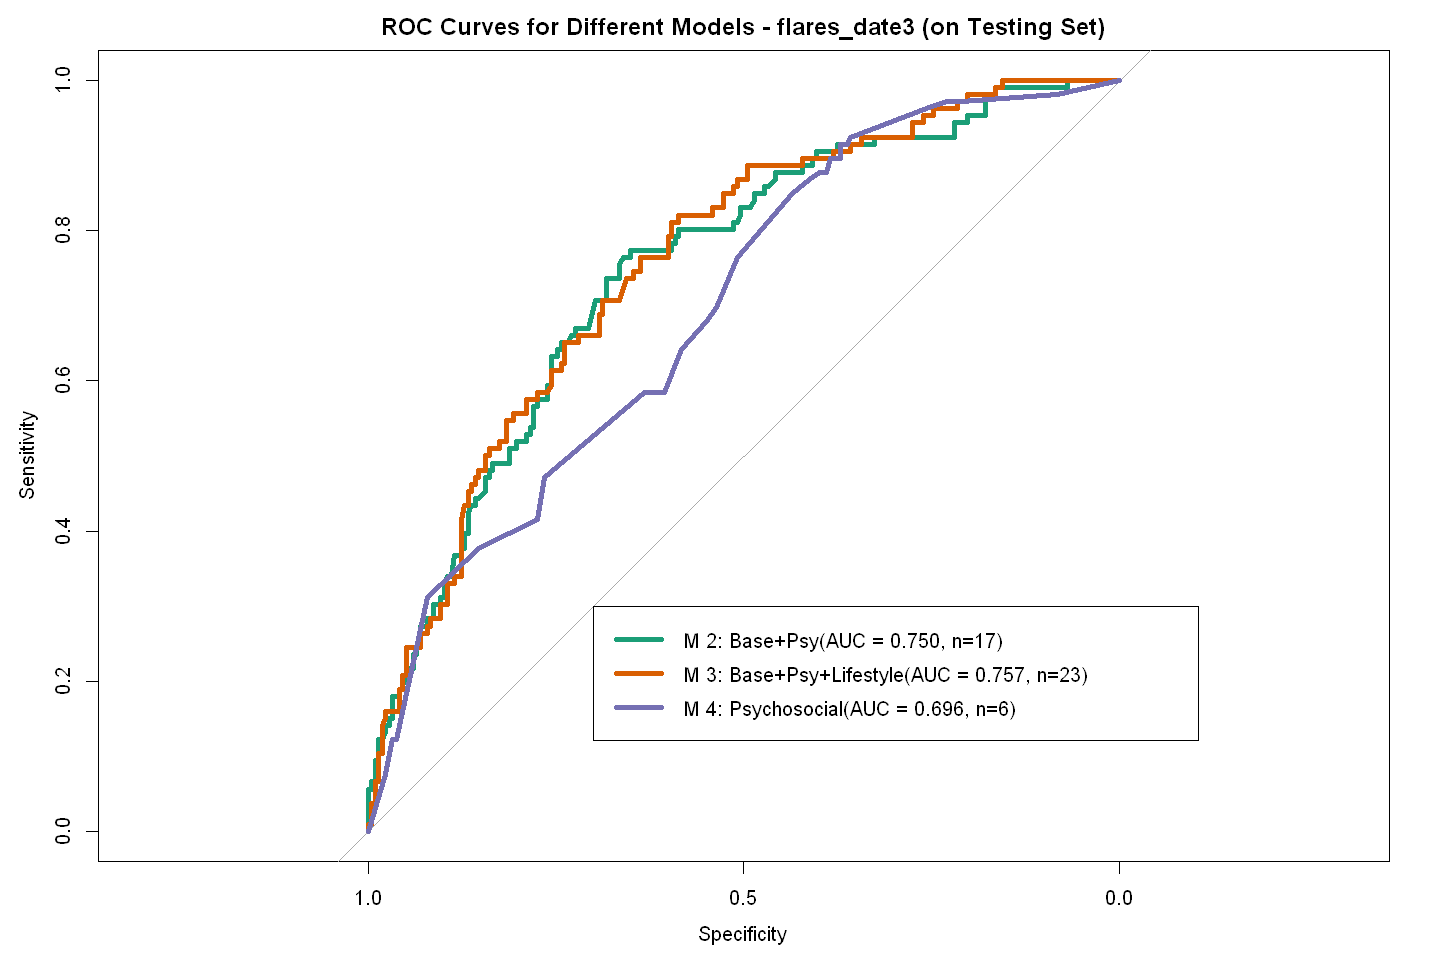

In [144]:
# Plot ROC Curves for All Models - Y3
#roc_model1_y3 <- metrics_model1_y3$roc_curve
roc_model2_y3 <- metrics_model2_y3$roc_curve
roc_model3_y3 <- metrics_model3_y3$roc_curve
roc_model4_y3 <- metrics_model4_y3$roc_curve
#roc_model5_y3 <- metrics_model5_y3$roc_curve

# ROC plot for Y3
legend_labels_y3 <- c(
    #paste0("M 1: BaseLine(AUC = ", sprintf("%.3f", auc(roc_model1_y3)),  ", n=",len_model1_y3,")"),
    paste0("M 2: Base+Psy(AUC = ", sprintf("%.3f", auc(roc_model2_y3)),  ", n=",len_model2_y3,")"),
    paste0("M 3: Base+Psy+Lifestyle(AUC = ", sprintf("%.3f", auc(roc_model3_y3)), ", n=",len_model3_y3, ")"),
    paste0("M 4: Psychosocial(AUC = ", sprintf("%.3f", auc(roc_model4_y3)), ", n=",len_model4_y3, ")")
 #   paste0("M 5: LifeStyle(AUC = ", sprintf("%.3f", auc(roc_model5_y3)), ", n=",len_model5_y3,")")
)

# Create ROC plot for Y3
options(repr.plot.width=12, repr.plot.height=8)
plot(roc_model2_y3, col = "#1B9E77", main = "ROC Curves for Different Models - flares_date3 (on Testing Set)", lwd=4)
plot(roc_model3_y3, col =  "#D95F02", add = TRUE, lwd=4)
plot(roc_model4_y3, col = "#7570B3", add = TRUE, lwd=4)
#plot(roc_model1_y3, col = "#E6AB02", add = TRUE)
#plot(roc_model5_y3, col = "cyan", add = TRUE)
    
# Add legend
legend(x = 0.7, y = 0.3, 
        legend = legend_labels_y3,
        col = c("#1B9E77",  "#D95F02", "#7570B3","#E6AB02"),
        lwd = 4)


In [145]:
# Create a results table for Y3
results_table_y3 <- data.frame(
    Model = c(#"Model 1: BaseLine", 
              "Model 2: BaseLine +Psychosocial", 
              "Model 3: BaseLine + Psychosocial + Lifestyle", 
              "Model 4: Psychosocial only"#,               "Model 5: Lifestyle only"
              ),
    Sensitivity = c(#metrics_model1_y3$metrics[1],
      metrics_model2_y3$metrics[1],
                    metrics_model3_y3$metrics[1],
      metrics_model4_y3$metrics[1]#,  metrics_model5_y3$metrics[1]
                    ),
    Specificity = c(#metrics_model1_y3$metrics[2],
      metrics_model2_y3$metrics[2],
                    metrics_model3_y3$metrics[2],   metrics_model4_y3$metrics[2]
                   # metrics_model5_y3$metrics[2]
                    ),
    PPV = c(#metrics_model1_y3$metrics[3], 
      metrics_model2_y3$metrics[3],
            metrics_model3_y3$metrics[3],  metrics_model4_y3$metrics[3]#,
           # metrics_model5_y3$metrics[3]
            ),
    NPV = c(#metrics_model1_y3$metrics[4],
      metrics_model2_y3$metrics[4],
            metrics_model3_y3$metrics[4], metrics_model4_y3$metrics[4]#, 
            #metrics_model5_y3$metrics[4]
            )
)

# Print the results table for Y3
cat("Results Table for Y3:\n")

print(kable(results_table_y3, format = "simple"))

Results Table for Y3:


Model                                           Sensitivity   Specificity         PPV         NPV
---------------------------------------------  ------------  ------------  ----------  ----------
Model 2: BaseLine +Psychosocial                   0.7735849     0.6055046   0.4880952   0.8461538
Model 3: BaseLine + Psychosocial + Lifestyle      0.6981132     0.6880734   0.5211268   0.8241758
Model 4: Psychosocial only                        0.5849057     0.6055046   0.4189189   0.7500000


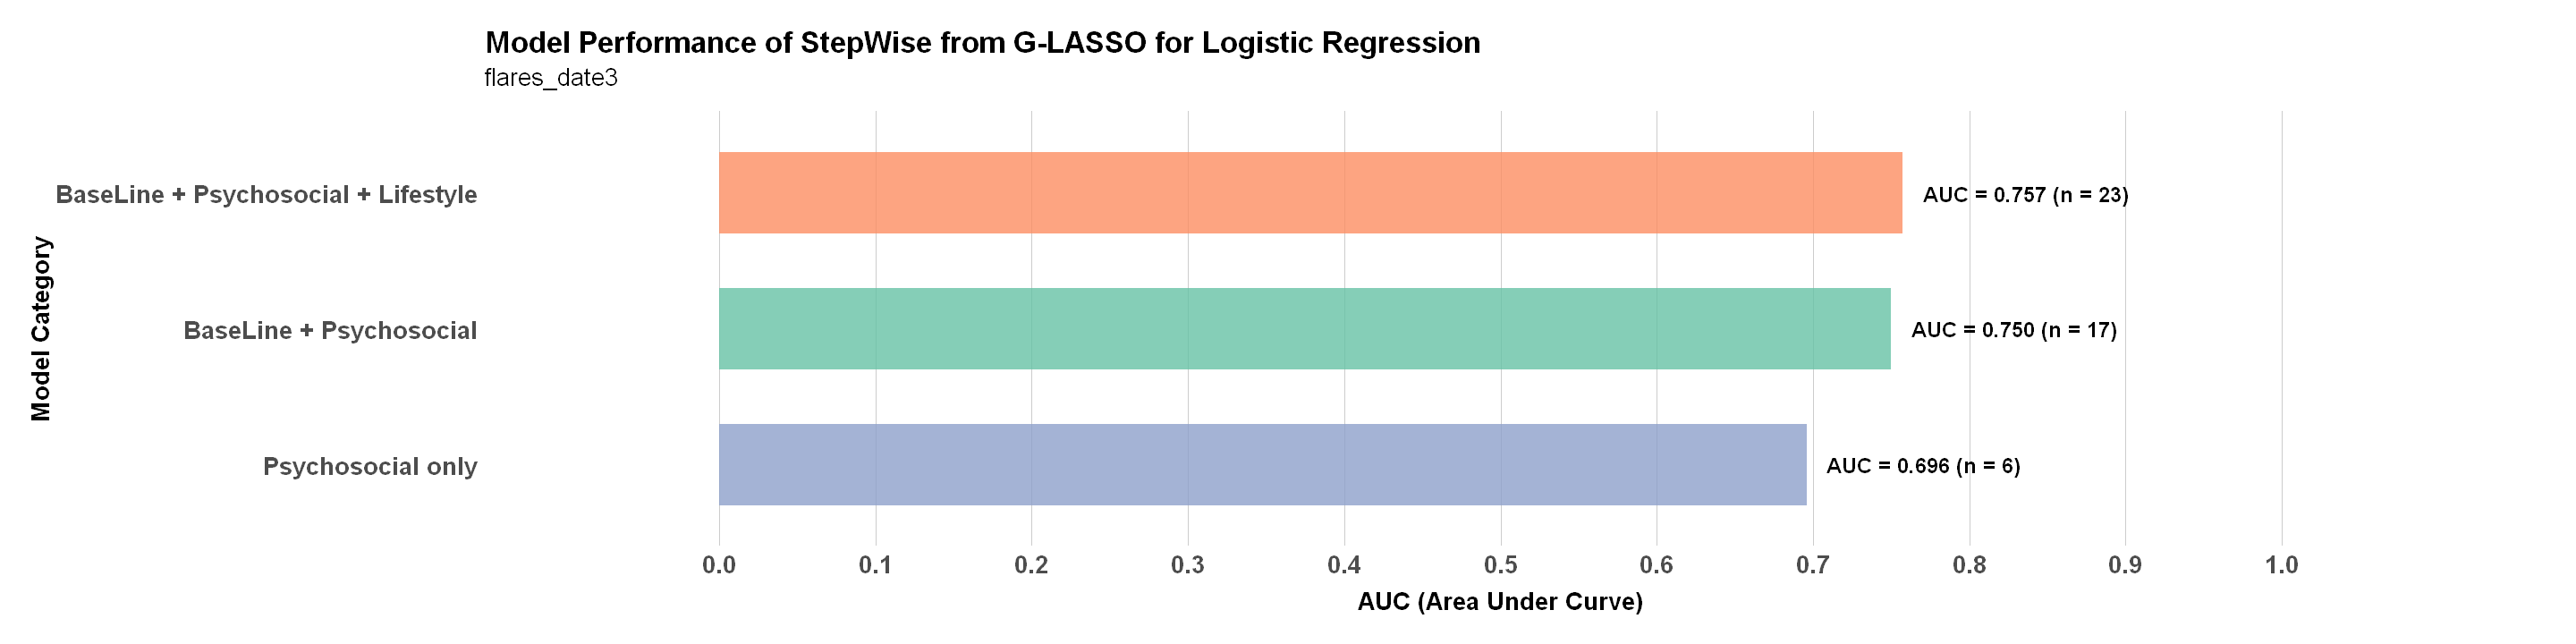

In [146]:
# Variable importance plot for Y3
variable_importance_y3 <- data.frame(
  Variable = c(#"BaseLine", 
               "BaseLine + Psychosocial", "BaseLine + Psychosocial + Lifestyle", 
               "Psychosocial only"#,                "Lifestyle only"
               ),
  auc_values = c(#metrics_model1_y3$auc,
                 metrics_model2_y3$auc, metrics_model3_y3$auc,
                 metrics_model4_y3$auc#,metrics_model5_y3$auc
                 ),
  n_vars = c(#len_model1_y3, 
             len_model2_y3, len_model3_y3, len_model4_y3#, len_model5_y3
             )
)

options(repr.plot.width=24, repr.plot.height=6)
# Create Figure : Variable Importance Plot for Y1
ggplot(variable_importance_y3, aes(x = auc_values, y = reorder(Variable, auc_values))) +
  geom_col(aes(fill = Variable), width = 0.6, alpha = 0.8) +
  geom_text(aes(label = sprintf("AUC = %.3f (n = %d)", auc_values, n_vars)), 
            hjust = -0.1, size = 5, fontface = "bold") +
  scale_x_continuous(limits = c(0, 1), 
                     breaks = seq(0, 1, 0.1),
                     expand = c(0, 0.15)) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Model Performance of StepWise from G-LASSO for Logistic Regression",
       subtitle = "flares_date3",
       y = "Model Category",
       x = "AUC (Area Under Curve)") +
  theme_minimal() +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 20, face = "bold", hjust = 0),
    plot.subtitle = element_text(size = 16, hjust = 0, margin = margin(b = 15)),
    axis.title.x = element_text(size = 16, face = "bold", margin = margin(t = 10)),
    axis.title.y = element_text(size = 16, face = "bold", margin = margin(r = 10)),
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 16, face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.x = element_line(color = "gray80", linewidth = 0.5),
    plot.margin = margin(20, 40, 20, 20)
  )


## 5.4 MODELS FOR FLARE DATE 4 (Very Late Flares)

### Model Performance Overview

**Model 1: Baseline Only (AUC = 0.500)**
- Complete failure (0 variables selected)

**Model 2: Baseline + Psychosocial (AUC = 0.806)**
- **Variables selected**: 19 variables
- **Test Performance**: Accuracy 71.6%, AUC 0.806 - **HIGHEST AUC ACHIEVED**
- **Key predictors**:
  - Disease entity CD: -2.02, UC: -1.04 (disease type matters!)
  - Anxiety moderate: 0.90 (very strong)
  - Surgery: 0.97
  - Disease burden HIGH: -1.24 (protective)
  - Stress Q4: 0.33
  - Fatigue high: -0.46
- **Interpretation**: Disease type becomes critical differentiator. Anxiety dominates psychosocial prediction.

**Model 3: Baseline + Psychosocial + Lifestyle (AUC = 0.799)**
- **Variables selected**: 24 variables (maximum)
- **Test Performance**: Accuracy 69.8%, AUC 0.799
- **Key predictors**:
  - Disease entity CD: -3.29, UC: -2.55 (even stronger!)
  - Surgery: 1.99 (massive)
  - Anxiety moderate: 1.11 (strongest psychosocial)
  - Stress Q4: 1.23
  - Disease burden HIGH: -2.04
  - Age Q4: 1.03
  - Current smoking: -0.30
- **Interpretation**: Model 2 remains superior despite M3's complexity - suggests overfitting

**Model 4: Psychosocial Only (AUC = 0.500)**
- Complete failure (0 variables selected)
- **Critical finding**: Unlike earlier timepoints, psychosocial alone cannot predict very late flares

**Model 5: Lifestyle Only (AUC = 0.500)**
- Complete failure

### Clinical Performance - Date 4

| Model | Sensitivity | Specificity | PPV | NPV |
|-------|------------|-------------|-----|-----|
| **M2: Base+Psy** | **73.2%** | **71.4%** | **27.0%** | **94.8%** |
| M3: Base+Psy+Life | 68.3% | 70.0% | 24.8% | 93.8% |

**Best Clinical Model**: Model 2 with exceptional NPV (94.8%)



### Date 4 Rankings
1. **Model 2** (AUC 0.806) - Peak performance
2. Model 3 (AUC 0.799) - Minimal degradation from overfitting
3. Model 1, 4, 5 (AUC 0.500) - All single-domain models fail completely

**Pattern**: Only integrated models work; both baseline AND psychosocial required


In [147]:
## 2. Create data matrices for independent variables (training set)
x1_train <- as.matrix(X_train[, c(1:13)]) # Baseline + Medication characteristics 
x2_train <- as.matrix(X_train[, c(1:13, 14:23)]) # Baseline + psychosocial
x3_train <- as.matrix(X_train[, c(1:13, 14:23, 24:25)]) # Baseline + psychosocial + lifestyle 
x4_train <- as.matrix(X_train[, 14:23]) # Psychosocial only
x5_train <- as.matrix(X_train[,  24:25]) # Lifestyle only

## 3. Create data matrices for independent variables (test set)
x1_test <- as.matrix(X_test[, c(1:13)]) 
x2_test <- as.matrix(X_test[, c(1:13, 14:23)])
x3_test <- as.matrix(X_test[, c(1:13, 14:23, 24:25)])
x4_test <- as.matrix(X_test[, 14:23])
x5_test <- as.matrix(X_test[, 24:25])

## 4. Define group indices for each model
group_indices1 <- c(rep(1, 2),2, rep(3, 3), rep(4, 3),5, 6, rep(7, 2))  # Baseline 
group_indices2 <- c(rep(1, 2),2, rep(3, 3), rep(4, 3),5, 6, rep(7, 2),  # Baseline 
                    rep(8,2), rep(9,3), rep(10,2), rep(11,2),12)
group_indices3 <- c(rep(1, 2),2, rep(3, 3), rep(4, 3),5, 6, rep(7, 2),  # Baseline 
                     rep(8,2), rep(9,3), rep(10,2), rep(11,2),12,  #psychosocial
                    rep(13, 2)) # Lifestyle
group_indices4 <- c(rep(1,2), rep(2,3), rep(3,2), rep(4,2),5)
group_indices5 <-  rep(1, 2)



=== MODELS FOR y4 ===


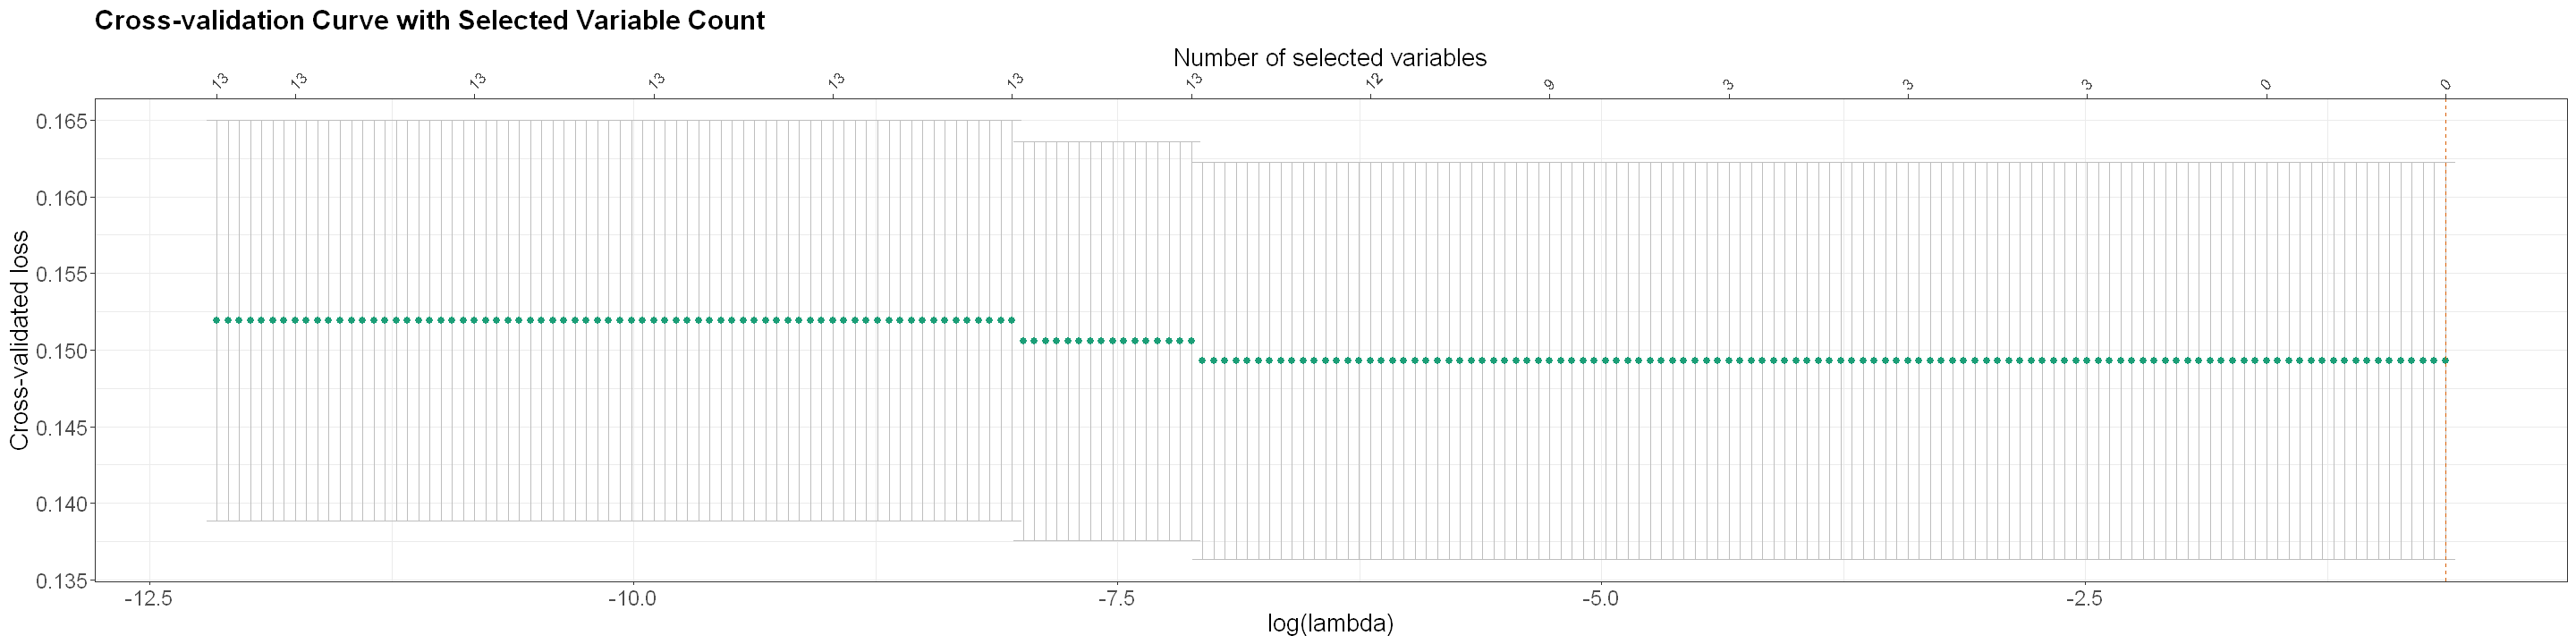

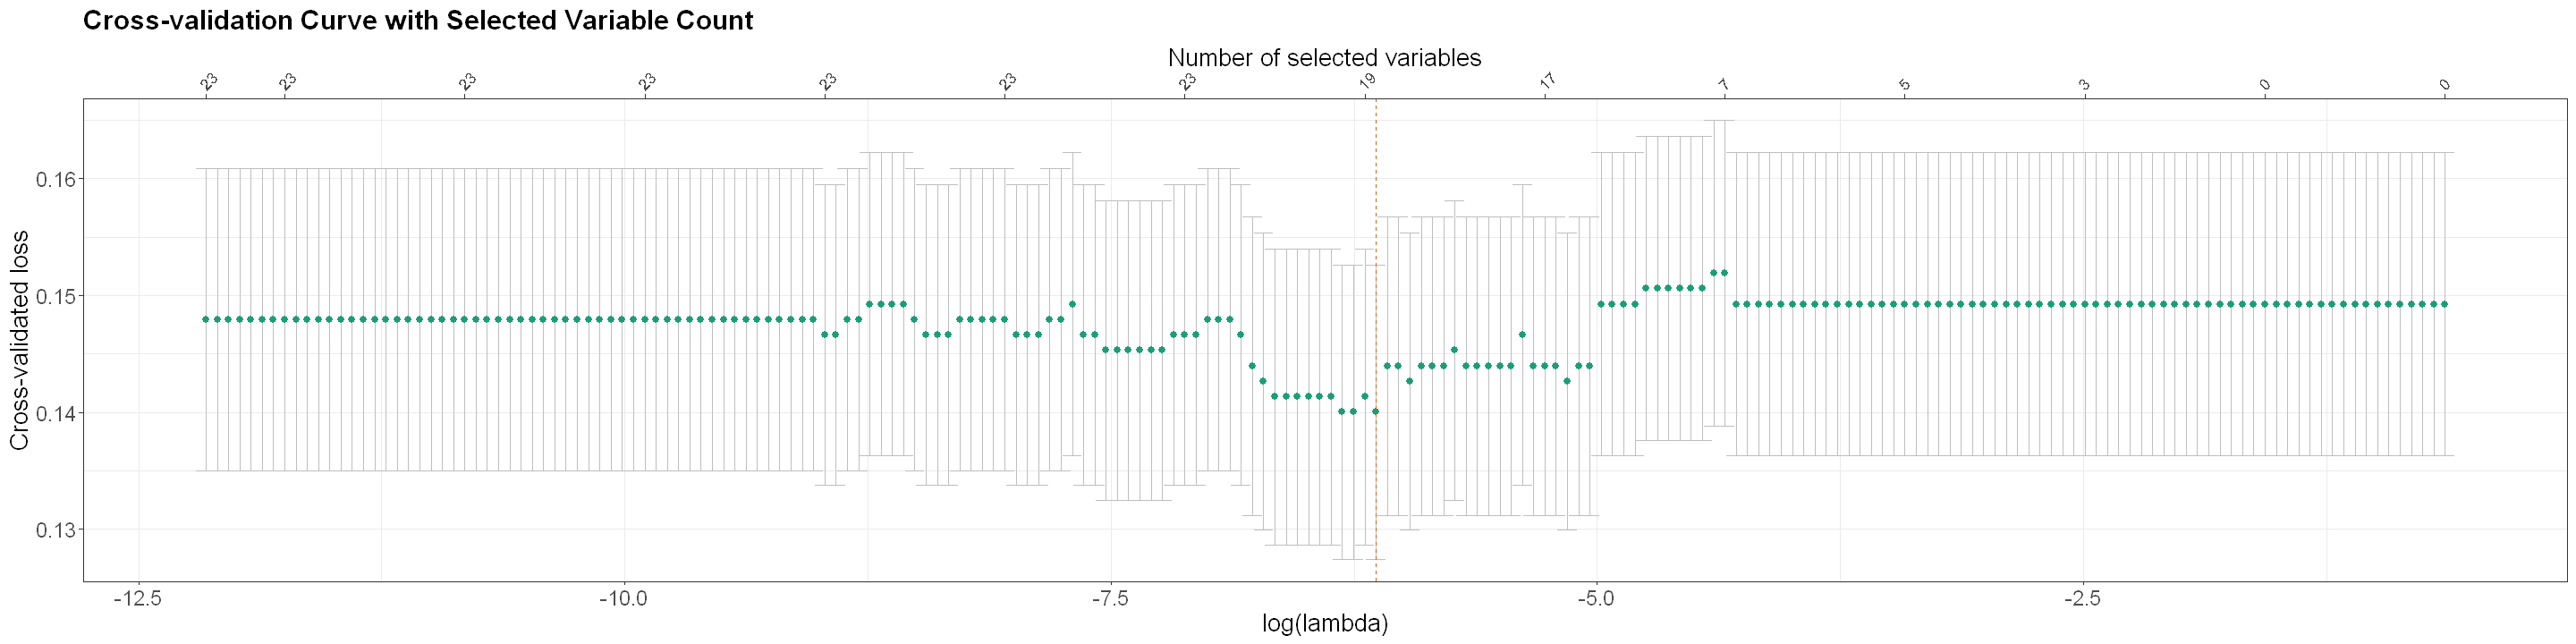

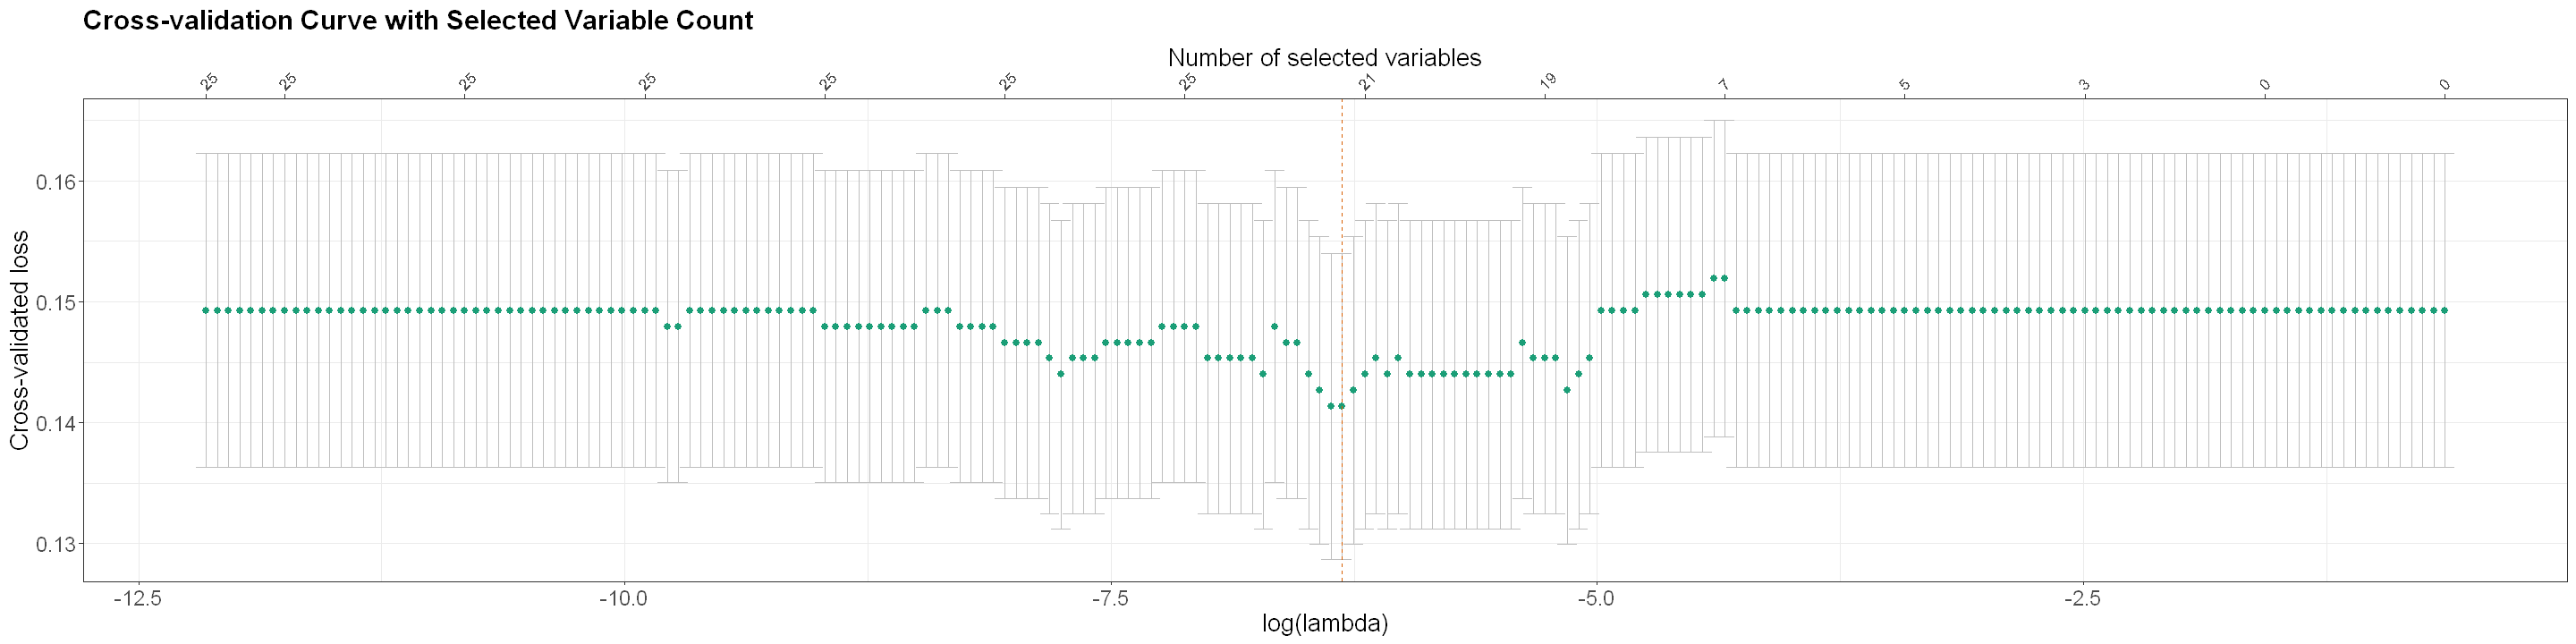

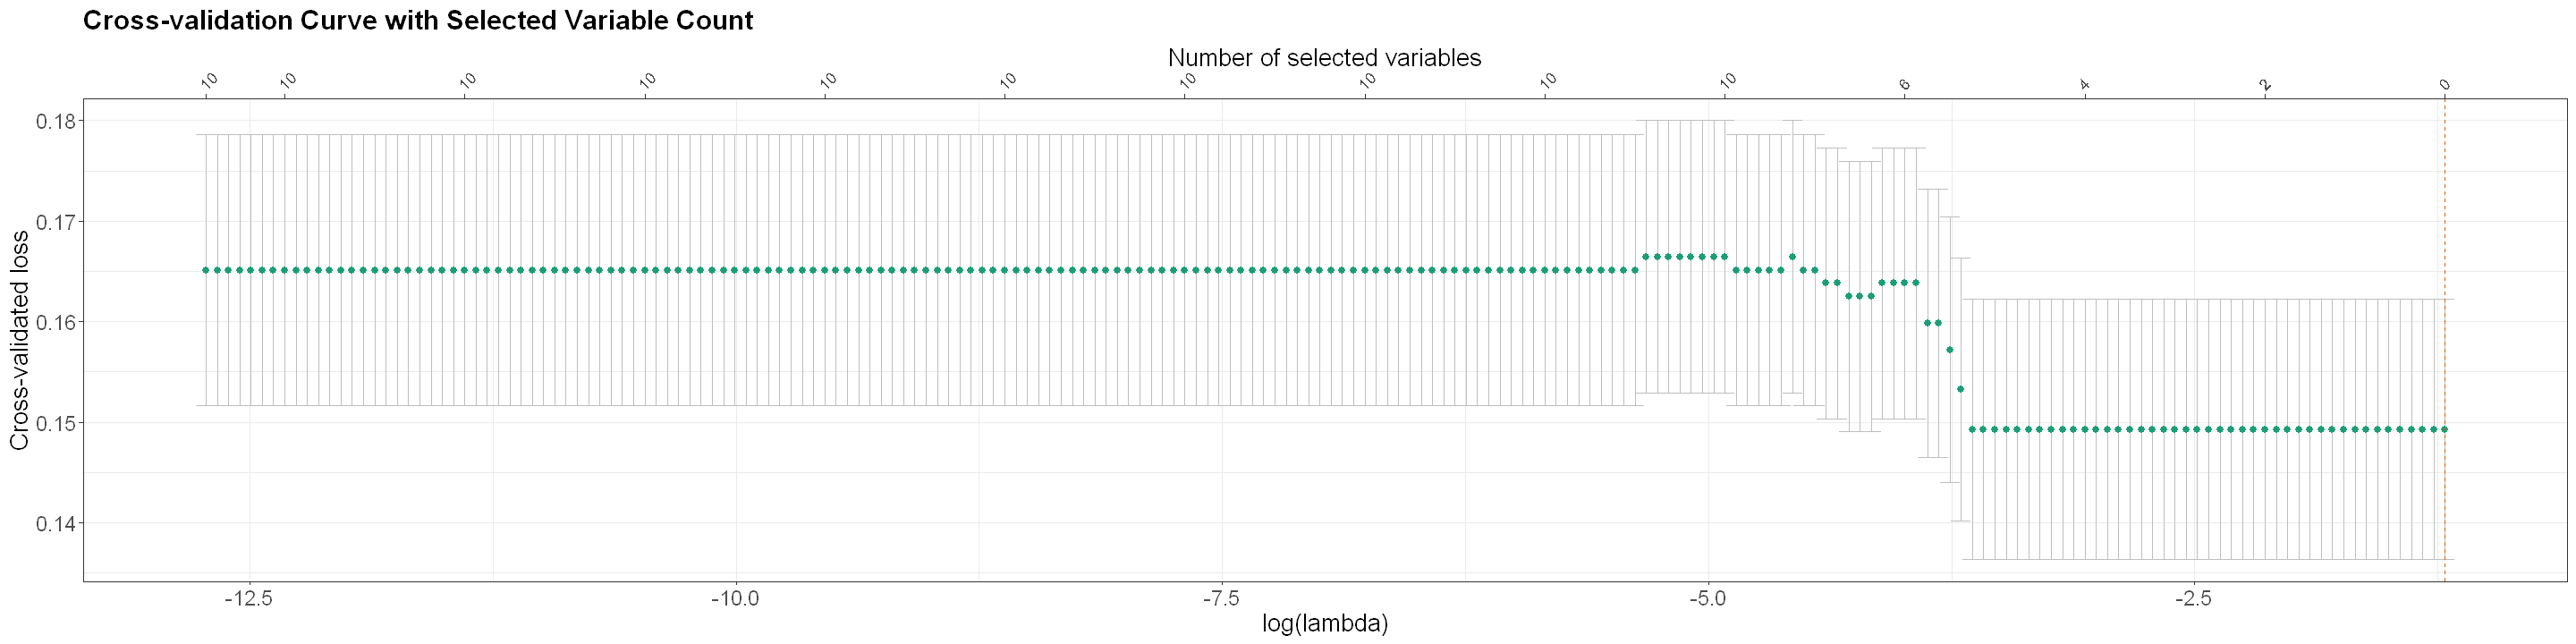

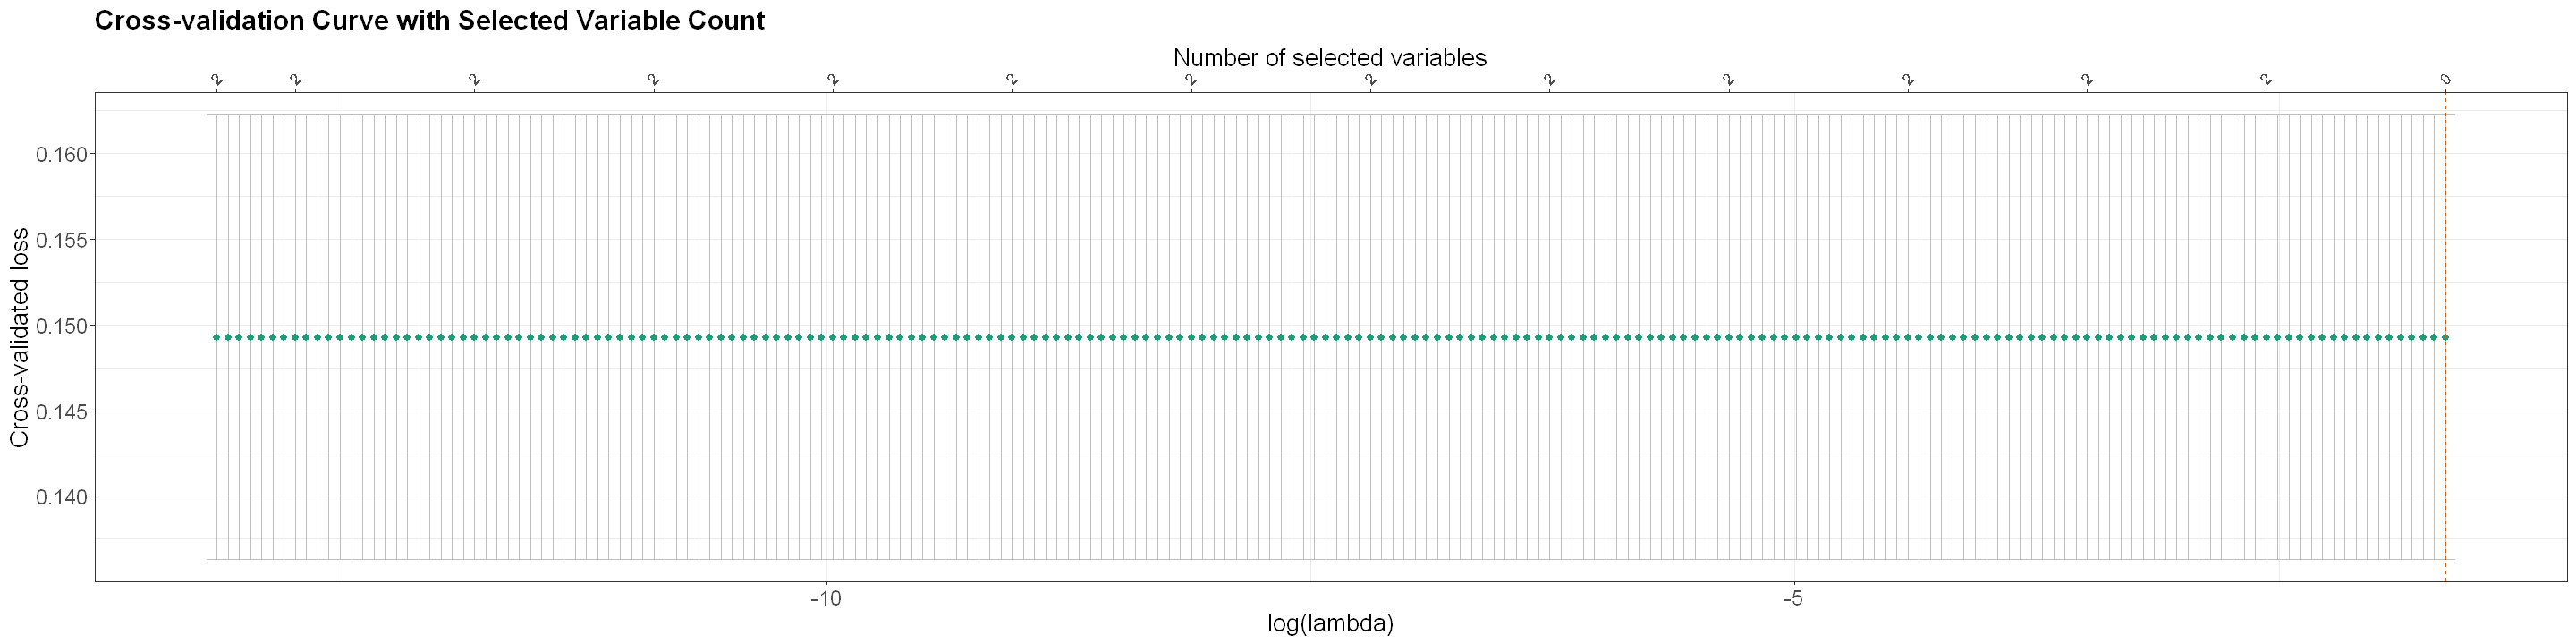

In [148]:

cat("\n\n=== MODELS FOR y4 ===\n")

# Run cross-validation for all 5 models with y4
set.seed(123)
cv4_results1 <- cv_gglasso_collect_auc(x1_train, y4_train, group_indices1)## Model 1: BaseLine model

set.seed(123)
cv4_results2 <- cv_gglasso_collect_auc(x2_train, y4_train, group_indices2)## Model 2: BaseLine + psychosocial model

set.seed(123)
cv4_results3 <- cv_gglasso_collect_auc(x3_train, y4_train, group_indices3)##  Model 3: BaseLine + psychosocial + lifestyle model

set.seed(123)
cv4_results4 <- cv_gglasso_collect_auc(x4_train, y4_train, group_indices4)##  Model 4: Lifestyle only model

set.seed(123)
cv4_results5 <- cv_gglasso_collect_auc(x5_train, y4_train, group_indices5)##  Model 5:  psychosocial  

### Model Evaluation
#### Training Performance

In [149]:
# Print cross-validation results with confidence intervals
cat("\n--- Cross-Validation Results for y4 (on Training Set) ---\n")
cat("Model 1: Baseline characteristics only - AUC:", round(cv4_results1$mean_auc, 3), 
    "95% CI: [", round(cv4_results1$ci_lower, 3), "-", round(cv4_results1$ci_upper, 3), "]\n")
cat("Model 2: BaseLine + Psychosocial - AUC:", round(cv4_results2$mean_auc, 3), 
    "95% CI: [", round(cv4_results2$ci_lower, 3), "-", round(cv4_results2$ci_upper, 3), "]\n")
cat("Model 3: BaseLine + Psychosocial + Lifestyle - AUC:", round(cv4_results3$mean_auc, 3), 
    "95% CI: [", round(cv4_results3$ci_lower, 3), "-", round(cv4_results3$ci_upper, 3), "]\n")
cat("Model 4: Psychosocial only- AUC:", round(cv4_results4$mean_auc, 3), 
    "95% CI: [", round(cv4_results4$ci_lower, 3), "-", round(cv4_results4$ci_upper, 3), "]\n")

cat("Model 5: Lifestyle only - AUC:", round(cv4_results5$mean_auc, 3), 
    "95% CI: [", round(cv4_results5$ci_lower, 3), "-", round(cv4_results5$ci_upper, 3), "]\n")



--- Cross-Validation Results for y4 (on Training Set) ---
Model 1: Baseline characteristics only - AUC: 0.5 95% CI: [ 0.5 - 0.5 ]
Model 2: BaseLine + Psychosocial - AUC: 0.742 95% CI: [ 0.683 - 0.801 ]
Model 3: BaseLine + Psychosocial + Lifestyle - AUC: 0.746 95% CI: [ 0.68 - 0.812 ]
Model 4: Psychosocial only- AUC: 0.5 95% CI: [ 0.5 - 0.5 ]
Model 5: Lifestyle only - AUC: 0.5 95% CI: [ 0.5 - 0.5 ]


In [150]:

len_model1_y4 <- cv4_results1$selected_variable_count
len_model2_y4 <- cv4_results2$selected_variable_count
len_model3_y4 <- cv4_results3$selected_variable_count
len_model4_y4 <- cv4_results4$selected_variable_count
len_model5_y4 <- cv4_results5$selected_variable_count

# Display significant coefficients
cv_models <- list(
  `Model 1: BaseLine` = cv4_results1,
  `Model 2: BaseLine +Psychosocial` = cv4_results2,
  `Model 3: BaseLine+Psy+Lifestyle` = cv4_results3,
  `Model 4: Psychosocial` = cv4_results4,
  `Model 5: Lifestyle` = cv4_results5
)

coef_table <- combine_gglasso_coefficients(cv_models)
(coef_table)

Variable,Model 1: BaseLine,Model 2: BaseLine +Psychosocial,Model 3: BaseLine+Psy+Lifestyle,Model 4: Psychosocial,Model 5: Lifestyle
<chr>,"<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>","<chr[,1]>"
(Intercept),,,,,
DiseaseEntityCD,,-2.2495,-2.2892,,
DiseaseEntityUC,,-1.0088,-1.0657,,
genderFemale,,-0.1664,-0.155,,
age_at_inclusionQ2,,0.2098,0.2757,,
age_at_inclusionQ3,,0.023,0.1039,,
age_at_inclusionQ4,,0.4364,0.5587,,
DiseaseEntity_x_extent_uc1,,,-0.0025,,
DiseaseEntity_x_extent_uc2,,,-0.0062,,


#### Test Set Performance



In [151]:
# ===== ANALYSIS FOR y4 =====
cat("\n--- Cross-Validation Results for y4 (on Testing Set) ---\n")

# Compute metrics for all models with y4
#metrics_model1_y4 <- compute_metrics(model = cv4_results1$model, x = x1_test, y4_test)
metrics_model2_y4 <- compute_metrics(model = cv4_results2$model, x = x2_test, y4_test)
metrics_model3_y4 <- compute_metrics(model = cv4_results3$model, x = x3_test, y4_test)
#metrics_model4_y4 <- compute_metrics(model = cv4_results4$model, x = x4_test, y4_test)
#metrics_model5_y4 <- compute_metrics(model = cv4_results5$model, x = x5_test, y4_test)

# Print performance metrics for y4
#cat("Model 1: Baseline characteristics only - Accuracy:", metrics_model1_y4$accuracy, "AUC:", metrics_model1_y4$auc, "  (95% CI: [", round(metrics_model1_y4$auc-cv2_results1$margin, 3), "-", round(metrics_model1_y4$auc+cv2_results1$margin, 3), "])\n")
cat("Model 2: BaseLine + Psychosocial - Accuracy:", metrics_model2_y4$accuracy, "AUC:", metrics_model2_y4$auc, " (95% CI: [", round(metrics_model2_y4$auc-cv2_results2$margin, 3), "-", round(metrics_model2_y4$auc+cv2_results2$margin, 3), "])\n")
cat("Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy:", metrics_model3_y4$accuracy, "AUC:", metrics_model3_y4$auc,  " (95% CI: [", round(metrics_model3_y4$auc-cv2_results3$margin, 3), "-", round(metrics_model3_y4$auc+cv2_results3$margin, 3), "])\n")

#cat("Model 4: Psychosocial only - Accuracy:", metrics_model4_y4$accuracy, "AUC:", metrics_model4_y4$auc,  " (95% CI: [", round(metrics_model4_y4$auc-cv2_results4$margin, 3), "-", round(metrics_model4_y4$auc+cv2_results4$margin, 3), "])\n")

#cat("Model 5: Lifestyle only - Accuracy:", metrics_model5_y4$accuracy, "AUC:", metrics_model5_y4$auc,  " (95% CI: [", round(metrics_model5_y4$auc-cv2_results5$margin, 3), "-", round(metrics_model5_y4$auc+cv2_results5$margin, 3), "])\n")



--- Cross-Validation Results for y4 (on Testing Set) ---
Model 2: BaseLine + Psychosocial - Accuracy: 0.691358 AUC: 0.8052636  (95% CI: [ 0.78 - 0.831 ])
Model 3: BaseLine + Psychosocial + Lifestyle - Accuracy: 0.7037037 AUC: 0.8096085  (95% CI: [ 0.785 - 0.834 ])


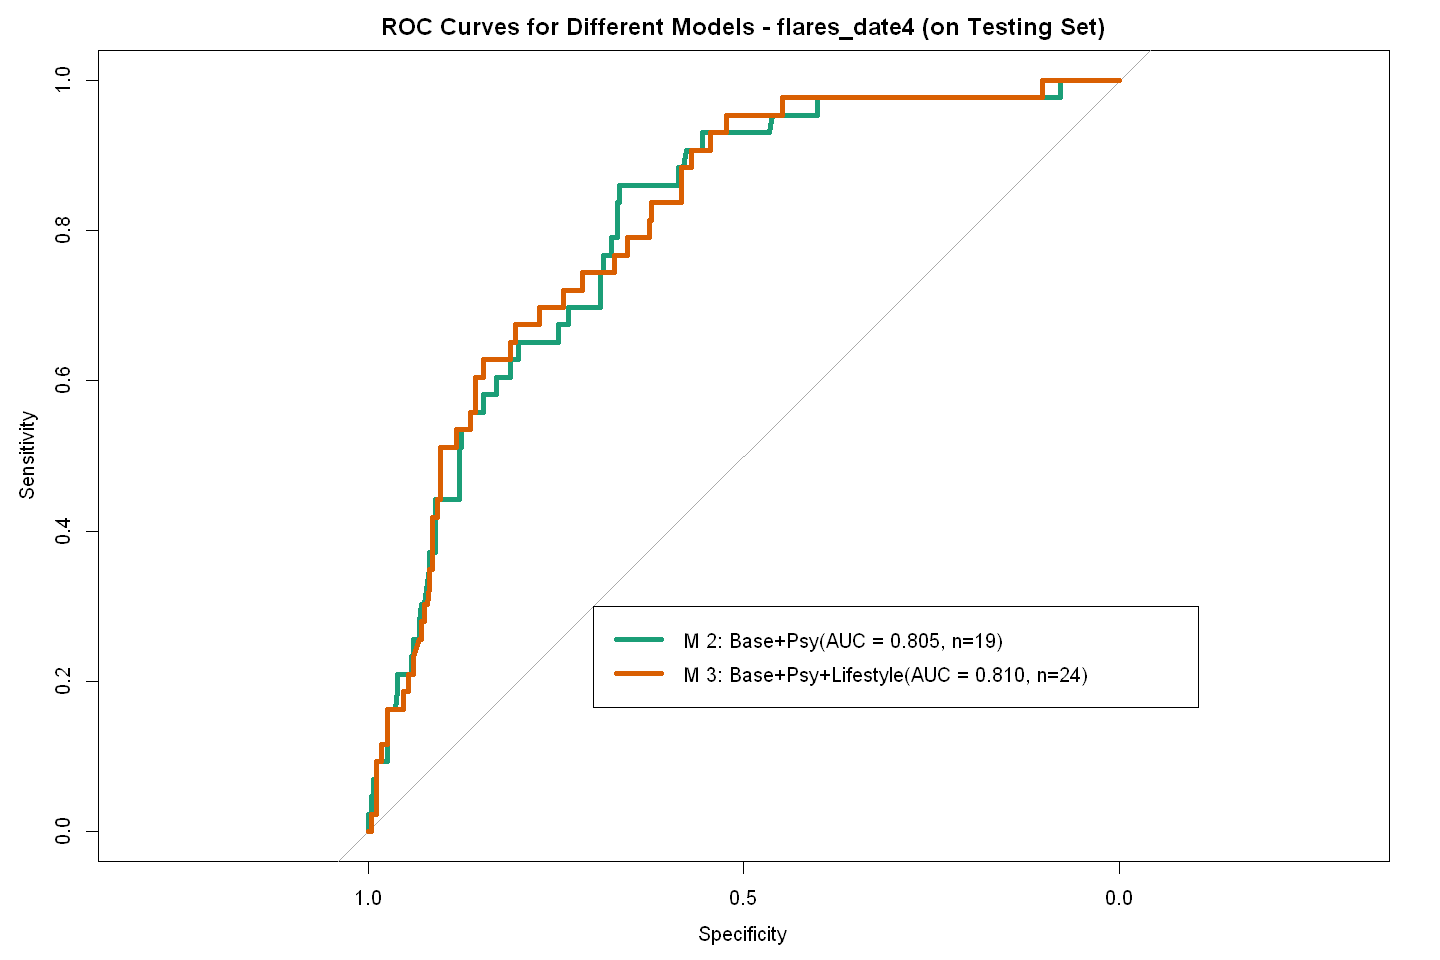

In [152]:
# Plot ROC Curves for All Models - y4
#roc_model1_y4 <- metrics_model1_y4$roc_curve
roc_model2_y4 <- metrics_model2_y4$roc_curve
roc_model3_y4 <- metrics_model3_y4$roc_curve
#roc_model4_y4 <- metrics_model4_y4$roc_curve
#roc_model5_y4 <- metrics_model5_y4$roc_curve

# ROC plot for y4
legend_labels_y4 <- c(
    paste0("M 2: Base+Psy(AUC = ", sprintf("%.3f", auc(roc_model2_y4)),  ", n=",len_model2_y4,")"),
    paste0("M 3: Base+Psy+Lifestyle(AUC = ", sprintf("%.3f", auc(roc_model3_y4)), ", n=",len_model3_y4, ")")
#    paste0("M 5: LifeStyle(AUC = ", sprintf("%.3f", auc(roc_model5_y4)), ", n=",len_model5_y4,")"),
    #paste0("M 1: BaseLine(AUC = ", sprintf("%.3f", auc(roc_model1_y4)),  ", n=",len_model1_y4,")"),
    #paste0("M 4: Psychosocial(AUC = ", sprintf("%.3f", auc(roc_model4_y4)),  ", n=",len_model4_y4,")")
)

# Create ROC plot for y4
options(repr.plot.width=12, repr.plot.height=8)
plot(roc_model2_y4, col = "#1B9E77", main = "ROC Curves for Different Models - flares_date4 (on Testing Set)", lwd=4)
plot(roc_model3_y4, col =  "#D95F02", add = TRUE, lwd=4)
#plot(roc_model4_y4, col = "#E6AB02", add = TRUE)
#plot(roc_model5_y4, col = "cyan", add = TRUE)
#plot(roc_model1_y4, col = "#7570B3", add = TRUE)
    
# Add legend
legend(x = 0.7, y = 0.3, 
        legend = legend_labels_y4,
        col = c("#1B9E77",  "#D95F02"), #, "#E6AB02", "#7570B3","#7570"#E7298A"B3"),
        lwd = 4)

In [153]:
# Create a results table for y4
results_table_y4 <- data.frame(
    Model = c(#"Model 1: BaseLine", 
              "Model 2: BaseLine + Psychosocial", 
              "Model 3: BaseLine + Psychosocial + Lifestyle"#, 
              #"Model 4: Psychosocial only" 
              #"Model 5: Lifestyle only"
              ),
    Sensitivity = c(#metrics_model1_y4$metrics[1],
                    metrics_model2_y4$metrics[1],
                    metrics_model3_y4$metrics[1]
                    #metrics_model4_y4$metrics[1]
                    #metrics_model5_y4$metrics[1]
                    ),
    Specificity = c(#metrics_model1_y4$metrics[2],
                    metrics_model2_y4$metrics[2],
                    metrics_model3_y4$metrics[2] 
                    #metrics_model4_y4$metrics[2]
                    #metrics_model5_y4$metrics[2]
                    ),
    PPV = c(#metrics_model1_y4$metrics[3],
            metrics_model2_y4$metrics[3],
            metrics_model3_y4$metrics[3] 
            #metrics_model4_y4$metrics[3]
            #metrics_model5_y4$metrics[3]
            ),
    NPV = c(#metrics_model1_y4$metrics[4],
            metrics_model2_y4$metrics[4],
            metrics_model3_y4$metrics[4]
            #metrics_model4_y4$metrics[4]
            #metrics_model5_y4$metrics[4]
            )
)

# Print the results table for y4
cat("Results Table for y4:\n")
print(kable(results_table_y4, format = "simple"))

Results Table for y4:


Model                                           Sensitivity   Specificity         PPV         NPV
---------------------------------------------  ------------  ------------  ----------  ----------
Model 2: BaseLine + Psychosocial                  0.7674419     0.6797153   0.2682927   0.9502488
Model 3: BaseLine + Psychosocial + Lifestyle      0.7441860     0.6975089   0.2735043   0.9468599


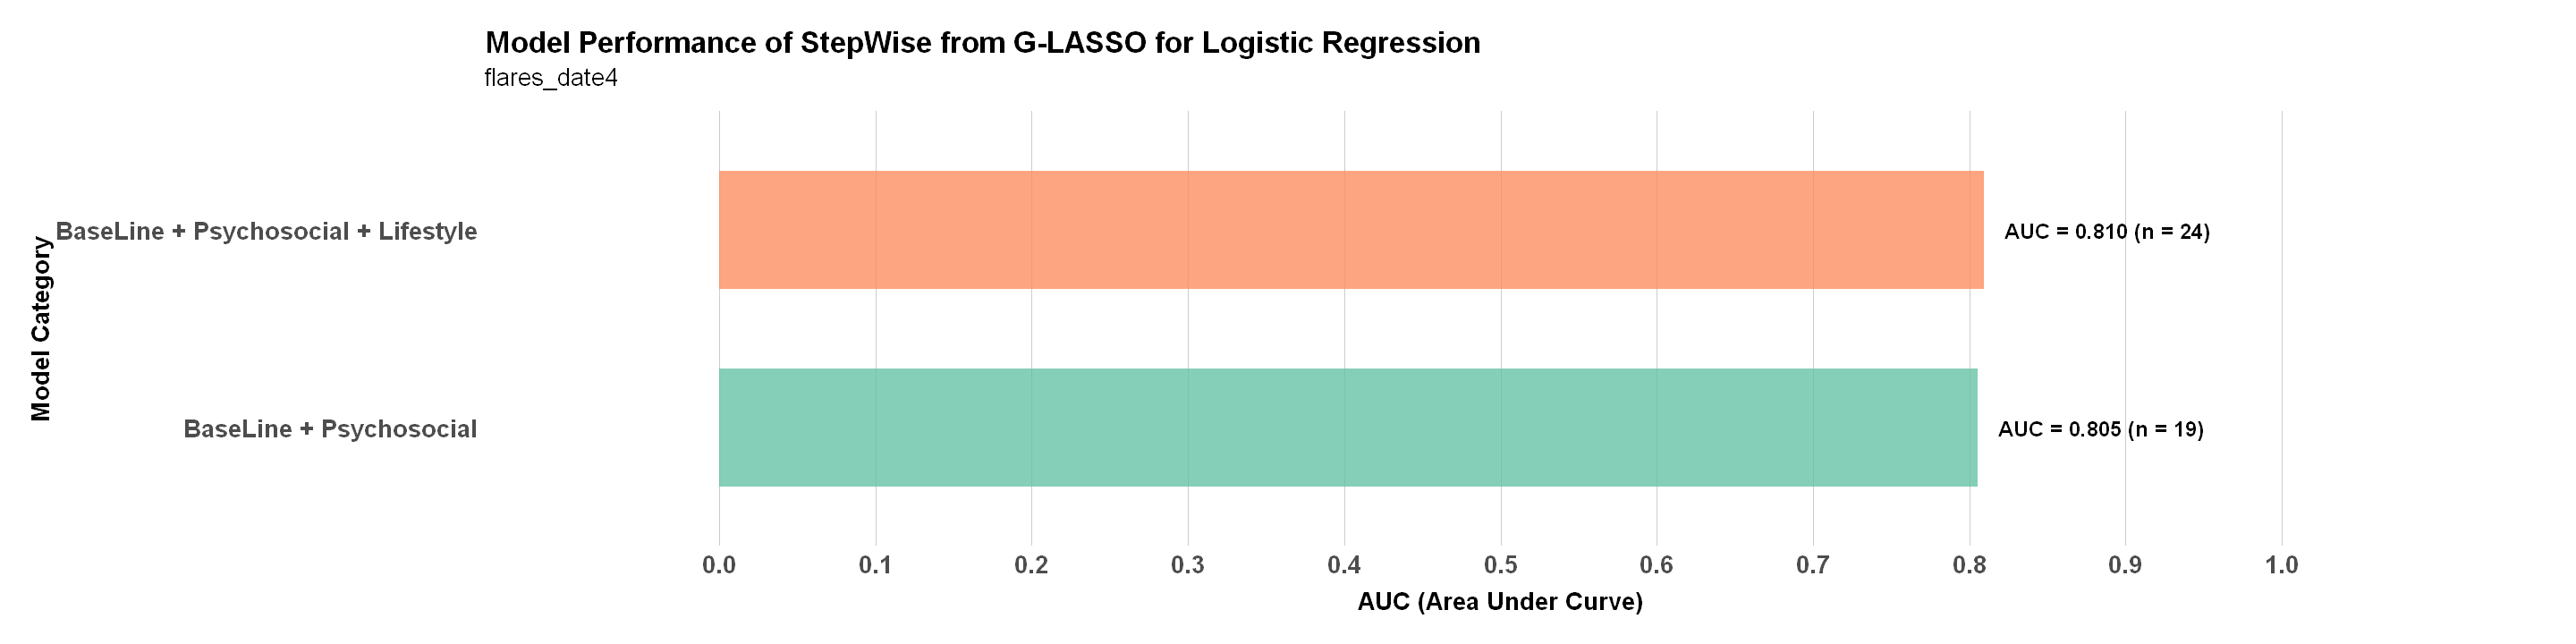

In [154]:
# Variable importance plot for y4
variable_importance_y4 <- data.frame(
  Variable = c(#"BaseLine", 
               "BaseLine + Psychosocial", "BaseLine + Psychosocial + Lifestyle"#, "Psychosocial only"
              # "Lifestyle"
               ),
  auc_values = c(#metrics_model1_y4$auc,
                 metrics_model2_y4$auc, metrics_model3_y4$auc#, metrics_model4_y4$auc
                 #metrics_model5_y4$auc
                 ),
  n_vars = c(#len_model1_y4, 
             len_model2_y4, len_model3_y4#, len_model4_y4, len_model5_y4
             )
)

options(repr.plot.width=24, repr.plot.height=6)
# Create Figure : Variable Importance Plot for Y1
ggplot(variable_importance_y4, aes(x = auc_values, y = reorder(Variable, auc_values))) +
  geom_col(aes(fill = Variable), width = 0.6, alpha = 0.8) +
  geom_text(aes(label = sprintf("AUC = %.3f (n = %d)", auc_values, n_vars)), 
            hjust = -0.1, size = 5, fontface = "bold") +
  scale_x_continuous(limits = c(0, 1), 
                     breaks = seq(0, 1, 0.1),
                     expand = c(0, 0.15)) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Model Performance of StepWise from G-LASSO for Logistic Regression",
       subtitle = "flares_date4",
       y = "Model Category",
       x = "AUC (Area Under Curve)") +
  theme_minimal() +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 20, face = "bold", hjust = 0),
    plot.subtitle = element_text(size = 16, hjust = 0, margin = margin(b = 15)),
    axis.title.x = element_text(size = 16, face = "bold", margin = margin(t = 10)),
    axis.title.y = element_text(size = 16, face = "bold", margin = margin(r = 10)),
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 16, face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.x = element_line(color = "gray80", linewidth = 0.5),
    plot.margin = margin(20, 40, 20, 20)
  )




## OVERALL COMPARISON ACROSS FLARE DATES

### Model Evolution Across Time

**Baseline Model (M1) Progressive Failure**
- Date 1: 0.660 (Poor but functional)
- Date 2: 0.588 (Barely better than chance)
- Date 3: 0.500 (Complete failure)
- Date 4: 0.500 (Complete failure)

**Trend**: Exponential decay of baseline utility. Useful only for immediate-term prediction.

**Baseline + Psychosocial (M2) Strengthening**
- Date 1: 0.778 (Good)
- Date 2: 0.742 (Good)
- Date 3: 0.766 (Good)
- Date 4: 0.806 (Excellent)

**Trend**: Most stable and consistent model. Actually IMPROVES over time as rare late events become more predictable.

**Full Model (M3) Diminishing Returns**
- Date 1: 0.787 (+0.9% over M2)
- Date 2: 0.761 (+1.9% over M2)
- Date 3: 0.765 (-0.1% vs M2) ⚠️
- Date 4: 0.799 (-0.7% vs M2) ⚠️

**Trend**: Lifestyle adds value early, becomes redundant or harmful (overfitting) late.

**Psychosocial Only (M4) Inverted U-Pattern**
- Date 1: 0.709 (Moderate)
- Date 2: 0.677 (Moderate)
- Date 3: 0.728 (Moderate-Good)
- Date 4: 0.500 (Complete failure)

**Trend**: Viable mid-term, catastrophic failure for very late prediction.

**Lifestyle Only (M5) Consistent Failure**
- All dates: 0.500-0.530 (No discrimination)

**Trend**: Smoking status alone provides no predictive value at any timepoint.


## KEY EVOLUTIONARY TRENDS

### 1. **Variable Selection Complexity**

**Date 1**: All models select variables (10-22)
**Date 2**: M5 fails (0 variables), M1 severely reduced (4 variables)
**Date 3**: M1 and M5 fail completely
**Date 4**: M1, M4, M5 all fail

**Interpretation**: LASSO increasingly aggressive at excluding irrelevant domains over time.

### 2. **Sensitivity Evolution**

- Date 1: 67-67% (M2/M3)
- Date 2: 72-76% (peak)
- Date 3: 70-79% (high but variable)
- Date 4: 68-73% (stable)

**Interpretation**: Best sensitivity at mid-term when flares are most common.

### 3. **NPV Improvement (Most Important)**

- Date 1: 54-55% (poor)
- Date 2: 73-75% (good)
- Date 3: 86-88% (excellent)
- Date 4: 94-95% (outstanding)

**Interpretation**: Models become progressively better at ruling OUT late flares - critical for reducing monitoring burden.

### 4. **PPV Decline**

- Date 1: 85-86% (excellent)
- Date 2: 66-69% (moderate)
- Date 3: 43-48% (poor)
- Date 4: 25-27% (very poor)

**Interpretation**: As flares become rarer, false positives increase - but high NPV compensates.




## THE PARADOXES ACROSS ALL MODELS

### 1. **Disease Burden Paradox** (Strongest Finding)

Across ALL timepoints and models, high disease burden is **protective**:
- Date 1 M2: -0.01 (minimal)
- Date 1 M3: +0.02 (reverses to risk)
- Date 2 M2: -1.10
- Date 2 M3: -2.51 (massive protection!)
- Date 3 M2: -3.00 (strongest protection)
- Date 4 M2: -1.24

**Interpretation**: Patients reporting highest disease burden have dramatically lower flare risk, especially mid-to-late term. Likely mechanisms:


### 2. **Fatigue Protective Effect**

High fatigue consistently protective:
- Date 1: -0.17 to -0.29
- Date 2: -0.50 to -0.53
- Date 3: -0.78 to -1.10 (very strong)
- Date 4: -0.25 to -0.46

**Interpretation**: Similar mechanism to disease burden - symptomatic patients receive better care.

### 3. **Smoking Paradox**

Current smoking protective when included:
- Date 1 M3: -0.38
- Date 2 M3: -0.48
- Date 3 M3: -0.08
- Date 4 M3: -0.30

**Interpretation**: Possible nicotine immunomodulatory effects OR confounding (smokers may be on different treatment regimens).

### 4. **High Anxiety Protective, Moderate Anxiety Harmful**

Pattern across models:
- Moderate anxiety (0.25-0.67): positive coefficients (risk factor)
- High anxiety (0.67-2): negative coefficients (protective)

**Interpretation**: Extreme anxiety may trigger medical intervention or behavior change, while moderate anxiety goes unaddressed.







## CLINICAL DECISION FRAMEWORK (5-Model Analysis)

### For Early Flares
**Recommended Model**: Model 3 (Base + Psy + Lifestyle)
- **AUC**: 0.787
- **Clinical utility**: PPV 86.3% - high confidence in positive predictions
- **Action**: Screen for stress, assess smoking status, consider early intervention for high-stress patients
- **Monitoring**: Standard frequency

### For Mid-term Flare
**Recommended Model**: Model 3 (Base + Psy + Lifestyle)
- **AUC**: 0.761
- **Critical finding**: Surgery history (2.01) dominates
- **Clinical utility**: Balanced sensitivity/specificity (72%/71%)
- **Action**: Post-surgical patients need intensive monitoring; high disease burden patients can be monitored less
- **Key insight**: Smoking status provides meaningful risk stratification

### For Late Flares
**Recommended Model**: Model 2 (Base + Psy) - **Lifestyle adds no value**
- **AUC**: 0.766
- **Critical finding**: NPV 86.1% - excellent for ruling out
- **Clinical utility**: Can confidently reduce monitoring for low-risk patients
- **Action**: Use model to identify low-risk group for less frequent monitoring
- **Surgery effect**: Remains dominant (2.32)

### For Very Late Flares 
**Recommended Model**: Model 2 (Base + Psy) - **Only viable model**
- **AUC**: 0.806 (best overall)
- **Critical finding**: NPV 94.8% - outstanding negative prediction
- **Clinical utility**: Can safely de-escalate monitoring for 95% of low-risk patients
- **Action**: Reserve intensive monitoring for anxiety-positive, high-stress patients
- **Disease entity matters**: CD vs UC distinction becomes critical


## FINAL RECOMMENDATIONS

### Statistical Best Practices
1. **Use Model 2** (Base + Psy) as the **core workhorse** - stable across all timepoints
2. **Consider Model 3** (Base + Psy + Life) for **Date 1-2 only** - meaningful early benefit
3. **Never use single-domain models** (M1, M4, M5) - all fail at critical timepoints
4. **Prioritize NPV over PPV** for late flares - ruling out is more clinically valuable





In [ ]:
dim(dataset_cd); dim(dataset_uc); table(combined_dataset$DiseaseEntity )
(2403-728)/2403; (1832-353)/1832; 2403+1832